先利用Chr1 / Segment1 / Block1（206 SNP）嘗試找出haplotype的頻率
因為避免計算太多因此建立規則是
只要某個partial haplotype已經沒有至少2個人 就立刻停止那條branch
所以最後只留下150人中至少2人共同haplotype，再算haplotype出現的頻率： 人數 / 150



In [1]:

import pandas as pd
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# Step 1：讀取R輸出的150人 nucleotide genotype
# ------------------------------------------------------------

file_path = Path.home() / "Desktop" / "segment_haplotype_step2" / \
    "Chr1_Segment1_Block1_nucleotide_genotype_150.csv"


geno_df = pd.read_csv(
    file_path,
    index_col=0
)


print("Number of subjects =", geno_df.shape[0])
print("Number of SNPs =", geno_df.shape[1])

print(geno_df.iloc[:5, :10])

Number of subjects = 150
Number of SNPs = 206
            AX-213081815 AX-39914545 AX-32104085 AX-37361815 AX-114301173  \
CT-01-00032          A/A         C/C         C/C         T/T          A/A   
CT-01-00037          A/A         C/C         C/C         T/T          A/A   
CT-01-00053          A/A         C/C         C/C         T/T          A/A   
CT-01-00150          A/A         C/C         C/C         T/C          A/A   
CT-01-00254          A/G         C/T         C/C         T/T          A/A   

            AX-114217754 AX-113253044 AX-13217020 AX-114327574 AX-40233095  
CT-01-00032          C/C          T/T         G/G          C/C         A/A  
CT-01-00037          C/C          T/T         G/G          C/C         A/A  
CT-01-00053          C/C          T/T         G/G          C/C         A/A  
CT-01-00150          C/C          T/T         G/G          C/C         A/A  
CT-01-00254          C/C          T/T         G/G          C/C         A/A  


#step2 把 nucleotide genotype 轉成{}的形式

In [2]:

ALLELES = ("A", "C", "G", "T")


def genotype_to_alleles(genotype):
 
    if pd.isna(genotype):
        return set()

    genotype = str(genotype)

    if genotype == "NoCall":
        return set()

    parts = genotype.split("/")

    if len(parts) != 2:
        return set()

    return set(parts)


#測試
print(genotype_to_alleles("A/A"))
print(genotype_to_alleles("A/G"))
print(genotype_to_alleles("C/T"))
print(genotype_to_alleles("NoCall"))

{'A'}
{'G', 'A'}
{'T', 'C'}
set()


#step3 建立每個 SNP × 每個 allele 的 supporter matrix

#
# 某一顆SNP：
#
# Person1 = A/A
# Person2 = A/G
# Person3 = G/G
#
# 那麼：
#
# allele A 的support：
# Person1 = True
# Person2 = True
# Person3 = False
#
# allele G 的support：
# Person1 = False
# Person2 = True
# Person3 = True
#
# 之後我們建立完整haplotype時，
# 就可以一路把不同SNP的support取交集，
# 找出「哪些人同時支持整條haplotype」。

In [3]:

#150人的數量
n_subjects = geno_df.shape[0]

#目前block中的SNP數
#這個測試Block應該是206
n_snps = geno_df.shape[1]

#geno_df的row index就是150人的sample ID
#轉成numpy array方便之後根據True/False抓sample
sample_ids = geno_df.index.to_numpy()

#geno_df的column名稱就是variant ID
#例如AX-xxxx
snp_ids = geno_df.columns.to_numpy()


#最後的結構會像：
#
# support_masks[0]["A"]
# support_masks[0]["C"]
# support_masks[0]["G"]
# support_masks[0]["T"]
#
#代表第1顆SNP：
#哪些subjects可以支持A/C/G/T
#
#每個結果都是長度150的True/False vector
# ------------------------------------------------------------

support_masks = []


# ------------------------------------------------------------
# 5. 逐顆SNP處理
# ------------------------------------------------------------

for j in range(n_snps):

    #抓目前第j顆SNP
    #150人的nucleotide genotype
    #
    #例如：
    #A/A
    #A/G
    #G/G
    #...
    genotypes = geno_df.iloc[:, j]


    # --------------------------------------------------------
    # 6. 把每個人的genotype轉成允許的allele集合
    # --------------------------------------------------------
    #
    #例如：
    #
    #A/A -> {"A"}
    #A/G -> {"A","G"}
    #G/G -> {"G"}
    #
    #這裡使用前面建立的genotype_to_alleles()
    # --------------------------------------------------------

    allele_sets = [
        genotype_to_alleles(g)
        for g in genotypes
    ]


    # --------------------------------------------------------
    # 7. 建立這一顆SNP的support dictionary
    # --------------------------------------------------------

    snp_support = {}


    # --------------------------------------------------------
    # 8. 分別檢查A/C/G/T
    # --------------------------------------------------------

    for allele in ALLELES:

        #對150人逐一判斷：
        #
        #目前這個allele
        #是否存在於該subject允許的allele集合中
        #
        #例如：
        #
        #allele = "A"
        #
        #Person1 = A/A -> True
        #Person2 = A/G -> True
        #Person3 = G/G -> False

        snp_support[allele] = np.array(
            [
                allele in allele_set
                for allele_set in allele_sets
            ],
            dtype=bool
        )


    # --------------------------------------------------------
    # 9. 把目前這顆SNP的support結果存進list
    # --------------------------------------------------------

    support_masks.append(
        snp_support
    )


# ------------------------------------------------------------
# 10. 確認support mask建立完成
# ------------------------------------------------------------

print(
    "Support masks created."
)

print(
    "Number of SNPs in support_masks =",
    len(support_masks)
)

print(
    "Number of subjects =",
    n_subjects
)

Support masks created.
Number of SNPs in support_masks = 206
Number of subjects = 150


In [4]:
# ============================================================
# QC：查看第1顆SNP有多少人支持A/C/G/T
# ============================================================

print(
    "First SNP ID =",
    snp_ids[0]
)

for allele in ALLELES:

    #True加總後就是支持這個allele的人數
    support_n = support_masks[0][allele].sum()

    print(
        allele,
        "support subjects =",
        support_n
    )

First SNP ID = AX-213081815
A support subjects = 150
C support subjects = 0
G support subjects = 10
T support subjects = 0


每往下一顆 SNP，就把目前仍支持這條haplotype 的和支持下一個 allele 的人取交集
如果最後只剩 0 或 1 個人，就直接停止這條 branch，不再往後搜尋

In [5]:
# ============================================================
# Step 4：搜尋至少2人共同支持的完整candidate haplotypes
# ============================================================
#
# 目前：
#
# n_subjects = 150
# n_snps = 206
#
# support_masks[j][allele]
# 已經告訴我們：
#
# 第j顆SNP中，
# 哪些subjects的genotype允許allele A/C/G/T
#
#
# 現在要做的是：
#
# SNP1選一個allele
# ↓
# 找哪些人支持
# ↓
# SNP2再選一個allele
# ↓
# 與前面的subjects取交集
# ↓
# SNP3...
# ↓
# 一直做到SNP206
#
# 最後得到：
#
# 完整haplotype
# +
# 有多少subjects的genotype可以共同支持它
# ============================================================


# ------------------------------------------------------------
# 1. 設定minimum support
# ------------------------------------------------------------
#
# 我們現在的目標是找：
# 「至少有2個人共同支持」的candidate haplotype
#
# 所以設定：
# min_support = 2
#
# 如果某個partial haplotype只剩1人支持，
# 就不需要再往後延伸
# ------------------------------------------------------------

min_support = 2


# ------------------------------------------------------------
# 2. 設定安全上限
# ------------------------------------------------------------
#
# 理論空間是2^206，非常巨大。
#
# 雖然我們會prune，
# 但為了避免某些資料真的產生大量branches，
# 先設定最大搜尋node數。
#
# 一個node可以理解成：
# 「目前已經形成到某一顆SNP的partial haplotype」
# ------------------------------------------------------------

max_nodes = 5_000_000


# ------------------------------------------------------------
# 3. 設定最多儲存多少條完整candidate haplotypes
# ------------------------------------------------------------
#
# 如果真的有非常大量完整candidate haplotypes，
# 不希望一次把記憶體塞滿。
#
# 先設定最多存100,000條。
# ------------------------------------------------------------

max_results = 100_000


# ------------------------------------------------------------
# 4. 建立搜尋stack
# ------------------------------------------------------------
#
# stack中的每一筆資料包含3個東西：
#
# 1. snp_index
#    下一步要處理第幾顆SNP
#
# 2. haplotype_prefix
#    目前已經形成的haplotype sequence
#
# 3. supporter mask
#    目前仍然支持這條haplotype的subjects
#
#
# 一開始：
#
# 還沒有選任何SNP
# 所以：
#
# snp_index = 0
# haplotype_prefix = ""
#
# 並且150人全部都是potential supporters
# ------------------------------------------------------------

stack = [
    (
        0,                                  #從第1顆SNP開始
        "",                                 #目前haplotype還是空的
        np.ones(n_subjects, dtype=bool)     #150人全部先設為True
    )
]


# ------------------------------------------------------------
# 5. 建立results
# ------------------------------------------------------------
#
# 最後完整走完206顆SNP的candidate haplotypes
# 會放進這個list
# ------------------------------------------------------------

results = []


# ------------------------------------------------------------
# 6. 記錄總共搜尋過多少nodes
# ------------------------------------------------------------

nodes_visited = 0

In [6]:
# ============================================================
# 7. 開始pruning search
# ============================================================

while stack:

    # --------------------------------------------------------
    # 從stack取出目前要處理的一條partial haplotype
    # --------------------------------------------------------
    #
    # stack.pop()會取出最後加入的一筆
    #
    # 得到：
    #
    # snp_index
    # = 下一顆要處理的SNP位置
    #
    # prefix
    # = 目前已經形成的haplotype sequence
    #
    # current_support
    # = 目前仍支持這條sequence的subjects
    # --------------------------------------------------------

    snp_index, prefix, current_support = stack.pop()


    #每取出一個node就記錄一次
    nodes_visited += 1


    # --------------------------------------------------------
    # 8. 安全檢查：搜尋node太多時停止
    # --------------------------------------------------------

    if nodes_visited > max_nodes:

        print(
            "STOP: maximum search nodes reached =",
            max_nodes
        )

        break


    # --------------------------------------------------------
    # 9. 判斷是否已經走完整個Block
    # --------------------------------------------------------
    #
    # 如果：
    #
    # snp_index == n_snps
    #
    # 代表206顆SNP全部都已經選完allele。
    #
    # 此時prefix就是一條完整candidate haplotype。
    # --------------------------------------------------------

    if snp_index == n_snps:

        #計算目前仍有多少subjects支持這條完整haplotype
        support_n = int(
            current_support.sum()
        )


        #把完整candidate haplotype存起來
        results.append(
            {

                #完整206-SNP allele sequence
                "haplotype": prefix,

                #有多少subjects可以支持這條candidate haplotype
                "support_n": support_n,

                #以150人為denominator
                "frequency_150":
                    support_n / n_subjects,

                #記錄實際有哪些subjects支持
                "support_samples":
                    ",".join(
                        sample_ids[current_support]
                    )
            }
        )


        # ----------------------------------------------------
        # 如果完整candidate haplotype太多
        # 達到我們設定的安全上限，就停止
        # ----------------------------------------------------

        if len(results) >= max_results:

            print(
                "STOP: maximum result number reached =",
                max_results
            )

            break


        #這條完整haplotype已經處理完成
        #回到while stack處理下一條branch
        continue


    # --------------------------------------------------------
    # 10. 處理目前這一顆SNP
    # --------------------------------------------------------
    #
    # 嘗試A / C / G / T四種allele
    #
    # 但如果某個allele在這顆SNP根本沒有人支持，
    # 後面自然會直接被prune掉
    # --------------------------------------------------------

    for allele in ALLELES:


        # ----------------------------------------------------
        # 11. 取得目前SNP中
        # 支持這個allele的150人True/False vector
        # ----------------------------------------------------

        allele_support = support_masks[
            snp_index
        ][
            allele
        ]


        # ----------------------------------------------------
        # 12. 取交集
        # ----------------------------------------------------
        #
        # current_support：
        # 支持目前prefix的人
        #
        # allele_support：
        # 支持目前這顆SNP allele的人
        #
        #
        # & 的意思就是：
        #
        # 必須「兩個條件都True」
        #
        # 才能繼續支持新的haplotype
        #
        # 例如：
        #
        # prefix = A-C
        # 現在加入G
        #
        # 那new_support就代表：
        # 同時支持A-C-G的人
        # ----------------------------------------------------

        new_support = (
            current_support
            &
            allele_support
        )


        # ----------------------------------------------------
        # 13. 計算加入目前allele後
        # 還剩多少subjects支持
        # ----------------------------------------------------

        support_n = int(
            new_support.sum()
        )


        # ----------------------------------------------------
        # 14. Pruning核心
        # ----------------------------------------------------
        #
        # 如果support_n < 2：
        #
        # 代表這條partial haplotype
        # 已經沒有至少2個人共同支持。
        #
        # 即使後面再加更多SNP，
        # supporter只可能更少，不可能增加。
        #
        # 所以可以直接停止這條branch。
        # ----------------------------------------------------

        if support_n < min_support:

            continue


        # ----------------------------------------------------
        # 15. 如果還有至少2個subjects
        # 就繼續往下一顆SNP搜尋
        # ----------------------------------------------------
        #
        # prefix + allele
        #
        # 例如：
        #
        # prefix = "AC"
        # allele = "G"
        #
        # 新prefix = "ACG"
        #
        # 並且把new_support一起保存，
        # 下一顆SNP只能從這些仍支持ACG的人繼續找。
        # ----------------------------------------------------

        stack.append(
            (
                snp_index + 1,
                prefix + allele,
                new_support
            )
        )

STOP: maximum result number reached = 100000


In [7]:
# ============================================================
# Step 5：優先搜尋support人數最高的candidate haplotypes
# ============================================================
#
# 剛剛的DFS會一直搜尋所有可能branch，
# 結果超過100,000條後被停止。
#
# 現在改成Best-first search：
#
# 每次優先處理「目前support subjects最多」的partial haplotype。
#
# 例如：
#
# partial haplotype A-C
# → 80人support
#
# partial haplotype G-T
# → 20人support
#
# 那我們會先延伸A-C，
# 因為它比較有可能最後形成high-frequency haplotype。
#
# 目的：
# 不需要找完全部candidate haplotypes，
# 先找最常見的完整haplotypes。
# ============================================================


#Python priority queue
import heapq


# ------------------------------------------------------------
# 1. 設定我們想先找多少條最高頻完整haplotypes
# ------------------------------------------------------------
#
#目前先找前100條
#不是說只有100條，
#只是先看最高frequency的結果
# ------------------------------------------------------------

top_n_haplotypes = 100


# ------------------------------------------------------------
# 2. 最低共同support仍然設定為2人
# ------------------------------------------------------------

min_support = 2


# ------------------------------------------------------------
# 3. 建立priority queue
# ------------------------------------------------------------
#
# heapq預設是「數字小的優先」
#
# 但我們希望：
# support人數越多越優先
#
# 所以使用負號：
#
# 150人support
# → priority = -150
#
# 100人support
# → priority = -100
#
# -150比-100小，
# 因此150人的branch會先被取出
#
#
# queue每一筆包含：
#
# (
#   -support_n,
#   unique_counter,
#   snp_index,
#   haplotype_prefix,
#   supporter_mask
# )
#
# unique_counter只是避免兩筆priority相同時
# Python嘗試比較numpy array而發生error
# ------------------------------------------------------------

priority_queue = []


#用來產生唯一編號
counter = 0


#一開始還沒有選任何allele
#所以150人全部都是potential supporters
initial_support = np.ones(
    n_subjects,
    dtype=bool
)


#把搜尋起點放進priority queue
heapq.heappush(
    priority_queue,
    (
        -n_subjects,        #150人support，所以priority=-150
        counter,            #唯一編號
        0,                  #從第1顆SNP開始
        "",                 #目前haplotype是空的
        initial_support     #目前150人都還support
    )
)


# ------------------------------------------------------------
# 4. 儲存最後找到的完整high-frequency haplotypes
# ------------------------------------------------------------

top_results = []


#記錄總共搜尋多少nodes
nodes_visited_best = 0

In [8]:
# ============================================================
# 5. 開始Best-first search
# ============================================================

while priority_queue and len(top_results) < top_n_haplotypes:

    # --------------------------------------------------------
    # 取出目前support subjects最多的branch
    # --------------------------------------------------------

    (
        negative_support_n,
        _,
        snp_index,
        prefix,
        current_support
    ) = heapq.heappop(
        priority_queue
    )


    #把負數轉回真正support人數
    current_support_n = -negative_support_n


    #記錄搜尋node數
    nodes_visited_best += 1


    # --------------------------------------------------------
    # 如果206顆SNP全部完成
    # 代表找到一條完整candidate haplotype
    # --------------------------------------------------------

    if snp_index == n_snps:

        top_results.append(
            {
                #完整206-SNP haplotype
                "haplotype": prefix,

                #有多少subjects的genotype可以支持
                "support_n": current_support_n,

                #以150人為denominator的frequency
                "frequency_150":
                    current_support_n / n_subjects,

                #列出support這條haplotype的samples
                "support_samples":
                    ",".join(
                        sample_ids[current_support]
                    )
            }
        )

        #這條已經完成
        #回去處理priority queue下一條
        continue


    # --------------------------------------------------------
    # 尚未走完206顆SNP
    # 嘗試目前SNP的A/C/G/T
    # --------------------------------------------------------

    for allele in ALLELES:

        #目前這顆SNP中
        #哪些subjects可以支持這個allele
        allele_support = support_masks[
            snp_index
        ][
            allele
        ]


        #必須同時支持：
        #
        #目前已經形成的prefix
        #AND
        #目前這顆SNP的allele
        new_support = (
            current_support
            &
            allele_support
        )


        #加入這個allele後
        #還剩多少subjects共同support
        new_support_n = int(
            new_support.sum()
        )


        # ----------------------------------------------------
        # 如果只剩0或1人
        #就不是我們現在要找的「共同haplotype」
        #直接prune
        # ----------------------------------------------------

        if new_support_n < min_support:
            continue


        #新的haplotype prefix
        new_prefix = prefix + allele


        #unique counter +1
        counter += 1


        # ----------------------------------------------------
        # 把新的branch放進priority queue
        #
        #support人數越多，
        #negative number越小，
        #因此越快被取出處理
        # ----------------------------------------------------

        heapq.heappush(
            priority_queue,
            (
                -new_support_n,
                counter,
                snp_index + 1,
                new_prefix,
                new_support
            )
        )

In [9]:
# ============================================================
# Step 5 QC
# ============================================================

print(
    "Nodes visited =",
    nodes_visited_best
)

print(
    "Complete high-frequency haplotypes found =",
    len(top_results)
)


#如果有找到完整haplotypes
if len(top_results) > 0:

    print(
        "Highest support_n =",
        top_results[0]["support_n"]
    )

    print(
        "Highest frequency =",
        top_results[0]["frequency_150"]
    )

Nodes visited = 1872626
Complete high-frequency haplotypes found = 100
Highest support_n = 9
Highest frequency = 0.06


e.g.,先用Chr1、Segment 1、Block 1 不設定任何停止 就計算出所有組合


In [20]:
# ============================================================
# Chr1 / Segment1 / Block1
# Genotype-compatible candidate haplotype frequency
#
# 資料：
# 150 subjects
# 206 SNPs
#
# 目的：
#
# 1. 使用每個人的 nucleotide genotype
# 2. 每顆SNP選擇一個allele形成haplotype
# 3. 找出150人中至少2人可以共同支持的完整haplotypes
# 4. 計算每種support_n對應的frequency
#
# 注意：
# 目前沒有做phasing。
# 因此這裡得到的是：
#
# genotype-compatible candidate haplotype
#
# 而不是已確認存在於同一條chromosome上的phased haplotype。
# ============================================================


# ============================================================
# Step 1：載入套件
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path
from collections import defaultdict, Counter

In [21]:
# ============================================================
# Step 2：讀取Chr1 / Segment1 / Block1資料
# ============================================================


# ------------------------------------------------------------
# 1. 指定檔案位置
# ------------------------------------------------------------
#
# 這是前面由R輸出的：
#
# 150人 × 206 SNP nucleotide genotype matrix
#
# row：
# subject
#
# column：
# SNP
#
# cell：
# A/A、A/G、C/T、G/G、NoCall...
# ------------------------------------------------------------

file_path = (
    Path.home()
    / "Desktop"
    / "segment_haplotype_step2"
    / "Chr1_Segment1_Block1_nucleotide_genotype_150.csv"
)


# ------------------------------------------------------------
# 2. 讀入CSV
# ------------------------------------------------------------
#
# index_col=0：
# 第一欄是R存下來的sample ID
# 把它直接當成DataFrame row name
# ------------------------------------------------------------

geno_df = pd.read_csv(
    file_path,
    index_col=0
)


# ------------------------------------------------------------
# 3. 確認dimension
# ------------------------------------------------------------

print(
    "Number of subjects =",
    geno_df.shape[0]
)

print(
    "Number of SNPs =",
    geno_df.shape[1]
)


# ------------------------------------------------------------
# 4. 查看前5人、前10顆SNP
# ------------------------------------------------------------

print(
    geno_df.iloc[
        :5,
        :10
    ]
)

Number of subjects = 150
Number of SNPs = 206
            AX-213081815 AX-39914545 AX-32104085 AX-37361815 AX-114301173  \
CT-01-00032          A/A         C/C         C/C         T/T          A/A   
CT-01-00037          A/A         C/C         C/C         T/T          A/A   
CT-01-00053          A/A         C/C         C/C         T/T          A/A   
CT-01-00150          A/A         C/C         C/C         T/C          A/A   
CT-01-00254          A/G         C/T         C/C         T/T          A/A   

            AX-114217754 AX-113253044 AX-13217020 AX-114327574 AX-40233095  
CT-01-00032          C/C          T/T         G/G          C/C         A/A  
CT-01-00037          C/C          T/T         G/G          C/C         A/A  
CT-01-00053          C/C          T/T         G/G          C/C         A/A  
CT-01-00150          C/C          T/T         G/G          C/C         A/A  
CT-01-00254          C/C          T/T         G/G          C/C         A/A  


In [22]:
# ============================================================
# Step 3：標準化nucleotide genotype
# ============================================================
#
# 目的：
#
# 確保CSV中的genotype都是一致格式。
#
# 例如：
#
# A/A
# A/G
# C/T
# G/G
# NoCall
#
# 避免因為空格、大小寫等問題造成後面判斷錯誤。
# ============================================================


# ------------------------------------------------------------
# 1. 把所有不是missing的值轉成字串
# ------------------------------------------------------------

geno_df = geno_df.apply(
    lambda col:
        col.map(
            lambda x:
                str(x).strip().upper()
                if pd.notna(x)
                else "NOCALL"
        )
)


# ------------------------------------------------------------
# 2. 統一NoCall名稱
# ------------------------------------------------------------
#
# R中我們存的是：
# NoCall
#
# Python轉大寫後會變：
# NOCALL
#
# 後面全部統一使用：
# NOCALL
# ------------------------------------------------------------

geno_df = geno_df.replace(
    {
        "NO CALL": "NOCALL",
        "NA": "NOCALL",
        "NAN": "NOCALL",
        "": "NOCALL"
    }
)


# ------------------------------------------------------------
# 3. 定義合法的DNA alleles
# ------------------------------------------------------------

ALLELES = (
    "A",
    "C",
    "G",
    "T"
)


# ------------------------------------------------------------
# 4. 建立function：
# nucleotide genotype -> 該subject允許的alleles
# ------------------------------------------------------------
#
# 例如：
#
# A/A
# -> {"A"}
#
# A/G
# -> {"A","G"}
#
# C/T
# -> {"C","T"}
#
# G/G
# -> {"G"}
#
#
# NOCALL：
#
# 目前採取保守作法：
# 不把它當作任何allele的positive evidence。
#
# 所以：
#
# NOCALL -> empty set
#
# 代表這個subject遇到這顆missing SNP時，
# 不會被計入完整candidate haplotype的support。
# ------------------------------------------------------------

def genotype_to_alleles(genotype):

    #missing / NoCall
    if genotype == "NOCALL":
        return set()


    #例如A/G
    parts = genotype.split("/")


    #正常diploid genotype應該有兩個alleles
    if len(parts) != 2:
        return set()


    #只接受A/C/G/T
    if (
        parts[0] not in ALLELES
        or
        parts[1] not in ALLELES
    ):
        return set()


    #使用set：
    #
    # A/A -> {"A"}
    #
    # A/G -> {"A","G"}
    return set(parts)

In [24]:
# ============================================================
# Step 4：建立每顆SNP × allele的supporter bitmask
# ============================================================
#
# 目的：
#
# 對206顆SNP中的每一顆，
# 建立：
#
# allele A -> 哪些subjects可以支持
# allele C -> 哪些subjects可以支持
# allele G -> 哪些subjects可以支持
# allele T -> 哪些subjects可以支持
#
#
# 例如某顆SNP：
#
# Person1 = A/A
# Person2 = A/G
# Person3 = G/G
#
# 那：
#
# A supporter：
# Person1、Person2
#
# G supporter：
# Person2、Person3
#
#
# 為了讓後面的交集計算更快，
# 我們把150人的True/False vector
# 壓縮成Python integer bitmask。
# ============================================================


# ------------------------------------------------------------
# 1. 基本資料大小
# ------------------------------------------------------------

n_subjects = geno_df.shape[0]

n_snps = geno_df.shape[1]


# ------------------------------------------------------------
# 2. 保存sample ID與SNP ID
# ------------------------------------------------------------

sample_ids = geno_df.index.to_numpy()

snp_ids = geno_df.columns.to_numpy()


# ------------------------------------------------------------
# 3. 建立allele_options
# ------------------------------------------------------------
#
# allele_options[j]
#
# 代表第j顆SNP可以使用哪些alleles，
# 以及每個allele有哪些subjects支持。
#
#
# 結構例如：
#
# allele_options[0] =
#
# [
#   ("A", supporter_bitmask),
#   ("G", supporter_bitmask)
# ]
#
#
# 因為你的資料已經限制為biallelic SNP，
# 所以正常來說每顆SNP主要只有兩個alleles。
# ------------------------------------------------------------

allele_options = []


# ------------------------------------------------------------
# 4. 逐顆SNP處理
# ------------------------------------------------------------

for j in range(n_snps):

    #目前這顆SNP的150人genotype
    genotypes = geno_df.iloc[:, j]


    #這顆SNP所有可能的allele options
    options_now = []


    # --------------------------------------------------------
    # 分別檢查A/C/G/T
    # --------------------------------------------------------

    for allele in ALLELES:

        #supporter bitmask
        #
        #一開始全部bit都是0
        supporter_mask = 0


        # ----------------------------------------------------
        # 逐一檢查150人
        # ----------------------------------------------------

        for i, genotype in enumerate(genotypes):

            #把genotype轉成允許的alleles
            allowed_alleles = (
                genotype_to_alleles(
                    genotype
                )
            )


            #如果這個subject可以支持目前allele
            if allele in allowed_alleles:

                #把第i個bit設成1
                supporter_mask |= (
                    1 << i
                )


        # ----------------------------------------------------
        # 計算有多少subjects支持這個allele
        # ----------------------------------------------------

        support_n = (
            supporter_mask.bit_count()
        )


        # ----------------------------------------------------
        # 如果連2個人都沒有，
        # 這個allele不可能形成
        # support_n >= 2的完整haplotype。
        #
        # 所以可以直接不加入搜尋。
        # ----------------------------------------------------

        if support_n >= 2:

            options_now.append(
                (
                    allele,
                    supporter_mask
                )
            )


    # --------------------------------------------------------
    # 保存目前這顆SNP
    # --------------------------------------------------------

    allele_options.append(
        options_now
    )

In [25]:
# ============================================================
# Step 4 QC：確認allele_options不是空的
# ============================================================


print(
    "Number of SNPs in allele_options =",
    len(allele_options)
)


# ------------------------------------------------------------
# 查看前10顆SNP
# ------------------------------------------------------------

for j in range(
    min(
        10,
        n_snps
    )
):

    print(
        "SNP",
        j + 1,
        snp_ids[j]
    )


    for (
        allele,
        supporter_mask
    ) in allele_options[j]:

        print(
            "   ",
            allele,
            "support_n =",
            supporter_mask.bit_count()
        )

Number of SNPs in allele_options = 206
SNP 1 AX-213081815
    A support_n = 150
    G support_n = 10
SNP 2 AX-39914545
    C support_n = 150
    T support_n = 19
SNP 3 AX-32104085
    C support_n = 139
    T support_n = 49
SNP 4 AX-37361815
    C support_n = 10
    T support_n = 149
SNP 5 AX-114301173
    A support_n = 150
    G support_n = 14
SNP 6 AX-114217754
    C support_n = 150
    G support_n = 6
SNP 7 AX-113253044
    G support_n = 12
    T support_n = 149
SNP 8 AX-13217020
    A support_n = 11
    G support_n = 150
SNP 9 AX-114327574
    C support_n = 149
    G support_n = 9
SNP 10 AX-40233095
    A support_n = 147
    G support_n = 30


In [26]:
# ============================================================
# 檢查是否有無法繼續搜尋的SNP
# ============================================================

empty_snp_indices = [
    j
    for j, options
    in enumerate(allele_options)
    if len(options) == 0
]


print(
    "SNPs with no allele supported by >=2 subjects =",
    len(empty_snp_indices)
)

SNPs with no allele supported by >=2 subjects = 0


e.g.,先用Chr1、Segment 1、Block 1 不設定任何停止 就計算出所有組合->找出組合中出現頻率最高的


Block 1
↓
所有連續位置的candidate haplotype segments
↓
150人逐一比較
↓
每一段：
start SNP
end SNP
haplotype sequence
support_n
frequency
↓
找出高頻的shared haplotype segment

在一個 block 裡，只要由至少 2 個連續 SNP 組成一段 haplotype，就把這一段拿去 150 人中比較，看有多少人同時具有／相容於這段 haplotype

In [31]:
#因此第一步驟要先找出所有長度 ≥2 的連續 haplotype segments

# ============================================================
# Step 7-1：搜尋Block中所有連續2-SNP candidate haplotypes
# ============================================================
#
# 目的：
#
# 對目前206-SNP Block中的每一對「相鄰SNP」：
#
# SNP1-SNP2
# SNP2-SNP3
# SNP3-SNP4
# ...
# SNP205-SNP206
#
# 建立所有可能的2-SNP nucleotide haplotype。
#
#
# 例如：
#
# SNP1 = A/G
# SNP2 = C/T
#
# candidate haplotypes：
#
# AC
# AT
# GC
# GT
#
#
# 然後對150人逐一判斷：
#
# 是否兩個位置「同時」可以支持這條haplotype。
#
#
# 例如candidate = AC：
#
# Person1：
# SNP1 = A/G -> 支持A
# SNP2 = C/C -> 支持C
# => 支持AC
#
# Person2：
# SNP1 = A/A -> 支持A
# SNP2 = T/T -> 不支持C
# => 不支持AC
#
#
# frequency =
#
# support_n / 150
#
#
# 注意：
#
# 這一步不是phasing。
# 得到的仍然是：
#
# genotype-compatible candidate haplotype
# ============================================================


# ------------------------------------------------------------
# 1. 建立空的結果list
# ------------------------------------------------------------
#
# 每找到一個在150人中至少有1人support的
# 2-SNP candidate haplotype，
# 就把結果放進這裡。
# ------------------------------------------------------------

haplotype_len2_results = []


# ------------------------------------------------------------
# 2. 依序處理所有相鄰SNP pair
# ------------------------------------------------------------
#
# 206顆SNP：
#
# j = 0
# -> SNP1 + SNP2
#
# j = 1
# -> SNP2 + SNP3
#
# ...
#
# j = 204
# -> SNP205 + SNP206
#
# 所以range只走到n_snps - 1
# ------------------------------------------------------------

for j in range(n_snps - 1):


    # --------------------------------------------------------
    # 3. 抓第一顆SNP的allele options
    # --------------------------------------------------------
    #
    # 例如：
    #
    # SNP1 = A/G
    #
    # options_left可能是：
    #
    # [
    #   ("A", supporter_mask),
    #   ("G", supporter_mask)
    # ]
    # --------------------------------------------------------

    options_left = allele_options[j]


    # --------------------------------------------------------
    # 4. 抓第二顆SNP的allele options
    # --------------------------------------------------------

    options_right = allele_options[j + 1]


    # --------------------------------------------------------
    # 5. 窮舉這兩顆SNP的allele combinations
    # --------------------------------------------------------
    #
    # 如果：
    #
    # SNP1 = A/G
    # SNP2 = C/T
    #
    # 最多就是：
    #
    # AC
    # AT
    # GC
    # GT
    # --------------------------------------------------------

    for (
        allele_left,
        mask_left
    ) in options_left:


        for (
            allele_right,
            mask_right
        ) in options_right:


            # ------------------------------------------------
            # 6. 找同時支持兩個allele的人
            # ------------------------------------------------
            #
            # mask_left：
            # 支持第一顆SNP allele的人
            #
            # mask_right：
            # 支持第二顆SNP allele的人
            #
            # 使用bitwise AND：
            #
            # 只有兩邊都support的人才留下。
            # ------------------------------------------------

            shared_mask = (
                mask_left
                &
                mask_right
            )


            # ------------------------------------------------
            # 7. 計算共同support人數
            # ------------------------------------------------

            support_n = (
                shared_mask.bit_count()
            )


            # ------------------------------------------------
            # 8. 如果150人完全沒有人support
            # 就不用記錄
            # ------------------------------------------------
            #
            # frequency = 0的組合直接排除。
            #
            # 這符合你前面說的：
            #
            # 「150人中找不到出現的組合就排除」
            # ------------------------------------------------

            if support_n == 0:

                continue


            # ------------------------------------------------
            # 9. 建立2-SNP haplotype sequence
            # ------------------------------------------------
            #
            # 例如：
            #
            # allele_left = A
            # allele_right = C
            #
            # haplotype = AC
            # ------------------------------------------------

            haplotype = (
                allele_left
                +
                allele_right
            )


            # ------------------------------------------------
            # 10. 計算frequency
            # ------------------------------------------------

            frequency = (
                support_n
                /
                n_subjects
            )


            # ------------------------------------------------
            # 11. 把結果存起來
            # ------------------------------------------------
            #
            # start_index：
            # haplotype從Block中的第幾顆SNP開始
            #
            # end_index：
            # 到第幾顆SNP結束
            #
            # length：
            # 現在固定=2
            #
            # start_snp / end_snp：
            # variant ID
            #
            # haplotype：
            # nucleotide sequence
            #
            # support_n：
            # 150人中多少人compatible
            #
            # frequency：
            # support_n / 150
            # ------------------------------------------------

            haplotype_len2_results.append(
                {
                    "start_index": j + 1,
                    "end_index": j + 2,

                    "start_snp": snp_ids[j],
                    "end_snp": snp_ids[j + 1],

                    "haplotype_length": 2,

                    "haplotype": haplotype,

                    "support_n": support_n,

                    "frequency_150": frequency
                }
            )

In [32]:
# ============================================================
# Step 7-1 QC：整理2-SNP haplotype結果
# ============================================================


# ------------------------------------------------------------
# 1. 轉成DataFrame
# ------------------------------------------------------------

haplotype_len2_df = pd.DataFrame(
    haplotype_len2_results
)


# ------------------------------------------------------------
# 2. 按frequency由高到低排序
# ------------------------------------------------------------
#
# 如果frequency相同，
# 再以start position排序。
# ------------------------------------------------------------

haplotype_len2_df = (
    haplotype_len2_df
    .sort_values(
        by=[
            "support_n",
            "start_index"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

In [33]:
# ------------------------------------------------------------
# 查看最高frequency的前20條2-SNP haplotypes
# ------------------------------------------------------------

print(
    haplotype_len2_df[
        [
            "start_index",
            "end_index",
            "start_snp",
            "end_snp",
            "haplotype",
            "support_n",
            "frequency_150"
        ]
    ].head(20)
)

    start_index  end_index     start_snp       end_snp haplotype  support_n  \
0             1          2  AX-213081815   AX-39914545        AC        150   
1             5          6  AX-114301173  AX-114217754        AC        150   
2            15         16   AX-37361875   AX-64175821        GA        150   
3            18         19   AX-32355233   AX-32359895        CG        150   
4            19         20   AX-32359895   AX-32365989        GG        150   
5            25         26  AX-113736438  AX-149125082        GC        150   
6            26         27  AX-149125082   AX-32415467        CC        150   
7            42         43  AX-119847065   AX-32527281        CC        150   
8            53         54  AX-112917588   AX-37362017        CA        150   
9            56         57   AX-83537617   AX-32609917        GA        150   
10           57         58   AX-32609917   AX-32610857        AC        150   
11           62         63   AX-32615355  AX-1143550

做length >= 2的完整搜索

In [34]:
# ============================================================
# Step 7-1：準備完整搜尋
# ============================================================
#
# 目的：
#
# 搜尋目前206-SNP Block中所有：
#
# contiguous haplotype
# 且 haplotype length >= 2
#
#
# 例如：
#
# SNP1-SNP2
# SNP1-SNP2-SNP3
# SNP1-SNP2-SNP3-SNP4
# ...
#
# SNP2-SNP3
# SNP2-SNP3-SNP4
# ...
#
#
# 每一條candidate haplotype都要確認：
#
# 有多少位subjects的genotype
# 可以「同時」支持整段haplotype。
#
#
# 只保留：
#
# support_n >= 2
#
#
# frequency =
# support_n / 150
# ============================================================


from collections import defaultdict, Counter

import pandas as pd


# ------------------------------------------------------------
# 1. 最低共同support人數
# ------------------------------------------------------------
#
# 至少2人才算「共同出現」
# ------------------------------------------------------------

min_support = 2


# ------------------------------------------------------------
# 2. 建立150人全部為True的初始support mask
# ------------------------------------------------------------
#
# 每開始一個新的haplotype區段時，
# 一開始150人都是potential supporters。
# ------------------------------------------------------------

full_support_mask = (
    (1 << n_subjects) - 1
)


# ------------------------------------------------------------
# 3. 保存每一個start-end interval的摘要
# ------------------------------------------------------------
#
# 之後每一列會代表一個：
#
# SNP start -> SNP end
#
# 例如：
#
# SNP1-SNP2
# SNP1-SNP3
# SNP1-SNP4
# ...
# ------------------------------------------------------------

interval_summary_results = []


# ------------------------------------------------------------
# 4. 整個Block的support frequency distribution
# ------------------------------------------------------------
#
# 例如：
#
# support_n = 100
# -> 全部interval中有多少條candidate haplotypes
#
# support_n = 99
# -> 有多少條
#
# ...
# ------------------------------------------------------------

global_support_distribution = Counter()


# ------------------------------------------------------------
# 5. 記錄整個Block最高support_n
# ------------------------------------------------------------

global_max_support = 0


# ------------------------------------------------------------
# 6. 記錄總共有多少candidate haplotypes
# ------------------------------------------------------------

global_candidate_haplotype_n = 0

In [35]:
# ============================================================
# Step 7-2：完整搜尋所有contiguous intervals
# ============================================================


# ------------------------------------------------------------
# start_index：
# 指定目前haplotype從哪一顆SNP開始
#
# 因為minimum length = 2，
# 最後一顆SNP不能自己當start，
# 所以只走到 n_snps - 2。
# ------------------------------------------------------------

for start_index in range(n_snps - 1):


    # --------------------------------------------------------
    # 每換一個新的start SNP，
    # 都重新從150人全部potential support開始
    # --------------------------------------------------------
    #
    # frontier的：
    #
    # key
    # = supporter bitmask
    #
    # value
    # = 有多少條不同haplotype sequences
    #   目前會得到相同的supporter group
    #
    #
    # 一開始還沒有加入任何allele，
    # 所以只有1條empty sequence。
    # --------------------------------------------------------

    frontier = {
        full_support_mask: 1
    }


    # --------------------------------------------------------
    # end_index：
    #
    # 從start SNP開始，
    # 一顆一顆往右延伸
    #
    # 例如start_index=0：
    #
    # end=0 -> SNP1
    # end=1 -> SNP1-SNP2
    # end=2 -> SNP1-SNP3
    # ...
    # --------------------------------------------------------

    for end_index in range(
        start_index,
        n_snps
    ):


        # ----------------------------------------------------
        # 建立加入目前SNP之後的新frontier
        # ----------------------------------------------------

        new_frontier = defaultdict(int)


        # ----------------------------------------------------
        # 逐一處理目前所有partial haplotypes
        # ----------------------------------------------------

        for (
            current_support_mask,
            haplotype_count
        ) in frontier.items():


            # ------------------------------------------------
            # 嘗試目前SNP所有可能alleles
            #
            # 例如：
            #
            # A
            # G
            # ------------------------------------------------

            for (
                allele,
                allele_support_mask
            ) in allele_options[end_index]:


                # --------------------------------------------
                # 找同時支持：
                #
                # 前面整段haplotype
                #
                # AND
                #
                # 目前這顆SNP allele
                #
                # 的subjects
                # --------------------------------------------

                new_support_mask = (
                    current_support_mask
                    &
                    allele_support_mask
                )


                # --------------------------------------------
                # 計算目前還剩多少共同subjects
                # --------------------------------------------

                support_n = (
                    new_support_mask.bit_count()
                )


                # --------------------------------------------
                # 如果只剩0或1人：
                #
                # 不符合我們的共同haplotype定義。
                #
                # 而且後面再增加SNP，
                # support只可能下降，不可能增加。
                #
                # 所以直接prune。
                # --------------------------------------------

                if support_n < min_support:

                    continue


                # --------------------------------------------
                # 如果不同allele sequences
                # 最後得到完全相同的supporter group，
                #
                # 不需要把sequence一條一條存在RAM。
                #
                # 只記錄：
                # 目前有多少條不同candidate sequences
                # 對應這個supporter group。
                # --------------------------------------------

                new_frontier[
                    new_support_mask
                ] += haplotype_count


        # ----------------------------------------------------
        # 更新frontier
        # ----------------------------------------------------

        frontier = new_frontier


        # ----------------------------------------------------
        # 如果完全沒有>=2人共同support的candidate
        #
        # 再繼續延長一定也不會重新出現，
        # 所以這個start可以提前停止。
        # ----------------------------------------------------

        if len(frontier) == 0:

            break


        # ----------------------------------------------------
        # 計算目前haplotype長度
        #
        # 例如：
        #
        # start=0,end=0 -> length=1
        # start=0,end=1 -> length=2
        # start=0,end=2 -> length=3
        # ----------------------------------------------------

        haplotype_length = (
            end_index
            -
            start_index
            +
            1
        )


        # ----------------------------------------------------
        # length = 1不是我們要的haplotype
        #
        # 所以只有length >= 2才開始記錄結果
        # ----------------------------------------------------

        if haplotype_length < 2:

            continue


        # ====================================================
        # 現在這個start-end interval已經是一段合法haplotype
        # ====================================================


        # ----------------------------------------------------
        # 這個interval共有多少candidate haplotypes
        # ----------------------------------------------------

        interval_candidate_n = sum(
            frontier.values()
        )


        #加入整個Block的總數
        global_candidate_haplotype_n += (
            interval_candidate_n
        )


        # ----------------------------------------------------
        # 找目前這個interval最高support_n
        # ----------------------------------------------------

        interval_max_support = max(
            supporter_mask.bit_count()
            for supporter_mask
            in frontier.keys()
        )


        # ----------------------------------------------------
        # 目前interval最高frequency
        # ----------------------------------------------------

        interval_max_frequency = (
            interval_max_support
            /
            n_subjects
        )


        # ----------------------------------------------------
        # 有多少條candidate haplotypes
        # 達到目前interval的最高support
        # ----------------------------------------------------

        interval_max_haplotype_n = sum(
            haplotype_count

            for (
                supporter_mask,
                haplotype_count
            ) in frontier.items()

            if supporter_mask.bit_count()
            ==
            interval_max_support
        )


        # ----------------------------------------------------
        # 更新整個Block最高support
        # ----------------------------------------------------

        if (
            interval_max_support
            >
            global_max_support
        ):

            global_max_support = (
                interval_max_support
            )


        # ----------------------------------------------------
        # 更新整個Block的support distribution
        # ----------------------------------------------------
        #
        # 例如目前某個supporter group：
        #
        # support_n = 80
        # haplotype_count = 4
        #
        # 就代表有4條不同haplotype
        # frequency都是80/150。
        # ----------------------------------------------------

        for (
            supporter_mask,
            haplotype_count
        ) in frontier.items():

            support_n = (
                supporter_mask.bit_count()
            )

            global_support_distribution[
                support_n
            ] += haplotype_count


        # ----------------------------------------------------
        # 保存目前interval摘要
        # ----------------------------------------------------

        interval_summary_results.append(
            {
                #Block內起始SNP序號
                "start_index":
                    start_index + 1,

                #Block內結束SNP序號
                "end_index":
                    end_index + 1,

                #起始variant ID
                "start_snp":
                    snp_ids[start_index],

                #結束variant ID
                "end_snp":
                    snp_ids[end_index],

                #這段haplotype包含多少SNP
                "haplotype_length":
                    haplotype_length,

                #目前interval共有多少candidate sequences
                "candidate_haplotype_n":
                    interval_candidate_n,

                #這個interval最高有多少人共同support
                "max_support_n":
                    interval_max_support,

                #最高frequency
                "max_frequency":
                    interval_max_frequency,

                #有幾條candidate sequences
                #達到這個最高support
                "max_support_haplotype_n":
                    interval_max_haplotype_n
            }
        )


    # --------------------------------------------------------
    # 每處理完一個start SNP顯示進度
    # --------------------------------------------------------

    print(
        f"Start SNP {start_index + 1}/{n_snps - 1} completed"
    )

Start SNP 1/205 completed
Start SNP 2/205 completed
Start SNP 3/205 completed
Start SNP 4/205 completed
Start SNP 5/205 completed
Start SNP 6/205 completed
Start SNP 7/205 completed
Start SNP 8/205 completed
Start SNP 9/205 completed
Start SNP 10/205 completed
Start SNP 11/205 completed
Start SNP 12/205 completed
Start SNP 13/205 completed
Start SNP 14/205 completed
Start SNP 15/205 completed
Start SNP 16/205 completed
Start SNP 17/205 completed
Start SNP 18/205 completed
Start SNP 19/205 completed
Start SNP 20/205 completed
Start SNP 21/205 completed
Start SNP 22/205 completed
Start SNP 23/205 completed
Start SNP 24/205 completed
Start SNP 25/205 completed
Start SNP 26/205 completed
Start SNP 27/205 completed
Start SNP 28/205 completed
Start SNP 29/205 completed
Start SNP 30/205 completed
Start SNP 31/205 completed
Start SNP 32/205 completed
Start SNP 33/205 completed
Start SNP 34/205 completed
Start SNP 35/205 completed
Start SNP 36/205 completed
Start SNP 37/205 completed
Start SNP 

In [37]:
# ============================================================
# Step 7-3.5：把前面搜尋完成的interval結果轉成DataFrame
# ============================================================
#
# 前面的搜尋過程會把每個contiguous interval的結果
# 暫存在 interval_summary_results
#
# 例如：
#
# SNP1-SNP2
# SNP1-SNP3
# SNP1-SNP4
# ...
# SNP205-SNP206
#
# 每一段都包含：
# start SNP
# end SNP
# haplotype length
# maximum support
# maximum frequency
# 等資訊
#
# 現在把這個list正式轉成pandas DataFrame，
# 之後7-4才能做整個Block的統計。
# ============================================================


# ------------------------------------------------------------
# 1. 先確認前面的結果物件還存在
# ------------------------------------------------------------

print(
    "interval_summary_results exists =",
    "interval_summary_results" in globals()
)


# ------------------------------------------------------------
# 2. 如果存在，確認裡面有多少筆結果
# ------------------------------------------------------------

if "interval_summary_results" in globals():

    print(
        "Number of interval results =",
        len(interval_summary_results)
    )

interval_summary_results exists = True
Number of interval results = 21115


In [39]:
# ------------------------------------------------------------
# 3. 將list轉成DataFrame
# ------------------------------------------------------------

interval_summary_df = pd.DataFrame(
    interval_summary_results
)


# ------------------------------------------------------------
# 4. 確認DataFrame成功建立
# ------------------------------------------------------------

print(
    "interval_summary_df shape =",
    interval_summary_df.shape
)

print(
    "Columns =",
    interval_summary_df.columns.tolist()
)


#查看前10筆
print(
    interval_summary_df.head(10)
)

interval_summary_df shape = (21115, 9)
Columns = ['start_index', 'end_index', 'start_snp', 'end_snp', 'haplotype_length', 'candidate_haplotype_n', 'max_support_n', 'max_frequency', 'max_support_haplotype_n']
   start_index  end_index     start_snp       end_snp  haplotype_length  \
0            1          2  AX-213081815   AX-39914545                 2   
1            1          3  AX-213081815   AX-32104085                 3   
2            1          4  AX-213081815   AX-37361815                 4   
3            1          5  AX-213081815  AX-114301173                 5   
4            1          6  AX-213081815  AX-114217754                 6   
5            1          7  AX-213081815  AX-113253044                 7   
6            1          8  AX-213081815   AX-13217020                 8   
7            1          9  AX-213081815  AX-114327574                 9   
8            1         10  AX-213081815   AX-40233095                10   
9            1         11  AX-213081815  A

In [40]:
# ============================================================
# Step 7-4：查看整個Block的結果
# ============================================================

print(
    "\n========================================"
)

print(
    "Analysis completed."
)


# ------------------------------------------------------------
# 1. 總共分析多少個contiguous SNP intervals
# ------------------------------------------------------------

print(
    "Total contiguous intervals analyzed =",
    len(interval_summary_df)
)


Analysis completed.
Total contiguous intervals analyzed = 21115


In [41]:
# ============================================================
# Step 7-5：找最高frequency所在的interval
# ============================================================


# ------------------------------------------------------------
# 抓所有達到global maximum support的interval
# ------------------------------------------------------------

best_intervals = (
    interval_summary_df[
        interval_summary_df[
            "max_support_n"
        ]
        ==
        global_max_support
    ]
    .copy()
)


# ------------------------------------------------------------
# 優先顯示較長的haplotype
# ------------------------------------------------------------
#
# 因為如果：
#
# 2-SNP haplotype有100人
# 8-SNP haplotype也有100人
#
# 8-SNP通常對你的enrichment目的更有資訊。
# ------------------------------------------------------------

best_intervals = (
    best_intervals
    .sort_values(
        by="haplotype_length",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nIntervals with global maximum frequency:"
)


print(
    best_intervals[
        [
            "start_index",
            "end_index",
            "start_snp",
            "end_snp",
            "haplotype_length",
            "max_support_n",
            "max_frequency",
            "max_support_haplotype_n"
        ]
    ].head(20)
)


Intervals with global maximum frequency:
    start_index  end_index     start_snp       end_snp  haplotype_length  \
0           159        165  AX-148830492  AX-148599944                 7   
1           159        164  AX-148830492  AX-113325438                 6   
2            65         70  AX-113101358   AX-32711979                 6   
3           160        165  AX-113626067  AX-148599944                 6   
4           161        165  AX-113865276  AX-148599944                 5   
5           159        163  AX-148830492  AX-114083395                 5   
6            65         69  AX-113101358   AX-40435531                 5   
7           160        164  AX-113626067  AX-113325438                 5   
8            66         70  AX-114343262   AX-32711979                 5   
9            66         69  AX-114343262   AX-40435531                 4   
10          162        165   AX-30035003  AX-148599944                 4   
11           65         68  AX-113101358   AX-

In [42]:
# ============================================================
# Step 7-6：整個Block的frequency distribution
# ============================================================


print(
    "\nHaplotype frequency distribution:"
)


# ------------------------------------------------------------
# 從最多人共同support開始往下列
# ------------------------------------------------------------

for support_n in sorted(
    global_support_distribution.keys(),
    reverse=True
):


    #這個support level共有多少candidate haplotypes
    haplotype_n = (
        global_support_distribution[
            support_n
        ]
    )


    #subject-level compatible frequency
    frequency = (
        support_n
        /
        n_subjects
    )


    print(
        f"support_n = {support_n:3d} | "
        f"frequency = {frequency:.6f} | "
        f"candidate haplotypes = {haplotype_n:,}"
    )


Haplotype frequency distribution:
support_n = 150 | frequency = 1.000000 | candidate haplotypes = 72
support_n = 149 | frequency = 0.993333 | candidate haplotypes = 98
support_n = 148 | frequency = 0.986667 | candidate haplotypes = 36
support_n = 147 | frequency = 0.980000 | candidate haplotypes = 45
support_n = 146 | frequency = 0.973333 | candidate haplotypes = 40
support_n = 145 | frequency = 0.966667 | candidate haplotypes = 33
support_n = 144 | frequency = 0.960000 | candidate haplotypes = 63
support_n = 143 | frequency = 0.953333 | candidate haplotypes = 118
support_n = 142 | frequency = 0.946667 | candidate haplotypes = 124
support_n = 141 | frequency = 0.940000 | candidate haplotypes = 54
support_n = 140 | frequency = 0.933333 | candidate haplotypes = 78
support_n = 139 | frequency = 0.926667 | candidate haplotypes = 101
support_n = 138 | frequency = 0.920000 | candidate haplotypes = 106
support_n = 137 | frequency = 0.913333 | candidate haplotypes = 112
support_n = 136 | freq

Chr1 / Segment1 / Block1 裡，第 159–165 顆 SNP 的那一段，並把那個 150/150 都 compatible 的 7-SNP candidate haplotype sequence 找出來

In [43]:
# ============================================================
# 抓出 Chr1 / Segment1 / Block1 中
# 第159–165顆SNP的資訊
# ============================================================


# ------------------------------------------------------------
# 1. 指定區段
# ------------------------------------------------------------
#
# 注意：
# Python是0-based index
#
# 第159顆SNP -> index 158
# 第165顆SNP -> index 164
# ------------------------------------------------------------

start_idx = 158
end_idx = 164


# ------------------------------------------------------------
# 2. 抓出這7顆SNP的variant ID
# ------------------------------------------------------------

target_snp_ids = snp_ids[
    start_idx:end_idx + 1
]


print(
    "Target SNP IDs:"
)

for i, snp in enumerate(
    target_snp_ids,
    start=159
):
    print(
        i,
        snp
    )

Target SNP IDs:
159 AX-148830492
160 AX-113626067
161 AX-113865276
162 AX-30035003
163 AX-114083395
164 AX-113325438
165 AX-148599944


In [44]:
# ============================================================
# 3. 搜尋159–165這7顆SNP的所有candidate haplotypes
# 並只留下support_n = 150的
# ============================================================


# ------------------------------------------------------------
# 一開始150人全部support
# ------------------------------------------------------------

full_support_mask = (
    (1 << n_subjects) - 1
)


# ------------------------------------------------------------
# stack內容：
#
# current_index
# haplotype_sequence
# supporter_mask
# ------------------------------------------------------------

stack = [
    (
        start_idx,
        "",
        full_support_mask
    )
]


#用來保存150/150共同支持的haplotype
target_haplotypes_150 = []


# ------------------------------------------------------------
# 開始搜尋
# ------------------------------------------------------------

while stack:

    (
        current_index,
        haplotype_sequence,
        current_support_mask
    ) = stack.pop()


    # --------------------------------------------------------
    # 如果已經超過end_idx
    # 代表7顆SNP都處理完成
    # --------------------------------------------------------

    if current_index > end_idx:

        support_n = (
            current_support_mask.bit_count()
        )


        #只保留150/150
        if support_n == 150:

            target_haplotypes_150.append(
                haplotype_sequence
            )

        continue


    # --------------------------------------------------------
    # 嘗試目前SNP的所有alleles
    # --------------------------------------------------------

    for (
        allele,
        allele_support_mask
    ) in allele_options[
        current_index
    ]:


        #目前supporter取交集
        new_support_mask = (
            current_support_mask
            &
            allele_support_mask
        )


        #還剩多少人support
        support_n = (
            new_support_mask.bit_count()
        )


        # ----------------------------------------------------
        # 因為我們現在只找150/150，
        # 只要掉到149以下，
        # 就不可能之後重新回到150。
        #
        # 所以直接prune。
        # ----------------------------------------------------

        if support_n < 150:

            continue


        #繼續下一顆SNP
        stack.append(
            (
                current_index + 1,
                haplotype_sequence + allele,
                new_support_mask
            )
        )

In [45]:
# ============================================================
# 4. 查看這7顆SNP中150/150共同支持的haplotype
# ============================================================

print(
    "Number of 150/150 supported haplotypes =",
    len(target_haplotypes_150)
)

print(
    "Haplotype(s) =",
    target_haplotypes_150
)

Number of 150/150 supported haplotypes = 1
Haplotype(s) = ['CGGTTAC']


① Frequency construction
所有 Chr
→ Segment
→ Block
→ contiguous haplotypes ≥2 SNP
→ remove freq=1
→ Block representative
→ Segment representative frequency


② Arrangement
利用每個Segment的representative frequency
進行新的空間排列


③ Coloring
把新的排列結果轉成影像表示


④ CNN
再根據這個資料結構
選適合的CNN architecture
並進行模型比較

邏輯順序：
單一block找出freq max ->segment中：多個block中找freq max ->代表那個segment

再接續排序->上色->cnn

In [46]:
# ============================================================
# Step 1：建立單一Block representative haplotype function
# ============================================================
# representative haplotype：
# 1. contiguous SNPs
# 2. 至少2個SNP
# 3. frequency = 1 的haplotype排除
# 4. frequency最高者優先
# 5. frequency相同 → SNP數較少者優先

import pandas as pd
import numpy as np

from collections import defaultdict

In [47]:
# ============================================================
# Step 1-1：nucleotide genotype轉成允許的alleles
# ============================================================
#
# 例如：
#
# A/A -> {"A"}
#
# A/G -> {"A","G"}
#
# C/T -> {"C","T"}
#
# G/G -> {"G"}
#
# NoCall -> empty set
#
#
# 之後搜尋haplotype時：
#
# 如果candidate某個位置需要A，
# 那A/A與A/G都可以support。
# ============================================================


ALLELES = (
    "A",
    "C",
    "G",
    "T"
)


def genotype_to_alleles(genotype):

    # --------------------------------------------------------
    # missing value
    # --------------------------------------------------------

    if pd.isna(genotype):

        return set()


    # --------------------------------------------------------
    # 統一格式
    # --------------------------------------------------------

    genotype = (
        str(genotype)
        .strip()
        .upper()
    )


    # --------------------------------------------------------
    # NoCall不提供任何allele evidence
    # --------------------------------------------------------

    if genotype in {
        "NOCALL",
        "NO CALL",
        "NA",
        "NAN",
        ""
    }:

        return set()


    # --------------------------------------------------------
    # 例如A/G拆成：
    #
    # ["A","G"]
    # --------------------------------------------------------

    parts = genotype.split("/")


    #正常diploid genotype應有兩個alleles
    if len(parts) != 2:

        return set()


    # --------------------------------------------------------
    # 只接受A/C/G/T
    # --------------------------------------------------------

    if (
        parts[0] not in ALLELES
        or
        parts[1] not in ALLELES
    ):

        return set()


    # --------------------------------------------------------
    # set會自動處理：
    #
    # A/A -> {"A"}
    #
    # A/G -> {"A","G"}
    # --------------------------------------------------------

    return set(parts)

In [ ]:
# ============================================================
# Step 1-2：單一Block選representative haplotype
# ============================================================


def select_block_representative(
    block_geno_df
):

    # ========================================================
    # A. 基本資料
    # ========================================================

    #這個Block共有多少subjects
    n_subjects = (
        block_geno_df.shape[0]
    )


    #這個Block共有多少SNP
    n_snps = (
        block_geno_df.shape[1]
    )


    #保存SNP ID
    snp_ids = (
        block_geno_df.columns.to_numpy()
    )


    #保存subject ID
    sample_ids = (
        block_geno_df.index.to_numpy()
    )


    # --------------------------------------------------------
    # 如果Block只有0或1顆SNP
    #
    # 因為規定：
    # haplotype至少需要2個SNP，
    #
    # 所以這種Block無法產生candidate haplotype。
    # --------------------------------------------------------

    if n_snps < 2:

        return {
            "status": "less_than_2_snps",
            "SNP_n": n_snps
        }


    # ========================================================
    # B. 建立每顆SNP的allele supporter bitmask
    # ========================================================
    #
    # allele_options[j]
    #
    # 代表第j顆SNP：
    #
    # [
    #     ("A", supporter_mask),
    #     ("G", supporter_mask)
    # ]
    #
    #
    # supporter_mask會記錄150人中
    # 哪些人的genotype可以support這個allele。
    # ========================================================

    allele_options = []


    #逐顆SNP處理
    for j in range(n_snps):


        #目前第j顆SNP
        genotypes = (
            block_geno_df.iloc[:, j]
        )


        #這顆SNP的allele options
        options_now = []


        # ----------------------------------------------------
        # 分別檢查A/C/G/T
        # ----------------------------------------------------

        for allele in ALLELES:


            #一開始沒有人support
            supporter_mask = 0


            # ------------------------------------------------
            # 逐一檢查subjects
            # ------------------------------------------------

            for i, genotype in enumerate(
                genotypes
            ):


                #這個人的genotype允許哪些alleles
                allowed_alleles = (
                    genotype_to_alleles(
                        genotype
                    )
                )


                #如果目前allele存在於allowed alleles中
                if allele in allowed_alleles:

                    #把第i個subject的bit設成1
                    supporter_mask |= (
                        1 << i
                    )


            # ------------------------------------------------
            # 有至少1個subject支持才需要留下
            #
            # frequency = 0的allele不用搜尋。
            # ------------------------------------------------

            if supporter_mask.bit_count() >= 1:

                options_now.append(
                    (
                        allele,
                        supporter_mask
                    )
                )


        #保存這顆SNP
        allele_options.append(
            options_now
        )


    # ========================================================
    # C. 準備搜尋最佳haplotype
    # ========================================================

    #150人全部support的initial mask
    full_support_mask = (
        (1 << n_subjects) - 1
    )


    # --------------------------------------------------------
    # best_result最後保存：
    #
    # 目前整個Block找到的最佳representative haplotype
    # --------------------------------------------------------

    best_result = None


    # --------------------------------------------------------
    # 目前最高support人數
    #
    # frequency = support_n / 150
    #
    # 因此比較support_n
    # 就等同於比較frequency。
    # --------------------------------------------------------

    best_support_n = 0


    # --------------------------------------------------------
    # 當support_n相同時，
    # 老師規定：
    #
    # SNP數較少者優先。
    # --------------------------------------------------------

    best_length = float("inf")


    # ========================================================
    # D. 從Block中每一顆SNP當作起點
    # ========================================================
    #
    # 例如：
    #
    # start=1
    #
    # SNP1-2
    # SNP1-3
    # SNP1-4
    # ...
    #
    #
    # start=2
    #
    # SNP2-3
    # SNP2-4
    # ...
    # ========================================================

    for start_index in range(
        n_snps - 1
    ):


        # ----------------------------------------------------
        # frontier：
        #
        # key
        # = supporter mask
        #
        # value
        # = 一條可以產生這個supporter group的
        #   haplotype sequence
        #
        #
        # 重要：
        #
        # 如果不同haplotype sequence
        # 最後supporter完全相同，
        #
        # 對我們目前「找最高frequency」的目的來說，
        # 只需要保留其中一條即可。
        # ----------------------------------------------------

        frontier = {
            full_support_mask: ""
        }


        # ====================================================
        # E. 從start SNP往右延伸
        # ====================================================

        for end_index in range(
            start_index,
            n_snps
        ):


            #加入目前SNP之後的新frontier
            new_frontier = {}


            # ------------------------------------------------
            # 逐一處理目前所有partial haplotypes
            # ------------------------------------------------

            for (
                current_support_mask,
                current_sequence
            ) in frontier.items():


                # --------------------------------------------
                # 嘗試目前SNP的alleles
                # --------------------------------------------

                for (
                    allele,
                    allele_support_mask
                ) in allele_options[
                    end_index
                ]:


                    # ----------------------------------------
                    # supporter取交集
                    #
                    # 必須：
                    #
                    # 前面所有SNP都support
                    #
                    # AND
                    #
                    # 現在這顆SNP也support
                    # ----------------------------------------

                    new_support_mask = (
                        current_support_mask
                        &
                        allele_support_mask
                    )


                    #目前共同support人數
                    support_n = (
                        new_support_mask.bit_count()
                    )


                    # ----------------------------------------
                    # 完全沒有人support
                    # -> frequency = 0
                    #
                    # 直接排除。
                    # ----------------------------------------

                    if support_n == 0:

                        continue


                    # ----------------------------------------
                    # 建立新的haplotype sequence
                    # ----------------------------------------

                    new_sequence = (
                        current_sequence
                        +
                        allele
                    )


                    # ----------------------------------------
                    # 如果相同supporter mask已經存在，
                    #
                    # 不需要再存另一條sequence，
                    # 因為目前我們只需要找representative。
                    # ----------------------------------------

                    if (
                        new_support_mask
                        not in new_frontier
                    ):

                        new_frontier[
                            new_support_mask
                        ] = new_sequence


            #更新frontier
            frontier = new_frontier


            # ------------------------------------------------
            # 如果已經沒有任何candidate，
            # 後面不可能重新出現，
            # 直接停止這個start position。
            # ------------------------------------------------

            if len(frontier) == 0:

                break


            # =================================================
            # F. 計算目前haplotype長度
            # =================================================

            haplotype_length = (
                end_index
                -
                start_index
                +
                1
            )


            # ------------------------------------------------
            # 老師規定：
            #
            # haplotype至少需要2個SNP。
            #
            # length=1不進行代表性比較。
            # ------------------------------------------------

            if haplotype_length < 2:

                continue


            # =================================================
            # G. 評估目前interval中的candidate haplotypes
            # =================================================

            for (
                supporter_mask,
                haplotype_sequence
            ) in frontier.items():


                #共同support人數
                support_n = (
                    supporter_mask.bit_count()
                )


                #frequency
                frequency = (
                    support_n
                    /
                    n_subjects
                )


                # --------------------------------------------
                # 老師最新規則：
                #
                # frequency = 1
                #
                # 表示150人全部都compatible，
                # 沒有區分資訊。
                #
                # 所以直接刪除。
                # --------------------------------------------

                if frequency == 1:

                    continue


                # =================================================
                # H. 判斷是否比目前best更好
                # =================================================
                #
                # Rule 1：
                #
                # frequency較高
                # -> 優先
                #
                #
                # Rule 2：
                #
                # frequency相同
                # -> SNP數較少優先
                # =================================================

                better_candidate = False


                #frequency較高
                if support_n > best_support_n:

                    better_candidate = True


                #frequency一樣
                #但haplotype比較短
                elif (
                    support_n
                    ==
                    best_support_n
                    and
                    haplotype_length
                    <
                    best_length
                ):

                    better_candidate = True


                # =================================================
                # I. 更新best result
                # =================================================

                if better_candidate:


                    #更新最高support
                    best_support_n = (
                        support_n
                    )


                    #更新最短SNP長度
                    best_length = (
                        haplotype_length
                    )


                    #找實際有哪些subjects support
                    supporter_indices = [
                        i
                        for i in range(
                            n_subjects
                        )
                        if (
                            supporter_mask
                            &
                            (1 << i)
                        )
                    ]


                    supporter_samples = [
                        sample_ids[i]
                        for i in supporter_indices
                    ]


                    #保存完整representative資訊
                    best_result = {

                        "status":
                            "representative_found",

                        "start_index":
                            start_index + 1,

                        "end_index":
                            end_index + 1,

                        "start_snp":
                            snp_ids[
                                start_index
                            ],

                        "end_snp":
                            snp_ids[
                                end_index
                            ],

                        "haplotype_length":
                            haplotype_length,

                        "haplotype":
                            haplotype_sequence,

                        "support_n":
                            support_n,

                        "frequency":
                            frequency,

                        "support_samples":
                            supporter_samples
                    }


    # ========================================================
    # J. 整個Block搜尋完成
    # ========================================================

    # --------------------------------------------------------
    # 如果所有candidate都是frequency=1
    # 或沒有合法>=2 SNP haplotype，
    # 就沒有representative。
    # --------------------------------------------------------

    if best_result is None:

        return {
            "status":
                "no_informative_haplotype",

            "SNP_n":
                n_snps
        }


    # --------------------------------------------------------
    # 回傳這個Block的representative
    # --------------------------------------------------------

    return best_result

In [49]:
# ============================================================
# 測試目前Chr1 / Segment1 / Block1
# ============================================================

block1_representative = (
    select_block_representative(
        geno_df
    )
)


print( block1_representative)

{'status': 'representative_found', 'start_index': 4, 'end_index': 5, 'start_snp': 'AX-37361815', 'end_snp': 'AX-114301173', 'haplotype_length': 2, 'haplotype': 'TA', 'support_n': 149, 'frequency': 0.9933333333333333, 'support_samples': ['CT-01-00032', 'CT-01-00037', 'CT-01-00053', 'CT-01-00150', 'CT-01-00254', 'CT-01-00278', 'CT-01-00411', 'CT-01-00418', 'CT-01-00420', 'CT-01-00520', 'CT-01-00573', 'CT-01-00642', 'CT-01-00652', 'CT-02-00015', 'CT-02-00106', 'CT-02-00380', 'CT-02-00464', 'CT-02-00523', 'CT-02-00559', 'CT-02-00622', 'CT-03-00011', 'CT-03-00032', 'CT-03-00079', 'CT-03-00141', 'CT-03-00249', 'CT-03-00295', 'CT-03-00399', 'CT-03-00422', 'CT-03-00440', 'CT-03-00488', 'CT-03-00493', 'CT-04-00050', 'CT-04-00067', 'CT-04-00104', 'CT-04-00106', 'CT-04-00187', 'CT-04-00191', 'CT-04-00193', 'CT-04-00274', 'CT-04-00313', 'CT-04-00374', 'CT-04-00530', 'CT-05-00047', 'CT-05-00282', 'CT-05-00322', 'CT-05-00369', 'CT-05-00464', 'CT-05-00526', 'CT-05-00622', 'CT-05-00637', 'CT-05-00701'

In [50]:
# ============================================================
# 顯示最重要的結果
# ============================================================

print(
    "Status =",
    block1_representative[
        "status"
    ]
)

print(
    "Start SNP index =",
    block1_representative[
        "start_index"
    ]
)

print(
    "End SNP index =",
    block1_representative[
        "end_index"
    ]
)

print(
    "Haplotype length =",
    block1_representative[
        "haplotype_length"
    ]
)

print(
    "Haplotype =",
    block1_representative[
        "haplotype"
    ]
)

print(
    "Support_n =",
    block1_representative[
        "support_n"
    ]
)

print(
    "Frequency =",
    block1_representative[
        "frequency"
    ]
)

Status = representative_found
Start SNP index = 4
End SNP index = 5
Haplotype length = 2
Haplotype = TA
Support_n = 149
Frequency = 0.9933333333333333


 frequency = 1、也就是 150/150 的 haplotypes 已經全部排除。

剩下的 candidate haplotypes 中，最高 frequency 是：149/150=0.99333 

有不只一段 haplotype 可能都是 149/150
因此frequency 相同 → 在用選 SNP 數較少的
最後選到：SNP4–SNP5 length = 2 freq=0.993
作為這個 Block 的 representative haplotype

In [52]:
# ============================================================
# Step 2-2：Python讀取全部Block metadata與.pgen
# ============================================================
#
# 這一步目的只有：
#
# 1. 讀取剛剛R輸出的517,846 SNP metadata
# 2. 開啟150人的.pgen
# 3. 測試讀取第一顆SNP
#
# 確認沒問題後，
# 下一步才開始建立：
#
# Block -> nucleotide genotype DataFrame
# ============================================================

# ============================================================
# 安裝 pgenlib
# ============================================================

%pip install pgenlib
import pandas as pd
import numpy as np
import pgenlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.7 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [53]:
# ============================================================
# 確認 pgenlib 可以成功載入
# ============================================================

import pgenlib

print("pgenlib imported successfully.")

pgenlib imported successfully.


block_metadata
→ 只負責告訴Python：
   Chr / Segment / Block / variant_id

.pvar
→ 只負責：
   variant_id → 真正的.pgen row index

.pgen
→ 直接讀150人的genotype

select_block_representative()
→ 使用剛剛已經完成的function

In [70]:
#準備全部 2,840 Blocks 的 PGEN mapping
# ============================================================
# Step 3：建立 variant_id → 真正PGEN index 的mapping
# ============================================================
#
# 不重新做Segment / Block。
#
# 原本R建立好的：
#
# Chr
# Segment
# Block
#
# 全部保留。
#
# 這一步只利用.pvar確認每顆variant
# 在.pgen中的真正0-based row index。
# ============================================================


# ------------------------------------------------------------
# 1. 建立：
#
# variant ID -> PGEN 0-based index
#
# 因為.pvar的row順序
# 就等於.pgen的variant順序。
# ------------------------------------------------------------

variant_to_pgen_index = {
    variant_id: index

    for index, variant_id
    in enumerate(
        pvar_df["ID"]
    )
}


print(
    "Number of variants in PGEN mapping =",
    len(variant_to_pgen_index)
)

Number of variants in PGEN mapping = 517846


In [71]:
#把這個 mapping 接回原本已經切好的 block_metadata
# ============================================================
# 2. 將真正的PGEN index接到既有Block metadata
# ============================================================

block_metadata[
    "true_pgen_index"
] = (
    block_metadata[
        "variant_id"
    ]
    .map(
        variant_to_pgen_index
    )
)

In [72]:
# ============================================================
# 3. QC：確認517,846顆SNP全部成功對應
# ============================================================

print(
    "Total SNPs =",
    len(block_metadata)
)

print(
    "Missing PGEN index =",
    block_metadata[
        "true_pgen_index"
    ]
    .isna()
    .sum()
)

print(
    "Mapped PGEN index =",
    block_metadata[
        "true_pgen_index"
    ]
    .notna()
    .sum()
)

Total SNPs = 517846
Missing PGEN index = 0
Mapped PGEN index = 517846


直接跑2840個bolcks

規則：
haplotype length ≥ 2
→ freq = 1 排除
→ frequency 最大
→ frequency 相同選 SNP 數較少


In [73]:
# ============================================================
# Step 4-1：直接從PGEN計算單一Block representative
# ============================================================
#
# 不建立每個Block的CSV
# 不建立完整nucleotide genotype DataFrame
#
# 直接：
#
# PGEN genotype code
#       ↓
# allele supporter bitmask
#       ↓
# contiguous haplotype search
#       ↓
# Block representative
#
#
# PGEN hardcall：
#
# 0 = REF/REF
# 1 = REF/ALT
# 2 = ALT/ALT
#
# 其他code一律當作missing / NoCall，
# 不支持任何allele。
# ============================================================

import numpy as np
import pandas as pd


ALLELES = ("A", "C", "G", "T")


# ------------------------------------------------------------
# 將Boolean array快速轉成Python integer bitmask
#
# 例如150人：
#
# True  = 此subject支持這個allele
# False = 不支持
# ------------------------------------------------------------

def bool_array_to_bitmask(bool_array):

    packed = np.packbits(
        np.asarray(
            bool_array,
            dtype=np.uint8
        ),
        bitorder="little"
    )

    return int.from_bytes(
        packed.tobytes(),
        byteorder="little"
    )

In [74]:
# ============================================================
# Step 4-2：單一Block → representative haplotype
# ============================================================

def select_block_representative_from_pgen(
    block_df,
    pgen_reader,
    n_subjects=150
):

    # --------------------------------------------------------
    # A. Block基本資訊
    # --------------------------------------------------------

    n_snps = len(block_df)


    #haplotype至少2 SNP
    if n_snps < 2:

        return {
            "status": "less_than_2_snps",
            "block_snp_n": n_snps
        }


    # --------------------------------------------------------
    # B. 每顆SNP建立allele supporter mask
    # --------------------------------------------------------
    #
    # allele_options[j]
    #
    # 例如：
    #
    # [
    #   ("A", mask),
    #   ("G", mask)
    # ]
    # --------------------------------------------------------

    allele_options = []


    #重複使用同一個150-person buffer
    geno_buffer = np.empty(
        n_subjects,
        dtype=np.int8
    )


    for row in block_df.itertuples(
        index=False
    ):


        #真正的0-based PGEN index
        pgen_index = int(
            row.true_pgen_index
        )


        #讀這顆SNP的150人genotype
        pgen_reader.read(
            pgen_index,
            geno_buffer
        )


        #REF / ALT
        ref = str(
            row.REF
        ).upper()

        alt = str(
            row.ALT
        ).upper()


        # ----------------------------------------------------
        # REF allele：
        #
        # genotype 0 = REF/REF
        # genotype 1 = REF/ALT
        #
        # 兩者都具有REF allele
        # ----------------------------------------------------

        ref_support = (
            (geno_buffer == 0)
            |
            (geno_buffer == 1)
        )


        # ----------------------------------------------------
        # ALT allele：
        #
        # genotype 1 = REF/ALT
        # genotype 2 = ALT/ALT
        # ----------------------------------------------------

        alt_support = (
            (geno_buffer == 1)
            |
            (geno_buffer == 2)
        )


        #轉成bitmask
        ref_mask = bool_array_to_bitmask(
            ref_support
        )

        alt_mask = bool_array_to_bitmask(
            alt_support
        )


        options_now = []


        #有subject支持REF才加入
        if ref_mask.bit_count() > 0:

            options_now.append(
                (
                    ref,
                    ref_mask
                )
            )


        #有subject支持ALT才加入
        if alt_mask.bit_count() > 0:

            options_now.append(
                (
                    alt,
                    alt_mask
                )
            )


        allele_options.append(
            options_now
        )


    # --------------------------------------------------------
    # C. 搜尋representative
    # --------------------------------------------------------

    full_support_mask = (
        (1 << n_subjects) - 1
    )


    best_result = None

    best_support_n = 0

    best_length = float("inf")


    #variant資訊
    variant_ids = (
        block_df[
            "variant_id"
        ].to_numpy()
    )

    positions = (
        block_df[
            "Start_num_v9"
        ].to_numpy()
    )


    # ========================================================
    # 每一顆SNP都可以當haplotype起點
    # ========================================================

    for start_index in range(
        n_snps - 1
    ):


        # ----------------------------------------------------
        # supporter mask → 一條candidate sequence
        # ----------------------------------------------------

        frontier = {
            full_support_mask: ""
        }


        # ====================================================
        # 往右延伸
        # ====================================================

        for end_index in range(
            start_index,
            n_snps
        ):


            new_frontier = {}


            current_length = (
                end_index
                -
                start_index
                +
                1
            )


            for (
                current_mask,
                current_sequence
            ) in frontier.items():


                for (
                    allele,
                    allele_mask
                ) in allele_options[
                    end_index
                ]:


                    #目前整段haplotype共同support subjects
                    new_mask = (
                        current_mask
                        &
                        allele_mask
                    )


                    support_n = (
                        new_mask.bit_count()
                    )


                    #完全沒有人支持
                    if support_n == 0:

                        continue


                    # ------------------------------------------------
                    # Pruning
                    #
                    # 如果frequency已經低於目前best，
                    # 後續再延伸support只會下降，
                    # 不可能重新變好。
                    #
                    # 但150/150不能刪：
                    # 因為繼續延伸後可能變成149/150。
                    # ------------------------------------------------

                    if support_n < n_subjects:

                        if (
                            support_n
                            <
                            best_support_n
                        ):

                            continue


                        #frequency相同，
                        #而且目前長度已經不比best短
                        #後續延伸更不可能勝出
                        if (
                            support_n
                            ==
                            best_support_n
                            and
                            current_length
                            >=
                            best_length
                        ):

                            continue


                    new_sequence = (
                        current_sequence
                        +
                        allele
                    )


                    #相同supporter group只需要保留一條sequence
                    if (
                        new_mask
                        not in new_frontier
                    ):

                        new_frontier[
                            new_mask
                        ] = new_sequence


            frontier = new_frontier


            #沒有candidate可以繼續
            if len(frontier) == 0:

                break


            # ------------------------------------------------
            # 老師規定：
            # haplotype至少2 SNP
            # ------------------------------------------------

            if current_length < 2:

                continue


            # =================================================
            # 評估目前interval
            # =================================================

            for (
                supporter_mask,
                haplotype_sequence
            ) in frontier.items():


                support_n = (
                    supporter_mask.bit_count()
                )


                # --------------------------------------------
                # frequency = 1直接排除
                # --------------------------------------------

                if support_n == n_subjects:

                    continue


                # --------------------------------------------
                # Rule 1：
                # support/frequency較高
                #
                # Rule 2：
                # frequency相同 → SNP數較少
                # --------------------------------------------

                better = (
                    support_n
                    >
                    best_support_n
                )


                if (
                    support_n
                    ==
                    best_support_n
                    and
                    current_length
                    <
                    best_length
                ):

                    better = True


                if better:

                    best_support_n = (
                        support_n
                    )

                    best_length = (
                        current_length
                    )


                    best_result = {

                        "status":
                            "representative_found",

                        "block_snp_n":
                            n_snps,

                        "start_index":
                            start_index + 1,

                        "end_index":
                            end_index + 1,

                        "start_snp":
                            variant_ids[
                                start_index
                            ],

                        "end_snp":
                            variant_ids[
                                end_index
                            ],

                        "start_position":
                            positions[
                                start_index
                            ],

                        "end_position":
                            positions[
                                end_index
                            ],

                        "haplotype_length":
                            current_length,

                        "haplotype":
                            haplotype_sequence,

                        "support_n":
                            support_n,

                        "frequency":
                            support_n
                            /
                            n_subjects
                    }


                    # ----------------------------------------
                    # 理論上的最佳答案：
                    #
                    # 最大可能frequency（排除1之後）
                    # = 149/150
                    #
                    # 最短允許length
                    # = 2
                    #
                    # 同時達成後，
                    # 這個Block不可能再找到更好的結果。
                    #
                    # 所以立即return，大幅節省時間。
                    # ----------------------------------------

                    if (
                        best_support_n
                        ==
                        n_subjects - 1
                        and
                        best_length
                        ==
                        2
                    ):

                        return best_result


    # --------------------------------------------------------
    # 整個Block沒有informative haplotype
    # --------------------------------------------------------

    if best_result is None:

        return {
            "status":
                "no_informative_haplotype",

            "block_snp_n":
                n_snps
        }


    return best_result

In [75]:
# ============================================================
# Step 4-3：正式分析全部2,840 Blocks
# ============================================================
#
# 每次：
#
# 取1個Block
# → 從PGEN讀genotype
# → 找representative
# → 只保存1列result
# → 下一個Block
#
#
# 不產生2,840個CSV。
# ============================================================

from pathlib import Path
import time


# ------------------------------------------------------------
# 最後結果保存位置
# ------------------------------------------------------------

output_dir = Path(
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2"
)


checkpoint_path = (
    output_dir
    /
    "block_representatives_checkpoint.csv"
)


final_path = (
    output_dir
    /
    "block_representatives_all.csv"
)


# ------------------------------------------------------------
# Block grouping
# ------------------------------------------------------------

block_groups = block_metadata.groupby(
    [
        "Chr_id",
        "segment_id_chr_seg1mb",
        "block_id_in_segment_seg1mb"
    ],
    sort=False
)


total_blocks = (
    block_groups.ngroups
)


print(
    "Total Blocks =",
    total_blocks
)

Total Blocks = 2841


In [76]:
# ============================================================
# Step 4-4：Loop全部Blocks
# ============================================================

block_results = []

start_time = time.time()


for block_number, (
    (
        chr_id,
        segment_id,
        block_id
    ),
    block_df
) in enumerate(
    block_groups,
    start=1
):


    # --------------------------------------------------------
    # 確保Block內依physical position排序
    # --------------------------------------------------------

    block_df = (
        block_df
        .sort_values(
            [
                "Start_num_v9",
                "true_pgen_index"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # 計算這個Block representative
    # --------------------------------------------------------

    result = (
        select_block_representative_from_pgen(
            block_df=block_df,
            pgen_reader=pgen_reader,
            n_subjects=150
        )
    )


    # --------------------------------------------------------
    # 加入Chr / Segment / Block資訊
    # --------------------------------------------------------

    result_row = {

        "Chr_id":
            chr_id,

        "segment_id_chr_seg1mb":
            int(segment_id),

        "block_id_in_segment_seg1mb":
            int(block_id),

        **result
    }


    block_results.append(
        result_row
    )


    # --------------------------------------------------------
    # 每10個Block顯示一次進度
    # --------------------------------------------------------

    if (
        block_number % 10 == 0
        or
        block_number == total_blocks
    ):

        elapsed_min = (
            time.time()
            -
            start_time
        ) / 60


        print(
            f"Block "
            f"{block_number}/{total_blocks} completed"
            f" | elapsed = {elapsed_min:.2f} min"
        )


    # --------------------------------------------------------
    # 每50個Block：
    #
    # 把目前結果覆寫到同一個checkpoint。
    #
    # 注意：
    # 不是每個Block建立CSV，
    # 永遠只有這一個checkpoint檔案。
    # --------------------------------------------------------

    if (
        block_number % 50 == 0
    ):

        pd.DataFrame(
            block_results
        ).to_csv(
            checkpoint_path,
            index=False
        )

Block 10/2841 completed | elapsed = 0.00 min
Block 20/2841 completed | elapsed = 0.00 min
Block 30/2841 completed | elapsed = 0.00 min
Block 40/2841 completed | elapsed = 0.00 min
Block 50/2841 completed | elapsed = 0.00 min
Block 60/2841 completed | elapsed = 0.00 min
Block 70/2841 completed | elapsed = 0.01 min
Block 80/2841 completed | elapsed = 0.01 min
Block 90/2841 completed | elapsed = 0.01 min
Block 100/2841 completed | elapsed = 0.01 min
Block 110/2841 completed | elapsed = 0.01 min
Block 120/2841 completed | elapsed = 0.01 min
Block 130/2841 completed | elapsed = 0.01 min
Block 140/2841 completed | elapsed = 0.01 min
Block 150/2841 completed | elapsed = 0.01 min
Block 160/2841 completed | elapsed = 0.01 min
Block 170/2841 completed | elapsed = 0.01 min
Block 180/2841 completed | elapsed = 0.01 min
Block 190/2841 completed | elapsed = 0.01 min
Block 200/2841 completed | elapsed = 0.01 min
Block 210/2841 completed | elapsed = 0.01 min
Block 220/2841 completed | elapsed = 0.01 m

In [77]:
# ============================================================
# Step 4-5：保存全部2,840個Block結果
# ============================================================

block_representatives_df = pd.DataFrame(
    block_results
)


block_representatives_df.to_csv(
    final_path,
    index=False
)


print(
    "\n========================================"
)

print(
    "All Blocks completed."
)

print(
    "Number of Block results =",
    len(
        block_representatives_df
    )
)

print(
    "Saved to =",
    final_path
)


All Blocks completed.
Number of Block results = 2841
Saved to = /Users/sheenazhengmei/Desktop/segment_haplotype_step2/block_representatives_all.csv


In [80]:
#找出為什麼多一個block
# ============================================================
# QC：找出為什麼metadata是2841 Blocks
# ============================================================
#
# 先確認：
#
# 1. Chr / Segment / Block有沒有NA
# 2. 每個Segment實際有幾個Block
# 3. Block ID是否正常從1連續排到最大值
# ============================================================


# ------------------------------------------------------------
# 1. 檢查三個Block key欄位有沒有missing
# ------------------------------------------------------------

print(
    "NA in Chr_id =",
    block_metadata[
        "Chr_id"
    ].isna().sum()
)

print(
    "NA in segment_id =",
    block_metadata[
        "segment_id_chr_seg1mb"
    ].isna().sum()
)

print(
    "NA in block_id =",
    block_metadata[
        "block_id_in_segment_seg1mb"
    ].isna().sum()
)

NA in Chr_id = 0
NA in segment_id = 0
NA in block_id = 0


In [81]:
# ============================================================
# 2. 每個Segment有幾個unique Blocks
# ============================================================

blocks_per_segment_check = (
    block_metadata
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        dropna=False
    )
    .agg(
        block_n=(
            "block_id_in_segment_seg1mb",
            lambda x: x.nunique(
                dropna=False
            )
        ),

        max_block_id=(
            "block_id_in_segment_seg1mb",
            "max"
        ),

        min_block_id=(
            "block_id_in_segment_seg1mb",
            "min"
        ),

        SNP_n=(
            "variant_id",
            "size"
        )
    )
    .reset_index()
)


print(
    blocks_per_segment_check.to_string(
        index=False
    )
)


print(
    "\nTotal Blocks =",
    blocks_per_segment_check[
        "block_n"
    ].sum()
)

Chr_id  segment_id_chr_seg1mb  block_n  max_block_id  min_block_id  SNP_n
     1                      1      121           121             1  26154
     1                      2      105           105             1  23226
     2                      1       90            90             1  16011
     2                      2        1             1             1     23
     2                      3      147           147             1  23099
     3                      1       90            90             1  16131
     3                      2      104           104             1  16992
     4                      1       50            50             1   8814
     4                      2      138           138             1  20747
     5                      1       47            47             1   7801
     5                      2      130           130             1  20577
     6                      1       58            58             1  23190
     6                      2      110

In [82]:
# ============================================================
# 3. 確認已跑完結果本身有多少unique Blocks
# ============================================================

print(
    "Unique Blocks in results =",
    block_representatives_df[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

Unique Blocks in results = 2841


In [83]:
# ============================================================
# QC：檢查Chr18 Segment2為什麼在Python被拆成兩組
# ============================================================
#
# 目前已經確定：
#
# Chr18 / Segment2
#
# 應該只有Block 1-59，
# 但Python結果被拆成：
#
# 1-39
# 39-59
#
# 所以現在查看Chr_id與segment_id的
# 真正value與Python type。
# ============================================================


# ------------------------------------------------------------
# 1. 查看Chr_id所有和18有關的值
# ------------------------------------------------------------

chr18_values = [
    x
    for x in block_metadata[
        "Chr_id"
    ].unique()
    if str(x).strip() == "18"
]


print(
    "Chr18 raw values:"
)

for x in chr18_values:

    print(
        "value =",
        repr(x),
        "| type =",
        type(x).__name__
    )

Chr18 raw values:
value = 18 | type = int
value = '18' | type = str


In [84]:
# ------------------------------------------------------------
# 2. 抓所有「看起來是Chr18」的rows
# ------------------------------------------------------------

chr18_test = block_metadata[
    block_metadata[
        "Chr_id"
    ]
    .astype(str)
    .str.strip()
    ==
    "18"
].copy()


# ------------------------------------------------------------
# 3. 看Segment ID真正的value/type
# ------------------------------------------------------------

print(
    "\nChr18 Segment raw values:"
)

for x in chr18_test[
    "segment_id_chr_seg1mb"
].unique():

    print(
        "value =",
        repr(x),
        "| type =",
        type(x).__name__
    )


Chr18 Segment raw values:
value = np.int64(1) | type = int64
value = np.int64(2) | type = int64


In [85]:
# ------------------------------------------------------------
# 4. 特別檢查Chr18 / Segment2 / Block39
#
# 因為Block39就是目前被重複計算的位置。
# ------------------------------------------------------------

block39_test = chr18_test[
    (
        pd.to_numeric(
            chr18_test[
                "segment_id_chr_seg1mb"
            ],
            errors="coerce"
        )
        ==
        2
    )
    &
    (
        pd.to_numeric(
            chr18_test[
                "block_id_in_segment_seg1mb"
            ],
            errors="coerce"
        )
        ==
        39
    )
]


print(
    "\nChr18 Segment2 Block39 SNP count =",
    len(block39_test)
)


print(
    block39_test[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb",
            "Start_num_v9",
            "variant_id"
        ]
    ].head(20)
)


Chr18 Segment2 Block39 SNP count = 262
       Chr_id  segment_id_chr_seg1mb  block_id_in_segment_seg1mb  \
458717     18                      2                          39   
458718     18                      2                          39   
458719     18                      2                          39   
458720     18                      2                          39   
458721     18                      2                          39   
458722     18                      2                          39   
458723     18                      2                          39   
458724     18                      2                          39   
458725     18                      2                          39   
458726     18                      2                          39   
458727     18                      2                          39   
458728     18                      2                          39   
458729     18                      2                          39   
458730  

In [86]:
# ============================================================
# Step 4-7：統一Chr_id資料型態
# ============================================================
#
# 問題：
#
# Chr18同時存在：
#
# 18      -> int
# '18'    -> str
#
# Python groupby會把它們當成不同的group。
#
# 解法：
#
# 所有Chr_id統一轉成string並移除空白。
#
# 這樣：
#
# 18
# '18'
#
# 都會變成：
#
# '18'
#
# X與MT也會正常保留。
# ============================================================


# ------------------------------------------------------------
# 1. 修正原始block metadata
# ------------------------------------------------------------

block_metadata[
    "Chr_id"
] = (
    block_metadata[
        "Chr_id"
    ]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. 已經跑完的Block result也一起統一
# ------------------------------------------------------------

block_representatives_df[
    "Chr_id"
] = (
    block_representatives_df[
        "Chr_id"
    ]
    .astype(str)
    .str.strip()
)

In [87]:
# ============================================================
# 3. 重新計算metadata中的unique Block數
# ============================================================

correct_block_n = (
    block_metadata[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print(
    "Correct unique Blocks in metadata =",
    correct_block_n
)

Correct unique Blocks in metadata = 2840


In [88]:
# ============================================================
# 4. 找出既有results中重複的Block
# ============================================================

duplicate_results = (
    block_representatives_df
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="result_n"
    )
)


duplicate_results = (
    duplicate_results[
        duplicate_results[
            "result_n"
        ] > 1
    ]
)


print(
    duplicate_results
)

     Chr_id  segment_id_chr_seg1mb  block_id_in_segment_seg1mb  result_n
1099     18                      2                          39         2


In [89]:
# ============================================================
# Step 4-8：重新計算Chr18 / Segment2 / Block39
# ============================================================
#
# 原因：
#
# 先前Chr_id同時存在：
#
# 18
# '18'
#
# 導致同一個Block39被拆成兩半各跑一次。
#
# 現在Chr_id已經全部統一成string，
# 所以重新抓完整Block39，
# 再只重跑這一個Block。
# ============================================================


# ------------------------------------------------------------
# 1. 抓完整的Chr18 / Segment2 / Block39
# ------------------------------------------------------------

block39_full = (
    block_metadata[
        (
            block_metadata["Chr_id"] == "18"
        )
        &
        (
            block_metadata[
                "segment_id_chr_seg1mb"
            ] == 2
        )
        &
        (
            block_metadata[
                "block_id_in_segment_seg1mb"
            ] == 39
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. 依position與真正PGEN index排序
# ------------------------------------------------------------

block39_full = (
    block39_full
    .sort_values(
        [
            "Start_num_v9",
            "true_pgen_index"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 3. 確認這次抓到的是完整Block39
# ------------------------------------------------------------

print(
    "Chr18 Segment2 Block39 SNP_n =",
    len(block39_full)
)

print(
    "Start position =",
    block39_full[
        "Start_num_v9"
    ].min()
)

print(
    "End position =",
    block39_full[
        "Start_num_v9"
    ].max()
)

Chr18 Segment2 Block39 SNP_n = 262
Start position = 59182197
End position = 60176408


In [90]:
# ============================================================
# 4. 重新計算完整Block39 representative
# ============================================================

block39_correct_result = (
    select_block_representative_from_pgen(
        block_df=block39_full,
        pgen_reader=pgen_reader,
        n_subjects=150
    )
)


print(
    block39_correct_result
)

{'status': 'representative_found', 'block_snp_n': 262, 'start_index': 5, 'end_index': 6, 'start_snp': 'AX-40340851', 'end_snp': 'AX-40340869', 'start_position': np.int64(59196779), 'end_position': np.int64(59202096), 'haplotype_length': 2, 'haplotype': 'GG', 'support_n': 149, 'frequency': 0.9933333333333333}


In [91]:
# ============================================================
# 5. 刪除原本兩筆Chr18 / Segment2 / Block39結果
# ============================================================

block_representatives_df = (
    block_representatives_df[
        ~(
            (
                block_representatives_df[
                    "Chr_id"
                ] == "18"
            )
            &
            (
                block_representatives_df[
                    "segment_id_chr_seg1mb"
                ] == 2
            )
            &
            (
                block_representatives_df[
                    "block_id_in_segment_seg1mb"
                ] == 39
            )
        )
    ]
    .copy()
)

In [92]:
# ============================================================
# 6. 加回正確的Block39 representative
# ============================================================

block39_correct_row = {
    "Chr_id": "18",
    "segment_id_chr_seg1mb": 2,
    "block_id_in_segment_seg1mb": 39,
    **block39_correct_result
}


block_representatives_df = pd.concat(
    [
        block_representatives_df,
        pd.DataFrame(
            [block39_correct_row]
        )
    ],
    ignore_index=True
)

In [93]:
# ============================================================
# 7. 最終QC
# ============================================================

print(
    "Number of Block results =",
    len(
        block_representatives_df
    )
)


print(
    "Unique Blocks =",
    block_representatives_df[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print(
    "\nStatus distribution:"
)

print(
    block_representatives_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
)

Number of Block results = 2840
Unique Blocks = 2840

Status distribution:
status
representative_found    2837
less_than_2_snps           3
Name: count, dtype: int64


In [94]:
# ============================================================
# Step 5-1：保存修正完成的2840個Block結果
# ============================================================
#
# 這份才是正式版本：
#
# 2840 unique Blocks
#
# 已修正：
# Chr18 / Segment2 / Block39
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


output_dir = Path(
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2"
)


final_block_path = (
    output_dir
    /
    "block_representatives_all_corrected.csv"
)


block_representatives_df.to_csv(
    final_block_path,
    index=False
)


print(
    "Saved corrected Block results to =",
    final_block_path
)

print(
    "Number of rows =",
    len(block_representatives_df)
)

Saved corrected Block results to = /Users/sheenazhengmei/Desktop/segment_haplotype_step2/block_representatives_all_corrected.csv
Number of rows = 2840


一個 Segment 裡，哪個 Block 的 representative frequency 最高，就用那個 frequency 當這個 Segment 的代表 frequency
如果多個 Block 的最高 frequency 一樣，Segment frequency 本身仍然是一樣的，所以我們先保留所有並列的 Block ID，不隨便刪掉其中一個

In [95]:
#找每個 Segment 的最高 frequency
# ============================================================
# Step 5-2：Block representative → Segment representative
# ============================================================
#
# 老師目前的規則：
#
# 每個Segment
#     ↓
# 看其中所有Block的representative frequency
#     ↓
# 取最高frequency
#     ↓
# 當作這個Segment的representative frequency
#
#
# 注意：
#
# less_than_2_snps的Block沒有frequency，
# 因此不能參與frequency比較。
# ============================================================


# ------------------------------------------------------------
# 1. 只留下有成功找到representative haplotype的Blocks
# ------------------------------------------------------------

valid_block_results = (
    block_representatives_df[
        block_representatives_df[
            "status"
        ] == "representative_found"
    ]
    .copy()
)


print(
    "Blocks with representative haplotype =",
    len(valid_block_results)
)

Blocks with representative haplotype = 2837


In [96]:
# ============================================================
# 2. 計算每個Segment的最高frequency
# ============================================================

segment_max_frequency = (
    valid_block_results
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        as_index=False
    )
    .agg(
        segment_frequency=(
            "frequency",
            "max"
        )
    )
)


print(
    "Segments with usable frequency =",
    len(segment_max_frequency)
)

Segments with usable frequency = 44


In [97]:
# ============================================================
# 3. 找每個Segment所有並列最高frequency的Blocks
# ============================================================


# ------------------------------------------------------------
# 把Segment最高frequency接回每個Block
# ------------------------------------------------------------

segment_best_blocks = (
    valid_block_results
    .merge(
        segment_max_frequency,
        on=[
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        how="left"
    )
)


# ------------------------------------------------------------
# 只保留：
#
# block frequency
# ==
# 該segment最高frequency
# ------------------------------------------------------------

segment_best_blocks = (
    segment_best_blocks[
        np.isclose(
            segment_best_blocks[
                "frequency"
            ],
            segment_best_blocks[
                "segment_frequency"
            ]
        )
    ]
    .copy()
)

In [98]:
#整理成一個 Segment 一列

# ============================================================
# 4. 建立Segment-level summary
# ============================================================
#
# 每個Segment保存：
#
# Chr
# Segment ID
# representative frequency
# 有幾個Block並列最高
# 哪些Block並列最高
# ============================================================


segment_representatives_df = (
    segment_best_blocks
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "segment_frequency"
        ],
        as_index=False
    )
    .agg(

        #有多少個Block並列最高frequency
        n_tied_best_blocks=(
            "block_id_in_segment_seg1mb",
            "size"
        ),

        #把並列最高的Block ID保存起來
        best_block_ids=(
            "block_id_in_segment_seg1mb",
            lambda x: ",".join(
                map(
                    str,
                    sorted(
                        x.astype(int)
                    )
                )
            )
        )
    )
)

In [99]:
# ============================================================
# 5. QC
# ============================================================

print(
    "Number of Segment representatives =",
    len(segment_representatives_df)
)


print(
    "\nSegment frequency summary:"
)

print(
    segment_representatives_df[
        "segment_frequency"
    ]
    .describe()
)


print(
    "\nNumber of tied best Blocks:"
)

print(
    segment_representatives_df[
        "n_tied_best_blocks"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nSegment results:"
)

print(
    segment_representatives_df.to_string(
        index=False
    )
)

Number of Segment representatives = 44

Segment frequency summary:
count    44.000000
mean      0.993333
std       0.000000
min       0.993333
25%       0.993333
50%       0.993333
75%       0.993333
max       0.993333
Name: segment_frequency, dtype: float64

Number of tied best Blocks:
n_tied_best_blocks
1      3
16     1
23     1
24     1
26     1
32     1
34     2
35     3
39     1
42     1
44     2
46     1
49     1
51     1
55     1
56     1
58     2
59     1
73     1
81     1
82     1
88     1
90     2
92     2
96     2
97     1
99     1
104    1
105    1
110    1
119    1
130    1
138    1
147    1
Name: count, dtype: int64

Segment results:
Chr_id  segment_id_chr_seg1mb  segment_frequency  n_tied_best_blocks                                                                                                                                                                                                                                                                                   

In [100]:
# ============================================================
# Step 5 QC：檢查Block representative haplotype length
# ============================================================
#
# 目的：
# 確認目前frequency飽和，
# 是否主要是因為大量Block都選到：
#
# 2-SNP haplotype
# + 149/150 subjects
# ============================================================


valid_blocks = (
    block_representatives_df[
        block_representatives_df[
            "status"
        ] == "representative_found"
    ]
    .copy()
)


# ------------------------------------------------------------
# 1. Haplotype length分布
# ------------------------------------------------------------

print(
    "Haplotype length distribution:"
)

print(
    valid_blocks[
        "haplotype_length"
    ]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 2. support_n分布
# ------------------------------------------------------------

print(
    "\nSupport_n distribution:"
)

print(
    valid_blocks[
        "support_n"
    ]
    .value_counts()
    .sort_index(
        ascending=False
    )
)


# ------------------------------------------------------------
# 3. 同時查看length=2且support=149有多少Blocks
# ------------------------------------------------------------

n_len2_support149 = (
    (
        valid_blocks[
            "haplotype_length"
        ] == 2
    )
    &
    (
        valid_blocks[
            "support_n"
        ] == 149
    )
).sum()


print(
    "\nBlocks with length=2 and support=149 =",
    n_len2_support149
)

print(
    "Proportion =",
    n_len2_support149
    /
    len(valid_blocks)
)

Haplotype length distribution:
haplotype_length
2.0    2837
Name: count, dtype: int64

Support_n distribution:
support_n
149.0    2827
148.0       3
147.0       1
146.0       1
144.0       1
128.0       1
125.0       1
121.0       2
Name: count, dtype: int64

Blocks with length=2 and support=149 = 2827
Proportion = 0.9964751498061333


所以後來想到的是：
因為都是要enrich那個segment 因此在block選擇最大freq的階段:
如果freq相同且snp保留length都=2時 就會增家一個length單位 去找length=3時的最大freq  依序找 直到沒有相同block的 freq相同
然後就代表那一段block max freq 
再去看每一段segment
其中會先依據freq的大小判斷 如果在segment中freq相同 再利用length大到小排列

->不論 Block representative 最後是在 length 2、3、4 或更長才被找到，到了 Segment 層級，一律先比較 frequency；只有 frequency 相同時，才用較長的 haplotype 作為優先


Block內：
length=2開始
→ 找最高freq
→ 如果最高freq有多個haplotypes並列
→ length+1
→ 再找該length最高freq
→ 直到沒有並列
→ 得到這個Block的 representative freq + length


Segment內：
所有Block representative
→ 第一順位：frequency 大 → 小
→ frequency相同
→ 第二順位：length 大 → 小
→ 選出Segment representative Block

In [104]:
# ============================================================
# Step 6-1 V3
# 固定haplotype length，
# 找Block中最高frequency的candidate
# ============================================================
#
# 排除：
# frequency = 1
#
# 回傳：
#
# unique_max
#   → 最高frequency只有1個candidate
#
# tied_max
#   → 有多個candidate具有相同最高frequency
#
# no_informative_candidate
#   → 這個length沒有freq < 1的candidate
# ============================================================


def get_block_max_at_length_v3(
    allele_options,
    variant_ids,
    positions,
    haplotype_length,
    n_subjects=150
):

    #Block總SNP數
    n_snps = len(
        allele_options
    )


    #指定length超過Block大小
    if haplotype_length > n_snps:

        return {
            "status":
                "length_exceeds_block",

            "haplotype_length":
                haplotype_length
        }


    #150人全部support的initial mask
    full_support_mask = (
        (1 << n_subjects) - 1
    )


    #目前最高support
    best_support_n = -1


    #最高support共有多少candidate
    best_candidate_count = 0


    #保存其中一個最高candidate
    best_candidate = None


    # ========================================================
    # 每一個contiguous interval
    # ========================================================

    for start_index in range(
        n_snps
        -
        haplotype_length
        +
        1
    ):


        end_index = (
            start_index
            +
            haplotype_length
            -
            1
        )


        # ----------------------------------------------------
        # supporter mask
        # →
        # candidate sequence數量 + 一條示範sequence
        # ----------------------------------------------------

        frontier = {

            full_support_mask: {
                "count": 1,
                "sequence": ""
            }

        }


        # ====================================================
        # 從start一路加到end
        # ========================================================

        for current_index in range(
            start_index,
            end_index + 1
        ):


            new_frontier = {}


            for (
                current_mask,
                current_info
            ) in frontier.items():


                for (
                    allele,
                    allele_mask
                ) in allele_options[
                    current_index
                ]:


                    #共同supporter
                    new_mask = (
                        current_mask
                        &
                        allele_mask
                    )


                    support_n = (
                        new_mask.bit_count()
                    )


                    #沒有人support
                    if support_n == 0:

                        continue


                    #新的haplotype sequence
                    new_sequence = (
                        current_info[
                            "sequence"
                        ]
                        +
                        allele
                    )


                    # ------------------------------------------------
                    # 不同sequence可能有相同supporter mask
                    #
                    # 但它們仍然是不同candidate，
                    # 所以count必須累加。
                    # ------------------------------------------------

                    if new_mask in new_frontier:

                        new_frontier[
                            new_mask
                        ][
                            "count"
                        ] += (
                            current_info[
                                "count"
                            ]
                        )


                    else:

                        new_frontier[
                            new_mask
                        ] = {

                            "count":
                                current_info[
                                    "count"
                                ],

                            "sequence":
                                new_sequence
                        }


            frontier = new_frontier


            #已經沒有candidate
            if len(frontier) == 0:

                break


        #這個interval沒有candidate
        if len(frontier) == 0:

            continue


        # ====================================================
        # 評估完整haplotype
        # ====================================================

        for (
            supporter_mask,
            candidate_info
        ) in frontier.items():


            support_n = (
                supporter_mask.bit_count()
            )


            # ------------------------------------------------
            # 老師規則：
            # freq = 1直接刪除
            # ------------------------------------------------

            if support_n == n_subjects:

                continue


            candidate_count = (
                candidate_info[
                    "count"
                ]
            )


            # =================================================
            # 找到更大的frequency
            # =================================================

            if support_n > best_support_n:


                best_support_n = (
                    support_n
                )


                #新的最高值出現，
                #tie count重新開始
                best_candidate_count = (
                    candidate_count
                )


                best_candidate = {

                    "start_index":
                        start_index + 1,

                    "end_index":
                        end_index + 1,

                    "start_snp":
                        variant_ids[
                            start_index
                        ],

                    "end_snp":
                        variant_ids[
                            end_index
                        ],

                    "start_position":
                        positions[
                            start_index
                        ],

                    "end_position":
                        positions[
                            end_index
                        ],

                    "haplotype_length":
                        haplotype_length,

                    "haplotype":
                        candidate_info[
                            "sequence"
                        ],

                    "support_n":
                        support_n,

                    "frequency":
                        support_n
                        /
                        n_subjects
                }


            # =================================================
            # frequency相同
            #
            # 因為現在是在固定length內比較，
            # 所以length也一定相同。
            #
            # 因此無法再用較短length打破tie。
            # → candidate count累加
            # =================================================

            elif (
                support_n
                ==
                best_support_n
            ):


                best_candidate_count += (
                    candidate_count
                )


    # ========================================================
    # 搜尋完成
    # ========================================================


    #沒有freq < 1的candidate
    if best_candidate is None:

        return {

            "status":
                "no_informative_candidate",

            "haplotype_length":
                haplotype_length,

            "max_candidate_count":
                0
        }


    #保存tie數量
    best_candidate[
        "max_candidate_count"
    ] = (
        best_candidate_count
    )


    #只有一個最高candidate
    if best_candidate_count == 1:

        best_candidate[
            "status"
        ] = "unique_max"


    #多個最高candidate
    else:

        best_candidate[
            "status"
        ] = "tied_max"


    return best_candidate

length 2
→ tie
→ length 3
→ tie
→ length 4
→ unique
→ Block representative

In [111]:
# ============================================================
# Step 6-2 V3
# 單一Block正式選representative
# ============================================================


def select_block_representative_v3(
    block_df,
    pgen_reader,
    n_subjects=150
):

    # ========================================================
    # A. Block排序
    # ========================================================

    block_df = (
        block_df
        .sort_values(
            [
                "Start_num_v9",
                "true_pgen_index"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    n_snps = len(
        block_df
    )


    #haplotype至少2 SNP
    if n_snps < 2:

        return {

            "status":
                "less_than_2_snps",

            "block_snp_n":
                n_snps
        }


    # ========================================================
    # B. SNP metadata
    # ========================================================

    variant_ids = (
        block_df[
            "variant_id"
        ]
        .to_numpy()
    )


    positions = (
        block_df[
            "Start_num_v9"
        ]
        .to_numpy()
    )


    # ========================================================
    # C. 建立allele supporter masks
    # ========================================================

    allele_options = []


    geno_buffer = np.empty(
        n_subjects,
        dtype=np.int8
    )


    for row in block_df.itertuples(
        index=False
    ):


        #真正PGEN index
        pgen_index = int(
            row.true_pgen_index
        )


        #讀150人genotype
        pgen_reader.read(
            pgen_index,
            geno_buffer
        )


        ref = str(
            row.REF
        ).upper()


        alt = str(
            row.ALT
        ).upper()


        #REF support:
        #0=REF/REF
        #1=REF/ALT
        ref_support = (
            (geno_buffer == 0)
            |
            (geno_buffer == 1)
        )


        #ALT support:
        #1=REF/ALT
        #2=ALT/ALT
        alt_support = (
            (geno_buffer == 1)
            |
            (geno_buffer == 2)
        )


        ref_mask = (
            bool_array_to_bitmask(
                ref_support
            )
        )


        alt_mask = (
            bool_array_to_bitmask(
                alt_support
            )
        )


        options_now = []


        if ref_mask.bit_count() > 0:

            options_now.append(
                (
                    ref,
                    ref_mask
                )
            )


        if alt_mask.bit_count() > 0:

            options_now.append(
                (
                    alt,
                    alt_mask
                )
            )


        allele_options.append(
            options_now
        )


    # ========================================================
    # D. 從length=2開始
    # ========================================================

    current_length = 2


    while current_length <= n_snps:


        # ----------------------------------------------------
        # 找目前length最高frequency
        # ----------------------------------------------------

        current_result = (
            get_block_max_at_length_v3(

                allele_options=
                    allele_options,

                variant_ids=
                    variant_ids,

                positions=
                    positions,

                haplotype_length=
                    current_length,

                n_subjects=
                    n_subjects
            )
        )


        # ----------------------------------------------------
        # Case 1：
        #
        # 這個length所有candidate都是freq=1
        #
        # → 沒有informative candidate
        # → length+1繼續
        # ----------------------------------------------------

        if (
            current_result[
                "status"
            ]
            ==
            "no_informative_candidate"
        ):

            current_length += 1

            continue


        # ----------------------------------------------------
        # Case 2：
        #
        # 最大frequency只有一個candidate
        #
        # → Block representative確定
        # ----------------------------------------------------

        if (
            current_result[
                "status"
            ]
            ==
            "unique_max"
        ):


            result = (
                current_result.copy()
            )


            result[
                "status"
            ] = (
                "representative_found"
            )


            result[
                "block_snp_n"
            ] = n_snps


            #最終代表所使用的haplotype length
            result[
                "resolution_length"
            ] = current_length


            return result


        # ----------------------------------------------------
        # Case 3：
        #
        # 最大frequency有多個candidate
        #
        # 現在：
        #
        # freq一樣
        # length也一樣
        #
        # 無法用：
        #
        # freq desc
        # length asc
        #
        # 分出candidate
        #
        # 所以依你的規則：
        #
        # length + 1
        # ----------------------------------------------------

        if (
            current_result[
                "status"
            ]
            ==
            "tied_max"
        ):

            current_length += 1

            continue


    # ========================================================
    # E. 一直增加到整個Block長度
    #    還是沒有唯一candidate
    # ========================================================

    return {

        "status":
            "unresolved_tie",

        "block_snp_n":
            n_snps
    }

freq 大的優先

freq相同
→ length較小的優先

In [112]:
#用 V3 跑 2,840 Blocks，建立 block_representatives_v3
# ============================================================
# Step 7：使用V3規則重新計算全部2,840 Blocks
# ============================================================
#
# Block內規則：
#
# length = 2開始
#
# 1. 找目前length的最大frequency
#
# 2. 如果只有一個candidate達到最大frequency
#    → 這個Block確定
#
# 3. 如果有多個candidate：
#       frequency相同
#       length也相同
#
#    → length + 1
#
# 4. 持續直到找到唯一candidate
#
#
# 最後每個Block得到：
#
# frequency
# resolution_length
# haplotype
# support_n
# ============================================================

import pandas as pd
import time

In [113]:
# ------------------------------------------------------------
# 1. 再確認Chr_id全部統一成string
# ------------------------------------------------------------

block_metadata[
    "Chr_id"
] = (
    block_metadata[
        "Chr_id"
    ]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. 重新建立Block groups
#
# 注意：
# 不要沿用之前可能在Chr18修正前建立的block_groups。
# ------------------------------------------------------------

block_groups_v3 = (
    block_metadata
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb"
        ],
        sort=False
    )
)


print(
    "Total Blocks for V3 =",
    block_groups_v3.ngroups
)

Total Blocks for V3 = 2840


In [114]:
# ============================================================
# 3. 正式跑全部2,840 Blocks
# ============================================================

block_results_v3 = []

total_blocks_v3 = (
    block_groups_v3.ngroups
)

start_time_v3 = time.time()


for block_number, (
    (
        chr_id,
        segment_id,
        block_id
    ),
    block_df
) in enumerate(
    block_groups_v3,
    start=1
):


    # --------------------------------------------------------
    # 使用新版V3 function
    # --------------------------------------------------------

    result = (
        select_block_representative_v3(
            block_df=block_df,
            pgen_reader=pgen_reader,
            n_subjects=150
        )
    )


    # --------------------------------------------------------
    # 加入Chr / Segment / Block識別資訊
    # --------------------------------------------------------

    result_row = {

        "Chr_id":
            chr_id,

        "segment_id_chr_seg1mb":
            int(segment_id),

        "block_id_in_segment_seg1mb":
            int(block_id),

        **result
    }


    block_results_v3.append(
        result_row
    )


    # --------------------------------------------------------
    # 每10個Block顯示一次進度
    # --------------------------------------------------------

    if (
        block_number % 10 == 0
        or
        block_number == total_blocks_v3
    ):

        elapsed_min = (
            time.time()
            -
            start_time_v3
        ) / 60


        print(
            f"V3 Block "
            f"{block_number}/{total_blocks_v3} completed"
            f" | elapsed = {elapsed_min:.2f} min"
        )

V3 Block 10/2840 completed | elapsed = 0.01 min
V3 Block 20/2840 completed | elapsed = 0.02 min
V3 Block 30/2840 completed | elapsed = 0.02 min
V3 Block 40/2840 completed | elapsed = 0.03 min
V3 Block 50/2840 completed | elapsed = 0.03 min
V3 Block 60/2840 completed | elapsed = 0.03 min
V3 Block 70/2840 completed | elapsed = 0.04 min
V3 Block 80/2840 completed | elapsed = 0.04 min
V3 Block 90/2840 completed | elapsed = 0.04 min
V3 Block 100/2840 completed | elapsed = 0.05 min
V3 Block 110/2840 completed | elapsed = 0.06 min
V3 Block 120/2840 completed | elapsed = 0.06 min
V3 Block 130/2840 completed | elapsed = 0.06 min
V3 Block 140/2840 completed | elapsed = 0.08 min
V3 Block 150/2840 completed | elapsed = 0.09 min
V3 Block 160/2840 completed | elapsed = 0.10 min
V3 Block 170/2840 completed | elapsed = 0.10 min
V3 Block 180/2840 completed | elapsed = 0.10 min
V3 Block 190/2840 completed | elapsed = 0.11 min
V3 Block 200/2840 completed | elapsed = 0.12 min
V3 Block 210/2840 completed |

In [115]:
# ============================================================
# 4. 建立block_representatives_v3
# ============================================================

block_representatives_v3 = (
    pd.DataFrame(
        block_results_v3
    )
)


print(
    "Number of V3 Block results =",
    len(
        block_representatives_v3
    )
)


print(
    "\nStatus distribution:"
)

print(
    block_representatives_v3[
        "status"
    ]
    .value_counts(
        dropna=False
    )
)

Number of V3 Block results = 2840

Status distribution:
status
representative_found    2836
less_than_2_snps           3
unresolved_tie             1
Name: count, dtype: int64


In [116]:
# ============================================================
# 5. 確認frequency與resolution_length都有建立
# ============================================================

print(
    block_representatives_v3.columns.tolist()
)


print(
    block_representatives_v3[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb",
            "frequency",
            "resolution_length",
            "haplotype"
        ]
    ].head(20)
)

['Chr_id', 'segment_id_chr_seg1mb', 'block_id_in_segment_seg1mb', 'start_index', 'end_index', 'start_snp', 'end_snp', 'start_position', 'end_position', 'haplotype_length', 'haplotype', 'support_n', 'frequency', 'max_candidate_count', 'status', 'block_snp_n', 'resolution_length']
   Chr_id  segment_id_chr_seg1mb  block_id_in_segment_seg1mb  frequency  \
0       1                      1                           1   0.993333   
1       1                      1                           2   0.993333   
2       1                      1                           3   0.986667   
3       1                      1                           4   0.993333   
4       1                      1                           5   0.993333   
5       1                      1                           6   0.993333   
6       1                      1                           7   0.986667   
7       1                      1                           8   0.986667   
8       1                      1             

In [119]:
# ============================================================
# 5. 確認frequency與resolution_length都有建立
# ============================================================

print(
    block_representatives_v3.columns.tolist()
)


print(
    block_representatives_v3[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb",
            "frequency",
            "resolution_length",
            "haplotype"
        ]
    ].head(20)
)

['Chr_id', 'segment_id_chr_seg1mb', 'block_id_in_segment_seg1mb', 'start_index', 'end_index', 'start_snp', 'end_snp', 'start_position', 'end_position', 'haplotype_length', 'haplotype', 'support_n', 'frequency', 'max_candidate_count', 'status', 'block_snp_n', 'resolution_length']
   Chr_id  segment_id_chr_seg1mb  block_id_in_segment_seg1mb  frequency  \
0       1                      1                           1   0.993333   
1       1                      1                           2   0.993333   
2       1                      1                           3   0.986667   
3       1                      1                           4   0.993333   
4       1                      1                           5   0.993333   
5       1                      1                           6   0.993333   
6       1                      1                           7   0.986667   
7       1                      1                           8   0.986667   
8       1                      1             

In [120]:
# ============================================================
# Segment candidate ranking rule
# ============================================================

segment_candidates = (
    block_representatives_v3[
        block_representatives_v3[
            "status"
        ] == "representative_found"
    ]
    .copy()
)


segment_candidates = (
    segment_candidates
    .sort_values(

        by=[
            "Chr_id",
            "segment_id_chr_seg1mb",

            #第一順位：
            #frequency大 → 小
            "frequency",

            #第二順位：
            #length小 → 大
            "resolution_length"
        ],

        ascending=[
            True,
            True,
            False,
            True
        ]
    )
)

In [118]:
segment_representatives_v3 = (
    segment_candidates
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        as_index=False,
        sort=False
    )
    .first()
)

In [121]:
# ============================================================
# Step 8：檢查V3的2840個Block結果
# ============================================================
#
# 目的：
#
# 查看新的規則：
#
# length=2
# → 若最高freq有多個candidate並列
# → length+1
# → 持續直到找到unique max
#
# 實際讓各Block最後停在哪個length。
# ============================================================


# ------------------------------------------------------------
# 1. 確認總Block數
# ------------------------------------------------------------

print(
    "Number of V3 Block results =",
    len(block_representatives_v3)
)


# ------------------------------------------------------------
# 2. 查看status
#
# 理想：
#
# representative_found = 大多數
#
# less_than_2_snps
# = 原本只有1顆SNP的Block
#
# unresolved_tie
# = 一直加到整個Block長度仍然無法分出唯一candidate
# ------------------------------------------------------------

print(
    "\nStatus distribution:"
)

print(
    block_representatives_v3[
        "status"
    ]
    .value_counts(
        dropna=False
    )
)

Number of V3 Block results = 2840

Status distribution:
status
representative_found    2836
less_than_2_snps           3
unresolved_tie             1
Name: count, dtype: int64


In [122]:
# ============================================================
# 3. 只抓成功找到representative的Blocks
# ============================================================

valid_blocks_v3 = (
    block_representatives_v3[
        block_representatives_v3[
            "status"
        ]
        ==
        "representative_found"
    ]
    .copy()
)


print(
    "\nValid representative Blocks =",
    len(valid_blocks_v3)
)


Valid representative Blocks = 2836


In [123]:
# ============================================================
# 4. 看每個Block最後在哪個haplotype length被決定
# ============================================================

print(
    "\nResolution length distribution:"
)

print(
    valid_blocks_v3[
        "resolution_length"
    ]
    .value_counts()
    .sort_index()
)


Resolution length distribution:
resolution_length
2.0      10
3.0      32
4.0     104
5.0     302
6.0     476
7.0     498
8.0     445
9.0     326
10.0    224
11.0    146
12.0     97
13.0     47
14.0     32
15.0     24
16.0     13
17.0     15
18.0     15
19.0     11
20.0      7
21.0      2
22.0      3
23.0      2
24.0      1
25.0      1
26.0      1
35.0      1
41.0      1
Name: count, dtype: int64


In [124]:
# ============================================================
# 5. 看新版Block representative frequency分布
# ============================================================

print(
    "\nFrequency summary:"
)

print(
    valid_blocks_v3[
        "frequency"
    ]
    .describe()
)


print(
    "\nSupport_n distribution:"
)

print(
    valid_blocks_v3[
        "support_n"
    ]
    .value_counts()
    .sort_index(
        ascending=False
    )
)


Frequency summary:
count    2836.000000
mean        0.990172
std         0.008824
min         0.806667
25%         0.986667
50%         0.993333
75%         0.993333
max         0.993333
Name: frequency, dtype: float64

Support_n distribution:
support_n
149.0    2082
148.0     461
147.0     174
146.0      68
145.0      28
144.0       9
143.0       5
142.0       1
141.0       2
139.0       1
138.0       1
128.0       1
125.0       1
121.0       2
Name: count, dtype: int64


In [125]:
# ============================================================
# 6. 檢查新版仍停在
#    length=2 + support=149 的Block有多少
# ============================================================

n_len2_support149_v3 = (
    (
        valid_blocks_v3[
            "resolution_length"
        ] == 2
    )
    &
    (
        valid_blocks_v3[
            "support_n"
        ] == 149
    )
).sum()


print(
    "\nBlocks with length=2 and support=149 =",
    n_len2_support149_v3
)


print(
    "Proportion =",
    n_len2_support149_v3
    /
    len(valid_blocks_v3)
)


Blocks with length=2 and support=149 = 5
Proportion = 0.001763046544428773


每個 Segment

第一順位：
frequency 最大

如果多個 Blocks frequency 相同：
第二順位：
resolution_length 最小

如果 frequency + length 都還完全相同：
先保留為 tie
不自己新增第三個規則

In [126]:
# ============================================================
# Step 9：從Block representative選Segment representative
# ============================================================
#
# Segment ranking rule：
#
# 第一順位：
# frequency 大 → 小
#
# 第二順位：
# frequency相同
# → resolution_length 小 → 大
#
#
# 如果freq與length都一樣：
# 目前老師沒有定義第三順位，
# 所以先保留所有並列candidate，
# 不任意選一個。
# ============================================================


# ------------------------------------------------------------
# 1. 只使用成功找到Block representative的結果
# ------------------------------------------------------------

segment_candidate_blocks = (
    block_representatives_v3[
        block_representatives_v3[
            "status"
        ]
        ==
        "representative_found"
    ]
    .copy()
)


print(
    "Usable Blocks for Segment selection =",
    len(segment_candidate_blocks)
)

Usable Blocks for Segment selection = 2836


In [127]:
# ============================================================
# 2. 每個Segment先選最高frequency
# ============================================================

segment_max_freq = (
    segment_candidate_blocks
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ]
    )[
        "frequency"
    ]
    .transform(
        "max"
    )
)


#只留下達到Segment最高frequency的Blocks
segment_top_freq_blocks = (
    segment_candidate_blocks[
        np.isclose(
            segment_candidate_blocks[
                "frequency"
            ],
            segment_max_freq
        )
    ]
    .copy()
)


print(
    "Blocks remaining after frequency criterion =",
    len(segment_top_freq_blocks)
)

Blocks remaining after frequency criterion = 2084


In [128]:
# ============================================================
# 3. frequency相同時
#    選resolution_length最小者
# ============================================================

segment_min_length = (
    segment_top_freq_blocks
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ]
    )[
        "resolution_length"
    ]
    .transform(
        "min"
    )
)


segment_representative_candidates = (
    segment_top_freq_blocks[
        segment_top_freq_blocks[
            "resolution_length"
        ]
        ==
        segment_min_length
    ]
    .copy()
)

In [129]:
# ============================================================
# 4. QC：看frequency + length後
#    每個Segment還剩幾個candidate
# ============================================================

segment_candidate_count = (
    segment_representative_candidates
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ]
    )
    .size()
    .reset_index(
        name="candidate_n"
    )
)


print(
    "Number of Segments with representative candidate =",
    len(segment_candidate_count)
)


print(
    "\nNumber of remaining candidates per Segment:"
)

print(
    segment_candidate_count[
        "candidate_n"
    ]
    .value_counts()
    .sort_index()
)

Number of Segments with representative candidate = 44

Number of remaining candidates per Segment:
candidate_n
1    25
2     7
3     6
4     1
5     3
6     1
8     1
Name: count, dtype: int64


利用這個方法做到segment找出對應最高的freq時：25/44成功 剩下的是每個segment有多個相同freq 且第二順位length也相同

In [130]:
# ============================================================
# Step 10：抓出Segment層級仍然存在tie的candidate
# ============================================================
#
# 目前Segment選擇規則：
#
# 第一順位：
# frequency 大 → 小
#
# 第二順位：
# frequency相同
# → resolution_length 小 → 大
#
#
# 經過兩層後：
#
# 25個Segment已經唯一決定
# 19個Segment仍然有>=2個candidate
#
# 現在先把這19個Segment完整抓出來，
# 不新增第三個selection rule。
# ============================================================


# ------------------------------------------------------------
# 1. 找出candidate_n > 1的Segment
# ------------------------------------------------------------

tied_segment_keys = (
    segment_candidate_count[
        segment_candidate_count[
            "candidate_n"
        ] > 1
    ][
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "candidate_n"
        ]
    ]
    .copy()
)


print(
    "Number of tied Segments =",
    len(tied_segment_keys)
)


print(
    tied_segment_keys.to_string(
        index=False
    )
)

Number of tied Segments = 19
Chr_id  segment_id_chr_seg1mb  candidate_n
    11                      2            2
    12                      1            3
    13                      1            2
    18                      1            3
     2                      1            5
     2                      3            3
    21                      3            3
     3                      1            2
     4                      1            2
     4                      2            2
     5                      1            8
     6                      1            4
     6                      2            5
     7                      2            3
     8                      1            2
     8                      2            2
     9                      2            3
     X                      1            5
     X                      2            6


In [131]:
# ============================================================
# 2. 抓出19個tied Segments中的所有candidate Blocks
# ============================================================

tied_segment_candidates = (
    segment_representative_candidates
    .merge(
        tied_segment_keys,
        on=[
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        how="inner"
    )
    .sort_values(
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "frequency",
            "resolution_length",
            "block_id_in_segment_seg1mb"
        ],
        ascending=[
            True,
            True,
            False,
            True,
            True
        ]
    )
)


print(
    tied_segment_candidates[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "candidate_n",
            "block_id_in_segment_seg1mb",
            "frequency",
            "resolution_length",
            "haplotype",
            "support_n",
            "start_snp",
            "end_snp"
        ]
    ].to_string(
        index=False
    )
)

Chr_id  segment_id_chr_seg1mb  candidate_n  block_id_in_segment_seg1mb  frequency  resolution_length haplotype  support_n    start_snp      end_snp
    11                      2            2                          49   0.993333                3.0       TAT      149.0  AX-11227760  AX-11321447
    11                      2            2                          81   0.993333                3.0       AGC      149.0  AX-16532096  AX-39003119
    12                      1            3                          10   0.993333                5.0     CATTG      149.0 AX-113189572  AX-39531273
    12                      1            3                          12   0.993333                5.0     GGCGT      149.0  AX-11228086  AX-37575287
    12                      1            3                          30   0.993333                5.0     CGCGC      149.0  AX-39389161  AX-11291044
    13                      1            2                          40   0.993333                3.0       GTC  

原始 genome
Chr1 Seg1
Chr1 Seg2
Chr2 Seg1
...
        ↓

每個 Segment 已經有
representative frequency
        ↓

把所有 Segment 打散
        ↓

第一順位：
Segment representative frequency
大 → 小
        ↓

frequency 相同：
Segment length
小 → 大
        ↓

得到新的 Segment order
        ↓

每個 Segment 內：
SNP仍維持原始 physical position 順序
        ↓

150人全部使用完全相同的新 Segment order
        ↓

再把重新排序後的 SNP sequence
放進 spiral

In [132]:
# ============================================================
# Step 2-1：建立Segment arrangement table
# ============================================================
#
# 目的：
#
# 每個Segment建立一列：
#
# Chr
# Segment ID
# representative frequency
# Segment SNP數
# 原始genomic order
#
# 接著依：
#
# 1. frequency 大 → 小
# 2. Segment SNP數 小 → 大
#
# 排出新的Segment order。
#
#
# 注意：
# 目前只是重新排列Segment，
# Segment內SNP順序完全不改。
# ============================================================


import pandas as pd
import numpy as np

In [133]:
# ------------------------------------------------------------
# 1. 從原本metadata建立45個Segment summary
# ------------------------------------------------------------

segment_metadata = (
    block_metadata
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        as_index=False
    )
    .agg(

        #這個Segment總共有多少SNP
        segment_snp_n=(
            "variant_id",
            "size"
        ),

        #Segment最前面的physical position
        segment_start=(
            "Start_num_v9",
            "min"
        ),

        #Segment最後面的physical position
        segment_end=(
            "Start_num_v9",
            "max"
        )
    )
)


print(
    "Number of Segments =",
    len(segment_metadata)
)

Number of Segments = 45


In [135]:
# ============================================================
# 補建立 segment_summary_v3
# ============================================================
#
# 目前 segment_representative_candidates
# 已經完成Segment層級的篩選：
#
# 1. frequency最大
# 2. frequency相同 → resolution_length較小
#
# 有些Segment仍然有多個Block並列，
# 但這些並列Block的：
#
# frequency
# resolution_length
#
# 都完全相同。
#
# 因此現在每個Segment只需要保留一組：
#
# Chr
# Segment
# frequency
# resolution_length
# ============================================================

segment_summary_v3 = (
    segment_representative_candidates[
        [
            "Chr_id",
            "segment_id_chr_seg1mb",
            "frequency",
            "resolution_length"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# QC
# ------------------------------------------------------------

print(
    "Number of Segment summaries =",
    len(segment_summary_v3)
)


print(
    segment_summary_v3.head(10)
)

Number of Segment summaries = 44
  Chr_id  segment_id_chr_seg1mb  frequency  resolution_length
0      1                      1   0.993333                3.0
1      1                      2   0.993333                2.0
2      2                      1   0.993333                4.0
3      2                      2   0.993333               13.0
4      2                      3   0.993333                4.0
5      3                      1   0.993333                3.0
6      3                      2   0.993333                3.0
7      4                      1   0.993333                5.0
8      4                      2   0.993333                3.0
9      5                      1   0.993333                5.0


In [136]:
# ============================================================
# 2. 加入Segment representative frequency
# ============================================================
#
# 使用left join，
# 因為45個Segment全部都必須保留。
#
# 那個沒有>=2 SNP haplotype的Segment
# frequency會保持NA。
# ============================================================

segment_arrangement = (
    segment_metadata
    .merge(
        segment_summary_v3[
            [
                "Chr_id",
                "segment_id_chr_seg1mb",
                "frequency",
                "resolution_length"
            ]
        ],
        on=[
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        how="left"
    )
)

In [137]:
# ============================================================
# 3. 建立原始chromosome order
# ============================================================
#
# 這只用在最後完全tie時，
# 確保每次排序結果一致。
# ============================================================

chr_order_map = {
    str(i): i
    for i in range(1, 23)
}

chr_order_map["X"] = 23
chr_order_map["MT"] = 24


segment_arrangement[
    "original_chr_order"
] = (
    segment_arrangement[
        "Chr_id"
    ]
    .astype(str)
    .map(
        chr_order_map
    )
)

In [138]:
# ============================================================
# 4. Segment重新排序
# ============================================================
#
# 第一順位：
# frequency 大 → 小
#
# 第二順位：
# Segment SNP數 小 → 大
#
# 第三順位只作stable tie-break：
# 原始Chr順序 → 原始Segment順序
#
# frequency=NA自動放最後。
# ============================================================

segment_arrangement = (
    segment_arrangement
    .sort_values(
        by=[
            "frequency",
            "segment_snp_n",
            "original_chr_order",
            "segment_id_chr_seg1mb"
        ],
        ascending=[
            False,   #freq大到小
            True,    #Segment SNP數小到大
            True,    #原始Chr順序
            True     #原始Segment順序
        ],
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)

In [139]:
# ============================================================
# 5. 建立新的Segment排列編號
# ============================================================

segment_arrangement[
    "new_segment_order"
] = (
    np.arange(
        1,
        len(segment_arrangement) + 1
    )
)

In [140]:
# ============================================================
# 6. 查看45個Segment的新排列
# ============================================================

print(
    segment_arrangement[
        [
            "new_segment_order",
            "Chr_id",
            "segment_id_chr_seg1mb",
            "frequency",
            "segment_snp_n",
            "segment_start",
            "segment_end"
        ]
    ].to_string(
        index=False
    )
)

 new_segment_order Chr_id  segment_id_chr_seg1mb  frequency  segment_snp_n  segment_start  segment_end
                 1      2                      2   0.993333             23       91624808     92087419
                 2     18                      1   0.993333           3650          13415     15363063
                 3     19                      1   0.993333           5168         105021     24401291
                 4      X                      1   0.993333           5168        2781986     58506044
                 5     17                      1   0.993333           5194         158756     22718630
                 6     20                      1   0.993333           5359          85259     26328619
                 7     12                      1   0.993333           6718          24471     34682453
                 8     16                      1   0.993333           6946          37017     35962982
                 9     20                      2   0.993333           715

先把 45 個 Segment 排好，再映射回 517,846 個 SNP

Segment 打散
↓
1. representative frequency：大 → 小
2. frequency 相同：Segment SNP length 小 → 大
3. 再完全相同：維持原始 chr / segment 順序，只作固定 tie-break
↓
Segment 內部 SNP：
仍維持原始 physical position 小 → 大
↓
150 人全部共用同一個 SNP mapping

In [141]:
# ============================================================
# Step 2-2：建立45個Segment的正式排列順序
# ============================================================
#
# 排列規則：
#
# 第一順位：
# representative frequency 大 → 小
#
# 第二順位：
# frequency相同
# → Segment SNP數 小 → 大
#
# 第三順位：
# 如果frequency與SNP數都一樣，
# 使用原始Chr / Segment順序固定結果。
#
# 沒有frequency的Segment放最後。
# ============================================================


# ------------------------------------------------------------
# 1. 將44個有frequency的Segment資訊
#    接回完整45個Segment metadata
# ------------------------------------------------------------

segment_arrangement = (
    segment_metadata
    .merge(
        segment_summary_v3[
            [
                "Chr_id",
                "segment_id_chr_seg1mb",
                "frequency",
                "resolution_length"
            ]
        ],
        on=[
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],
        how="left"
    )
)

In [142]:
# ============================================================
# 2. 建立原始chromosome順序
# ============================================================

chr_order_map = {
    str(i): i
    for i in range(1, 23)
}

chr_order_map["X"] = 23
chr_order_map["MT"] = 24


segment_arrangement[
    "original_chr_order"
] = (
    segment_arrangement[
        "Chr_id"
    ]
    .astype(str)
    .map(chr_order_map)
)

In [143]:
# ============================================================
# 3. Segment重新排列
# ============================================================

segment_arrangement = (
    segment_arrangement
    .sort_values(
        by=[
            "frequency",
            "segment_snp_n",
            "original_chr_order",
            "segment_id_chr_seg1mb"
        ],

        ascending=[
            False,   #frequency大 → 小
            True,    #Segment SNP數小 → 大
            True,    #原始Chr順序
            True     #原始Segment順序
        ],

        #沒有frequency的Segment放最後
        na_position="last"
    )
    .reset_index(drop=True)
)

In [144]:
# ============================================================
# 4. 新的Segment order
# ============================================================

segment_arrangement[
    "new_segment_order"
] = np.arange(
    1,
    len(segment_arrangement) + 1
)

In [145]:
# ============================================================
# 5. QC：查看45個Segment排序
# ============================================================

print(
    "Number of arranged Segments =",
    len(segment_arrangement)
)


print(
    segment_arrangement[
        [
            "new_segment_order",
            "Chr_id",
            "segment_id_chr_seg1mb",
            "frequency",
            "segment_snp_n",
            "resolution_length"
        ]
    ].to_string(index=False)
)

Number of arranged Segments = 45
 new_segment_order Chr_id  segment_id_chr_seg1mb  frequency  segment_snp_n  resolution_length
                 1      2                      2   0.993333             23               13.0
                 2     18                      1   0.993333           3650                5.0
                 3     19                      1   0.993333           5168                5.0
                 4      X                      1   0.993333           5168                3.0
                 5     17                      1   0.993333           5194                4.0
                 6     20                      1   0.993333           5359                5.0
                 7     12                      1   0.993333           6718                5.0
                 8     16                      1   0.993333           6946                4.0
                 9     20                      2   0.993333           7157                2.0
                10     21  

In [146]:
# ============================================================
# Step 2-3：將Segment新順序映射回517,846顆SNP
# ============================================================
#
# 例如原本：
#
# Segment A：
# SNP1 SNP2 SNP3
#
# Segment B：
# SNP4 SNP5
#
#
# 排序後如果B在A前面：
#
# SNP4 SNP5 | SNP1 SNP2 SNP3
#
#
# Segment內部SNP順序不變。
# ============================================================


# ------------------------------------------------------------
# 1. 把new_segment_order接到每一顆SNP
# ------------------------------------------------------------

snp_arrangement = (
    block_metadata
    .merge(
        segment_arrangement[
            [
                "Chr_id",
                "segment_id_chr_seg1mb",
                "new_segment_order",
                "frequency",
                "segment_snp_n"
            ]
        ],

        on=[
            "Chr_id",
            "segment_id_chr_seg1mb"
        ],

        how="left"
    )
)

In [147]:
# ============================================================
# 2. SNP正式重新排序
# ============================================================
#
# 第一層：
# new_segment_order
#
# 第二層：
# Segment內physical position
#
# 第三層：
# 如果同一位置有多個probe，
# 使用true_pgen_index固定順序。
# ============================================================

snp_arrangement = (
    snp_arrangement
    .sort_values(
        by=[
            "new_segment_order",
            "Start_num_v9",
            "true_pgen_index"
        ],

        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

In [148]:
# ============================================================
# 3. 建立spiral之前的最終SNP sequence order
# ============================================================

snp_arrangement[
    "new_snp_order"
] = np.arange(
    1,
    len(snp_arrangement) + 1
)

In [149]:
# ============================================================
# 4. QC：SNP數量
# ============================================================

print(
    "Total SNPs after arrangement =",
    len(snp_arrangement)
)

print(
    "Missing new_segment_order =",
    snp_arrangement[
        "new_segment_order"
    ].isna().sum()
)

print(
    "Unique new_snp_order =",
    snp_arrangement[
        "new_snp_order"
    ].nunique()
)

Total SNPs after arrangement = 517846
Missing new_segment_order = 0
Unique new_snp_order = 517846


In [150]:
# ============================================================
# 5. QC：確認每個Segment內physical position仍然遞增
# ============================================================

segment_position_check = (
    snp_arrangement
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ]
    )[
        "Start_num_v9"
    ]
    .apply(
        lambda x:
        x.is_monotonic_increasing
    )
)


print(
    "All Segments keep physical SNP order =",
    segment_position_check.all()
)

All Segments keep physical SNP order = True


517,846 SNP
↓
最小可容納正方形 = 720 × 720
capacity = 518,400
padding = 554 cells

new_snp_order = 1
從中心開始

→ 向右
→ 向下
→ 向左
→ 向上
→ 一圈一圈往中心

clockwise inward spiral

In [151]:
# ============================================================
# Step 2-5：建立從中心出發的 spiral 座標
# ============================================================
#
# 目標：
# 將已經排好 new_snp_order 的 SNP，
# 放進一個 720 x 720 的 square matrix 中。
#
# 這次不是從左上角開始，
# 而是改成從中心開始，方向依序：
#
# 右 -> 下 -> 左 -> 上
#
# 然後一圈一圈向外擴張。
#
# 注意：
# 720 是偶數，所以沒有單一中心點，
# 中央其實有 4 個格子。
#
# 這裡固定使用「中央四格中的左上角」作為起點：
# Python 0-based index = (359, 359)
#
# 若之後你想改成中央四格中的其他一格，
# 只要改 start_row / start_col 即可。
# ============================================================

import math
import numpy as np
import pandas as pd

In [152]:
# ------------------------------------------------------------
# 1. SNP總數
# ------------------------------------------------------------

n_snps_spiral = len(
    snp_arrangement
)

# ------------------------------------------------------------
# 2. 計算最小可容納的 square size
# ------------------------------------------------------------

spiral_size = math.ceil(
    math.sqrt(
        n_snps_spiral
    )
)

spiral_capacity = (
    spiral_size
    *
    spiral_size
)

spiral_padding_n = (
    spiral_capacity
    -
    n_snps_spiral
)

print(
    "Number of SNPs =",
    n_snps_spiral
)

print(
    "Spiral matrix size =",
    spiral_size,
    "x",
    spiral_size
)

print(
    "Capacity =",
    spiral_capacity
)

print(
    "Padding cells =",
    spiral_padding_n
)

Number of SNPs = 517846
Spiral matrix size = 720 x 720
Capacity = 518400
Padding cells = 554


In [153]:
# ============================================================
# 3. 建立從中心出發的 spiral 座標函數
# ============================================================
#
# 規則：
# 起點 = 中心（偶數邊長時取中央四格中的左上角）
#
# 方向順序：
# 右 1 步
# 下 1 步
# 左 2 步
# 上 2 步
# 右 3 步
# 下 3 步
# 左 4 步
# 上 4 步
# ...
#
# 也就是每兩個方向，步數 +1。
#
# 函數回傳：
# coordinates = [(row0, col0), (row1, col1), ...]
#
# 只保留落在矩陣範圍內的座標。
# ============================================================

def generate_center_out_spiral_coordinates(
    n_rows,
    n_cols
):

    coordinates = []

    # --------------------------------------------------------
    # 偶數矩陣時，取中央四格中的左上角作為起點
    # 例如 720 x 720 時：
    # row = 359, col = 359
    # --------------------------------------------------------
    start_row = (n_rows // 2) - 1
    start_col = (n_cols // 2) - 1

    # 先把起點放進去
    row_now = start_row
    col_now = start_col

    if (
        0 <= row_now < n_rows
        and
        0 <= col_now < n_cols
    ):
        coordinates.append(
            (row_now, col_now)
        )

    # --------------------------------------------------------
    # 定義方向：
    # 右、下、左、上
    # --------------------------------------------------------
    directions = [
        (0, 1),    # right
        (1, 0),    # down
        (0, -1),   # left
        (-1, 0)    # up
    ]

    # 每兩個方向步數增加1
    step_length = 1

    # direction_index 依序對應：
    # 0=右, 1=下, 2=左, 3=上
    direction_index = 0

    # --------------------------------------------------------
    # 持續展開，直到收集滿整個矩陣所需座標數
    # --------------------------------------------------------
    while len(coordinates) < (n_rows * n_cols):

        # 每個 step_length 會用兩次
        for _ in range(2):

            dr, dc = directions[direction_index % 4]

            for _ in range(step_length):

                row_now += dr
                col_now += dc

                if (
                    0 <= row_now < n_rows
                    and
                    0 <= col_now < n_cols
                ):
                    coordinates.append(
                        (row_now, col_now)
                    )

                    # 如果已經收滿，就直接回傳
                    if len(coordinates) == (n_rows * n_cols):
                        return coordinates

            direction_index += 1

        # 每走完兩個方向，步長加1
        step_length += 1

    return coordinates

In [154]:
# ------------------------------------------------------------
# 4. 產生 720*720spiral 座標
# ------------------------------------------------------------

spiral_coords = generate_center_out_spiral_coordinates(
    spiral_size,
    spiral_size
)

print(
    "Total coordinates generated =",
    len(spiral_coords)
)

print(
    "First 10 coordinates ="
)

print(
    spiral_coords[:10]
)

Total coordinates generated = 518400
First 10 coordinates =
[(359, 359), (359, 360), (360, 360), (360, 359), (360, 358), (359, 358), (358, 358), (358, 359), (358, 360), (358, 361)]


In [155]:
# ============================================================
# 5. 把 SNP 順序對應到 spiral 座標
# ============================================================
#
# snp_arrangement 已經依照：
# 1. representative frequency 大到小
# 2. 同freq時 segment長度小到大
# 3. segment內原本SNP順序
#
# 排好。
#
# 現在只要依照這個排序，
# 把第1顆SNP放到 spiral 第1個座標，
# 第2顆SNP放到 spiral 第2個座標，
# ...
# 即可。
# ============================================================

snp_arrangement = (
    snp_arrangement
    .copy()
    .reset_index(drop=True)
)

# 只取前 n_snps_spiral 個座標給 SNP 用
used_coords = spiral_coords[:n_snps_spiral]

snp_arrangement["spiral_row_py"] = [
    coord[0]
    for coord in used_coords
]

snp_arrangement["spiral_col_py"] = [
    coord[1]
    for coord in used_coords
]

# 轉成 1-based，之後若要回 R 或輸出更直觀
snp_arrangement["spiral_row"] = (
    snp_arrangement["spiral_row_py"] + 1
)

snp_arrangement["spiral_col"] = (
    snp_arrangement["spiral_col_py"] + 1
)

In [156]:
# ------------------------------------------------------------
# 6. 基本檢查
# ------------------------------------------------------------

print(
    "SNP rows =",
    len(snp_arrangement)
)

print(
    "Unique spiral coordinates =",
    snp_arrangement[
        ["spiral_row", "spiral_col"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Row min / max =",
    snp_arrangement["spiral_row"].min(),
    "/",
    snp_arrangement["spiral_row"].max()
)

print(
    "Col min / max =",
    snp_arrangement["spiral_col"].min(),
    "/",
    snp_arrangement["spiral_col"].max()
)

print(
    snp_arrangement[
        [
            "new_snp_order",
            "Chr_id",
            "segment_id_chr_seg1mb",
            "variant_id",
            "spiral_row",
            "spiral_col"
        ]
    ].head(10)
)

SNP rows = 517846
Unique spiral coordinates = 517846
Row min / max = 1 / 720
Col min / max = 1 / 720
   new_snp_order Chr_id  segment_id_chr_seg1mb    variant_id  spiral_row  \
0              1      2                      2   AX-41057275         360   
1              2      2                      2  AX-213078854         360   
2              3      2                      2   AX-41057317         361   
3              4      2                      2  AX-113358539         361   
4              5      2                      2  AX-148556000         361   
5              6      2                      2   AX-33943771         360   
6              7      2                      2   AX-37909775         359   
7              8      2                      2  AX-113311527         359   
8              9      2                      2   AX-41057333         359   
9             10      2                      2  AX-113338945         359   

   spiral_col  
0         360  
1         361  
2         361 

In [157]:
# ============================================================
# Step 2-6：建立最終 SNP → Spiral pixel mapping
# ============================================================
#
# 目的：
#
# 將目前已經完成的：
#
# Segment frequency排序
# → Segment重新排列
# → Segment內維持physical position
# → center-out spiral
#
# 整理成一份固定mapping。
#
#
# 之後150個subjects：
#
# 同一顆variant
# 永遠放在完全相同的spiral pixel。
#
# 每個人的差異只會來自genotype / coloring，
# 不會來自SNP位置不同。
# ============================================================

In [158]:
# ------------------------------------------------------------
# 1. 建立正式mapping table
# ------------------------------------------------------------

spiral_snp_mapping = (
    snp_arrangement[
        [
            #原始genomic資訊
            "Chr_id",
            "segment_id_chr_seg1mb",
            "block_id_in_segment_seg1mb",

            #Segment重新排列後的順序
            "new_segment_order",

            #這個Segment的代表frequency
            "frequency",

            #Segment總SNP數
            "segment_snp_n",

            #SNP資訊
            "variant_id",
            "Start_num_v9",
            "REF",
            "ALT",

            #真正對應PGEN的index
            "true_pgen_index",

            #重新排列後的全域SNP順序
            "new_snp_order",

            #Python 0-based spiral座標
            "spiral_row_py",
            "spiral_col_py",

            #1-based spiral座標
            "spiral_row",
            "spiral_col"
        ]
    ]
    .copy()
)

In [159]:
# ============================================================
# 2. Final mapping QC
# ============================================================

print(
    "Total SNPs =",
    len(spiral_snp_mapping)
)


# ------------------------------------------------------------
# 每顆SNP只能有一個new_snp_order
# ------------------------------------------------------------

print(
    "Unique new_snp_order =",
    spiral_snp_mapping[
        "new_snp_order"
    ].nunique()
)


# ------------------------------------------------------------
# 每顆SNP只能佔一個spiral pixel
# ------------------------------------------------------------

print(
    "Unique spiral pixels =",
    spiral_snp_mapping[
        [
            "spiral_row_py",
            "spiral_col_py"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


# ------------------------------------------------------------
# 檢查variant ID是否仍然完整
# ------------------------------------------------------------

print(
    "Unique variant IDs =",
    spiral_snp_mapping[
        "variant_id"
    ].nunique()
)


# ------------------------------------------------------------
# 檢查座標範圍
# ------------------------------------------------------------

print(
    "Spiral row range =",
    spiral_snp_mapping[
        "spiral_row_py"
    ].min(),
    "to",
    spiral_snp_mapping[
        "spiral_row_py"
    ].max()
)

print(
    "Spiral col range =",
    spiral_snp_mapping[
        "spiral_col_py"
    ].min(),
    "to",
    spiral_snp_mapping[
        "spiral_col_py"
    ].max()
)

Total SNPs = 517846
Unique new_snp_order = 517846
Unique spiral pixels = 517846
Unique variant IDs = 517846
Spiral row range = 0 to 719
Spiral col range = 0 to 719


In [160]:
# ============================================================
# 3. 確認每個Segment在new_snp_order中仍然連續
# ============================================================
#
# 如果一個Segment有N顆SNP：
#
# max(new_snp_order)
# - min(new_snp_order)
# + 1
#
# 應該剛好 = N
#
# 代表Segment內沒有被其他Segment插入。
# ============================================================

segment_continuity_check = (
    spiral_snp_mapping
    .groupby(
        [
            "Chr_id",
            "segment_id_chr_seg1mb"
        ]
    )
    .agg(
        SNP_n=(
            "variant_id",
            "size"
        ),

        order_min=(
            "new_snp_order",
            "min"
        ),

        order_max=(
            "new_snp_order",
            "max"
        )
    )
    .reset_index()
)


segment_continuity_check[
    "is_continuous"
] = (
    segment_continuity_check[
        "order_max"
    ]
    -
    segment_continuity_check[
        "order_min"
    ]
    +
    1
    ==
    segment_continuity_check[
        "SNP_n"
    ]
)


print(
    "All 45 Segments remain continuous =",
    segment_continuity_check[
        "is_continuous"
    ].all()
)

All 45 Segments remain continuous = True


In [161]:
# ============================================================
# 4. 保存正式Spiral SNP mapping
# ============================================================

from pathlib import Path


output_dir = Path(
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2"
)


spiral_mapping_path = (
    output_dir
    /
    "SNP_segment_frequency_centerout_spiral_mapping_517846.csv"
)


spiral_snp_mapping.to_csv(
    spiral_mapping_path,
    index=False
)


print(
    "Saved mapping to =",
    spiral_mapping_path
)

Saved mapping to = /Users/sheenazhengmei/Desktop/segment_haplotype_step2/SNP_segment_frequency_centerout_spiral_mapping_517846.csv


In [162]:
# ============================================================
# Step 3-1：建立 genotype encoding 規則
# 目的：
# 1. 固定這一版的 genotype -> code -> RGB 邏輯
# 2. 後面不論哪一個 sample，都用同一套規則
# 3. 這一步先不畫圖，只先準備好 lookup tables
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) 建立 genotype category -> numeric code
# 說明：
# 這裡的 genotype 是「unordered nucleotide genotype」
# 例如：
# AG 和 GA 視為同一類
# CT 和 TC 視為同一類
# ------------------------------------------------------------
genotype_to_code = {
    "AA": 1,
    "TT": 1,
    "CC": 2,
    "GG": 2,
    "AG": 3,
    "GA": 3,
    "CT": 3,
    "TC": 3,
    "AC": 4,
    "CA": 4,
    "GT": 4,
    "TG": 4,
    "AT": 5,
    "TA": 5,
    "CG": 6,
    "GC": 6,
    "NoCall": 7
}

# ------------------------------------------------------------
# 2) 建立 numeric code -> RGB
# 說明：
# 後面每個 pixel 會先得到 code，
# 再透過這個表轉成 RGB 顏色
# ------------------------------------------------------------
code_to_rgb = {
    0: (255, 255, 255),   # Padding = white
    1: (255, 0, 0),       # AA / TT = red
    2: (0, 0, 255),       # CC / GG = blue
    3: (160, 32, 240),    # AG / CT = purple
    4: (0, 255, 0),       # AC / GT = green
    5: (255, 165, 0),     # AT = orange
    6: (165, 42, 42),     # CG = brown
    7: (211, 211, 211)    # NoCall = lightgrey
}

# ------------------------------------------------------------
# 3) 整理成 table，方便檢查
# ------------------------------------------------------------
encoding_table = pd.DataFrame({
    "code": [0, 1, 2, 3, 4, 5, 6, 7],
    "meaning": [
        "Padding",
        "AA / TT",
        "CC / GG",
        "AG / CT",
        "AC / GT",
        "AT",
        "CG",
        "NoCall"
    ],
    "rgb": [
        code_to_rgb[0],
        code_to_rgb[1],
        code_to_rgb[2],
        code_to_rgb[3],
        code_to_rgb[4],
        code_to_rgb[5],
        code_to_rgb[6],
        code_to_rgb[7]
    ]
})

print(encoding_table)

# ------------------------------------------------------------
# 4) 建立一個小工具函數：
#    把兩個 allele 組成 unordered genotype
#
# 例子：
# ("A","G") -> "AG"
# ("G","A") -> "AG"
# ("T","T") -> "TT"
#
# 若其中有缺失，回傳 "NoCall"
# ------------------------------------------------------------
def make_unordered_genotype(allele1, allele2):
    """
    將兩個 allele 組成不分順序的 nucleotide genotype。
    若其中任一個缺失，回傳 'NoCall'。
    """
    if pd.isna(allele1) or pd.isna(allele2):
        return "NoCall"
    
    allele1 = str(allele1).upper()
    allele2 = str(allele2).upper()
    
    valid_bases = {"A", "C", "G", "T"}
    
    if allele1 not in valid_bases or allele2 not in valid_bases:
        return "NoCall"
    
    return "".join(sorted([allele1, allele2]))

# ------------------------------------------------------------
# 5) 測試這個函數有沒有正常
# ------------------------------------------------------------
test_examples = [
    ("A", "A"),
    ("T", "T"),
    ("A", "G"),
    ("G", "A"),
    ("C", "T"),
    ("T", "C"),
    ("A", "C"),
    ("G", "T"),
    ("A", "T"),
    ("C", "G"),
    (np.nan, "A")
]

test_df = pd.DataFrame(test_examples, columns=["allele1", "allele2"])
test_df["genotype"] = test_df.apply(
    lambda x: make_unordered_genotype(x["allele1"], x["allele2"]),
    axis=1
)
test_df["code"] = test_df["genotype"].map(genotype_to_code)

print("\nTest conversion:")
print(test_df)

   code  meaning              rgb
0     0  Padding  (255, 255, 255)
1     1  AA / TT      (255, 0, 0)
2     2  CC / GG      (0, 0, 255)
3     3  AG / CT   (160, 32, 240)
4     4  AC / GT      (0, 255, 0)
5     5       AT    (255, 165, 0)
6     6       CG    (165, 42, 42)
7     7   NoCall  (211, 211, 211)

Test conversion:
   allele1 allele2 genotype  code
0        A       A       AA     1
1        T       T       TT     1
2        A       G       AG     3
3        G       A       AG     3
4        C       T       CT     3
5        T       C       CT     3
6        A       C       AC     4
7        G       T       GT     4
8        A       T       AT     5
9        C       G       CG     6
10     NaN       A   NoCall     7


In [163]:
# ============================================================
# Step 3-2：單一subject的517,846 SNP轉成Encoding Code
# ============================================================
#
# 目前已經有：
#
# pgen_reader
# spiral_snp_mapping
# genotype_to_code
#
#
# PGEN hardcall：
#
# 0 = REF/REF
# 1 = REF/ALT
# 2 = ALT/ALT
# 其他 = NoCall
#
#
# 然後再按照我們固定的Encoding：
#
# 1 = AA / TT
# 2 = CC / GG
# 3 = AG / CT
# 4 = AC / GT
# 5 = AT
# 6 = CG
# 7 = NoCall
#
#
# 這一步先測：
# pgen sample index = 0
# ============================================================

import numpy as np
import pandas as pd

In [164]:
# ------------------------------------------------------------
# 1. 將PGEN genotype code轉成nucleotide genotype
# ------------------------------------------------------------

def pgen_code_to_nucleotide(
    pgen_code,
    ref,
    alt
):
    """
    PGEN hardcall:
        0 -> REF/REF
        1 -> REF/ALT
        2 -> ALT/ALT
        其他 -> NoCall

    最後將allele排序，
    例如：
        G/A -> AG
        T/C -> CT
    """

    ref = str(ref).upper()
    alt = str(alt).upper()

    valid_bases = {
        "A",
        "C",
        "G",
        "T"
    }

    #REF或ALT不是單一ACGT時視為NoCall
    if (
        ref not in valid_bases
        or
        alt not in valid_bases
    ):
        return "NoCall"

    #REF / REF
    if pgen_code == 0:

        return "".join(
            sorted(
                [ref, ref]
            )
        )

    #REF / ALT
    elif pgen_code == 1:

        return "".join(
            sorted(
                [ref, alt]
            )
        )

    #ALT / ALT
    elif pgen_code == 2:

        return "".join(
            sorted(
                [alt, alt]
            )
        )

    #missing / NoCall
    else:

        return "NoCall"

In [165]:
# ============================================================
# 2. 指定測試subject
# ============================================================
#
# Python是0-based：
#
# sample_index = 0
# = .pgen中的第1個subject
# ============================================================

test_sample_index = 0

In [166]:
# ============================================================
# 3. 讀取這一位subject的517,846 SNP genotype
# ============================================================

n_variants = len(
    spiral_snp_mapping
)


#保存最後的encoding code
test_sample_codes = np.empty(
    n_variants,
    dtype=np.uint8
)


#暫時buffer：
#每次從.pgen讀一顆SNP的150人genotype
geno_buffer = np.empty(
    150,
    dtype=np.int8
)


for i, row in enumerate(
    spiral_snp_mapping.itertuples(
        index=False
    )
):

    # --------------------------------------------------------
    # 這顆SNP真正的PGEN位置
    # --------------------------------------------------------

    variant_index = int(
        row.true_pgen_index
    )


    # --------------------------------------------------------
    # 從PGEN讀這顆SNP的150人genotype
    # --------------------------------------------------------

    pgen_reader.read(
        variant_index,
        geno_buffer
    )


    # --------------------------------------------------------
    # 只拿目前測試subject的genotype
    # --------------------------------------------------------

    pgen_code = int(
        geno_buffer[
            test_sample_index
        ]
    )


    # --------------------------------------------------------
    # PGEN genotype → nucleotide genotype
    # --------------------------------------------------------

    nucleotide_genotype = (
        pgen_code_to_nucleotide(
            pgen_code,
            row.REF,
            row.ALT
        )
    )


    # --------------------------------------------------------
    # nucleotide genotype → Encoding Code 1–7
    # --------------------------------------------------------

    encoding_code = (
        genotype_to_code[
            nucleotide_genotype
        ]
    )


    test_sample_codes[i] = (
        encoding_code
    )

In [167]:
# ============================================================
# 4. QC：查看單一subject的Encoding Code分布
# ============================================================

unique_codes, counts = np.unique(
    test_sample_codes,
    return_counts=True
)


print(
    "Number of encoded SNPs =",
    len(test_sample_codes)
)


print(
    "\nEncoding distribution:"
)


for code, count in zip(
    unique_codes,
    counts
):

    print(
        "Code =",
        code,
        "| Count =",
        count
    )


print(
    "\nTotal =",
    counts.sum()
)

Number of encoded SNPs = 517846

Encoding distribution:
Code = 1 | Count = 176075
Code = 2 | Count = 245057
Code = 3 | Count = 73958
Code = 4 | Count = 16765
Code = 5 | Count = 1576
Code = 6 | Count = 4200
Code = 7 | Count = 215

Total = 517846


In [168]:
# ============================================================
# Step 3-3：單一subject建立720×720 Spiral Code Matrix
# ============================================================
#
# 目前已經有：
#
# test_sample_codes
#   → 517,846顆SNP的Encoding Code
#
# spiral_snp_mapping
#   → 每顆SNP固定的center-out spiral座標
#
#
# 現在要建立：
#
# 720 × 720 numeric matrix
#
#
# Code：
#
# 0 = Padding
# 1 = AA / TT
# 2 = CC / GG
# 3 = AG / CT
# 4 = AC / GT
# 5 = AT
# 6 = CG
# 7 = NoCall
#
#
# 未使用的554個pixel：
#
# 保持Code 0
# ============================================================

import numpy as np

In [169]:
# ------------------------------------------------------------
# 1. 建立720×720 matrix
#
# 一開始全部填0：
# 0 = Padding
# ------------------------------------------------------------

test_sample_code_matrix = np.zeros(
    (
        spiral_size,
        spiral_size
    ),
    dtype=np.uint8
)


print(
    "Initial matrix shape =",
    test_sample_code_matrix.shape
)

Initial matrix shape = (720, 720)


In [170]:
# ============================================================
# 2. 取得每顆SNP的Python 0-based spiral座標
# ============================================================
#
# spiral_row_py：
# 0 ~ 719
#
# spiral_col_py：
# 0 ~ 719
# ============================================================

spiral_rows = (
    spiral_snp_mapping[
        "spiral_row_py"
    ]
    .to_numpy(
        dtype=int
    )
)


spiral_cols = (
    spiral_snp_mapping[
        "spiral_col_py"
    ]
    .to_numpy(
        dtype=int
    )
)


print(
    "Number of spiral coordinates =",
    len(spiral_rows)
)

Number of spiral coordinates = 517846


In [171]:
# ============================================================
# 3. 將517,846個Encoding Code放到固定Spiral位置
# ============================================================
#
# 第i顆SNP：
#
# test_sample_codes[i]
#
# 會放到：
#
# spiral_rows[i],
# spiral_cols[i]
#
#
# 150人之後全部使用相同座標；
# 不同人的差異只來自genotype code。
# ============================================================

test_sample_code_matrix[
    spiral_rows,
    spiral_cols
] = (
    test_sample_codes
)

In [172]:
# ============================================================
# 4. QC：確認720×720 matrix完整
# ============================================================

print(
    "Matrix shape =",
    test_sample_code_matrix.shape
)


print(
    "Total pixels =",
    test_sample_code_matrix.size
)


print(
    "Expected SNP pixels =",
    len(test_sample_codes)
)


print(
    "Expected padding pixels =",
    test_sample_code_matrix.size
    -
    len(test_sample_codes)
)

Matrix shape = (720, 720)
Total pixels = 518400
Expected SNP pixels = 517846
Expected padding pixels = 554


In [173]:
# ============================================================
# 5. 查看Spiral matrix中的Code分布
# ============================================================

matrix_codes, matrix_counts = np.unique(
    test_sample_code_matrix,
    return_counts=True
)


print(
    "\nSpiral matrix encoding distribution:"
)


for code, count in zip(
    matrix_codes,
    matrix_counts
):

    print(
        "Code =",
        code,
        "| Count =",
        count
    )


Spiral matrix encoding distribution:
Code = 0 | Count = 554
Code = 1 | Count = 176075
Code = 2 | Count = 245057
Code = 3 | Count = 73958
Code = 4 | Count = 16765
Code = 5 | Count = 1576
Code = 6 | Count = 4200
Code = 7 | Count = 215


In [174]:
# ============================================================
# 6. 單獨確認Padding數量
# ============================================================

padding_count = np.sum(
    test_sample_code_matrix == 0
)


nonpadding_count = np.sum(
    test_sample_code_matrix != 0
)


print(
    "Padding pixels =",
    padding_count
)


print(
    "SNP pixels =",
    nonpadding_count
)

Padding pixels = 554
SNP pixels = 517846


In [175]:
# ============================================================
# 7. 確認spiral第一顆SNP的位置
# ============================================================

first_row = int(
    spiral_snp_mapping.loc[
        0,
        "spiral_row_py"
    ]
)

first_col = int(
    spiral_snp_mapping.loc[
        0,
        "spiral_col_py"
    ]
)


print(
    "First SNP =",
    spiral_snp_mapping.loc[
        0,
        "variant_id"
    ]
)


print(
    "First SNP spiral coordinate =",
    (
        first_row,
        first_col
    )
)


print(
    "First SNP encoding code =",
    test_sample_code_matrix[
        first_row,
        first_col
    ]
)

First SNP = AX-41057275
First SNP spiral coordinate = (359, 359)
First SNP encoding code = 2


In [176]:
# ============================================================
# Step 3-4：將720×720 Code Matrix 轉成 RGB Image
# ============================================================
#
# 已有物件：
# test_sample_code_matrix
#   -> shape = (720, 720)
#   -> 裡面是0~7的genotype code
#
# 現在要建立：
# test_sample_rgb_image
#   -> shape = (720, 720, 3)
#   -> 每個pixel都轉成對應RGB
#
# Code對照：
# 0 = Padding    = white      = (255, 255, 255)
# 1 = AA / TT    = red        = (255,   0,   0)
# 2 = CC / GG    = blue       = (  0,   0, 255)
# 3 = AG / CT    = purple     = (160,  32, 240)
# 4 = AC / GT    = green      = (  0, 255,   0)
# 5 = AT         = orange     = (255, 165,   0)
# 6 = CG         = brown      = (165,  42,  42)
# 7 = NoCall     = lightgrey  = (211, 211, 211)
# ============================================================

import numpy as np

In [177]:
# ------------------------------------------------------------
# 1. 建立code -> RGB對照表
#
# lookup的第0列代表Code 0
# lookup的第1列代表Code 1
# ...
# lookup的第7列代表Code 7
# ------------------------------------------------------------

code_to_rgb = np.array(
    [
        [255, 255, 255],  # 0 Padding
        [255,   0,   0],  # 1 AA / TT
        [  0,   0, 255],  # 2 CC / GG
        [160,  32, 240],  # 3 AG / CT
        [  0, 255,   0],  # 4 AC / GT
        [255, 165,   0],  # 5 AT
        [165,  42,  42],  # 6 CG
        [211, 211, 211]   # 7 NoCall
    ],
    dtype=np.uint8
)

print("Lookup table shape =", code_to_rgb.shape)

Lookup table shape = (8, 3)


In [178]:
# ------------------------------------------------------------
# 2. 將720×720 code matrix 直接轉成RGB image
#
# 原理：
# 如果某個pixel的值是3，
# 就抓lookup中第3列 = [160, 32, 240]
# ------------------------------------------------------------

test_sample_rgb_image = code_to_rgb[
    test_sample_code_matrix
]

print(
    "RGB image shape =",
    test_sample_rgb_image.shape
)

print(
    "RGB image dtype =",
    test_sample_rgb_image.dtype
)

RGB image shape = (720, 720, 3)
RGB image dtype = uint8


In [179]:
# ------------------------------------------------------------
# 3. 基本QC：檢查RGB值範圍
# ------------------------------------------------------------

print(
    "RGB min =",
    test_sample_rgb_image.min()
)

print(
    "RGB max =",
    test_sample_rgb_image.max()
)

RGB min = 0
RGB max = 255


In [180]:
# ------------------------------------------------------------
# 4. 抽查幾個code的實際RGB
# ------------------------------------------------------------

for code in range(8):
    
    rgb_now = code_to_rgb[code]
    
    print(
        "Code =",
        code,
        "| RGB =",
        tuple(rgb_now)
    )

Code = 0 | RGB = (np.uint8(255), np.uint8(255), np.uint8(255))
Code = 1 | RGB = (np.uint8(255), np.uint8(0), np.uint8(0))
Code = 2 | RGB = (np.uint8(0), np.uint8(0), np.uint8(255))
Code = 3 | RGB = (np.uint8(160), np.uint8(32), np.uint8(240))
Code = 4 | RGB = (np.uint8(0), np.uint8(255), np.uint8(0))
Code = 5 | RGB = (np.uint8(255), np.uint8(165), np.uint8(0))
Code = 6 | RGB = (np.uint8(165), np.uint8(42), np.uint8(42))
Code = 7 | RGB = (np.uint8(211), np.uint8(211), np.uint8(211))


In [181]:
# ------------------------------------------------------------
# 5. 檢查第一顆SNP的 code 與 RGB 是否一致
# ------------------------------------------------------------

first_row = int(
    spiral_snp_mapping.loc[0, "spiral_row_py"]
)

first_col = int(
    spiral_snp_mapping.loc[0, "spiral_col_py"]
)

first_code = int(
    test_sample_code_matrix[first_row, first_col]
)

first_rgb = test_sample_rgb_image[first_row, first_col]

print(
    "First SNP variant_id =",
    spiral_snp_mapping.loc[0, "variant_id"]
)

print(
    "First SNP coordinate =",
    (first_row, first_col)
)

print(
    "First SNP code =",
    first_code
)

print(
    "First SNP RGB =",
    tuple(first_rgb)
)

print(
    "Expected RGB from lookup =",
    tuple(code_to_rgb[first_code])
)

First SNP variant_id = AX-41057275
First SNP coordinate = (359, 359)
First SNP code = 2
First SNP RGB = (np.uint8(0), np.uint8(0), np.uint8(255))
Expected RGB from lookup = (np.uint8(0), np.uint8(0), np.uint8(255))


In [183]:
# ============================================================
# Step 3-5：顯示單一subject的Center-out Spiral RGB Image
# ============================================================
#
# 目前已有：
#
# test_sample_rgb_image
# -> shape = (720, 720, 3)
#
# Spiral設定：
#
# 中心開始
# → 右
# → 下
# → 左
# → 上
# → 一圈一圈向外擴張
#
#
# 注意：
# matplotlib的imshow預設：
#
# row 0 在圖片最上方
# col 0 在圖片最左方
#
# 這與我們目前建立spiral時的array座標一致，
# 所以不需要再做上下或左右flip。
# ============================================================

import matplotlib.pyplot as plt

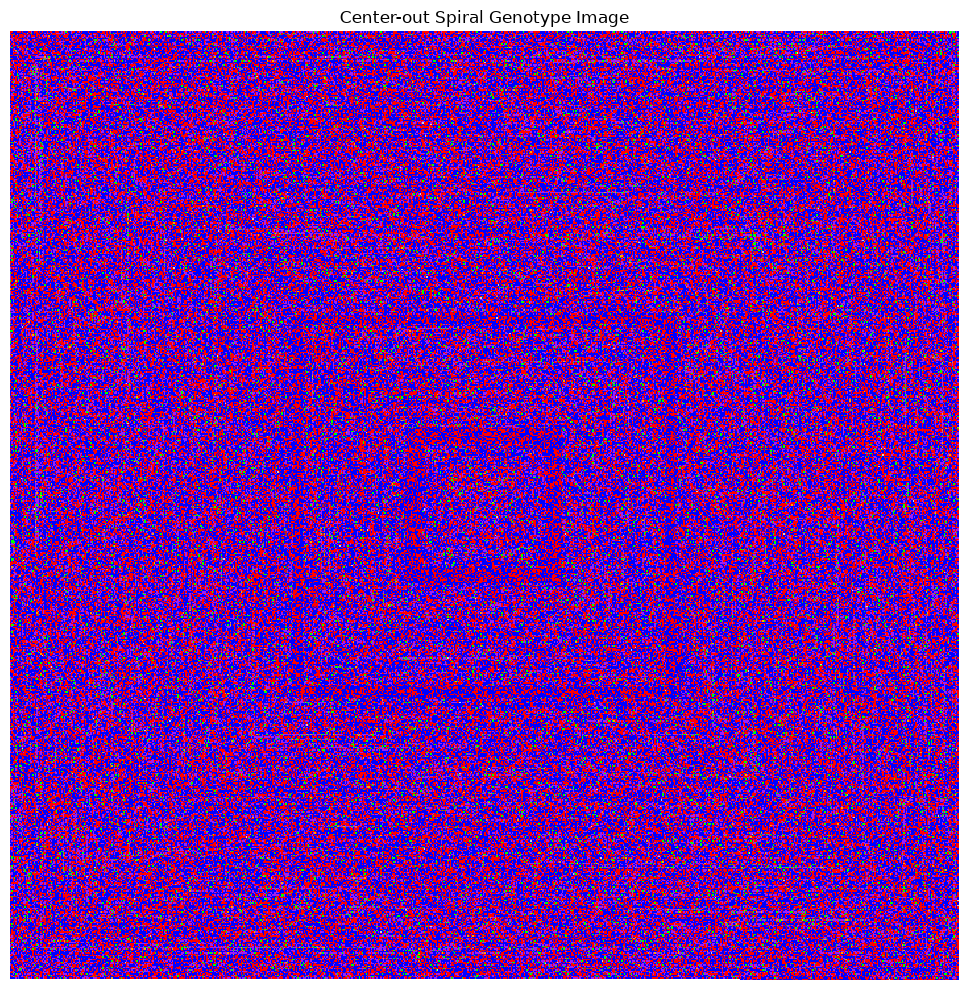

In [184]:
# ------------------------------------------------------------
# 1. 顯示完整720×720 RGB image
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 10)
)

plt.imshow(
    test_sample_rgb_image,
    interpolation="nearest"
)

plt.title(
    "Center-out Spiral Genotype Image"
)

# genomic image本身不需要座標軸
plt.axis("off")

plt.tight_layout()

plt.show()

In [185]:
# ============================================================
# 2. 放大中心31×31區域
# ============================================================
#
# 720×720的起始中心座標：
#
# Python 0-based
# (359, 359)
#
# 這裡取中心前後15格，
# 方便確認spiral pattern。
# ============================================================

center_row = 359
center_col = 359

zoom_radius = 15


center_zoom_rgb = (
    test_sample_rgb_image[
        center_row - zoom_radius:
        center_row + zoom_radius + 1,

        center_col - zoom_radius:
        center_col + zoom_radius + 1
    ]
)

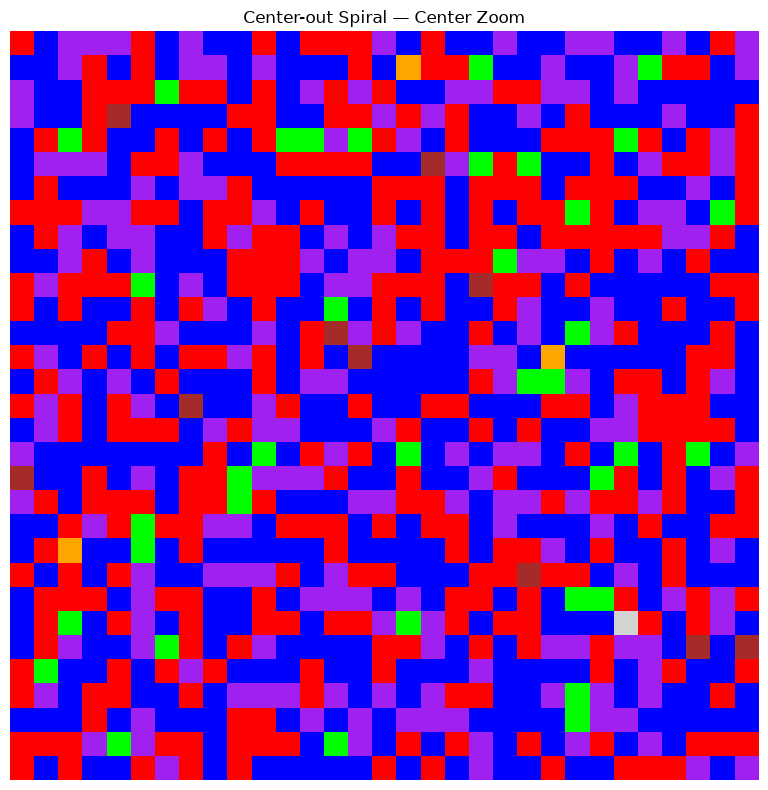

In [186]:
# ------------------------------------------------------------
# 3. 顯示中心放大圖
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 8)
)

plt.imshow(
    center_zoom_rgb,
    interpolation="nearest"
)

plt.title(
    "Center-out Spiral — Center Zoom"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [187]:
# ============================================================
# 4. 查看前15顆SNP的spiral座標與encoding
# ============================================================

first_15_spiral = (
    spiral_snp_mapping[
        [
            "new_snp_order",
            "Chr_id",
            "segment_id_chr_seg1mb",
            "variant_id",
            "spiral_row_py",
            "spiral_col_py"
        ]
    ]
    .head(15)
    .copy()
)


# 加上這一位subject的encoding code
first_15_spiral[
    "encoding_code"
] = (
    test_sample_codes[:15]
)


print(
    first_15_spiral.to_string(
        index=False
    )
)

 new_snp_order Chr_id  segment_id_chr_seg1mb   variant_id  spiral_row_py  spiral_col_py  encoding_code
             1      2                      2  AX-41057275            359            359              2
             2      2                      2 AX-213078854            359            360              2
             3      2                      2  AX-41057317            360            360              1
             4      2                      2 AX-113358539            360            359              3
             5      2                      2 AX-148556000            360            358              2
             6      2                      2  AX-33943771            359            358              1
             7      2                      2  AX-37909775            358            358              2
             8      2                      2 AX-113311527            358            359              2
             9      2                      2  AX-41057333            358 

建立 150 人的 720×720 spiral code matrices

In [188]:
# ============================================================
# Step 3-6：批次建立150人的720×720 Spiral Code Matrices
# ============================================================
#
# 輸出：
#
# all_sample_code_images
#
# shape =
# (150, 720, 720)
#
#
# 每一個subject：
# 720 × 720
#
# Code：
# 0 = Padding
# 1 = AA / TT
# 2 = CC / GG
# 3 = AG / CT
# 4 = AC / GT
# 5 = AT
# 6 = CG
# 7 = NoCall
#
#
# 優點：
# 每顆SNP只從.pgen讀一次，
# 一次處理150個subjects。
# ============================================================

import numpy as np
import time

In [189]:
# ------------------------------------------------------------
# 1. 建立150 × 720 × 720 code array
#
# 一開始全部設成0：
# 0 = Padding
# ------------------------------------------------------------

n_subjects = 150

all_sample_code_images = np.zeros(
    (
        n_subjects,
        spiral_size,
        spiral_size
    ),
    dtype=np.uint8
)


print(
    "Code image array shape =",
    all_sample_code_images.shape
)

print(
    "Memory size (MB) =",
    all_sample_code_images.nbytes
    /
    1024**2
)

Code image array shape = (150, 720, 720)
Memory size (MB) = 74.15771484375


In [190]:
# ============================================================
# 2. 根據REF / ALT建立該SNP的三種genotype encoding code
# ============================================================

def get_encoding_codes_for_variant(
    ref,
    alt
):
    """
    回傳：
        code_refref
        code_refalt
        code_altalt

    如果REF或ALT不是A/C/G/T，
    三種都回NoCall = 7。
    """

    ref = str(ref).upper()
    alt = str(alt).upper()

    valid_bases = {
        "A",
        "C",
        "G",
        "T"
    }


    #非ACGT variant
    if (
        ref not in valid_bases
        or
        alt not in valid_bases
    ):

        return 7, 7, 7


    #REF/REF
    genotype_refref = "".join(
        sorted(
            [ref, ref]
        )
    )


    #REF/ALT
    genotype_refalt = "".join(
        sorted(
            [ref, alt]
        )
    )


    #ALT/ALT
    genotype_altalt = "".join(
        sorted(
            [alt, alt]
        )
    )


    return (
        genotype_to_code[
            genotype_refref
        ],

        genotype_to_code[
            genotype_refalt
        ],

        genotype_to_code[
            genotype_altalt
        ]
    )

In [191]:
# ============================================================
# 3. 逐SNP讀取150人genotype並直接放進spiral
# ============================================================

geno_buffer = np.empty(
    n_subjects,
    dtype=np.int8
)


start_time = time.time()


for i, row in enumerate(
    spiral_snp_mapping.itertuples(
        index=False
    )
):


    # --------------------------------------------------------
    # 這顆SNP真正的PGEN row index
    # --------------------------------------------------------

    variant_index = int(
        row.true_pgen_index
    )


    # --------------------------------------------------------
    # 讀這顆SNP的150人genotype
    # --------------------------------------------------------

    pgen_reader.read(
        variant_index,
        geno_buffer
    )


    # --------------------------------------------------------
    # 取得這顆SNP三種hardcall對應的Encoding Code
    # --------------------------------------------------------

    (
        code_refref,
        code_refalt,
        code_altalt
    ) = get_encoding_codes_for_variant(
        row.REF,
        row.ALT
    )


    # --------------------------------------------------------
    # 一開始150人全部當NoCall
    #
    # 如果PGEN code不是0/1/2，
    # 就會保持7。
    # --------------------------------------------------------

    codes_now = np.full(
        n_subjects,
        7,
        dtype=np.uint8
    )


    #REF/REF
    codes_now[
        geno_buffer == 0
    ] = code_refref


    #REF/ALT
    codes_now[
        geno_buffer == 1
    ] = code_refalt


    #ALT/ALT
    codes_now[
        geno_buffer == 2
    ] = code_altalt


    # --------------------------------------------------------
    # 這顆SNP固定的spiral pixel
    # --------------------------------------------------------

    row_pixel = int(
        row.spiral_row_py
    )

    col_pixel = int(
        row.spiral_col_py
    )


    # --------------------------------------------------------
    # 一次把150人的code全部放進同一pixel位置
    # --------------------------------------------------------

    all_sample_code_images[
        :,
        row_pixel,
        col_pixel
    ] = codes_now


    # --------------------------------------------------------
    # 每50,000顆SNP顯示一次進度
    # --------------------------------------------------------

    if (
        (i + 1) % 50000 == 0
        or
        (i + 1) == len(
            spiral_snp_mapping
        )
    ):

        elapsed_min = (
            time.time()
            -
            start_time
        ) / 60


        print(
            f"SNP "
            f"{i + 1}/"
            f"{len(spiral_snp_mapping)} completed"
            f" | elapsed = {elapsed_min:.2f} min"
        )

SNP 50000/517846 completed | elapsed = 0.01 min
SNP 100000/517846 completed | elapsed = 0.01 min
SNP 150000/517846 completed | elapsed = 0.02 min
SNP 200000/517846 completed | elapsed = 0.03 min
SNP 250000/517846 completed | elapsed = 0.04 min
SNP 300000/517846 completed | elapsed = 0.04 min
SNP 350000/517846 completed | elapsed = 0.05 min
SNP 400000/517846 completed | elapsed = 0.05 min
SNP 450000/517846 completed | elapsed = 0.06 min
SNP 500000/517846 completed | elapsed = 0.07 min
SNP 517846/517846 completed | elapsed = 0.07 min


In [192]:
# ============================================================
# 4. 確認150張matrix
# ============================================================

print(
    "Final array shape =",
    all_sample_code_images.shape
)


# ------------------------------------------------------------
# 第1個subject
# ------------------------------------------------------------

sample0_codes, sample0_counts = np.unique(
    all_sample_code_images[0],
    return_counts=True
)


print(
    "\nSubject 1 encoding distribution:"
)

for code, count in zip(
    sample0_codes,
    sample0_counts
):

    print(
        "Code =",
        code,
        "| Count =",
        count
    )

Final array shape = (150, 720, 720)

Subject 1 encoding distribution:
Code = 0 | Count = 554
Code = 1 | Count = 176075
Code = 2 | Count = 245057
Code = 3 | Count = 73958
Code = 4 | Count = 16765
Code = 5 | Count = 1576
Code = 6 | Count = 4200
Code = 7 | Count = 215


In [193]:
# ============================================================
# 5. 確認150人的Padding數量完全一致
# ============================================================

padding_counts_150 = np.sum(
    all_sample_code_images == 0,
    axis=(1, 2)
)


print(
    "\nPadding count min =",
    padding_counts_150.min()
)

print(
    "Padding count max =",
    padding_counts_150.max()
)

print(
    "All subjects have 554 padding pixels =",
    np.all(
        padding_counts_150 == 554
    )
)


Padding count min = 554
Padding count max = 554
All subjects have 554 padding pixels = True


In [194]:
# ============================================================
# Step 3-7：讀取150人的PSAM sample order
# ============================================================
#
# 目的：
#
# 確認：
# .pgen中的第i個subject
# =
# .psam中的第i個subject
#
# 之後產生PNG時，
# 才能使用正確sample ID當檔名。
# ============================================================

import pandas as pd
from pathlib import Path

In [195]:
# ------------------------------------------------------------
# 1. PSAM路徑
# ------------------------------------------------------------

psam_path = (
    "/Users/sheenazhengmei/Desktop/data/"
    "talent_150_v9exact.psam"
)


# ------------------------------------------------------------
# 2. 讀取PSAM
#
# sep=r"\s+"
# 可以處理tab或空白分隔。
# ------------------------------------------------------------

psam_df = pd.read_csv(
    psam_path,
    sep=r"\s+",
    dtype=str
)


print(
    "PSAM shape =",
    psam_df.shape
)

print(
    "PSAM columns =",
    psam_df.columns.tolist()
)

print(
    "\nFirst 10 rows:"
)

print(
    psam_df.head(10)
)

PSAM shape = (150, 3)
PSAM columns = ['#FID', 'IID', 'SEX']

First 10 rows:
                              #FID          IID SEX
0  CT-01-00032_(Axiom_TPM)_E03.CEL  CT-01-00032   1
1  CT-01-00037_(Axiom_TPM)_F03.CEL  CT-01-00037   2
2  CT-01-00053_(Axiom_TPM)_C08.CEL  CT-01-00053   2
3  CT-01-00150_(Axiom_TPM)_C05.CEL  CT-01-00150   2
4  CT-01-00254_(Axiom_TPM)_C06.CEL  CT-01-00254   2
5  CT-01-00278_(Axiom_TPM)_G06.CEL  CT-01-00278   2
6  CT-01-00411_(Axiom_TPM)_B08.CEL  CT-01-00411   2
7  CT-01-00418_(Axiom_TPM)_C08.CEL  CT-01-00418   2
8  CT-01-00420_(Axiom_TPM)_D08.CEL  CT-01-00420   2
9  CT-01-00520_(Axiom_TPM)_F09.CEL  CT-01-00520   2


In [196]:
# ============================================================
# 3. 找sample ID欄位
# ============================================================
#
# PLINK2 PSAM常見：
#
# #FID IID ...
#
# 或：
#
# #IID ...
#
# 所以兩種都處理。
# ============================================================

if "IID" in psam_df.columns:

    iid_col = "IID"

elif "#IID" in psam_df.columns:

    iid_col = "#IID"

else:

    raise ValueError(
        "Cannot find IID column in PSAM."
    )


print(
    "IID column =",
    iid_col
)

IID column = IID


In [197]:
# ============================================================
# 4. 建立150人的正式sample ID順序
# ============================================================

sample_ids_psam = (
    psam_df[
        iid_col
    ]
    .astype(str)
    .tolist()
)


print(
    "Number of sample IDs =",
    len(sample_ids_psam)
)


print(
    "Unique sample IDs =",
    len(set(sample_ids_psam))
)


print(
    "\nFirst 10 sample IDs:"
)

for i, sample_id in enumerate(
    sample_ids_psam[:10],
    start=1
):

    print(
        i,
        sample_id
    )

Number of sample IDs = 150
Unique sample IDs = 150

First 10 sample IDs:
1 CT-01-00032
2 CT-01-00037
3 CT-01-00053
4 CT-01-00150
5 CT-01-00254
6 CT-01-00278
7 CT-01-00411
8 CT-01-00418
9 CT-01-00420
10 CT-01-00520


In [198]:
# ============================================================
# 5. 確認PSAM與影像數量完全一致
# ============================================================

print(
    "Subjects in PSAM =",
    len(sample_ids_psam)
)

print(
    "Subjects in code images =",
    all_sample_code_images.shape[0]
)


print(
    "Sample counts match =",
    len(sample_ids_psam)
    ==
    all_sample_code_images.shape[0]
)

Subjects in PSAM = 150
Subjects in code images = 150
Sample counts match = True


In [199]:
# ============================================================
# Step 3-8：批次產生150人的RGB Spiral PNG
# ============================================================
#
# 已有：
#
# all_sample_code_images
#   shape = (150, 720, 720)
#
# sample_ids_psam
#   150人的正確PSAM順序
#
# code_to_rgb
#   0~7 → RGB lookup table
#
#
# 這一步：
#
# 每位subject
# → 720×720 code matrix
# → 720×720×3 RGB
# → 儲存成PNG
#
#
# 每張圖片使用完全相同的：
#
# Segment arrangement
# Center-out spiral mapping
# Genotype color encoding
#
# 所以150人的pixel位置完全一致。
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import re

In [200]:
# ------------------------------------------------------------
# 1. 建立PNG輸出資料夾
# ------------------------------------------------------------

png_output_dir = Path(
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "centerout_spiral_rgb_150"
)


png_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "PNG output directory =",
    png_output_dir
)

PNG output directory = /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150


In [201]:
# ============================================================
# 2. 建立安全的PNG檔名
# ============================================================
#
# 如果sample ID含有：
#
# /
# :
# 空白
# 或其他特殊符號
#
# 可能影響檔案路徑。
#
# 所以只保留：
#
# 英文字母
# 數字
# -
# _
# .
# ============================================================

def make_safe_filename(sample_id):

    sample_id = str(
        sample_id
    )

    safe_id = re.sub(
        r"[^A-Za-z0-9_.-]",
        "_",
        sample_id
    )

    return safe_id

In [202]:
# ============================================================
# 3. 逐subject轉RGB並存成PNG
# ============================================================

saved_png_paths = []


for sample_index, sample_id in enumerate(
    sample_ids_psam
):

    # --------------------------------------------------------
    # 取出目前subject的720×720 Code Matrix
    # --------------------------------------------------------

    code_matrix = (
        all_sample_code_images[
            sample_index
        ]
    )


    # --------------------------------------------------------
    # Code 0~7
    # → RGB
    #
    # 結果shape：
    #
    # 720 × 720 × 3
    # --------------------------------------------------------

    rgb_image = (
        code_to_rgb[
            code_matrix
        ]
    )


    # --------------------------------------------------------
    # 建立安全檔名
    # --------------------------------------------------------

    safe_sample_id = (
        make_safe_filename(
            sample_id
        )
    )


    png_path = (
        png_output_dir
        /
        f"{safe_sample_id}.png"
    )


    # --------------------------------------------------------
    # NumPy RGB array
    # → PIL image
    # → PNG
    #
    # 不做resize
    # 不做interpolation
    # 不做compression-based image alteration
    #
    # 保持720×720原始pixel。
    # --------------------------------------------------------

    Image.fromarray(
        rgb_image,
        mode="RGB"
    ).save(
        png_path
    )


    saved_png_paths.append(
        png_path
    )


    # --------------------------------------------------------
    # 每10人顯示一次進度
    # --------------------------------------------------------

    if (
        (sample_index + 1) % 10 == 0
        or
        (sample_index + 1)
        ==
        len(sample_ids_psam)
    ):

        print(
            f"Saved "
            f"{sample_index + 1}/"
            f"{len(sample_ids_psam)} subjects"
        )

Saved 10/150 subjects
Saved 20/150 subjects
Saved 30/150 subjects
Saved 40/150 subjects
Saved 50/150 subjects
Saved 60/150 subjects
Saved 70/150 subjects
Saved 80/150 subjects
Saved 90/150 subjects
Saved 100/150 subjects
Saved 110/150 subjects
Saved 120/150 subjects
Saved 130/150 subjects
Saved 140/150 subjects
Saved 150/150 subjects


In [203]:
# ============================================================
# 4. 確認輸出的PNG數量
# ============================================================

png_files = sorted(
    png_output_dir.glob(
        "*.png"
    )
)


print(
    "Number of PNG files =",
    len(png_files)
)


print(
    "\nFirst 10 PNG files:"
)

for path in png_files[:10]:

    print(
        path.name
    )

Number of PNG files = 150

First 10 PNG files:
CT-01-00032.png
CT-01-00037.png
CT-01-00053.png
CT-01-00150.png
CT-01-00254.png
CT-01-00278.png
CT-01-00411.png
CT-01-00418.png
CT-01-00420.png
CT-01-00520.png


In [207]:
# ============================================================
# 6. 確認存檔前後pixel完全一致
# ============================================================
#
# 原本：
# all_sample_code_images[0]
# → code_to_rgb
#
# 存PNG後：
# 再讀回NumPy array
#
# 兩者每一個RGB pixel都必須完全相同。
# ============================================================

original_rgb_subject0 = (
    code_to_rgb[
        all_sample_code_images[0]
    ]
)


saved_rgb_subject0 = np.array(
    first_saved_image
)


print(
    "Original RGB shape =",
    original_rgb_subject0.shape
)

print(
    "Saved RGB shape =",
    saved_rgb_subject0.shape
)


print(
    "Maximum RGB difference =",
    np.abs(
        original_rgb_subject0.astype(int)
        -
        saved_rgb_subject0.astype(int)
    ).max()
)


print(
    "Pixel-perfect match =",
    np.array_equal(
        original_rgb_subject0,
        saved_rgb_subject0
    )
)

Original RGB shape = (720, 720, 3)
Saved RGB shape = (720, 720, 3)
Maximum RGB difference = 0
Pixel-perfect match = True


150 subjects
50 matched groups
每組：1 case + 2 controls
        ↓
重新建立 5-fold
matched group 不拆開
related groups 2 + 34 維持同一 fold
        ↓
每次：
90 Train
30 Validation
30 Test
        ↓
720×720 RGB
不 resize
不做 flip / rotation / crop
        ↓
ResNet18
        ↓
5-fold ROC-AUC
mean ± SD

In [208]:
# ============================================================
# Step 4-1：從零重新建立CNN Dataset Manifest
# ============================================================
#
# 注意：
#
# 這次Step 4重新開始。
#
# 舊CSV只拿：
#
# psam_IID
# label
# group_id
# case_control
#
# 不使用：
#
# fold
# fold_related
#
# 後面的5-fold會重新建立。
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path
import re

In [210]:
# ============================================================
# Step 4-1A：尋找原本的sample label CSV實際位置
# ============================================================
#
# 目前錯誤：
# FileNotFoundError
#
# 代表：
# Python指定的路徑下沒有這個檔案。
#
# 所以現在先從Desktop往下搜尋：
#
# V9_sample_labels_5fold_related.csv
#
# 這一步只找檔案，不做其他分析。
# ============================================================

from pathlib import Path


desktop_path = Path(
    "/Users/sheenazhengmei/Desktop"
)


target_filename = (
    "V9_sample_labels_5fold_related.csv"
)


found_files = list(
    desktop_path.rglob(
        target_filename
    )
)


print(
    "Number of matching files =",
    len(found_files)
)


for path in found_files:

    print(
        path
    )

Number of matching files = 1
/Users/sheenazhengmei/Desktop/DNA Image/V9_whole_genome_atlas_150/V9_sample_labels_5fold_related.csv


In [211]:
# ============================================================
# Step 4-1B：使用正確路徑重新讀取sample label CSV
# ============================================================
#
# 注意：
# DNA Image 中間有空白，
# 但放在Python字串裡不需要另外處理。
# ============================================================

import pandas as pd


label_path = (
    "/Users/sheenazhengmei/Desktop/"
    "DNA Image/"
    "V9_whole_genome_atlas_150/"
    "V9_sample_labels_5fold_related.csv"
)


label_source = pd.read_csv(
    label_path
)


# ------------------------------------------------------------
# 確認檔案成功讀取
# ------------------------------------------------------------

print(
    "Label table shape =",
    label_source.shape
)

print(
    "\nColumns:"
)

print(
    label_source.columns.tolist()
)

print(
    "\nFirst 5 rows:"
)

print(
    label_source.head()
)

Label table shape = (150, 11)

Columns:
['pgen_sample_index', 'match_id', 'psam_IID', 'original_id', 'case_control', 'group_id', 'fold', 'png_file', 'file_exists', 'label', 'fold_related']

First 5 rows:
   pgen_sample_index    match_id     psam_IID  original_id case_control  \
0                  1  CT01-00032  CT-01-00032  CT-01-00032      control   
1                  2  CT01-00037  CT-01-00037  CT-01-00037      control   
2                  3  CT01-00053  CT-01-00053  CT-01-00053      control   
3                  4  CT01-00150  CT-01-00150  CT-01-00150      control   
4                  5  CT01-00254  CT-01-00254  CT-01-00254      control   

   group_id  fold                                           png_file  \
0        35     1  /Users/sheenazhengmei/Desktop/V9_whole_genome_...   
1        19     2  /Users/sheenazhengmei/Desktop/V9_whole_genome_...   
2        13     3  /Users/sheenazhengmei/Desktop/V9_whole_genome_...   
3        23     5  /Users/sheenazhengmei/Desktop/V9_whole

In [212]:
# ============================================================
# Step 4-1C：重新建立乾淨的Dataset Manifest
# ============================================================
#
# 目的：
#
# 從原本label_source中，
# 只留下這次CNN真正需要的subject資訊。
#
# 舊的：
# fold
# fold_related
#
# 都不帶進新的dataset_manifest。
# ============================================================


# ------------------------------------------------------------
# 1. 只保留需要的4個欄位
# ------------------------------------------------------------

dataset_manifest = (
    label_source[
        [
            "psam_IID",
            "case_control",
            "label",
            "group_id"
        ]
    ]
    .copy()
)


print(
    "Dataset manifest shape =",
    dataset_manifest.shape
)


print(
    "\nColumns =",
    dataset_manifest.columns.tolist()
)

Dataset manifest shape = (150, 4)

Columns = ['psam_IID', 'case_control', 'label', 'group_id']


In [213]:
# ============================================================
# 2. 統一欄位資料型態
# ============================================================
#
# psam_IID：
# 使用字串，避免sample ID被Python當成數字。
#
# label：
# 0 = control
# 1 = case
#
# group_id：
# matched group編號。
# ============================================================

dataset_manifest[
    "psam_IID"
] = (
    dataset_manifest[
        "psam_IID"
    ]
    .astype(str)
)


dataset_manifest[
    "label"
] = (
    dataset_manifest[
        "label"
    ]
    .astype(int)
)


dataset_manifest[
    "group_id"
] = (
    dataset_manifest[
        "group_id"
    ]
    .astype(int)
)

In [214]:
# ============================================================
# 3. Subject數量QC
# ============================================================

print(
    "Number of rows =",
    len(dataset_manifest)
)


print(
    "Unique subjects =",
    dataset_manifest[
        "psam_IID"
    ].nunique()
)

Number of rows = 150
Unique subjects = 150


In [215]:
# ============================================================
# 4. Case / Control QC
# ============================================================

print(
    "\nLabel distribution:"
)


print(
    dataset_manifest[
        "label"
    ]
    .value_counts()
    .sort_index()
)



Label distribution:
label
0    100
1     50
Name: count, dtype: int64


In [216]:
# ============================================================
# 5. 檢查50個matched groups
# ============================================================
#
# 每個group理論上：
#
# 3 subjects
# 1 case
# 2 controls
# ============================================================

group_qc = (
    dataset_manifest
    .groupby(
        "group_id"
    )
    .agg(

        n_subjects=(
            "psam_IID",
            "size"
        ),

        n_case=(
            "label",
            "sum"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# control人數 =
# group總人數 - case人數
# ------------------------------------------------------------

group_qc[
    "n_control"
] = (
    group_qc[
        "n_subjects"
    ]
    -
    group_qc[
        "n_case"
    ]
)


print(
    "Number of matched groups =",
    len(group_qc)
)


print(
    "\nMatched-group composition:"
)


print(
    group_qc[
        [
            "n_subjects",
            "n_case",
            "n_control"
        ]
    ]
    .value_counts()
)

Number of matched groups = 50

Matched-group composition:
n_subjects  n_case  n_control
3           1       2            50
Name: count, dtype: int64


In [217]:
# ============================================================
# 6. 最終Dataset Manifest QC
# ============================================================

all_groups_valid = (
    (
        group_qc[
            "n_subjects"
        ] == 3
    )
    &
    (
        group_qc[
            "n_case"
        ] == 1
    )
    &
    (
        group_qc[
            "n_control"
        ] == 2
    )
).all()


print(
    "\nTotal subjects =",
    len(dataset_manifest)
)


print(
    "Unique subjects =",
    dataset_manifest[
        "psam_IID"
    ].nunique()
)


print(
    "Matched groups =",
    dataset_manifest[
        "group_id"
    ].nunique()
)


print(
    "All matched groups valid =",
    all_groups_valid
)


Total subjects = 150
Unique subjects = 150
Matched groups = 50
All matched groups valid = True


In [218]:
# ============================================================
# Step 4-1D：把新版Center-out Spiral PNG加入dataset_manifest
# ============================================================
#
# 目的：
#
# 每個psam_IID
# ↓
# 對到自己的PNG
#
# 最後確認：
#
# 150 subjects
# 150 PNG
# 0 missing
#
# ============================================================

from pathlib import Path
import re

In [219]:
# ------------------------------------------------------------
# 1. 指定新版PNG資料夾
# ------------------------------------------------------------

png_dir = Path(
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "centerout_spiral_rgb_150"
)


print(
    "PNG directory =",
    png_dir
)

print(
    "Directory exists =",
    png_dir.exists()
)

PNG directory = /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150
Directory exists = True


In [220]:
# ============================================================
# 2. 建立sample ID → PNG filename規則
# ============================================================
#
# 存PNG時有把特殊符號替換成 "_"，
# 所以這裡必須使用相同規則。
# ============================================================

def make_safe_filename(sample_id):

    return re.sub(
        r"[^A-Za-z0-9_.-]",
        "_",
        str(sample_id)
    )

In [221]:
# ============================================================
# 3. 建立每位subject的PNG完整路徑
# ============================================================

dataset_manifest[
    "png_file"
] = (
    dataset_manifest[
        "psam_IID"
    ]
    .apply(
        lambda sample_id:
        str(
            png_dir
            /
            f"{make_safe_filename(sample_id)}.png"
        )
    )
)

In [222]:
# ============================================================
# 4. 檢查每位subject的PNG是否存在
# ============================================================

dataset_manifest[
    "png_exists"
] = (
    dataset_manifest[
        "png_file"
    ]
    .apply(
        lambda path:
        Path(path).exists()
    )
)


print(
    "Total subjects =",
    len(dataset_manifest)
)

print(
    "PNG found =",
    dataset_manifest[
        "png_exists"
    ].sum()
)

print(
    "PNG missing =",
    (
        ~dataset_manifest[
            "png_exists"
        ]
    ).sum()
)

Total subjects = 150
PNG found = 150
PNG missing = 0


In [223]:
# ============================================================
# 5. 查看前10位subject與圖片路徑
# ============================================================

print(
    dataset_manifest[
        [
            "psam_IID",
            "label",
            "group_id",
            "png_file",
            "png_exists"
        ]
    ]
    .head(10)
    .to_string(
        index=False
    )
)

   psam_IID  label  group_id                                                                                       png_file  png_exists
CT-01-00032      0        35 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00032.png        True
CT-01-00037      0        19 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00037.png        True
CT-01-00053      0        13 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00053.png        True
CT-01-00150      0        23 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00150.png        True
CT-01-00254      0        16 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00254.png        True
CT-01-00278      0        45 /Users/sheenazhengmei/Desktop/segment_haplotype_step2/centerout_spiral_rgb_150/CT-01-00278.png        True
CT-01-00411      0         2 /Users/sheenazhengm

In [224]:
# ============================================================
# 6. 最終PNG mapping QC
# ============================================================

print(
    "\nUnique subjects =",
    dataset_manifest[
        "psam_IID"
    ].nunique()
)


print(
    "Unique PNG paths =",
    dataset_manifest[
        "png_file"
    ].nunique()
)


print(
    "All PNGs found =",
    dataset_manifest[
        "png_exists"
    ].all()
)


Unique subjects = 150
Unique PNG paths = 150
All PNGs found = True


5-fold matched split

In [225]:
# ============================================================
# Step 4-2：從零重新建立5-fold matched split
# ============================================================
#
# 重要原則：
#
# 1. 以group_id為單位分fold
#    → matched subjects不能被拆開
#
# 2. 每個fold：
#    10 matched groups
#    30 subjects
#    10 cases
#    20 controls
#
# 3. 已知related groups：
#    group 2 + group 34
#    必須在同一個fold
#
# 4. 完全不使用舊的fold / fold_related
#
# 5. 固定random seed，
#    之後重跑會得到完全一樣的結果。
# ============================================================

import numpy as np
import pandas as pd

In [226]:
# ------------------------------------------------------------
# 1. 取得目前所有matched group ID
# ------------------------------------------------------------

all_group_ids = sorted(
    dataset_manifest[
        "group_id"
    ]
    .unique()
)


print(
    "Number of matched groups =",
    len(all_group_ids)
)


print(
    "Group IDs =",
    all_group_ids
)

Number of matched groups = 50
Group IDs = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


In [227]:
# ============================================================
# 2. 設定固定random seed與related groups
# ============================================================

RANDOM_SEED = 20260909

rng = np.random.default_rng(
    RANDOM_SEED
)


# 已知有relatedness的兩個matched groups
related_groups = [
    2,
    34
]


# 確認這兩個group真的存在
for g in related_groups:

    if g not in all_group_ids:

        raise ValueError(
            f"Related group {g} not found."
        )

In [228]:
# ============================================================
# 3. 先取出group 2與34
# ============================================================
#
# 這兩個group後面會一起放入同一fold。
# ============================================================

remaining_groups = [
    g
    for g in all_group_ids
    if g not in related_groups
]


remaining_groups = np.array(
    remaining_groups,
    dtype=int
)


# 隨機打亂其他48個matched groups
rng.shuffle(
    remaining_groups
)


print(
    "Remaining groups =",
    len(remaining_groups)
)

Remaining groups = 48


In [229]:
# ============================================================
# 4. 隨機決定related pair放入哪個fold
# ============================================================

related_pair_fold = int(
    rng.integers(
        1,
        6
    )
)


print(
    "Groups 2 and 34 will be assigned to Fold",
    related_pair_fold
)

Groups 2 and 34 will be assigned to Fold 5


In [230]:
# ============================================================
# 5. 建立每個fold的group清單
# ============================================================

fold_groups = {
    1: [],
    2: [],
    3: [],
    4: [],
    5: []
}


# ------------------------------------------------------------
# 先把group 2與34放進同一fold
# ------------------------------------------------------------

fold_groups[
    related_pair_fold
].extend(
    related_groups
)


# ------------------------------------------------------------
# 計算每個fold還需要多少group
# ------------------------------------------------------------

fold_capacity = {
    fold: (
        10
        -
        len(
            fold_groups[
                fold
            ]
        )
    )
    for fold in range(
        1,
        6
    )
}


print(
    "Remaining capacity per fold =",
    fold_capacity
)

Remaining capacity per fold = {1: 10, 2: 10, 3: 10, 4: 10, 5: 8}


In [231]:
# ============================================================
# 6. 將其他48個groups依序填入各fold
# ============================================================

current_index = 0


for fold in range(
    1,
    6
):

    n_needed = (
        fold_capacity[
            fold
        ]
    )


    groups_now = (
        remaining_groups[
            current_index:
            current_index
            +
            n_needed
        ]
        .tolist()
    )


    fold_groups[
        fold
    ].extend(
        groups_now
    )


    current_index += (
        n_needed
    )

In [232]:
# ============================================================
# 7. 查看新的5-fold group assignment
# ============================================================

for fold in range(
    1,
    6
):

    fold_groups[
        fold
    ] = sorted(
        fold_groups[
            fold
        ]
    )


    print(
        f"Fold {fold}:",
        fold_groups[
            fold
        ],
        "| n_groups =",
        len(
            fold_groups[
                fold
            ]
        )
    )

Fold 1: [18, 22, 26, 27, 30, 37, 38, 40, 42, 46] | n_groups = 10
Fold 2: [1, 13, 15, 25, 32, 35, 41, 43, 47, 50] | n_groups = 10
Fold 3: [3, 10, 11, 23, 24, 31, 33, 39, 44, 45] | n_groups = 10
Fold 4: [5, 8, 9, 12, 14, 16, 21, 29, 48, 49] | n_groups = 10
Fold 5: [2, 4, 6, 7, 17, 19, 20, 28, 34, 36] | n_groups = 10


In [233]:
# ============================================================
# 8. 建立group_id → new_fold mapping
# ============================================================

group_to_fold = {}


for fold, groups in fold_groups.items():

    for group_id in groups:

        group_to_fold[
            group_id
        ] = fold

In [234]:
# ============================================================
# 9. 將新的fold加回150人的dataset_manifest
# ============================================================

dataset_manifest[
    "new_fold"
] = (
    dataset_manifest[
        "group_id"
    ]
    .map(
        group_to_fold
    )
)


# 確保沒有任何group沒有被分配
if dataset_manifest[
    "new_fold"
].isna().any():

    raise ValueError(
        "Some subjects were not assigned to a fold."
    )


dataset_manifest[
    "new_fold"
] = (
    dataset_manifest[
        "new_fold"
    ]
    .astype(int)
)

In [235]:
# ============================================================
# 10. 每個fold的subject / case / control分布
# ============================================================

fold_subject_qc = (
    dataset_manifest
    .groupby(
        [
            "new_fold",
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


print(
    "\nSubjects per fold:"
)

print(
    fold_subject_qc
)


Subjects per fold:
label      0   1
new_fold        
1         20  10
2         20  10
3         20  10
4         20  10
5         20  10


In [236]:
# ============================================================
# 11. 每個fold的matched group數量
# ============================================================

fold_group_qc = (
    dataset_manifest
    .groupby(
        "new_fold"
    )[
        "group_id"
    ]
    .nunique()
)


print(
    "\nMatched groups per fold:"
)

print(
    fold_group_qc
)


Matched groups per fold:
new_fold
1    10
2    10
3    10
4    10
5    10
Name: group_id, dtype: int64


In [237]:
# ============================================================
# 12. Relatedness QC
# ============================================================

relatedness_qc = (
    dataset_manifest[
        dataset_manifest[
            "group_id"
        ]
        .isin(
            related_groups
        )
    ][
        [
            "group_id",
            "new_fold"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "group_id"
    )
)


print(
    "\nRelated groups:"
)

print(
    relatedness_qc.to_string(
        index=False
    )
)


same_related_fold = (
    relatedness_qc[
        "new_fold"
    ]
    .nunique()
    == 1
)


print(
    "\nGroups 2 and 34 in same fold =",
    same_related_fold
)


Related groups:
 group_id  new_fold
        2         5
       34         5

Groups 2 and 34 in same fold = True


In [238]:
# ============================================================
# 13. 最終5-fold QC
# ============================================================

groups_per_fold = (
    dataset_manifest
    .groupby(
        "new_fold"
    )[
        "group_id"
    ]
    .nunique()
)


subjects_per_fold = (
    dataset_manifest
    .groupby(
        "new_fold"
    )
    .size()
)


cases_per_fold = (
    dataset_manifest
    .groupby(
        "new_fold"
    )[
        "label"
    ]
    .sum()
)


controls_per_fold = (
    subjects_per_fold
    -
    cases_per_fold
)


print(
    "All folds have 10 groups =",
    (
        groups_per_fold
        == 10
    ).all()
)


print(
    "All folds have 30 subjects =",
    (
        subjects_per_fold
        == 30
    ).all()
)


print(
    "All folds have 10 cases =",
    (
        cases_per_fold
        == 10
    ).all()
)


print(
    "All folds have 20 controls =",
    (
        controls_per_fold
        == 20
    ).all()
)


print(
    "Groups 2 and 34 stay together =",
    same_related_fold
)

All folds have 10 groups = True
All folds have 30 subjects = True
All folds have 10 cases = True
All folds have 20 controls = True
Groups 2 and 34 stay together = True


50 個 matched groups
每個 group = 1 case + 2 controls
每個 fold = 10 groups = 30 subjects
因此每個 fold 都會剛好有 10 cases + 20 controls
group 2 和 group 34 維持在同一個 fold

In [239]:
# ============================================================
# Step 4-2：重新建立全新的5-fold matched split
# ============================================================
#
# 規則：
#
# 50 matched groups
# ↓
# 分成5 folds
#
# 每個fold：
# 10 matched groups
# = 30 subjects
# = 10 cases + 20 controls
#
#
# 額外限制：
#
# group 2
# group 34
#
# 因為有relatedness，
# 必須被分到同一個fold。
#
#
# 這次完全不使用舊fold。
# 新欄位名稱：
#
# fold_new
# ============================================================

import numpy as np
import pandas as pd

In [240]:
# ------------------------------------------------------------
# 1. 抓出所有unique matched group IDs
# ------------------------------------------------------------

all_group_ids = np.array(
    sorted(
        dataset_manifest[
            "group_id"
        ].unique()
    )
)


print(
    "Number of matched groups =",
    len(all_group_ids)
)


print(
    "Group IDs =",
    all_group_ids
)

Number of matched groups = 50
Group IDs = [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


related group放在同一個fold

In [241]:
# ============================================================
# 2. Related groups設定
# ============================================================
#
# group 2 和 group 34
# 必須進入同一個fold。
# ============================================================

related_groups = [
    2,
    34
]


# ------------------------------------------------------------
# 確認這兩個group真的存在於目前資料
# ------------------------------------------------------------

for group_id in related_groups:

    if group_id not in all_group_ids:

        raise ValueError(
            f"Related group {group_id} "
            f"not found in dataset."
        )


print(
    "Related groups =",
    related_groups
)

Related groups = [2, 34]


In [242]:
# ============================================================
# 3. 固定random seed
# ============================================================
#
# 只要seed不改，
# 每次執行都會得到完全相同的fold。
# ============================================================

random_seed = 20260909


rng = np.random.default_rng(
    random_seed
)


print(
    "Random seed =",
    random_seed
)

Random seed = 20260909


In [243]:
# ============================================================
# 4. Related groups先從一般group pool移除
# ============================================================

remaining_groups = np.array(
    [
        group_id
        for group_id in all_group_ids
        if group_id not in related_groups
    ]
)


print(
    "Remaining groups before shuffle =",
    len(remaining_groups)
)

Remaining groups before shuffle = 48


In [244]:
# ------------------------------------------------------------
# 隨機打亂其餘48個matched groups
# ------------------------------------------------------------

rng.shuffle(
    remaining_groups
)


print(
    "Remaining groups after shuffle =",
    remaining_groups
)

Remaining groups after shuffle = [38 42 40 18 37 26 27 30 46 22  1 41 35 25 15 50 13 43 32 47 10 31 24 39
 33  3 45 11 44 23  8  9 49 12  5 29 48 14 16 21  7 19 36  6 17  4 28 20]


In [245]:
# ============================================================
# 5. 隨機決定group 2 + 34所在fold
# ============================================================

related_fold = int(
    rng.integers(
        1,
        6
    )
)


print(
    "Related groups 2 and 34 assigned to Fold =",
    related_fold
)

Related groups 2 and 34 assigned to Fold = 5


In [246]:
# ============================================================
# 6. 建立5個fold的group assignment
# ============================================================

fold_groups = {
    1: [],
    2: [],
    3: [],
    4: [],
    5: []
}


# ------------------------------------------------------------
# 先把related groups一起放入同一fold
# ------------------------------------------------------------

fold_groups[
    related_fold
] = related_groups.copy()


# ------------------------------------------------------------
# 用pointer依序從打亂後的remaining_groups取group
# ------------------------------------------------------------

pointer = 0


for fold_id in range(
    1,
    6
):

    # --------------------------------------------------------
    # 如果是related pair所在fold：
    # 已經有2 groups，所以只需要再補8 groups
    #
    # 其他fold：
    # 需要10 groups
    # --------------------------------------------------------

    n_needed = (
        10
        -
        len(
            fold_groups[
                fold_id
            ]
        )
    )


    selected_groups = (
        remaining_groups[
            pointer:
            pointer + n_needed
        ]
        .tolist()
    )


    fold_groups[
        fold_id
    ].extend(
        selected_groups
    )


    pointer += n_needed

In [247]:
# ============================================================
# 7. 顯示每個fold的matched groups
# ============================================================

for fold_id in range(
    1,
    6
):

    print(
        f"\nFold {fold_id}:"
    )

    print(
        sorted(
            fold_groups[
                fold_id
            ]
        )
    )

    print(
        "Number of groups =",
        len(
            fold_groups[
                fold_id
            ]
        )
    )


Fold 1:
[18, 22, 26, 27, 30, 37, 38, 40, 42, 46]
Number of groups = 10

Fold 2:
[1, 13, 15, 25, 32, 35, 41, 43, 47, 50]
Number of groups = 10

Fold 3:
[3, 10, 11, 23, 24, 31, 33, 39, 44, 45]
Number of groups = 10

Fold 4:
[5, 8, 9, 12, 14, 16, 21, 29, 48, 49]
Number of groups = 10

Fold 5:
[2, 4, 6, 7, 17, 19, 20, 28, 34, 36]
Number of groups = 10


In [248]:
# ============================================================
# 8. 建立group_id → fold_new對照
# ============================================================

group_to_fold = {}


for fold_id, group_list in (
    fold_groups.items()
):

    for group_id in group_list:

        group_to_fold[
            group_id
        ] = fold_id

In [249]:
# ------------------------------------------------------------
# 把fold_new加進dataset_manifest
# ------------------------------------------------------------

dataset_manifest[
    "fold_new"
] = (
    dataset_manifest[
        "group_id"
    ]
    .map(
        group_to_fold
    )
)

In [250]:
# ============================================================
# 9. 檢查每個fold的人數、case/control與group數
# ============================================================

fold_qc = (
    dataset_manifest
    .groupby(
        "fold_new"
    )
    .agg(

        n_subjects=(
            "psam_IID",
            "size"
        ),

        n_groups=(
            "group_id",
            "nunique"
        ),

        n_cases=(
            "label",
            "sum"
        )
    )
    .reset_index()
)


fold_qc[
    "n_controls"
] = (
    fold_qc[
        "n_subjects"
    ]
    -
    fold_qc[
        "n_cases"
    ]
)


print(
    fold_qc.to_string(
        index=False
    )
)

 fold_new  n_subjects  n_groups  n_cases  n_controls
        1          30        10       10          20
        2          30        10       10          20
        3          30        10       10          20
        4          30        10       10          20
        5          30        10       10          20


In [251]:
# ============================================================
# 10. Relatedness QC
# ============================================================

related_qc = (
    dataset_manifest[
        dataset_manifest[
            "group_id"
        ].isin(
            related_groups
        )
    ][
        [
            "psam_IID",
            "group_id",
            "label",
            "fold_new"
        ]
    ]
    .sort_values(
        [
            "group_id",
            "psam_IID"
        ]
    )
)


print(
    related_qc.to_string(
        index=False
    )
)


print(
    "\nNumber of folds containing groups 2 and 34 =",
    related_qc[
        "fold_new"
    ].nunique()
)

   psam_IID  group_id  label  fold_new
CT-01-00411         2      0         5
CT-04-00187         2      0         5
 CT04-00637         2      1         5
CT-06-00054        34      0         5
CT-09-00225        34      0         5
 CT01-00294        34      1         5

Number of folds containing groups 2 and 34 = 1


In [252]:
# ============================================================
# 11. 最終5-fold QC
# ============================================================

print(
    "Missing fold assignments =",
    dataset_manifest[
        "fold_new"
    ].isna().sum()
)


print(
    "Number of folds =",
    dataset_manifest[
        "fold_new"
    ].nunique()
)


print(
    "Subjects per fold ="
)

print(
    dataset_manifest[
        "fold_new"
    ]
    .value_counts()
    .sort_index()
)

Missing fold assignments = 0
Number of folds = 5
Subjects per fold =
fold_new
1    30
2    30
3    30
4    30
5    30
Name: count, dtype: int64


Train
3 folds
= 90 subjects
= 30 cases + 60 controls

Validation
1 fold
= 30 subjects
= 10 cases + 20 controls

Test
1 fold
= 30 subjects
= 10 cases + 20 controls

In [253]:
# ============================================================
# Step 4-2A：建立5-fold Train / Validation / Test Rotation
# ============================================================
#
# 規則：
#
# Run 1:
# Test = Fold 1
# Val  = Fold 2
# Train = Fold 3,4,5
#
# Run 2:
# Test = Fold 2
# Val  = Fold 3
# Train = Fold 4,5,1
#
# ...
#
# 每個Fold都會：
#
# 當Test一次
# 當Validation一次
# 當Train三次
# ============================================================

fold_rotation = [
    {
        "run": 1,
        "train_folds": [3, 4, 5],
        "val_fold": 2,
        "test_fold": 1
    },

    {
        "run": 2,
        "train_folds": [4, 5, 1],
        "val_fold": 3,
        "test_fold": 2
    },

    {
        "run": 3,
        "train_folds": [5, 1, 2],
        "val_fold": 4,
        "test_fold": 3
    },

    {
        "run": 4,
        "train_folds": [1, 2, 3],
        "val_fold": 5,
        "test_fold": 4
    },

    {
        "run": 5,
        "train_folds": [2, 3, 4],
        "val_fold": 1,
        "test_fold": 5
    }
]

In [254]:
# ============================================================
# Step 4-2：重新建立新的5-fold matched split
# ============================================================
#
# 規則：
#
# 1. 總共有50個matched groups
# 2. 每個group有：
#       1 case
#       2 controls
#
# 3. 每一fold放10個完整groups
#
#    因此每fold一定會有：
#       30 subjects
#       10 cases
#       20 controls
#
# 4. matched group不能被拆開
#
# 5. related groups：
#       group 2
#       group 34
#
#    必須放在同一fold
#
# 6. 使用固定random seed，
#    讓之後重新執行得到完全相同的fold。
# ============================================================

import numpy as np
import pandas as pd

In [255]:
# ------------------------------------------------------------
# 1. 取得所有matched group ID
# ------------------------------------------------------------

all_group_ids = sorted(
    dataset_manifest[
        "group_id"
    ]
    .unique()
)


print(
    "Number of matched groups =",
    len(all_group_ids)
)


print(
    "Group IDs =",
    all_group_ids
)

Number of matched groups = 50
Group IDs = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


In [256]:
# ============================================================
# 2. 指定不能被分到不同fold的related groups
# ============================================================

related_groups = [
    2,
    34
]


# ------------------------------------------------------------
# 先確認這兩個group真的存在
# ------------------------------------------------------------

for group_id in related_groups:

    if group_id not in all_group_ids:

        raise ValueError(
            f"Related group {group_id} "
            f"does not exist in dataset_manifest."
        )


print(
    "Related groups =",
    related_groups
)

Related groups = [2, 34]


In [257]:
# ============================================================
# 3. 將group 2與34先拿出來
# ============================================================
#
# 剩下48個groups再進行random shuffle。
#
# random seed固定後，
# 每次執行都會得到相同結果。
# ============================================================

remaining_groups = [
    group_id
    for group_id in all_group_ids
    if group_id not in related_groups
]


print(
    "Remaining groups =",
    len(remaining_groups)
)

Remaining groups = 48


In [258]:
# ------------------------------------------------------------
# 4. 固定random seed並shuffle
# ------------------------------------------------------------

random_seed_fold = 20260909


rng = np.random.default_rng(
    random_seed_fold
)


rng.shuffle(
    remaining_groups
)


print(
    "Random seed =",
    random_seed_fold
)

print(
    "First 10 shuffled groups =",
    remaining_groups[:10]
)

Random seed = 20260909
First 10 shuffled groups = [np.int64(38), np.int64(42), np.int64(40), np.int64(18), np.int64(37), np.int64(26), np.int64(27), np.int64(30), np.int64(46), np.int64(22)]


In [259]:
# ============================================================
# 5. 建立5個fold的group配置
# ============================================================

fold_groups = {}


# ------------------------------------------------------------
# Fold 1：
#
# related groups 2與34
# +
# 前8個random groups
#
# 合計10 groups
# ------------------------------------------------------------

fold_groups[1] = (
    related_groups
    +
    remaining_groups[:8]
)


# ------------------------------------------------------------
# 剩餘40個groups
# ------------------------------------------------------------

remaining_after_fold1 = (
    remaining_groups[8:]
)


# ------------------------------------------------------------
# Fold 2~5：
#
# 每fold各10 groups
# ------------------------------------------------------------

for fold_id in range(
    2,
    6
):

    start = (
        fold_id - 2
    ) * 10

    end = (
        start + 10
    )

    fold_groups[
        fold_id
    ] = (
        remaining_after_fold1[
            start:end
        ]
    )

In [260]:
# ============================================================
# 6. 查看新的5-fold group分配
# ============================================================

for fold_id in range(
    1,
    6
):

    print(
        f"\nFold {fold_id}:"
    )

    print(
        sorted(
            fold_groups[
                fold_id
            ]
        )
    )

    print(
        "Number of groups =",
        len(
            fold_groups[
                fold_id
            ]
        )
    )


Fold 1:
[2, np.int64(18), np.int64(26), np.int64(27), np.int64(30), 34, np.int64(37), np.int64(38), np.int64(40), np.int64(42)]
Number of groups = 10

Fold 2:
[np.int64(1), np.int64(13), np.int64(15), np.int64(22), np.int64(25), np.int64(35), np.int64(41), np.int64(43), np.int64(46), np.int64(50)]
Number of groups = 10

Fold 3:
[np.int64(3), np.int64(10), np.int64(11), np.int64(24), np.int64(31), np.int64(32), np.int64(33), np.int64(39), np.int64(45), np.int64(47)]
Number of groups = 10

Fold 4:
[np.int64(5), np.int64(8), np.int64(9), np.int64(12), np.int64(14), np.int64(23), np.int64(29), np.int64(44), np.int64(48), np.int64(49)]
Number of groups = 10

Fold 5:
[np.int64(4), np.int64(6), np.int64(7), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(28), np.int64(36)]
Number of groups = 10


In [261]:
# ============================================================
# 7. 建立group → fold mapping
# ============================================================

group_to_fold = {}


for fold_id, groups in fold_groups.items():

    for group_id in groups:

        group_to_fold[
            group_id
        ] = fold_id

In [263]:
# ------------------------------------------------------------
# 8. 將新的fold加回dataset_manifest
# ------------------------------------------------------------
#
# 新欄位名稱：
#
# fold_new
#
# 明確和舊fold區分。
# ------------------------------------------------------------

dataset_manifest[
    "fold_new"
] = (
    dataset_manifest[
        "group_id"
    ]
    .map(
        group_to_fold
    )
)

In [264]:
# ============================================================
# 9. 確認150人都有fold
# ============================================================

print(
    "Subjects with fold =",
    dataset_manifest[
        "fold_new"
    ]
    .notna()
    .sum()
)


print(
    "Subjects missing fold =",
    dataset_manifest[
        "fold_new"
    ]
    .isna()
    .sum()
)

Subjects with fold = 150
Subjects missing fold = 0


In [265]:
# ============================================================
# 10. 檢查每fold的case / control組成
# ============================================================

fold_subject_qc = (
    dataset_manifest
    .groupby(
        [
            "fold_new",
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


print(
    "\nSubjects per fold:"
)

print(
    fold_subject_qc
)


Subjects per fold:
label      0   1
fold_new        
1         20  10
2         20  10
3         20  10
4         20  10
5         20  10


In [266]:
# ============================================================
# 11. 檢查每fold的matched group數量
# ============================================================

fold_group_qc = (
    dataset_manifest
    .groupby(
        "fold_new"
    )[
        "group_id"
    ]
    .nunique()
)


print(
    "\nMatched groups per fold:"
)

print(
    fold_group_qc
)


Matched groups per fold:
fold_new
1    10
2    10
3    10
4    10
5    10
Name: group_id, dtype: int64


In [267]:
# ============================================================
# 12. 確認related groups 2與34位於同一fold
# ============================================================

related_group_check = (
    dataset_manifest[
        dataset_manifest[
            "group_id"
        ]
        .isin(
            related_groups
        )
    ]
    [
        [
            "group_id",
            "fold_new"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "group_id"
    )
)


print(
    "\nRelated-group fold assignment:"
)

print(
    related_group_check.to_string(
        index=False
    )
)


Related-group fold assignment:
 group_id  fold_new
        2         1
       34         1


In [269]:
# ============================================================
# Step 4-2A：重新建立全新的5-fold matched split
# ============================================================
#
# 規則：
#
# 1. 完全不使用舊fold
#
# 2. 50個matched groups重新隨機分成5 folds
#
# 3. 每個fold固定：
#    10 groups
#    30 subjects
#    10 cases
#    20 controls
#
# 4. related group 2與34必須放在同一fold
#
# 5. 使用固定random seed，
#    確保之後重新執行可以得到完全相同的split。
# ============================================================

import numpy as np
import pandas as pd

In [270]:
# ------------------------------------------------------------
# 1. 固定random seed
# ------------------------------------------------------------

random_seed = 20260909

rng = np.random.default_rng(
    random_seed
)

In [271]:
# ============================================================
# 2. 取得50個matched group IDs
# ============================================================

all_group_ids = np.array(
    sorted(
        dataset_manifest[
            "group_id"
        ].unique()
    ),
    dtype=int
)


print(
    "Number of matched groups =",
    len(all_group_ids)
)


print(
    "Group IDs =",
    all_group_ids
)

Number of matched groups = 50
Group IDs = [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


In [272]:
# ============================================================
# 3. 設定不能拆開的related groups
# ============================================================
#
# Group 2與Group 34具有relatedness，
# 因此把它們當成一個bundle。
#
# 不論最後分到哪一fold，
# 兩組一定一起進去。
# ============================================================

related_bundle = [
    2,
    34
]


#確認兩個group都真的存在
assert all(
    group_id in all_group_ids
    for group_id in related_bundle
)


print(
    "Related groups kept together =",
    related_bundle
)

Related groups kept together = [2, 34]


In [273]:
# ============================================================
# 4. 排除related bundle後，
#    剩餘48個groups重新random shuffle
# ============================================================

remaining_groups = np.array(
    [
        group_id
        for group_id in all_group_ids
        if group_id not in related_bundle
    ],
    dtype=int
)


rng.shuffle(
    remaining_groups
)


print(
    "Remaining groups =",
    len(remaining_groups)
)

Remaining groups = 48


In [274]:
# ============================================================
# 5. 隨機決定related bundle放在哪一fold
# ============================================================

related_fold = int(
    rng.integers(
        1,
        6
    )
)


print(
    "Groups 2 and 34 assigned to Fold =",
    related_fold
)

Groups 2 and 34 assigned to Fold = 5


In [275]:
# ============================================================
# 6. 建立5個fold containers
# ============================================================

fold_groups = {
    1: [],
    2: [],
    3: [],
    4: [],
    5: []
}


# ------------------------------------------------------------
# 先把2與34一起放進指定fold
# ------------------------------------------------------------

fold_groups[
    related_fold
].extend(
    related_bundle
)

In [276]:
# ============================================================
# 7. 每個fold最後都必須有10 groups
# ============================================================

fold_capacity = {
    fold: (
        10
        -
        len(
            fold_groups[
                fold
            ]
        )
    )
    for fold in range(
        1,
        6
    )
}


print(
    "Remaining capacity per fold =",
    fold_capacity
)

Remaining capacity per fold = {1: 10, 2: 10, 3: 10, 4: 10, 5: 8}


In [277]:
# ============================================================
# 8. 將剩餘48 groups依序分配
# ============================================================

current_index = 0


for fold in range(
    1,
    6
):

    n_needed = (
        fold_capacity[
            fold
        ]
    )


    groups_now = (
        remaining_groups[
            current_index:
            current_index + n_needed
        ]
    )


    fold_groups[
        fold
    ].extend(
        groups_now.tolist()
    )


    current_index += (
        n_needed
    )

In [278]:
# ============================================================
# 9. 查看新的group分配
# ============================================================

for fold in range(
    1,
    6
):

    print(
        f"Fold {fold}"
        f" | group_n = {len(fold_groups[fold])}"
        f" | groups = {sorted(fold_groups[fold])}"
    )

Fold 1 | group_n = 10 | groups = [18, 22, 26, 27, 30, 37, 38, 40, 42, 46]
Fold 2 | group_n = 10 | groups = [1, 13, 15, 25, 32, 35, 41, 43, 47, 50]
Fold 3 | group_n = 10 | groups = [3, 10, 11, 23, 24, 31, 33, 39, 44, 45]
Fold 4 | group_n = 10 | groups = [5, 8, 9, 12, 14, 16, 21, 29, 48, 49]
Fold 5 | group_n = 10 | groups = [2, 4, 6, 7, 17, 19, 20, 28, 34, 36]


In [279]:
# ============================================================
# 10. 建立group_id → new_fold mapping
# ============================================================

group_to_new_fold = {}


for fold, groups in fold_groups.items():

    for group_id in groups:

        group_to_new_fold[
            group_id
        ] = fold

In [280]:
# ============================================================
# 11. 加入dataset_manifest
# ============================================================
#
# 特別命名為new_fold，
# 避免和任何舊fold混淆。
# ============================================================

dataset_manifest[
    "new_fold"
] = (
    dataset_manifest[
        "group_id"
    ]
    .map(
        group_to_new_fold
    )
    .astype(int)
)

In [281]:
# ============================================================
# 12. 每個fold的subjects / cases / controls
# ============================================================

fold_qc_new = (
    dataset_manifest
    .groupby(
        "new_fold"
    )
    .agg(

        group_n=(
            "group_id",
            "nunique"
        ),

        subject_n=(
            "psam_IID",
            "size"
        ),

        case_n=(
            "label",
            "sum"
        )
    )
    .reset_index()
)


fold_qc_new[
    "control_n"
] = (
    fold_qc_new[
        "subject_n"
    ]
    -
    fold_qc_new[
        "case_n"
    ]
)


print(
    fold_qc_new.to_string(
        index=False
    )
)

 new_fold  group_n  subject_n  case_n  control_n
        1       10         30      10         20
        2       10         30      10         20
        3       10         30      10         20
        4       10         30      10         20
        5       10         30      10         20


In [282]:
# ============================================================
# 14. 最終5-fold QC
# ============================================================

print(
    "Total subjects =",
    len(dataset_manifest)
)

print(
    "Total groups =",
    dataset_manifest[
        "group_id"
    ].nunique()
)

print(
    "Number of folds =",
    dataset_manifest[
        "new_fold"
    ].nunique()
)

print(
    "Missing fold =",
    dataset_manifest[
        "new_fold"
    ].isna().sum()
)

print(
    "All folds have 10 groups =",
    (
        fold_qc_new[
            "group_n"
        ] == 10
    ).all()
)

print(
    "All folds have 30 subjects =",
    (
        fold_qc_new[
            "subject_n"
        ] == 30
    ).all()
)

print(
    "All folds have 10 cases =",
    (
        fold_qc_new[
            "case_n"
        ] == 10
    ).all()
)

print(
    "All folds have 20 controls =",
    (
        fold_qc_new[
            "control_n"
        ] == 20
    ).all()
)

Total subjects = 150
Total groups = 50
Number of folds = 5
Missing fold = 0
All folds have 10 groups = True
All folds have 30 subjects = True
All folds have 10 cases = True
All folds have 20 controls = True


In [283]:
# ============================================================
# Step 4-3A：建立5次Train / Validation / Test rotation
# ============================================================
#
# 規則：
#
# Run 1：
# Test = Fold 1
# Val  = Fold 2
# Train = Fold 3,4,5
#
# Run 2：
# Test = Fold 2
# Val  = Fold 3
# Train = Fold 4,5,1
#
# ...
#
# 每個Fold：
# 會剛好當Test一次
# 也會剛好當Validation一次。
# ============================================================

cv_rotation = []


for test_fold in range(
    1,
    6
):

    # --------------------------------------------------------
    # Validation使用下一個Fold
    #
    # 1 -> 2
    # 2 -> 3
    # 3 -> 4
    # 4 -> 5
    # 5 -> 1
    # --------------------------------------------------------

    val_fold = (
        test_fold % 5
    ) + 1


    # --------------------------------------------------------
    # 剩下3個Fold當Train
    # --------------------------------------------------------

    train_folds = [
        fold
        for fold in range(
            1,
            6
        )
        if fold not in [
            test_fold,
            val_fold
        ]
    ]


    cv_rotation.append(
        {
            "run":
                test_fold,

            "train_folds":
                train_folds,

            "val_fold":
                val_fold,

            "test_fold":
                test_fold
        }
    )

In [284]:
# ============================================================
# Step 4-3B：查看5次rotation
# ============================================================

for split in cv_rotation:

    print(
        f"Run {split['run']}"
        f" | Train = {split['train_folds']}"
        f" | Validation = {split['val_fold']}"
        f" | Test = {split['test_fold']}"
    )

Run 1 | Train = [3, 4, 5] | Validation = 2 | Test = 1
Run 2 | Train = [1, 4, 5] | Validation = 3 | Test = 2
Run 3 | Train = [1, 2, 5] | Validation = 4 | Test = 3
Run 4 | Train = [1, 2, 3] | Validation = 5 | Test = 4
Run 5 | Train = [2, 3, 4] | Validation = 1 | Test = 5


In [285]:
# ============================================================
# Step 4-3C：依run建立Train / Validation / Test資料
# ============================================================

def get_cv_split(
    dataset_manifest,
    run_number
):

    # --------------------------------------------------------
    # 找到目前run的設定
    # --------------------------------------------------------

    split = cv_rotation[
        run_number - 1
    ]


    train_folds = (
        split[
            "train_folds"
        ]
    )


    val_fold = (
        split[
            "val_fold"
        ]
    )


    test_fold = (
        split[
            "test_fold"
        ]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_df = (
        dataset_manifest[
            dataset_manifest[
                "new_fold"
            ].isin(
                train_folds
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_df = (
        dataset_manifest[
            dataset_manifest[
                "new_fold"
            ]
            ==
            val_fold
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_df = (
        dataset_manifest[
            dataset_manifest[
                "new_fold"
            ]
            ==
            test_fold
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    return (
        train_df,
        val_df,
        test_df
    )

In [286]:
# ============================================================
# Step 4-3D：先檢查Run 1
# ============================================================

train_df_run1, val_df_run1, test_df_run1 = (
    get_cv_split(
        dataset_manifest,
        run_number=1
    )
)


print(
    "Train subjects =",
    len(train_df_run1)
)

print(
    "Validation subjects =",
    len(val_df_run1)
)

print(
    "Test subjects =",
    len(test_df_run1)
)

Train subjects = 90
Validation subjects = 30
Test subjects = 30


In [287]:
# ============================================================
# Step 4-3E：Run 1 Case / Control QC
# ============================================================

print(
    "\nTRAIN:"
)

print(
    train_df_run1[
        "label"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nVALIDATION:"
)

print(
    val_df_run1[
        "label"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nTEST:"
)

print(
    test_df_run1[
        "label"
    ]
    .value_counts()
    .sort_index()
)


TRAIN:
label
0    60
1    30
Name: count, dtype: int64

VALIDATION:
label
0    20
1    10
Name: count, dtype: int64

TEST:
label
0    20
1    10
Name: count, dtype: int64


In [288]:
# ============================================================
# Step 4-3F：確認Train / Val / Test沒有subject overlap
# ============================================================

train_ids = set(
    train_df_run1[
        "psam_IID"
    ]
)

val_ids = set(
    val_df_run1[
        "psam_IID"
    ]
)

test_ids = set(
    test_df_run1[
        "psam_IID"
    ]
)


print(
    "Train-Val overlap =",
    len(
        train_ids
        &
        val_ids
    )
)


print(
    "Train-Test overlap =",
    len(
        train_ids
        &
        test_ids
    )
)


print(
    "Val-Test overlap =",
    len(
        val_ids
        &
        test_ids
    )
)

Train-Val overlap = 0
Train-Test overlap = 0
Val-Test overlap = 0


In [289]:
# ============================================================
# Step 4-3H：一次QC全部5次rotation
# ============================================================

cv_qc_results = []


for run_number in range(
    1,
    6
):


    train_df, val_df, test_df = (
        get_cv_split(
            dataset_manifest,
            run_number
        )
    )


    cv_qc_results.append(
        {
            "run":
                run_number,

            "train_n":
                len(train_df),

            "train_case":
                int(
                    train_df[
                        "label"
                    ].sum()
                ),

            "train_control":
                int(
                    len(train_df)
                    -
                    train_df[
                        "label"
                    ].sum()
                ),

            "val_n":
                len(val_df),

            "val_case":
                int(
                    val_df[
                        "label"
                    ].sum()
                ),

            "val_control":
                int(
                    len(val_df)
                    -
                    val_df[
                        "label"
                    ].sum()
                ),

            "test_n":
                len(test_df),

            "test_case":
                int(
                    test_df[
                        "label"
                    ].sum()
                ),

            "test_control":
                int(
                    len(test_df)
                    -
                    test_df[
                        "label"
                    ].sum()
                )
        }
    )


cv_qc_df = pd.DataFrame(
    cv_qc_results
)


print(
    cv_qc_df.to_string(
        index=False
    )
)

 run  train_n  train_case  train_control  val_n  val_case  val_control  test_n  test_case  test_control
   1       90          30             60     30        10           20      30         10            20
   2       90          30             60     30        10           20      30         10            20
   3       90          30             60     30        10           20      30         10            20
   4       90          30             60     30        10           20      30         10            20
   5       90          30             60     30        10           20      30         10            20


In [290]:
# ============================================================
# Step 4-4A：確認PyTorch是否已安裝
# ============================================================

import sys

print(
    "Python =",
    sys.version
)

try:
    import torch
    import torchvision

    print(
        "PyTorch =",
        torch.__version__
    )

    print(
        "Torchvision =",
        torchvision.__version__
    )

except ModuleNotFoundError as e:

    print(
        "PyTorch / torchvision not installed:"
    )

    print(e)

Python = 3.11.16 (main, Aug 12 2026, 23:03:19) [Clang 21.0.0 (clang-2100.1.1.101)]
PyTorch / torchvision not installed:
No module named 'torch'


In [292]:
# ============================================================
# Step 4-4A-1：確認目前Notebook使用的Python環境
# ============================================================
#
# 目的：
# 確認等等PyTorch會安裝到目前真正使用的
# dna_v9_env，而不是其他Python。
# ============================================================

import sys

print(
    "Current Python =",
    sys.executable
)

Current Python = /Users/sheenazhengmei/dna_v9_env/bin/python


In [293]:
# ============================================================
# Step 4-4A-2：安裝PyTorch與Torchvision
# ============================================================
#
# torch：
# ResNet18真正的deep learning framework
#
# torchvision：
# 裡面包含ResNet18 model architecture
#
# 使用sys.executable，
# 可以確保套件安裝到目前Notebook正在使用的環境。
# ============================================================

import sys
import subprocess


subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "torch",
        "torchvision"
    ]
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 1.3 MB/s  0:01:51m0:00:0100:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.1 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 1.1 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [torchvision] [torchvision]


0

In [294]:
# ============================================================
# Step 4-4A-3：確認PyTorch安裝成功
# ============================================================

import torch
import torchvision


print(
    "PyTorch version =",
    torch.__version__
)

print(
    "Torchvision version =",
    torchvision.__version__
)

PyTorch version = 2.14.0
Torchvision version = 0.29.0


In [295]:
# ============================================================
# Step 4-4B：設定運算裝置
# ============================================================
#
# Mac如果支援Apple Metal GPU：
# → 使用MPS
#
# 否則：
# → 使用CPU
# ============================================================

import torch


if torch.backends.mps.is_available():

    device = torch.device(
        "mps"
    )

else:

    device = torch.device(
        "cpu"
    )


print(
    "Device =",
    device
)

Device = mps


In [296]:
# ============================================================
# Step 4-4C：建立Genotype Spiral Dataset
# ============================================================
#
# 每次讀一位subject：
#
# PNG
# ↓
# RGB
# ↓
# numpy array
# ↓
# /255
# ↓
# Tensor
#
# 原始：
# 720 × 720 × 3
#
# PyTorch：
# 3 × 720 × 720
#
#
# 同時回傳：
#
# image
# label
# sample_id
# ============================================================

from torch.utils.data import Dataset
from PIL import Image
import numpy as np


class GenotypeSpiralDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        # ----------------------------------------------------
        # 目前subject
        # ----------------------------------------------------

        row = self.df.iloc[
            index
        ]


        # ----------------------------------------------------
        # 讀取PNG並強制RGB
        # ----------------------------------------------------

        image = (
            Image.open(
                row[
                    "png_file"
                ]
            )
            .convert(
                "RGB"
            )
        )


        # ----------------------------------------------------
        # PIL
        # →
        # numpy
        #
        # shape：
        # 720 × 720 × 3
        # ----------------------------------------------------

        image = np.array(
            image,
            dtype=np.float32
        )


        # ----------------------------------------------------
        # 0~255
        # →
        # 0~1
        # ----------------------------------------------------

        image = (
            image
            /
            255.0
        )


        # ----------------------------------------------------
        # PyTorch需要：
        #
        # channel × height × width
        #
        # 所以：
        #
        # 720×720×3
        # →
        # 3×720×720
        # ----------------------------------------------------

        image = np.transpose(
            image,
            (
                2,
                0,
                1
            )
        )


        # ----------------------------------------------------
        # numpy
        # →
        # torch Tensor
        # ----------------------------------------------------

        image = torch.from_numpy(
            image
        )


        # ----------------------------------------------------
        # label
        #
        # binary classification：
        #
        # 0 = control
        # 1 = case
        # ----------------------------------------------------

        label = torch.tensor(
            float(
                row[
                    "label"
                ]
            ),
            dtype=torch.float32
        )


        # ----------------------------------------------------
        # sample ID
        # 之後保存test prediction會用到
        # ----------------------------------------------------

        sample_id = str(
            row[
                "psam_IID"
            ]
        )


        return (
            image,
            label,
            sample_id
        )

In [297]:
# ============================================================
# Step 4-4D：建立Run 1 Train / Validation / Test Dataset
# ============================================================

train_df, val_df, test_df = (
    get_cv_split(
        dataset_manifest,
        run_number=1
    )
)


train_dataset = (
    GenotypeSpiralDataset(
        train_df
    )
)


val_dataset = (
    GenotypeSpiralDataset(
        val_df
    )
)


test_dataset = (
    GenotypeSpiralDataset(
        test_df
    )
)


print(
    "Train dataset =",
    len(train_dataset)
)

print(
    "Validation dataset =",
    len(val_dataset)
)

print(
    "Test dataset =",
    len(test_dataset)
)

Train dataset = 90
Validation dataset = 30
Test dataset = 30


In [298]:
# ============================================================
# Step 4-4E：讀取Dataset中的第一位subject
# ============================================================

test_image, test_label, test_id = (
    train_dataset[0]
)


print(
    "Sample ID =",
    test_id
)

print(
    "Label =",
    test_label.item()
)

print(
    "Tensor shape =",
    test_image.shape
)

print(
    "Tensor dtype =",
    test_image.dtype
)

print(
    "Pixel min =",
    test_image.min().item()
)

print(
    "Pixel max =",
    test_image.max().item()
)

Sample ID = CT-01-00037
Label = 0.0
Tensor shape = torch.Size([3, 720, 720])
Tensor dtype = torch.float32
Pixel min = 0.0
Pixel max = 1.0


In [299]:
# ============================================================
# Step 4-4F：確認輸入仍然是原始720×720
# ============================================================

assert (
    test_image.shape
    ==
    torch.Size(
        [
            3,
            720,
            720
        ]
    )
)


print(
    "Image size QC passed =",
    True
)

Image size QC passed = True


In [300]:
# ============================================================
# Step 4-4G：建立DataLoader
# ============================================================

from torch.utils.data import DataLoader


batch_size = 2


train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    #Train需要shuffle
    shuffle=True,

    num_workers=0
)


val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    #Validation不shuffle
    shuffle=False,

    num_workers=0
)


test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    #Test不shuffle
    shuffle=False,

    num_workers=0
)

In [301]:
# ============================================================
# Step 4-4H：DataLoader QC
# ============================================================

images_batch, labels_batch, ids_batch = (
    next(
        iter(
            train_loader
        )
    )
)


print(
    "Image batch shape =",
    images_batch.shape
)

print(
    "Label batch shape =",
    labels_batch.shape
)

print(
    "Image dtype =",
    images_batch.dtype
)

print(
    "Label dtype =",
    labels_batch.dtype
)


print(
    "\nPixel min =",
    images_batch.min().item()
)

print(
    "Pixel max =",
    images_batch.max().item()
)


print(
    "\nLabels =",
    labels_batch
)


print(
    "Sample IDs =",
    ids_batch
)

Image batch shape = torch.Size([2, 3, 720, 720])
Label batch shape = torch.Size([2])
Image dtype = torch.float32
Label dtype = torch.float32

Pixel min = 0.0
Pixel max = 1.0

Labels = tensor([0., 0.])
Sample IDs = ('CT-05-00047', 'CT-07-00135')


In [302]:
# ============================================================
# Step 4-4I：確認每個DataLoader batch數量
# ============================================================
#
# batch_size = 2
#
# Train：
# 90 / 2 = 45
#
# Validation：
# 30 / 2 = 15
#
# Test：
# 30 / 2 = 15
# ============================================================

print(
    "Train batches =",
    len(train_loader)
)

print(
    "Validation batches =",
    len(val_loader)
)

print(
    "Test batches =",
    len(test_loader)
)

Train batches = 45
Validation batches = 15
Test batches = 15


Architecture       = ResNet18
Initialization     = Random initialization
weights            = None
Input              = 720 × 720 × 3
Pixel scaling      = 0–1
Resize             = No
Augmentation       = No
ImageNet normalize = No
Task               = Binary classification
Output             = 1 logit


In [303]:
# ============================================================
# Step 4-5A：建立ResNet18
# ============================================================
#
# 第一版：
#
# ResNet18
# weights=None
#
# 代表：
# 不使用ImageNet pretrained weights，
# 所有參數從random initialization開始學習。
#
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

In [304]:
# ------------------------------------------------------------
# 1. 建立標準ResNet18
# ------------------------------------------------------------

model_resnet18 = models.resnet18(
    weights=None
)

In [305]:
# ============================================================
# 2. 修改最後的Fully Connected layer
# ============================================================
#
# 原本：
#
# Linear(512, 1000)
#
# 改成：
#
# Linear(512, 1)
#
# 輸出是一個raw logit。
#
# 注意：
# 這裡不要加Sigmoid。
#
# 之後training會使用：
#
# BCEWithLogitsLoss
#
# 它內部已經包含Sigmoid相關的穩定計算。
# ============================================================

n_features = (
    model_resnet18.fc.in_features
)


print(
    "Features entering final FC =",
    n_features
)


model_resnet18.fc = nn.Linear(
    n_features,
    1
)

Features entering final FC = 512


In [306]:
# ============================================================
# 3. 將模型移到運算裝置
# ============================================================

model_resnet18 = (
    model_resnet18
    .to(
        device
    )
)


print(
    "Model device =",
    next(
        model_resnet18.parameters()
    ).device
)

Model device = mps:0


In [307]:
# ============================================================
# 4. 查看ResNet18最後的classifier
# ============================================================

print(
    model_resnet18.fc
)

Linear(in_features=512, out_features=1, bias=True)


In [308]:
# ============================================================
# 5. 計算模型參數量
# ============================================================

total_params = sum(
    p.numel()
    for p in model_resnet18.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model_resnet18.parameters()
    if p.requires_grad
)


print(
    f"Total parameters = {total_params:,}"
)


print(
    f"Trainable parameters = {trainable_params:,}"
)

Total parameters = 11,177,025
Trainable parameters = 11,177,025


In [309]:
# ============================================================
# 6. 確認輸入batch
# ============================================================

print(
    "Input shape =",
    images_batch.shape
)


print(
    "Labels =",
    labels_batch
)


print(
    "Sample IDs =",
    ids_batch
)

Input shape = torch.Size([2, 3, 720, 720])
Labels = tensor([0., 0.])
Sample IDs = ('CT-05-00047', 'CT-07-00135')


In [310]:
# ============================================================
# 7. ResNet18 forward-pass QC
# ============================================================
#
# 目的：
#
# 確認：
#
# 720×720 RGB
# ↓
# ResNet18
# ↓
# 每位subject得到1個logit
#
# ============================================================

model_resnet18.eval()


with torch.no_grad():

    images_device = (
        images_batch
        .to(
            device
        )
    )


    logits = (
        model_resnet18(
            images_device
        )
    )



In [311]:
print(
    "Input shape =",
    images_device.shape
)


print(
    "Output logits shape =",
    logits.shape
)


print(
    "Raw logits =",
    logits
)

Input shape = torch.Size([2, 3, 720, 720])
Output logits shape = torch.Size([2, 1])
Raw logits = tensor([[-0.0675],
        [-0.0736]], device='mps:0')


In [312]:
# ============================================================
# 8. 將logit暫時轉成probability做QC
# ============================================================

probabilities = torch.sigmoid(
    logits
)


print(
    "Probabilities =",
    probabilities
)


print(
    "Probability shape =",
    probabilities.shape
)

Probabilities = tensor([[0.4831],
        [0.4816]], device='mps:0')
Probability shape = torch.Size([2, 1])


In [313]:
# ============================================================
# 9. 最終Model QC
# ============================================================

print(
    "Input batch =",
    tuple(
        images_batch.shape
    )
)


print(
    "Model output =",
    tuple(
        logits.shape
    )
)


print(
    "Probability min =",
    probabilities.min().item()
)


print(
    "Probability max =",
    probabilities.max().item()
)


print(
    "All probabilities valid =",
    bool(
        (
            (
                probabilities
                >= 0
            )
            &
            (
                probabilities
                <= 1
            )
        ).all()
    )
)

Input batch = (2, 3, 720, 720)
Model output = (2, 1)
Probability min = 0.48161548376083374
Probability max = 0.483121782541275
All probabilities valid = True


In [314]:
# ============================================================
# Step 4-5B：確認ResNet18中的BatchNorm layers
# ============================================================

import torch.nn as nn


batchnorm_layers = [
    module
    for module in model_resnet18.modules()
    if isinstance(
        module,
        nn.BatchNorm2d
    )
]


print(
    "Number of BatchNorm2d layers =",
    len(batchnorm_layers)
)

Number of BatchNorm2d layers = 20


In [315]:
# ------------------------------------------------------------
# 查看前5個BatchNorm layers
# ------------------------------------------------------------

for i, layer in enumerate(
    batchnorm_layers[:5],
    start=1
):

    print(
        f"BatchNorm {i}:",
        layer
    )

BatchNorm 1: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
BatchNorm 2: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
BatchNorm 3: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
BatchNorm 4: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
BatchNorm 5: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)


In [316]:
# ============================================================
# 確認BatchNorm參數仍然可以訓練
# ============================================================

bn_trainable = all(
    parameter.requires_grad
    for layer in batchnorm_layers
    for parameter in layer.parameters()
)


print(
    "All BatchNorm parameters trainable =",
    bn_trainable
)

All BatchNorm parameters trainable = True


In [317]:
# ============================================================
# Step 4-6A：固定Random Seed
# ============================================================
#
# 目的：
# 讓ResNet18 random initialization與後續training
# 儘量可以重現。
# ============================================================

import random
import numpy as np
import torch


training_seed = 20260909


random.seed(
    training_seed
)


np.random.seed(
    training_seed
)


torch.manual_seed(
    training_seed
)


print(
    "Training seed =",
    training_seed
)

Training seed = 20260909


In [318]:
# ============================================================
# Step 4-6B：計算positive class weight
# ============================================================
#
# label：
#
# 0 = Control = negative
# 1 = Case    = positive
#
# pos_weight =
# number of negative / number of positive
# ============================================================

n_control_train = (
    train_df[
        "label"
    ]
    .eq(0)
    .sum()
)


n_case_train = (
    train_df[
        "label"
    ]
    .eq(1)
    .sum()
)


pos_weight_value = (
    n_control_train
    /
    n_case_train
)


print(
    "Train controls =",
    n_control_train
)

print(
    "Train cases =",
    n_case_train
)

print(
    "pos_weight =",
    pos_weight_value
)

Train controls = 60
Train cases = 30
pos_weight = 2.0


In [319]:
# ============================================================
# Step 4-6C：建立Binary Classification Loss
# ============================================================
#
# 使用：
#
# BCEWithLogitsLoss
#
# 而不是：
#
# Sigmoid + BCELoss
#
# 因為BCEWithLogitsLoss在數值上較穩定，
# 內部已經處理Sigmoid。
#
#
# pos_weight = 2
#
# 讓case的錯誤受到較高權重。
# ============================================================

import torch.nn as nn


pos_weight_tensor = torch.tensor(
    [
        pos_weight_value
    ],
    dtype=torch.float32,
    device=device
)


criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)


print(
    "Loss function =",
    criterion
)

print(
    "Positive class weight =",
    pos_weight_tensor.item()
)

Loss function = BCEWithLogitsLoss()
Positive class weight = 2.0


In [320]:
# ============================================================
# Step 4-6D：建立AdamW optimizer
# ============================================================

learning_rate = 1e-4

weight_decay = 1e-4


optimizer = torch.optim.AdamW(

    model_resnet18.parameters(),

    lr=learning_rate,

    weight_decay=weight_decay
)


print(
    "Optimizer =",
    optimizer.__class__.__name__
)

print(
    "Learning rate =",
    learning_rate
)

print(
    "Weight decay =",
    weight_decay
)

Optimizer = AdamW
Learning rate = 0.0001
Weight decay = 0.0001


In [321]:
# ============================================================
# Step 4-6E：Loss Forward-pass QC
# ============================================================

model_resnet18.eval()


with torch.no_grad():

    # --------------------------------------------------------
    # 把image與label移到device
    # --------------------------------------------------------

    images_qc = (
        images_batch
        .to(
            device
        )
    )


    labels_qc = (
        labels_batch
        .to(
            device
        )
        .view(
            -1,
            1
        )
    )


    # --------------------------------------------------------
    # ResNet18輸出raw logits
    # --------------------------------------------------------

    logits_qc = (
        model_resnet18(
            images_qc
        )
    )


    # --------------------------------------------------------
    # 計算weighted BCE loss
    # --------------------------------------------------------

    loss_qc = (
        criterion(
            logits_qc,
            labels_qc
        )
    )


    # --------------------------------------------------------
    # probability只拿來看
    # --------------------------------------------------------

    probabilities_qc = torch.sigmoid(
        logits_qc
    )

In [322]:
print(
    "Logits shape =",
    logits_qc.shape
)


print(
    "Labels shape =",
    labels_qc.shape
)


print(
    "Loss =",
    loss_qc.item()
)


print(
    "Probabilities =",
    probabilities_qc
)

Logits shape = torch.Size([2, 1])
Labels shape = torch.Size([2, 1])
Loss = 0.6584931015968323
Probabilities = tensor([[0.4831],
        [0.4816]], device='mps:0')


In [323]:
# ============================================================
# Step 4-6F：最終設定QC
# ============================================================

print(
    "Model = ResNet18"
)

print(
    "Initialization = Random"
)

print(
    "Loss = BCEWithLogitsLoss"
)

print(
    "pos_weight =",
    pos_weight_tensor.item()
)

print(
    "Optimizer = AdamW"
)

print(
    "Learning rate =",
    optimizer.param_groups[0]["lr"]
)

print(
    "Weight decay =",
    optimizer.param_groups[0]["weight_decay"]
)

print(
    "Loss finite =",
    bool(
        torch.isfinite(
            loss_qc
        )
    )
)

Model = ResNet18
Initialization = Random
Loss = BCEWithLogitsLoss
pos_weight = 2.0
Optimizer = AdamW
Learning rate = 0.0001
Weight decay = 0.0001
Loss finite = True


In [324]:
# ============================================================
# Step 4-7A：建立可重現的ResNet18 initialization function
# ============================================================
#
# 每一個CV run都必須：
#
# 1. 重新設定seed
# 2. 重新建立ResNet18
# 3. weights=None
# 4. 最後輸出改成1個logit
# 5. 移到device
#
# 不能讓Fold 2沿用Fold 1已經training過的weights。
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


def build_resnet18_model(
    seed,
    device
):

    # --------------------------------------------------------
    # 固定random seed
    # --------------------------------------------------------

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    # --------------------------------------------------------
    # 建立全新的ResNet18
    #
    # weights=None：
    # 不使用ImageNet pretrained weights
    # --------------------------------------------------------

    model = models.resnet18(
        weights=None
    )


    # --------------------------------------------------------
    # 原本最後：
    #
    # Linear(512,1000)
    #
    # 改成：
    #
    # Linear(512,1)
    # --------------------------------------------------------

    n_features = (
        model.fc.in_features
    )


    model.fc = nn.Linear(
        n_features,
        1
    )


    # --------------------------------------------------------
    # 移到MPS / CPU
    # --------------------------------------------------------

    model = model.to(
        device
    )


    return model

In [325]:
# ============================================================
# Step 4-7B：建立每一個CV Run自己的training objects
# ============================================================
#
# train_df：
# 用目前這個run的training set計算pos_weight
#
# 回傳：
#
# criterion
# optimizer
# pos_weight
# ============================================================


def build_training_objects(
    model,
    train_df,
    device,
    learning_rate=1e-4,
    weight_decay=1e-4
):

    # --------------------------------------------------------
    # 計算Control / Case
    # --------------------------------------------------------

    n_control = (
        train_df[
            "label"
        ]
        .eq(0)
        .sum()
    )


    n_case = (
        train_df[
            "label"
        ]
        .eq(1)
        .sum()
    )


    # --------------------------------------------------------
    # positive class weight
    #
    # Control / Case
    #
    # 目前應該：
    # 60 / 30 = 2
    # --------------------------------------------------------

    pos_weight_value = (
        n_control
        /
        n_case
    )


    pos_weight_tensor = torch.tensor(
        [
            float(
                pos_weight_value
            )
        ],
        dtype=torch.float32,
        device=device
    )


    # --------------------------------------------------------
    # Weighted binary loss
    # --------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight_tensor
    )


    # --------------------------------------------------------
    # AdamW optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=learning_rate,

        weight_decay=weight_decay
    )


    return (
        criterion,
        optimizer,
        float(
            pos_weight_value
        )
    )

In [326]:
# ============================================================
# Step 4-7C：Probability QC helper
# ============================================================

def probability_summary(
    probabilities
):

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    return {

        "prob_mean":
            float(
                np.mean(
                    probabilities
                )
            ),

        "prob_sd":
            float(
                np.std(
                    probabilities
                )
            ),

        "prob_min":
            float(
                np.min(
                    probabilities
                )
            ),

        "prob_max":
            float(
                np.max(
                    probabilities
                )
            )
    }

In [327]:
# ============================================================
# Step 4-7D：Training one epoch
# ============================================================
#
# 每一個batch：
#
# image
# ↓
# ResNet18
# ↓
# logit
# ↓
# BCEWithLogitsLoss
# ↓
# backward
# ↓
# AdamW update
#
#
# Epoch結束後計算：
#
# loss
# ROC-AUC
# probability mean
# probability SD
# probability min
# probability max
# ============================================================

from sklearn.metrics import roc_auc_score


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):

    # --------------------------------------------------------
    # Training mode
    #
    # BatchNorm會更新running statistics
    # --------------------------------------------------------

    model.train()


    running_loss = 0.0

    total_subjects = 0


    all_labels = []

    all_probabilities = []


    # --------------------------------------------------------
    # 逐batch training
    # --------------------------------------------------------

    for (
        images,
        labels,
        sample_ids
    ) in data_loader:


        # ----------------------------------------------------
        # 移到device
        # ----------------------------------------------------

        images = images.to(
            device
        )


        labels = (
            labels
            .to(
                device
            )
            .view(
                -1,
                1
            )
        )


        # ----------------------------------------------------
        # 清掉上一batch gradient
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits = model(
            images
        )


        # ----------------------------------------------------
        # Loss
        #
        # 注意：
        # logits直接放進BCEWithLogitsLoss
        #
        # 不要先sigmoid
        # ----------------------------------------------------

        loss = criterion(
            logits,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # 更新weights
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # 記錄epoch loss
        #
        # 因為最後一個batch可能大小不同，
        # 所以用subject數加權。
        # ----------------------------------------------------

        batch_size_now = (
            images.shape[0]
        )


        running_loss += (
            loss.item()
            *
            batch_size_now
        )


        total_subjects += (
            batch_size_now
        )


        # ----------------------------------------------------
        # logit → probability
        #
        # 只用於metric
        # ----------------------------------------------------

        probabilities = torch.sigmoid(
            logits.detach()
        )


        # ----------------------------------------------------
        # 移回CPU
        # ----------------------------------------------------

        all_probabilities.extend(

            probabilities
            .cpu()
            .numpy()
            .reshape(
                -1
            )
            .tolist()

        )


        all_labels.extend(

            labels
            .detach()
            .cpu()
            .numpy()
            .reshape(
                -1
            )
            .astype(int)
            .tolist()

        )


    # --------------------------------------------------------
    # Epoch平均loss
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        /
        total_subjects
    )


    # --------------------------------------------------------
    # Epoch ROC-AUC
    # --------------------------------------------------------

    epoch_auc = roc_auc_score(
        all_labels,
        all_probabilities
    )


    # --------------------------------------------------------
    # Probability QC
    # --------------------------------------------------------

    prob_qc = probability_summary(
        all_probabilities
    )


    # --------------------------------------------------------
    # 回傳結果
    # --------------------------------------------------------

    result = {

        "loss":
            float(
                epoch_loss
            ),

        "auc":
            float(
                epoch_auc
            ),

        **prob_qc
    }


    return result

In [328]:
# ============================================================
# Step 4-7E：Validation one epoch
# ============================================================

def evaluate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):

    # --------------------------------------------------------
    # Evaluation mode
    #
    # BatchNorm不再更新running statistics
    # --------------------------------------------------------

    model.eval()


    running_loss = 0.0

    total_subjects = 0


    all_labels = []

    all_probabilities = []

    all_sample_ids = []


    # --------------------------------------------------------
    # Validation不需要gradient
    # --------------------------------------------------------

    with torch.no_grad():


        for (
            images,
            labels,
            sample_ids
        ) in data_loader:


            # ------------------------------------------------
            # Device
            # ------------------------------------------------

            images = images.to(
                device
            )


            labels = (
                labels
                .to(
                    device
                )
                .view(
                    -1,
                    1
                )
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            logits = model(
                images
            )


            # ------------------------------------------------
            # Loss
            # ------------------------------------------------

            loss = criterion(
                logits,
                labels
            )


            batch_size_now = (
                images.shape[0]
            )


            running_loss += (
                loss.item()
                *
                batch_size_now
            )


            total_subjects += (
                batch_size_now
            )


            # ------------------------------------------------
            # Probability
            # ------------------------------------------------

            probabilities = torch.sigmoid(
                logits
            )


            all_probabilities.extend(

                probabilities
                .cpu()
                .numpy()
                .reshape(
                    -1
                )
                .tolist()

            )


            all_labels.extend(

                labels
                .cpu()
                .numpy()
                .reshape(
                    -1
                )
                .astype(int)
                .tolist()

            )


            all_sample_ids.extend(
                list(
                    sample_ids
                )
            )


    # --------------------------------------------------------
    # Mean loss
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        /
        total_subjects
    )


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    epoch_auc = roc_auc_score(
        all_labels,
        all_probabilities
    )


    # --------------------------------------------------------
    # Probability QC
    # --------------------------------------------------------

    prob_qc = probability_summary(
        all_probabilities
    )


    result = {

        "loss":
            float(
                epoch_loss
            ),

        "auc":
            float(
                epoch_auc
            ),

        **prob_qc
    }


    return (
        result,
        np.asarray(
            all_labels
        ),

        np.asarray(
            all_probabilities
        ),

        all_sample_ids
    )

In [331]:
# ============================================================
# Step 4-7E：Validation one epoch
# ============================================================

def evaluate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):

    # --------------------------------------------------------
    # Evaluation mode
    #
    # BatchNorm不再更新running statistics
    # --------------------------------------------------------

    model.eval()


    running_loss = 0.0

    total_subjects = 0


    all_labels = []

    all_probabilities = []

    all_sample_ids = []


    # --------------------------------------------------------
    # Validation不需要gradient
    # --------------------------------------------------------

    with torch.no_grad():


        for (
            images,
            labels,
            sample_ids
        ) in data_loader:


            # ------------------------------------------------
            # Device
            # ------------------------------------------------

            images = images.to(
                device
            )


            labels = (
                labels
                .to(
                    device
                )
                .view(
                    -1,
                    1
                )
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            logits = model(
                images
            )


            # ------------------------------------------------
            # Loss
            # ------------------------------------------------

            loss = criterion(
                logits,
                labels
            )


            batch_size_now = (
                images.shape[0]
            )


            running_loss += (
                loss.item()
                *
                batch_size_now
            )


            total_subjects += (
                batch_size_now
            )


            # ------------------------------------------------
            # Probability
            # ------------------------------------------------

            probabilities = torch.sigmoid(
                logits
            )


            all_probabilities.extend(

                probabilities
                .cpu()
                .numpy()
                .reshape(
                    -1
                )
                .tolist()

            )


            all_labels.extend(

                labels
                .cpu()
                .numpy()
                .reshape(
                    -1
                )
                .astype(int)
                .tolist()

            )


            all_sample_ids.extend(
                list(
                    sample_ids
                )
            )


    # --------------------------------------------------------
    # Mean loss
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        /
        total_subjects
    )


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    epoch_auc = roc_auc_score(
        all_labels,
        all_probabilities
    )


    # --------------------------------------------------------
    # Probability QC
    # --------------------------------------------------------

    prob_qc = probability_summary(
        all_probabilities
    )


    result = {

        "loss":
            float(
                epoch_loss
            ),

        "auc":
            float(
                epoch_auc
            ),

        **prob_qc
    }


    return (
        result,
        np.asarray(
            all_labels
        ),

        np.asarray(
            all_probabilities
        ),

        all_sample_ids
    )

In [332]:
# ============================================================
# Step 4-7F：建立Run 1 QC model
# ============================================================

run1_seed = (
    training_seed
    +
    1
)


model_run1 = build_resnet18_model(

    seed=run1_seed,

    device=device
)

In [333]:
criterion_run1, optimizer_run1, pos_weight_run1 = (
    build_training_objects(

        model=model_run1,

        train_df=train_df,

        device=device,

        learning_rate=1e-4,

        weight_decay=1e-4
    )
)


print(
    "Run 1 seed =",
    run1_seed
)

print(
    "pos_weight =",
    pos_weight_run1
)

print(
    "Optimizer =",
    optimizer_run1.__class__.__name__
)

Run 1 seed = 20260910
pos_weight = 2.0
Optimizer = AdamW


In [334]:
# ============================================================
# Step 4-7G：Run 1，先只training 1 epoch
# ============================================================

train_result_epoch1 = train_one_epoch(

    model=model_run1,

    data_loader=train_loader,

    criterion=criterion_run1,

    optimizer=optimizer_run1,

    device=device
)

In [335]:
val_result_epoch1, val_labels_epoch1, val_probs_epoch1, val_ids_epoch1 = (
    evaluate_one_epoch(

        model=model_run1,

        data_loader=val_loader,

        criterion=criterion_run1,

        device=device
    )
)

In [336]:
# ============================================================
# Step 4-7H：Epoch 1 QC
# ============================================================

print(
    "\n===== TRAIN ====="
)

for key, value in train_result_epoch1.items():

    print(
        f"{key}: {value:.6f}"
    )


print(
    "\n===== VALIDATION ====="
)

for key, value in val_result_epoch1.items():

    print(
        f"{key}: {value:.6f}"
    )


===== TRAIN =====
loss: 0.937084
auc: 0.409444
prob_mean: 0.480635
prob_sd: 0.025185
prob_min: 0.429753
prob_max: 0.523479

===== VALIDATION =====
loss: 0.941870
auc: 0.675000
prob_mean: 0.393465
prob_sd: 0.014705
prob_min: 0.359044
prob_max: 0.421580


In [337]:
# ============================================================
# Step 4-7I：確認沒有NaN / Inf
# ============================================================

print(
    "Train loss finite =",
    np.isfinite(
        train_result_epoch1[
            "loss"
        ]
    )
)

print(
    "Train AUC finite =",
    np.isfinite(
        train_result_epoch1[
            "auc"
        ]
    )
)

print(
    "Validation loss finite =",
    np.isfinite(
        val_result_epoch1[
            "loss"
        ]
    )
)

print(
    "Validation AUC finite =",
    np.isfinite(
        val_result_epoch1[
            "auc"
        ]
    )
)

Train loss finite = True
Train AUC finite = True
Validation loss finite = True
Validation AUC finite = True


In [338]:
# ============================================================
# Step 4-8A：正式Run 1 training參數
# ============================================================

max_epochs = 50

early_stopping_patience = 8

learning_rate = 1e-4

weight_decay = 1e-4

lr_patience = 3

lr_factor = 0.5

min_learning_rate = 1e-6


print(
    "Max epochs =",
    max_epochs
)

print(
    "Early stopping patience =",
    early_stopping_patience
)

print(
    "Initial learning rate =",
    learning_rate
)

Max epochs = 50
Early stopping patience = 8
Initial learning rate = 0.0001


In [339]:
# ============================================================
# Step 4-8B：重新建立正式Run 1 model
# ============================================================
#
# 注意：
#
# 不沿用Step 4-7那個已經training 1 epoch的QC model。
#
# 現在重新：
#
# seed
# ↓
# ResNet18
# ↓
# loss
# ↓
# optimizer
# ============================================================

run_number = 1

run_seed = (
    training_seed
    +
    run_number
)


# ------------------------------------------------------------
# 重新取得Run 1資料
# ------------------------------------------------------------

train_df_run1, val_df_run1, test_df_run1 = (
    get_cv_split(
        dataset_manifest,
        run_number=run_number
    )
)

In [340]:
# ------------------------------------------------------------
# 建立全新ResNet18
# ------------------------------------------------------------

model_run1正式 = build_resnet18_model(

    seed=run_seed,

    device=device
)

In [341]:
model_run1_final = build_resnet18_model(

    seed=run_seed,

    device=device
)

In [342]:
criterion_run1_final, optimizer_run1_final, pos_weight_run1_final = (
    build_training_objects(

        model=model_run1_final,

        train_df=train_df_run1,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )
)


print(
    "Run =",
    run_number
)

print(
    "Seed =",
    run_seed
)

print(
    "pos_weight =",
    pos_weight_run1_final
)

Run = 1
Seed = 20260910
pos_weight = 2.0


In [343]:
# ============================================================
# Step 4-8C：Learning Rate Scheduler
# ============================================================
#
# 如果Validation AUC連續幾個epochs沒有改善：
#
# learning rate
# ↓
# × 0.5
#
# 例如：
#
# 1e-4
# ↓
# 5e-5
# ↓
# 2.5e-5
#
# ============================================================

scheduler_run1 = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_run1_final,

    mode="max",

    factor=lr_factor,

    patience=lr_patience,

    min_lr=min_learning_rate
)

In [344]:
# ============================================================
# Step 4-8D：建立Best Model追蹤變數
# ============================================================

import copy


best_val_auc = -np.inf

best_val_loss = np.inf

best_epoch = 0


# ------------------------------------------------------------
# 保存最佳model weights
# ------------------------------------------------------------

best_model_state = None


# ------------------------------------------------------------
# early stopping counter
# ------------------------------------------------------------

epochs_without_improvement = 0


# ------------------------------------------------------------
# 儲存每epoch結果
# ------------------------------------------------------------

history_run1 = []

In [345]:
# ============================================================
# Step 4-8E：Run 1完整training loop
# ============================================================

for epoch in range(
    1,
    max_epochs + 1
):


    # ========================================================
    # TRAIN
    # ========================================================

    train_result = train_one_epoch(

        model=model_run1_final,

        data_loader=train_loader,

        criterion=criterion_run1_final,

        optimizer=optimizer_run1_final,

        device=device
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_result,
        val_labels,
        val_probabilities,
        val_sample_ids
    ) = evaluate_one_epoch(

        model=model_run1_final,

        data_loader=val_loader,

        criterion=criterion_run1_final,

        device=device
    )


    # ========================================================
    # 目前Learning Rate
    # ========================================================

    current_lr = (
        optimizer_run1_final
        .param_groups[0][
            "lr"
        ]
    )


    # ========================================================
    # 記錄history
    # ========================================================

    history_run1.append(
        {

            "epoch":
                epoch,

            "learning_rate":
                current_lr,

            # ---------------- Train ----------------

            "train_loss":
                train_result[
                    "loss"
                ],

            "train_auc":
                train_result[
                    "auc"
                ],

            "train_prob_mean":
                train_result[
                    "prob_mean"
                ],

            "train_prob_sd":
                train_result[
                    "prob_sd"
                ],

            "train_prob_min":
                train_result[
                    "prob_min"
                ],

            "train_prob_max":
                train_result[
                    "prob_max"
                ],

            # ---------------- Validation ----------------

            "val_loss":
                val_result[
                    "loss"
                ],

            "val_auc":
                val_result[
                    "auc"
                ],

            "val_prob_mean":
                val_result[
                    "prob_mean"
                ],

            "val_prob_sd":
                val_result[
                    "prob_sd"
                ],

            "val_prob_min":
                val_result[
                    "prob_min"
                ],

            "val_prob_max":
                val_result[
                    "prob_max"
                ]
        }
    )


    # ========================================================
    # 判斷這一epoch是不是新的Best Model
    # ========================================================
    #
    # 第一優先：
    # Validation AUC比較高
    #
    # 如果AUC完全相同：
    # Validation loss比較小者優先
    #
    # ========================================================

    auc_improved = (
        val_result[
            "auc"
        ]
        >
        best_val_auc
        +
        1e-8
    )


    auc_tied_loss_improved = (

        abs(
            val_result[
                "auc"
            ]
            -
            best_val_auc
        )
        <=
        1e-8

        and

        val_result[
            "loss"
        ]
        <
        best_val_loss
    )


    is_best = (
        auc_improved
        or
        auc_tied_loss_improved
    )


    # ========================================================
    # 如果是Best：
    # 保存model
    # ========================================================

    if is_best:


        best_val_auc = (
            val_result[
                "auc"
            ]
        )


        best_val_loss = (
            val_result[
                "loss"
            ]
        )


        best_epoch = (
            epoch
        )


        best_model_state = copy.deepcopy(
            model_run1_final.state_dict()
        )


        epochs_without_improvement = 0


    else:


        epochs_without_improvement += 1


    # ========================================================
    # Scheduler
    # ========================================================

    scheduler_run1.step(
        val_result[
            "auc"
        ]
    )


    # ========================================================
    # 每epoch顯示結果
    # ========================================================

    print(
        f"Epoch {epoch:02d}"
        f" | LR {current_lr:.2e}"
        f" | Train loss {train_result['loss']:.4f}"
        f" | Train AUC {train_result['auc']:.3f}"
        f" | Val loss {val_result['loss']:.4f}"
        f" | Val AUC {val_result['auc']:.3f}"
        f" | Val prob SD {val_result['prob_sd']:.6f}"
        f" | Best epoch {best_epoch}"
    )


    # ========================================================
    # Early Stopping
    # ========================================================

    if (
        epochs_without_improvement
        >=
        early_stopping_patience
    ):


        print(
            "\nEarly stopping triggered."
        )


        print(
            "Best epoch =",
            best_epoch
        )


        print(
            "Best validation AUC =",
            round(
                best_val_auc,
                4
            )
        )


        break

Epoch 01 | LR 1.00e-04 | Train loss 0.9371 | Train AUC 0.409 | Val loss 0.9419 | Val AUC 0.675 | Val prob SD 0.014705 | Best epoch 1
Epoch 02 | LR 1.00e-04 | Train loss 0.5579 | Train AUC 0.916 | Val loss 1.3450 | Val AUC 0.620 | Val prob SD 0.029115 | Best epoch 1
Epoch 03 | LR 1.00e-04 | Train loss 0.6141 | Train AUC 0.874 | Val loss 1.2330 | Val AUC 0.560 | Val prob SD 0.015414 | Best epoch 1
Epoch 04 | LR 1.00e-04 | Train loss 0.4369 | Train AUC 0.943 | Val loss 2.0217 | Val AUC 0.600 | Val prob SD 0.011892 | Best epoch 1
Epoch 05 | LR 1.00e-04 | Train loss 0.4390 | Train AUC 0.923 | Val loss 0.9201 | Val AUC 0.545 | Val prob SD 0.027790 | Best epoch 1
Epoch 06 | LR 5.00e-05 | Train loss 0.4325 | Train AUC 0.935 | Val loss 1.0417 | Val AUC 0.455 | Val prob SD 0.026125 | Best epoch 1
Epoch 07 | LR 5.00e-05 | Train loss 0.3165 | Train AUC 0.960 | Val loss 1.1167 | Val AUC 0.445 | Val prob SD 0.029149 | Best epoch 1
Epoch 08 | LR 5.00e-05 | Train loss 0.4114 | Train AUC 0.936 | Val lo

In [346]:
# ============================================================
# Step 4-8F：恢復Best Validation AUC模型
# ============================================================

assert best_model_state is not None


model_run1_final.load_state_dict(
    best_model_state
)


model_run1_final.eval()


print(
    "Best epoch restored =",
    best_epoch
)


print(
    "Best validation AUC =",
    best_val_auc
)


print(
    "Best validation loss =",
    best_val_loss
)

Best epoch restored = 1
Best validation AUC = 0.6749999999999999
Best validation loss = 0.9418696383635203


In [347]:
# ============================================================
# Step 4-8G：整理每個epoch結果
# ============================================================

history_run1_df = pd.DataFrame(
    history_run1
)


print(
    history_run1_df[
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "val_prob_mean",
            "val_prob_sd",
            "val_prob_min",
            "val_prob_max"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  val_prob_mean  val_prob_sd  val_prob_min  val_prob_max
     1        0.00010    0.937084   0.409444  0.941870    0.675       0.393465     0.014705      0.359044      0.421580
     2        0.00010    0.557898   0.916111  1.344963    0.620       0.846258     0.029115      0.778406      0.894644
     3        0.00010    0.614050   0.873889  1.232985    0.560       0.194369     0.015414      0.161393      0.225111
     4        0.00010    0.436857   0.942778  2.021748    0.600       0.048451     0.011892      0.023648      0.074680
     5        0.00010    0.438979   0.923333  0.920087    0.545       0.476268     0.027790      0.423153      0.523466
     6        0.00005    0.432506   0.935000  1.041737    0.455       0.304834     0.026125      0.257470      0.358537
     7        0.00005    0.316469   0.960000  1.116664    0.445       0.257880     0.029149      0.194476      0.320409
     8        0.00005    0.411448   0.93

In [348]:
# ============================================================
# Step 4-8H：查看Best Epoch完整資訊
# ============================================================

best_epoch_result_run1 = (
    history_run1_df[
        history_run1_df[
            "epoch"
        ]
        ==
        best_epoch
    ]
)


print(
    best_epoch_result_run1.to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  train_prob_mean  train_prob_sd  train_prob_min  train_prob_max  val_loss  val_auc  val_prob_mean  val_prob_sd  val_prob_min  val_prob_max
     1         0.0001    0.937084   0.409444         0.480635       0.025185        0.429753        0.523479   0.94187    0.675       0.393465     0.014705      0.359044       0.42158


In [349]:
# ============================================================
# Step 4-9A：Run 1正式Test Evaluation
# ============================================================
#
# 注意：
#
# model_run1_final目前已經restore：
#
# Best Validation AUC epoch
#
# Test Fold之前完全沒有參與：
#
# training
# validation
# early stopping
# checkpoint selection
#
# 現在才第一次正式evaluate。
# ============================================================


(
    test_result_run1,
    test_labels_run1,
    test_probs_run1,
    test_ids_run1
) = evaluate_one_epoch(

    model=model_run1_final,

    data_loader=test_loader,

    criterion=criterion_run1_final,

    device=device
)

In [350]:
# ============================================================
# Step 4-9B：查看Test loss / AUC / probability distribution
# ============================================================

print(
    "===== RUN 1 TEST ====="
)

for key, value in test_result_run1.items():

    print(
        f"{key}: {value:.6f}"
    )

===== RUN 1 TEST =====
loss: 0.951556
auc: 0.585000
prob_mean: 0.389890
prob_sd: 0.012673
prob_min: 0.372271
prob_max: 0.418778


In [351]:
# ============================================================
# Step 4-9C：Test set QC
# ============================================================

print(
    "Number of Test subjects =",
    len(
        test_labels_run1
    )
)


print(
    "Controls =",
    np.sum(
        test_labels_run1 == 0
    )
)


print(
    "Cases =",
    np.sum(
        test_labels_run1 == 1
    )
)


print(
    "Number of probabilities =",
    len(
        test_probs_run1
    )
)


print(
    "Number of sample IDs =",
    len(
        test_ids_run1
    )
)

Number of Test subjects = 30
Controls = 20
Cases = 10
Number of probabilities = 30
Number of sample IDs = 30


In [352]:
# ============================================================
# Step 4-9D：正式Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


test_auc_run1 = roc_auc_score(

    test_labels_run1,

    test_probs_run1
)


print(
    "Run 1 Test ROC-AUC =",
    round(
        test_auc_run1,
        4
    )
)

Run 1 Test ROC-AUC = 0.585


In [353]:
# ============================================================
# Step 4-9E：固定classification threshold
# ============================================================
#
# 注意：
#
# 不用Test set自己挑threshold。
#
# 第一版固定：
#
# threshold = 0.5
# ============================================================

classification_threshold = 0.5


test_pred_run1 = (
    test_probs_run1
    >=
    classification_threshold
).astype(int)


print(
    "Threshold =",
    classification_threshold
)


print(
    "Predicted Controls =",
    np.sum(
        test_pred_run1 == 0
    )
)


print(
    "Predicted Cases =",
    np.sum(
        test_pred_run1 == 1
    )
)

Threshold = 0.5
Predicted Controls = 30
Predicted Cases = 0


In [354]:
# ============================================================
# Step 4-9F：Confusion Matrix
# ============================================================
#
# sklearn輸出：
#
#              Predicted
#              0       1
#
# Actual 0     TN      FP
# Actual 1     FN      TP
#
# ============================================================

from sklearn.metrics import confusion_matrix


cm_run1 = confusion_matrix(

    test_labels_run1,

    test_pred_run1,

    labels=[
        0,
        1
    ]
)


print(
    cm_run1
)

[[20  0]
 [10  0]]


In [355]:
tn, fp, fn, tp = (
    cm_run1.ravel()
)


print(
    "TN =",
    tn
)

print(
    "FP =",
    fp
)

print(
    "FN =",
    fn
)

print(
    "TP =",
    tp
)

TN = 20
FP = 0
FN = 10
TP = 0


In [356]:
# ============================================================
# Step 4-9G：計算classification metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

test_accuracy_run1 = accuracy_score(

    test_labels_run1,

    test_pred_run1
)


# ------------------------------------------------------------
# Sensitivity / Recall
#
# TP / (TP + FN)
# ------------------------------------------------------------

test_sensitivity_run1 = recall_score(

    test_labels_run1,

    test_pred_run1,

    pos_label=1,

    zero_division=0
)


# ------------------------------------------------------------
# Specificity
#
# TN / (TN + FP)
# ------------------------------------------------------------

test_specificity_run1 = (

    tn
    /
    (
        tn
        +
        fp
    )

    if (
        tn
        +
        fp
    )
    >
    0

    else np.nan
)


# ------------------------------------------------------------
# Precision
#
# TP / (TP + FP)
# ------------------------------------------------------------

test_precision_run1 = precision_score(

    test_labels_run1,

    test_pred_run1,

    pos_label=1,

    zero_division=0
)


# ------------------------------------------------------------
# F1
# ------------------------------------------------------------

test_f1_run1 = f1_score(

    test_labels_run1,

    test_pred_run1,

    pos_label=1,

    zero_division=0
)

In [357]:
print(
    "===== RUN 1 TEST METRICS ====="
)


print(
    f"ROC-AUC     = {test_auc_run1:.4f}"
)


print(
    f"Accuracy    = {test_accuracy_run1:.4f}"
)


print(
    f"Sensitivity = {test_sensitivity_run1:.4f}"
)


print(
    f"Specificity = {test_specificity_run1:.4f}"
)


print(
    f"Precision   = {test_precision_run1:.4f}"
)


print(
    f"F1-score    = {test_f1_run1:.4f}"
)

===== RUN 1 TEST METRICS =====
ROC-AUC     = 0.5850
Accuracy    = 0.6667
Sensitivity = 0.0000
Specificity = 1.0000
Precision   = 0.0000
F1-score    = 0.0000


In [358]:
# ============================================================
# Step 4-9H：Test Probability Collapse QC
# ============================================================

test_prob_mean_run1 = np.mean(
    test_probs_run1
)

test_prob_sd_run1 = np.std(
    test_probs_run1
)

test_prob_min_run1 = np.min(
    test_probs_run1
)

test_prob_max_run1 = np.max(
    test_probs_run1
)

test_prob_range_run1 = (
    test_prob_max_run1
    -
    test_prob_min_run1
)


print(
    "===== TEST PROBABILITY QC ====="
)


print(
    f"Mean  = {test_prob_mean_run1:.6f}"
)


print(
    f"SD    = {test_prob_sd_run1:.6f}"
)


print(
    f"Min   = {test_prob_min_run1:.6f}"
)


print(
    f"Max   = {test_prob_max_run1:.6f}"
)


print(
    f"Range = {test_prob_range_run1:.6f}"
)

===== TEST PROBABILITY QC =====
Mean  = 0.389890
SD    = 0.012673
Min   = 0.372271
Max   = 0.418778
Range = 0.046507


In [359]:
# ============================================================
# Step 4-9I：建立Run 1 Test prediction table
# ============================================================

test_predictions_run1 = pd.DataFrame(
    {

        "psam_IID":
            test_ids_run1,

        "true_label":
            test_labels_run1.astype(
                int
            ),

        "pred_probability":
            test_probs_run1,

        "pred_label_0.5":
            test_pred_run1
    }
)

In [360]:
test_predictions_run1 = (
    test_predictions_run1
    .merge(

        test_df_run1[
            [
                "psam_IID",
                "case_control",
                "group_id",
                "new_fold"
            ]
        ],

        on="psam_IID",

        how="left"
    )
)

In [361]:
test_predictions_run1[
    "run"
] = 1

In [362]:
test_predictions_run1 = (
    test_predictions_run1[
        [
            "run",
            "new_fold",
            "group_id",
            "psam_IID",
            "case_control",
            "true_label",
            "pred_probability",
            "pred_label_0.5"
        ]
    ]
)

In [363]:
print(
    test_predictions_run1
    .sort_values(
        "pred_probability"
    )
    .to_string(
        index=False
    )
)

 run  new_fold  group_id    psam_IID case_control  true_label  pred_probability  pred_label_0.5
   1         1        22  CT01-00578         case           1          0.372271               0
   1         1        37 CT-01-00652      control           0          0.374991               0
   1         1        22 CT-07-00270      control           0          0.377388               0
   1         1        26 CT-07-00253      control           0          0.378225               0
   1         1        30 CT-07-00150      control           0          0.379076               0
   1         1        42  CT01-00264         case           1          0.379259               0
   1         1        18 CT-04-00050      control           0          0.379412               0
   1         1        40  CT07-00101      control           0          0.379708               0
   1         1        37 CT-03-00399      control           0          0.380053               0
   1         1        30 CT-05-00464    

In [364]:
# ============================================================
# Step 4-9J：建立Run 1正式summary
# ============================================================

run1_summary = pd.DataFrame(
    [
        {

            "run":
                1,

            "best_epoch":
                best_epoch,

            "best_val_auc":
                best_val_auc,

            "test_auc":
                test_auc_run1,

            "test_accuracy":
                test_accuracy_run1,

            "test_sensitivity":
                test_sensitivity_run1,

            "test_specificity":
                test_specificity_run1,

            "test_precision":
                test_precision_run1,

            "test_f1":
                test_f1_run1,

            "test_prob_mean":
                test_prob_mean_run1,

            "test_prob_sd":
                test_prob_sd_run1,

            "test_prob_min":
                test_prob_min_run1,

            "test_prob_max":
                test_prob_max_run1,

            "test_prob_range":
                test_prob_range_run1,

            "TN":
                int(
                    tn
                ),

            "FP":
                int(
                    fp
                ),

            "FN":
                int(
                    fn
                ),

            "TP":
                int(
                    tp
                )
        }
    ]
)


print(
    run1_summary.to_string(
        index=False
    )
)

 run  best_epoch  best_val_auc  test_auc  test_accuracy  test_sensitivity  test_specificity  test_precision  test_f1  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max  test_prob_range  TN  FP  FN  TP
   1           1         0.675     0.585       0.666667               0.0               1.0             0.0      0.0         0.38989      0.012673       0.372271       0.418778         0.046507  20   0  10   0


In [365]:
# ============================================================
# Step 4-10A：查看Run 1完整learning trajectory
# ============================================================

print(
    history_run1_df[
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ].to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1        0.00010    0.937084   0.409444  0.941870    0.675       0.025185     0.014705
     2        0.00010    0.557898   0.916111  1.344963    0.620       0.281375     0.029115
     3        0.00010    0.614050   0.873889  1.232985    0.560       0.290438     0.015414
     4        0.00010    0.436857   0.942778  2.021748    0.600       0.311266     0.011892
     5        0.00010    0.438979   0.923333  0.920087    0.545       0.345828     0.027790
     6        0.00005    0.432506   0.935000  1.041737    0.455       0.342807     0.026125
     7        0.00005    0.316469   0.960000  1.116664    0.445       0.359536     0.029149
     8        0.00005    0.411448   0.936111  0.928246    0.495       0.332445     0.028248
     9        0.00005    0.368824   0.963889  1.010170    0.515       0.331864     0.034553


In [457]:
# ============================================================
# V1：Original ResNet18 baseline
# ============================================================
#
# V1設定：
#
# ResNet18 from scratch
# BatchNorm = 原始ResNet18設定
# Dropout = 0
# FC = Linear(512,1)
#
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


def build_resnet18_v1_model(
    seed,
    device
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)


    # --------------------------------------------------------
    # Standard ResNet18
    #
    # weights=None：
    # 不使用ImageNet pretrained weights
    #
    # norm_layer不指定：
    # 因此維持原始BatchNorm
    # --------------------------------------------------------

    model = models.resnet18(
        weights=None
    )


    # --------------------------------------------------------
    # 原本：
    # Linear(512,1000)
    #
    # 改成：
    # Linear(512,1)
    #
    # V1沒有Dropout
    # --------------------------------------------------------

    n_features = model.fc.in_features


    model.fc = nn.Linear(
        n_features,
        1
    )


    model = model.to(
        device
    )


    return model

In [458]:
# ============================================================
# V1 model QC
# ============================================================

model_v1_qc = build_resnet18_v1_model(

    seed=20260910,

    device=device
)


print(
    model_v1_qc.fc
)

Linear(in_features=512, out_features=1, bias=True)


In [459]:
# ============================================================
# 確認Normalization
# ============================================================

n_batchnorm_v1 = sum(

    isinstance(
        module,
        nn.BatchNorm2d
    )

    for module in model_v1_qc.modules()
)


n_groupnorm_v1 = sum(

    isinstance(
        module,
        nn.GroupNorm
    )

    for module in model_v1_qc.modules()
)


print(
    "BatchNorm layers =",
    n_batchnorm_v1
)

print(
    "GroupNorm layers =",
    n_groupnorm_v1
)

BatchNorm layers = 20
GroupNorm layers = 0


In [461]:
# ============================================================
# V1：單一Run完整training function
# ============================================================

import pandas as pd
import numpy as np
import torch


def train_final_resnet18_v1_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    learning_rate=1e-4,
    weight_decay=1e-4,
    max_epochs=50,
    early_stopping_patience=8,
    lr_patience=3,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # 1. Run-specific seed
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"FINAL RESNET18 V1 | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 2. 使用完全相同的Final CV split
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    print(
        f"Train      = {len(train_df)}"
    )

    print(
        f"Validation = {len(val_df)}"
    )

    print(
        f"Test       = {len(test_df)}"
    )


    # --------------------------------------------------------
    # Split QC
    # --------------------------------------------------------

    assert len(train_df) == 90

    assert len(val_df) == 30

    assert len(test_df) == 30


    # ========================================================
    # 3. 建立DataLoaders
    #
    # batch size仍然 = 2
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 4. 建立V1 ResNet18
    # ========================================================

    model = build_resnet18_v1_model(

        seed=run_seed,

        device=device
    )


    # ========================================================
    # 5. Loss + Optimizer
    #
    # V1：
    #
    # LR = 1e-4
    # WD = 1e-4
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. LR Scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # 7. Best-model tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # 8. Training Loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # ====================================================
        # Train
        # ====================================================

        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # ====================================================
        # Validation
        # ====================================================

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        # ====================================================
        # Current LR
        # ====================================================

        current_lr = (
            optimizer
            .param_groups[0][
                "lr"
            ]
        )


        # ====================================================
        # History
        # ====================================================

        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "learning_rate":
                    current_lr,

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "train_prob_min":
                    train_result["prob_min"],

                "train_prob_max":
                    train_result["prob_max"],

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_mean":
                    val_result["prob_mean"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "val_prob_min":
                    val_result["prob_min"],

                "val_prob_max":
                    val_result["prob_max"]
            }
        )


        # ====================================================
        # Best epoch selection
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <= 1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        # ====================================================
        # Save best model
        # ====================================================

        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = (
                epoch
            )


            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # ====================================================
        # LR scheduler
        # ====================================================

        scheduler.step(
            val_result["auc"]
        )


        # ====================================================
        # Print
        #
        # 格式和V2一致
        # ====================================================

        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # ====================================================
        # Early stopping
        # ====================================================

        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )


            break


    # ========================================================
    # 9. Restore best model
    # ========================================================

    assert (
        best_model_state
        is not None
    )


    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    # ========================================================
    # 10. History DataFrame
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    # ========================================================
    # 11. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 70
    )


    print(
        f"Run {run_number} finished"
    )


    print(
        f"Best epoch = {best_epoch}"
    )


    print(
        f"Best validation AUC = {best_val_auc:.4f}"
    )


    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )


    print(
        "-" * 70
    )


    # ========================================================
    # 12. Return
    # ========================================================

    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "pos_weight":
            float(
                pos_weight_value
            ),

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df,

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader
    }

In [462]:
# ============================================================
# V1：正式跑完整5-fold
# ============================================================

final_v1_runs = []


for run_number in range(
    1,
    6
):

    run_result = train_final_resnet18_v1_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device
    )


    final_v1_runs.append(
        run_result
    )


FINAL RESNET18 V1 | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 1.00e-04 | Train loss 0.9585 | Train AUC 0.391 | Val loss 0.9149 | Val AUC 0.705 | Val SD 0.0111 | Best 1
Epoch 02 | LR 1.00e-04 | Train loss 0.6672 | Train AUC 0.857 | Val loss 0.9381 | Val AUC 0.480 | Val SD 0.0346 | Best 1
Epoch 03 | LR 1.00e-04 | Train loss 0.6082 | Train AUC 0.876 | Val loss 0.9190 | Val AUC 0.540 | Val SD 0.0251 | Best 1
Epoch 04 | LR 1.00e-04 | Train loss 0.6662 | Train AUC 0.860 | Val loss 0.9263 | Val AUC 0.475 | Val SD 0.0255 | Best 1
Epoch 05 | LR 1.00e-04 | Train loss 0.3744 | Train AUC 0.957 | Val loss 0.9319 | Val AUC 0.435 | Val SD 0.0389 | Best 1
Epoch 06 | LR 5.00e-05 | Train loss 0.3701 | Train AUC 0.950 | Val loss 1.1031 | Val AUC 0.410 | Val SD 0.0235 | Best 1
Epoch 07 | LR 5.00e-05 | Train loss 0.5413 | Train AUC 0.919 | Val loss 0.9176 | Val AUC 0.485 | Val SD 0.0206 | Best 1
Epoch 08 | LR 5.00e-05 | Train loss 0.3669 | 

In [463]:
# ============================================================
# V1：5-fold training / validation summary
# ============================================================

v1_validation_summary = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["run_seed"],

            "best_epoch":
                x["best_epoch"],

            "best_val_auc":
                x["best_val_auc"],

            "best_val_loss":
                x["best_val_loss"],

            "pos_weight":
                x["pos_weight"]

        }

        for x in final_v1_runs
    ]
)


print(
    v1_validation_summary.to_string(
        index=False
    )
)

 run     seed  best_epoch  best_val_auc  best_val_loss  pos_weight
   1 20260910           1         0.705       0.914898         2.0
   2 20260911           2         0.655       0.931364         2.0
   3 20260912          13         0.530       1.111115         2.0
   4 20260913           1         0.670       0.915204         2.0
   5 20260914           8         0.855       1.495581         2.0


test set 5 fold

In [464]:
# ============================================================
# V1：正式evaluate五個Test Folds
# ============================================================

from sklearn.metrics import roc_auc_score

v1_test_summary_records = []
v1_oof_prediction_records = []


for run_object in final_v1_runs:

    # --------------------------------------------------------
    # 基本資訊
    # --------------------------------------------------------

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]

    test_loader = run_object["test_loader"]

    test_df = run_object["test_df"]

    test_fold = final_cv_rotation[
        run_number
    ]["test_fold"]


    print(
        "\n"
        + "=" * 60
    )

    print(
        f"V1 FINAL TEST | RUN {run_number} | FOLD {test_fold}"
    )

    print(
        "=" * 60
    )


    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=test_loader,

        criterion=criterion,

        device=device
    )


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # --------------------------------------------------------
    # 儲存fold summary
    # --------------------------------------------------------

    v1_test_summary_records.append(
        {

            "run":
                run_number,

            "test_fold":
                test_fold,

            "best_epoch":
                run_object["best_epoch"],

            "best_val_auc":
                run_object["best_val_auc"],

            "test_auc":
                float(test_auc),

            "test_loss":
                test_result["loss"],

            "test_prob_mean":
                test_result["prob_mean"],

            "test_prob_sd":
                test_result["prob_sd"],

            "test_prob_min":
                test_result["prob_min"],

            "test_prob_max":
                test_result["prob_max"],

            "test_prob_range":
                (
                    test_result["prob_max"]
                    -
                    test_result["prob_min"]
                )
        }
    )


    # --------------------------------------------------------
    # Subject-level OOF predictions
    # --------------------------------------------------------

    prediction_df = pd.DataFrame(
        {

            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs
        }
    )


    prediction_df = prediction_df.merge(

        test_df[
            [
                "psam_IID",
                "case_control",
                "group_id",
                "final_fold"
            ]
        ],

        on="psam_IID",

        how="left"
    )


    prediction_df["run"] = run_number

    prediction_df["test_fold"] = test_fold


    v1_oof_prediction_records.append(
        prediction_df
    )


    # --------------------------------------------------------
    # 顯示這一fold
    # --------------------------------------------------------

    print(
        f"Best epoch     = {run_object['best_epoch']}"
    )

    print(
        f"Best Val AUC   = {run_object['best_val_auc']:.4f}"
    )

    print(
        f"Test AUC       = {test_auc:.4f}"
    )

    print(
        f"Test prob mean = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD   = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min  = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max  = {test_result['prob_max']:.6f}"
    )


V1 FINAL TEST | RUN 1 | FOLD 1
Best epoch     = 1
Best Val AUC   = 0.7050
Test AUC       = 0.5850
Test prob mean = 0.491144
Test prob SD   = 0.009685
Test prob min  = 0.473224
Test prob max  = 0.512252

V1 FINAL TEST | RUN 2 | FOLD 2
Best epoch     = 2
Best Val AUC   = 0.6550
Test AUC       = 0.5350
Test prob mean = 0.639278
Test prob SD   = 0.076796
Test prob min  = 0.450336
Test prob max  = 0.764017

V1 FINAL TEST | RUN 3 | FOLD 3
Best epoch     = 13
Best Val AUC   = 0.5300
Test AUC       = 0.6150
Test prob mean = 0.242843
Test prob SD   = 0.024071
Test prob min  = 0.204230
Test prob max  = 0.299656

V1 FINAL TEST | RUN 4 | FOLD 4
Best epoch     = 1
Best Val AUC   = 0.6700
Test AUC       = 0.4350
Test prob mean = 0.447664
Test prob SD   = 0.017468
Test prob min  = 0.415024
Test prob max  = 0.479855

V1 FINAL TEST | RUN 5 | FOLD 5
Best epoch     = 8
Best Val AUC   = 0.8550
Test AUC       = 0.4700
Test prob mean = 0.891164
Test prob SD   = 0.018005
Test prob min  = 0.854002
Test prob 

In [465]:
# ============================================================
# V1：5-fold Test summary
# ============================================================

v1_test_summary_df = pd.DataFrame(
    v1_test_summary_records
)


print(
    v1_test_summary_df[
        [
            "run",
            "test_fold",
            "best_epoch",
            "best_val_auc",
            "test_auc",
            "test_prob_mean",
            "test_prob_sd",
            "test_prob_min",
            "test_prob_max",
            "test_prob_range"
        ]
    ]
    .to_string(
        index=False
    )
)

 run  test_fold  best_epoch  best_val_auc  test_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max  test_prob_range
   1          1           1         0.705     0.585        0.491144      0.009685       0.473224       0.512252         0.039028
   2          2           2         0.655     0.535        0.639278      0.076796       0.450336       0.764017         0.313681
   3          3          13         0.530     0.615        0.242843      0.024071       0.204230       0.299656         0.095426
   4          4           1         0.670     0.435        0.447664      0.017468       0.415024       0.479855         0.064831
   5          5           8         0.855     0.470        0.891164      0.018005       0.854002       0.935947         0.081944


In [466]:
# ============================================================
# V1：Final 5-fold Test AUC
# ============================================================

v1_mean_test_auc = (
    v1_test_summary_df[
        "test_auc"
    ]
    .mean()
)


v1_sd_test_auc = (
    v1_test_summary_df[
        "test_auc"
    ]
    .std(
        ddof=1
    )
)


v1_min_test_auc = (
    v1_test_summary_df[
        "test_auc"
    ]
    .min()
)


v1_max_test_auc = (
    v1_test_summary_df[
        "test_auc"
    ]
    .max()
)


print(
    "===== V1 FINAL 5-FOLD TEST PERFORMANCE ====="
)

print(
    f"Mean Test AUC = {v1_mean_test_auc:.4f}"
)

print(
    f"SD Test AUC   = {v1_sd_test_auc:.4f}"
)

print(
    f"Min Test AUC  = {v1_min_test_auc:.4f}"
)

print(
    f"Max Test AUC  = {v1_max_test_auc:.4f}"
)

===== V1 FINAL 5-FOLD TEST PERFORMANCE =====
Mean Test AUC = 0.5280
SD Test AUC   = 0.0756
Min Test AUC  = 0.4350
Max Test AUC  = 0.6150


regularization參數調整

ResNet18
weights = None

Learning rate
1e-4 → 5e-5

Weight decay
1e-4 → 1e-3

Dropout
新增 0.5

Max epochs
50 → 30

Early stopping patience
8 → 5

pos_weight
維持 2.0

Batch size
維持 2

輸入
維持 720×720

augmentation
仍然不做

BatchNorm
先維持原始 ResNet18

In [368]:
# ============================================================
# Step 4-10：建立Regularized ResNet18
# ============================================================
#
# 和第一版差異：
#
# 原本：
# 512 → Linear(1)
#
# 現在：
# 512 → Dropout(0.5) → Linear(1)
#
# 目的：
# 降低模型直接記住training subjects的能力
# ============================================================

def build_resnet18_model(
    seed,
    device,
    dropout_rate=0.5
):

    # --------------------------------------------------------
    # 固定random seed
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


    # --------------------------------------------------------
    # ResNet18 from scratch
    # --------------------------------------------------------

    model = models.resnet18(
        weights=None
    )


    # --------------------------------------------------------
    # ResNet18最後進入FC前有512 features
    # --------------------------------------------------------

    n_features = model.fc.in_features


    # --------------------------------------------------------
    # 加入Dropout
    #
    # 512
    # ↓
    # Dropout(0.5)
    # ↓
    # 1 logit
    # --------------------------------------------------------

    model.fc = nn.Sequential(

        nn.Dropout(
            p=dropout_rate
        ),

        nn.Linear(
            n_features,
            1
        )
    )


    model = model.to(
        device
    )


    return model

Optimizer 設定

In [370]:
# ============================================================
# Step 4-10A：建立Run 1 Regularized ResNet18
# ============================================================
#
# 新版本設定：
#
# ResNet18 from scratch
# Dropout = 0.5
#
# 後面再搭配：
# learning rate = 5e-5
# weight decay  = 1e-3
# ============================================================


model_run1_v2 = build_resnet18_model(

    seed=run_seed,

    device=device,

    dropout_rate=0.5
)


print(
    model_run1_v2.fc
)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [372]:
# ============================================================
# Step 4-10B：建立新版Loss與Optimizer
# ============================================================

criterion_run1_v2, optimizer_run1_v2, pos_weight_run1_v2 = (
    build_training_objects(

        model=model_run1_v2,

        train_df=train_df_run1,

        device=device,

        learning_rate=5e-5,

        weight_decay=1e-3
    )
)


print(
    "pos_weight =",
    pos_weight_run1_v2
)

print(
    "learning rate =",
    optimizer_run1_v2.param_groups[0]["lr"]
)

print(
    "weight decay =",
    optimizer_run1_v2.param_groups[0]["weight_decay"]
)

pos_weight = 2.0
learning rate = 5e-05
weight decay = 0.001


原版 V1                  Regularized V2
------------------------------------------------
Dropout = 0              Dropout = 0.5
LR = 1e-4                LR = 5e-5
Weight decay = 1e-4      Weight decay = 1e-3
Max epoch = 50           Max epoch = 30
Early stop = 8           Early stop = 5

In [373]:
# ============================================================
# Step 4-10C：Regularized ResNet18 V2 training設定
# ============================================================

max_epochs_v2 = 30

early_stopping_patience_v2 = 5

lr_patience_v2 = 2

lr_factor_v2 = 0.5

min_learning_rate_v2 = 1e-6


scheduler_run1_v2 = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer_run1_v2,

        # Validation AUC越高越好
        mode="max",

        # 沒改善時LR乘0.5
        factor=lr_factor_v2,

        # 連續2 epochs沒有改善就降LR
        patience=lr_patience_v2,

        min_lr=min_learning_rate_v2
    )
)


print(
    "Max epochs =",
    max_epochs_v2
)

print(
    "Early stopping patience =",
    early_stopping_patience_v2
)

print(
    "Initial learning rate =",
    optimizer_run1_v2.param_groups[0]["lr"]
)

Max epochs = 30
Early stopping patience = 5
Initial learning rate = 5e-05


In [374]:
 # ============================================================
# Step 4-10D：初始化Best Model tracking
# ============================================================

import copy


best_val_auc_v2 = -np.inf

best_val_loss_v2 = np.inf

best_epoch_v2 = 0

best_model_state_v2 = None

epochs_without_improvement_v2 = 0

history_run1_v2 = []

In [375]:
# ============================================================
# Step 4-10E：Regularized ResNet18 V2 - Run 1
# ============================================================

for epoch in range(
    1,
    max_epochs_v2 + 1
):


    # ========================================================
    # TRAIN
    # ========================================================

    train_result_v2 = train_one_epoch(

        model=model_run1_v2,

        data_loader=train_loader,

        criterion=criterion_run1_v2,

        optimizer=optimizer_run1_v2,

        device=device
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_result_v2,
        val_labels_v2,
        val_probs_v2,
        val_ids_v2
    ) = evaluate_one_epoch(

        model=model_run1_v2,

        data_loader=val_loader,

        criterion=criterion_run1_v2,

        device=device
    )


    # --------------------------------------------------------
    # 記錄目前Learning Rate
    # --------------------------------------------------------

    current_lr_v2 = (
        optimizer_run1_v2
        .param_groups[0]["lr"]
    )


    # ========================================================
    # 儲存每一epoch結果
    # ========================================================

    history_run1_v2.append(
        {

            "epoch":
                epoch,

            "learning_rate":
                current_lr_v2,

            # ---------------- Train ----------------

            "train_loss":
                train_result_v2["loss"],

            "train_auc":
                train_result_v2["auc"],

            "train_prob_mean":
                train_result_v2["prob_mean"],

            "train_prob_sd":
                train_result_v2["prob_sd"],

            "train_prob_min":
                train_result_v2["prob_min"],

            "train_prob_max":
                train_result_v2["prob_max"],

            # ---------------- Validation ----------------

            "val_loss":
                val_result_v2["loss"],

            "val_auc":
                val_result_v2["auc"],

            "val_prob_mean":
                val_result_v2["prob_mean"],

            "val_prob_sd":
                val_result_v2["prob_sd"],

            "val_prob_min":
                val_result_v2["prob_min"],

            "val_prob_max":
                val_result_v2["prob_max"]
        }
    )


    # ========================================================
    # 判斷是否為新的best epoch
    # ========================================================
    #
    # 第一順位：
    # validation AUC較高
    #
    # 如果AUC相同：
    # validation loss較低
    # ========================================================

    auc_improved_v2 = (

        val_result_v2["auc"]
        >
        best_val_auc_v2 + 1e-8
    )


    auc_tied_loss_improved_v2 = (

        abs(
            val_result_v2["auc"]
            -
            best_val_auc_v2
        )
        <= 1e-8

        and

        val_result_v2["loss"]
        <
        best_val_loss_v2
    )


    is_best_v2 = (

        auc_improved_v2
        or
        auc_tied_loss_improved_v2
    )


    # ========================================================
    # 儲存Best Model
    # ========================================================

    if is_best_v2:

        best_val_auc_v2 = (
            val_result_v2["auc"]
        )

        best_val_loss_v2 = (
            val_result_v2["loss"]
        )

        best_epoch_v2 = epoch

        best_model_state_v2 = copy.deepcopy(
            model_run1_v2.state_dict()
        )

        epochs_without_improvement_v2 = 0


    else:

        epochs_without_improvement_v2 += 1


    # ========================================================
    # Scheduler根據Validation AUC調整LR
    # ========================================================

    scheduler_run1_v2.step(
        val_result_v2["auc"]
    )


    # ========================================================
    # 顯示每epoch結果
    # ========================================================

    print(

        f"Epoch {epoch:02d}"

        f" | LR {current_lr_v2:.2e}"

        f" | Train loss {train_result_v2['loss']:.4f}"

        f" | Train AUC {train_result_v2['auc']:.3f}"

        f" | Val loss {val_result_v2['loss']:.4f}"

        f" | Val AUC {val_result_v2['auc']:.3f}"

        f" | Train prob SD {train_result_v2['prob_sd']:.4f}"

        f" | Val prob SD {val_result_v2['prob_sd']:.4f}"

        f" | Best epoch {best_epoch_v2}"
    )


    # ========================================================
    # Early stopping
    # ========================================================

    if (
        epochs_without_improvement_v2
        >=
        early_stopping_patience_v2
    ):

        print(
            "\nEarly stopping triggered."
        )

        print(
            "Best epoch =",
            best_epoch_v2
        )

        print(
            "Best validation AUC =",
            round(
                best_val_auc_v2,
                4
            )
        )

        break

Epoch 01 | LR 5.00e-05 | Train loss 0.9584 | Train AUC 0.518 | Val loss 0.9377 | Val AUC 0.645 | Train prob SD 0.1126 | Val prob SD 0.0057 | Best epoch 1
Epoch 02 | LR 5.00e-05 | Train loss 0.8178 | Train AUC 0.746 | Val loss 0.9066 | Val AUC 0.710 | Train prob SD 0.1363 | Val prob SD 0.0195 | Best epoch 2
Epoch 03 | LR 5.00e-05 | Train loss 0.6560 | Train AUC 0.855 | Val loss 1.2467 | Val AUC 0.645 | Train prob SD 0.2258 | Val prob SD 0.0260 | Best epoch 2
Epoch 04 | LR 5.00e-05 | Train loss 0.4411 | Train AUC 0.942 | Val loss 1.0052 | Val AUC 0.615 | Train prob SD 0.3404 | Val prob SD 0.0543 | Best epoch 2
Epoch 05 | LR 5.00e-05 | Train loss 0.5150 | Train AUC 0.896 | Val loss 0.8945 | Val AUC 0.680 | Train prob SD 0.3261 | Val prob SD 0.0471 | Best epoch 2
Epoch 06 | LR 2.50e-05 | Train loss 0.5400 | Train AUC 0.897 | Val loss 0.9601 | Val AUC 0.665 | Train prob SD 0.3407 | Val prob SD 0.0408 | Best epoch 2
Epoch 07 | LR 2.50e-05 | Train loss 0.3724 | Train AUC 0.959 | Val loss 1.04

In [376]:
# ============================================================
# Step 4-10F：恢復V2 Best Validation Model
# ============================================================

assert (
    best_model_state_v2
    is not None
)


model_run1_v2.load_state_dict(
    best_model_state_v2
)


model_run1_v2.eval()


print(
    "Best epoch restored =",
    best_epoch_v2
)

print(
    "Best validation AUC =",
    best_val_auc_v2
)

print(
    "Best validation loss =",
    best_val_loss_v2
)

Best epoch restored = 2
Best validation AUC = 0.71
Best validation loss = 0.9065791408220927


In [377]:
# ============================================================
# Step 4-10G：整理V2 Run 1 history
# ============================================================

history_run1_v2_df = pd.DataFrame(
    history_run1_v2
)


print(
    history_run1_v2_df[
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    0.958440   0.518333  0.937706    0.645       0.112592     0.005738
     2       0.000050    0.817846   0.745556  0.906579    0.710       0.136335     0.019545
     3       0.000050    0.655983   0.855000  1.246713    0.645       0.225836     0.026009
     4       0.000050    0.441142   0.942222  1.005187    0.615       0.340370     0.054275
     5       0.000050    0.515022   0.896111  0.894539    0.680       0.326075     0.047125
     6       0.000025    0.540040   0.897222  0.960124    0.665       0.340674     0.040821
     7       0.000025    0.372413   0.958889  1.045446    0.675       0.354295     0.036462


結果有變比較好 best epoch=2

In [378]:
# ============================================================
# Step 4-11A：Regularized ResNet18 V2
#              Run 1正式Test evaluation
# ============================================================
#
# model_run1_v2現在已經restore到：
#
# Best epoch = 2
#
# Test set沒有參與：
# training
# early stopping
# model selection
#
# ============================================================


(
    test_result_run1_v2,
    test_labels_run1_v2,
    test_probs_run1_v2,
    test_ids_run1_v2
) = evaluate_one_epoch(

    model=model_run1_v2,

    data_loader=test_loader,

    criterion=criterion_run1_v2,

    device=device
)

In [379]:
# ============================================================
# Step 4-11B：查看V2 Run 1 Test結果
# ============================================================

print(
    "===== RESNET18 V2 - RUN 1 TEST ====="
)


for key, value in test_result_run1_v2.items():

    print(
        f"{key}: {value:.6f}"
    )

===== RESNET18 V2 - RUN 1 TEST =====
loss: 0.929596
auc: 0.440000
prob_mean: 0.519448
prob_sd: 0.020004
prob_min: 0.482229
prob_max: 0.562372


In [380]:
# ============================================================
# Step 4-11C：獨立計算Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


test_auc_run1_v2 = roc_auc_score(

    test_labels_run1_v2,

    test_probs_run1_v2
)


print(
    "\nTest ROC-AUC =",
    round(
        test_auc_run1_v2,
        4
    )
)


Test ROC-AUC = 0.44


In [381]:
# ============================================================
# Step 4-11D：Probability QC
# ============================================================

print(
    "Probability mean =",
    np.mean(
        test_probs_run1_v2
    )
)

print(
    "Probability SD =",
    np.std(
        test_probs_run1_v2
    )
)

print(
    "Probability min =",
    np.min(
        test_probs_run1_v2
    )
)

print(
    "Probability max =",
    np.max(
        test_probs_run1_v2
    )
)

print(
    "Probability range =",
    np.max(
        test_probs_run1_v2
    )
    -
    np.min(
        test_probs_run1_v2
    )
)

Probability mean = 0.5194482386112214
Probability SD = 0.020004303334074394
Probability min = 0.4822292923927307
Probability max = 0.5623716711997986
Probability range = 0.08014237880706787


In [382]:
# ============================================================
# Step 4-12A：Final 5-fold split設定
# ============================================================
#
# Pilot split：
# new_fold
# seed = 20260909
#
# Final split：
# final_fold
# seed = 20260910
#
# 後續所有正式ResNet18 V2分析都使用final_fold。
# ============================================================

final_split_seed = 20260910

print(
    "Final split seed =",
    final_split_seed
)

Final split seed = 20260910


In [383]:
# ============================================================
# Step 4-12B：建立Final matched 5-fold split
# ============================================================

import numpy as np


# ------------------------------------------------------------
# 建立獨立random generator
# ------------------------------------------------------------

rng_final = np.random.default_rng(
    final_split_seed
)


# ------------------------------------------------------------
# 取得全部matched group IDs
# ------------------------------------------------------------

all_group_ids_final = np.sort(
    dataset_manifest[
        "group_id"
    ]
    .unique()
)


print(
    "Number of matched groups =",
    len(
        all_group_ids_final
    )
)

Number of matched groups = 50


In [384]:
# ------------------------------------------------------------
# Related groups：
# group 2 + group 34不可拆開
# ------------------------------------------------------------

related_groups_final = [
    2,
    34
]


# 確認兩個group都存在
assert all(
    group_id in all_group_ids_final
    for group_id in related_groups_final
)

In [385]:
# ============================================================
# 移除related pair
# ============================================================

remaining_groups_final = np.array(
    [
        group_id
        for group_id in all_group_ids_final
        if group_id not in related_groups_final
    ]
)


print(
    "Remaining independent groups =",
    len(
        remaining_groups_final
    )
)

Remaining independent groups = 48


In [386]:
# ============================================================
# Random shuffle
# ============================================================

rng_final.shuffle(
    remaining_groups_final
)

In [387]:
# ============================================================
# Randomly assign related pair to one fold
# ============================================================

related_fold_final = int(
    rng_final.integers(
        1,
        6
    )
)


print(
    "Groups 2 and 34 assigned to final fold =",
    related_fold_final
)

Groups 2 and 34 assigned to final fold = 4


In [388]:
# ============================================================
# 每fold剩餘capacity
# ============================================================

fold_capacity_final = {

    fold: 10

    for fold in range(
        1,
        6
    )
}


fold_capacity_final[
    related_fold_final
] -= 2


print(
    fold_capacity_final
)


{1: 10, 2: 10, 3: 10, 4: 8, 5: 10}


In [389]:
print(
    "Total remaining capacity =",
    sum(
        fold_capacity_final.values()
    )
)

Total remaining capacity = 48


In [390]:
# ============================================================
# 建立group → fold mapping
# ============================================================

group_to_final_fold = {}


# ------------------------------------------------------------
# 先放related groups
# ------------------------------------------------------------

for group_id in related_groups_final:

    group_to_final_fold[
        group_id
    ] = related_fold_final

In [391]:
# ------------------------------------------------------------
# 建立可用fold slot
#
# 例如：
#
# Fold 1 出現10次
# Fold 2 出現10次
# ...
#
# related pair所在fold只剩8次
# ------------------------------------------------------------

available_fold_slots_final = []


for fold in range(
    1,
    6
):

    available_fold_slots_final.extend(

        [
            fold
        ]
        *
        fold_capacity_final[
            fold
        ]
    )

In [392]:
available_fold_slots_final = np.array(
    available_fold_slots_final
)


rng_final.shuffle(
    available_fold_slots_final
)

In [393]:
assert (
    len(
        available_fold_slots_final
    )
    ==
    len(
        remaining_groups_final
    )
)

In [394]:
# ------------------------------------------------------------
# 將48個groups分派到48個fold slots
# ------------------------------------------------------------

for group_id, fold in zip(

    remaining_groups_final,

    available_fold_slots_final

):

    group_to_final_fold[
        int(
            group_id
        )
    ] = int(
        fold
    )

In [395]:
# ============================================================
# 將Final fold寫回dataset_manifest
# ============================================================

dataset_manifest[
    "final_fold"
] = (

    dataset_manifest[
        "group_id"
    ]
    .map(
        group_to_final_fold
    )
    .astype(int)
)

In [396]:
# ============================================================
# QC 1：Final fold是否全部成功assign
# ============================================================

print(
    "Missing final_fold =",
    dataset_manifest[
        "final_fold"
    ]
    .isna()
    .sum()
)

Missing final_fold = 0


In [397]:
print(
    "Number of final folds =",
    dataset_manifest[
        "final_fold"
    ]
    .nunique()
)

Number of final folds = 5


In [398]:
# ============================================================
# QC 2：每fold subject / case / control數
# ============================================================

final_fold_qc = (

    dataset_manifest

    .groupby(
        "final_fold"
    )

    .agg(

        n_subjects=(
            "psam_IID",
            "size"
        ),

        n_groups=(
            "group_id",
            "nunique"
        ),

        n_cases=(
            "label",
            "sum"
        )
    )

    .reset_index()
)


final_fold_qc[
    "n_controls"
] = (

    final_fold_qc[
        "n_subjects"
    ]
    -
    final_fold_qc[
        "n_cases"
    ]
)


print(
    final_fold_qc.to_string(
        index=False
    )
)

 final_fold  n_subjects  n_groups  n_cases  n_controls
          1          30        10       10          20
          2          30        10       10          20
          3          30        10       10          20
          4          30        10       10          20
          5          30        10       10          20


In [399]:
# ============================================================
# QC 3：每一個matched group只能出現在一個fold
# ============================================================

group_fold_count_final = (

    dataset_manifest

    .groupby(
        "group_id"
    )[
        "final_fold"
    ]

    .nunique()
)


print(
    "Groups appearing in >1 fold =",
    (
        group_fold_count_final
        >
        1
    )
    .sum()
)

Groups appearing in >1 fold = 0


In [400]:
# ============================================================
# QC 4：matched group結構
# ============================================================

matched_group_qc_final = (

    dataset_manifest

    .groupby(
        "group_id"
    )

    .agg(

        n_subjects=(
            "psam_IID",
            "size"
        ),

        n_cases=(
            "label",
            "sum"
        )
    )
)


matched_group_qc_final[
    "n_controls"
] = (

    matched_group_qc_final[
        "n_subjects"
    ]
    -
    matched_group_qc_final[
        "n_cases"
    ]
)


print(
    "Groups not equal to 3 subjects =",
    (
        matched_group_qc_final[
            "n_subjects"
        ]
        !=
        3
    )
    .sum()
)


print(
    "Groups not equal to 1 case =",
    (
        matched_group_qc_final[
            "n_cases"
        ]
        !=
        1
    )
    .sum()
)


print(
    "Groups not equal to 2 controls =",
    (
        matched_group_qc_final[
            "n_controls"
        ]
        !=
        2
    )
    .sum()
)

Groups not equal to 3 subjects = 0
Groups not equal to 1 case = 0
Groups not equal to 2 controls = 0


In [401]:
# ============================================================
# QC 5：Related groups不可拆開
# ============================================================

related_fold_check_final = (

    dataset_manifest[
        dataset_manifest[
            "group_id"
        ]
        .isin(
            [
                2,
                34
            ]
        )
    ]

    [
        [
            "group_id",
            "final_fold"
        ]
    ]

    .drop_duplicates()

    .sort_values(
        "group_id"
    )
)


print(
    related_fold_check_final.to_string(
        index=False
    )
)

 group_id  final_fold
        2           4
       34           4


In [402]:
assert (
    related_fold_check_final[
        "final_fold"
    ]
    .nunique()
    ==
    1
)


print(
    "Related groups 2 and 34 are in the same fold: True"
)

Related groups 2 and 34 are in the same fold: True


In [403]:
# ============================================================
# QC 6：比較Pilot vs Final
# ============================================================

same_fold_count = (

    dataset_manifest[
        "new_fold"
    ]
    ==
    dataset_manifest[
        "final_fold"
    ]

).sum()


print(
    "Subjects with same numerical fold in Pilot and Final =",
    same_fold_count,
    "/",
    len(
        dataset_manifest
    )
)

Subjects with same numerical fold in Pilot and Final = 33 / 150


In [404]:
# ============================================================
# Step 4-12M：保存locked Final split
# ============================================================

from pathlib import Path


final_split_path = Path(

    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "ResNet18_V2_final_5fold_manifest.csv"
)


dataset_manifest.to_csv(

    final_split_path,

    index=False
)


print(
    "Saved to:"
)

print(
    final_split_path
)

Saved to:
/Users/sheenazhengmei/Desktop/segment_haplotype_step2/ResNet18_V2_final_5fold_manifest.csv


In [405]:
# ============================================================
# Step 4-13A：Final 5-fold CV rotation
# ============================================================
#
# 注意：
#
# 這裡只使用：
# final_fold
#
# 不再使用：
# new_fold
# fold
# fold_related
#
# ============================================================

final_cv_rotation = {

    1: {
        "test_fold": 1,
        "val_fold": 2,
        "train_folds": [3, 4, 5]
    },

    2: {
        "test_fold": 2,
        "val_fold": 3,
        "train_folds": [1, 4, 5]
    },

    3: {
        "test_fold": 3,
        "val_fold": 4,
        "train_folds": [1, 2, 5]
    },

    4: {
        "test_fold": 4,
        "val_fold": 5,
        "train_folds": [1, 2, 3]
    },

    5: {
        "test_fold": 5,
        "val_fold": 1,
        "train_folds": [2, 3, 4]
    }
}

In [406]:
# ============================================================
# Step 4-13B：取得指定Run的Final Train / Val / Test
# ============================================================

def get_final_cv_split(
    dataset_manifest,
    run_number
):

    # --------------------------------------------------------
    # 確認Run合法
    # --------------------------------------------------------

    if run_number not in final_cv_rotation:

        raise ValueError(
            "run_number must be 1, 2, 3, 4, or 5"
        )


    # --------------------------------------------------------
    # 取得這一個Run的fold設定
    # --------------------------------------------------------

    rotation = final_cv_rotation[
        run_number
    ]


    test_fold = rotation[
        "test_fold"
    ]


    val_fold = rotation[
        "val_fold"
    ]


    train_folds = rotation[
        "train_folds"
    ]


    # --------------------------------------------------------
    # Training set
    # --------------------------------------------------------

    train_df = (

        dataset_manifest[
            dataset_manifest[
                "final_fold"
            ]
            .isin(
                train_folds
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Validation set
    # --------------------------------------------------------

    val_df = (

        dataset_manifest[
            dataset_manifest[
                "final_fold"
            ]
            ==
            val_fold
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Test set
    # --------------------------------------------------------

    test_df = (

        dataset_manifest[
            dataset_manifest[
                "final_fold"
            ]
            ==
            test_fold
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    return (
        train_df,
        val_df,
        test_df
    )

In [407]:
# ============================================================
# Step 4-13C：Final Run 1 QC
# ============================================================

train_df_final_run1, val_df_final_run1, test_df_final_run1 = (
    get_final_cv_split(

        dataset_manifest,

        run_number=1
    )
)


print(
    "Train subjects =",
    len(
        train_df_final_run1
    )
)

print(
    "Validation subjects =",
    len(
        val_df_final_run1
    )
)

print(
    "Test subjects =",
    len(
        test_df_final_run1
    )
)

Train subjects = 90
Validation subjects = 30
Test subjects = 30


In [408]:
# ============================================================
# Case / Control QC
# ============================================================

def print_split_qc(
    name,
    df
):

    n_subjects = len(
        df
    )

    n_cases = (
        df[
            "label"
        ]
        .eq(1)
        .sum()
    )

    n_controls = (
        df[
            "label"
        ]
        .eq(0)
        .sum()
    )

    n_groups = (
        df[
            "group_id"
        ]
        .nunique()
    )


    print(
        f"{name}: "
        f"{n_subjects} subjects | "
        f"{n_groups} groups | "
        f"{n_cases} cases | "
        f"{n_controls} controls"
    )

In [409]:
print_split_qc(
    "Train",
    train_df_final_run1
)

print_split_qc(
    "Validation",
    val_df_final_run1
)

print_split_qc(
    "Test",
    test_df_final_run1
)

Train: 90 subjects | 30 groups | 30 cases | 60 controls
Validation: 30 subjects | 10 groups | 10 cases | 20 controls
Test: 30 subjects | 10 groups | 10 cases | 20 controls


In [410]:
# ============================================================
# Step 4-13E：Subject overlap QC
# ============================================================

train_ids = set(
    train_df_final_run1[
        "psam_IID"
    ]
)

val_ids = set(
    val_df_final_run1[
        "psam_IID"
    ]
)

test_ids = set(
    test_df_final_run1[
        "psam_IID"
    ]
)


print(
    "Train ∩ Validation =",
    len(
        train_ids
        &
        val_ids
    )
)

print(
    "Train ∩ Test =",
    len(
        train_ids
        &
        test_ids
    )
)

print(
    "Validation ∩ Test =",
    len(
        val_ids
        &
        test_ids
    )
)

Train ∩ Validation = 0
Train ∩ Test = 0
Validation ∩ Test = 0


In [411]:
# ============================================================
# Step 4-13F：Matched-group overlap QC
# ============================================================

train_groups = set(
    train_df_final_run1[
        "group_id"
    ]
)

val_groups = set(
    val_df_final_run1[
        "group_id"
    ]
)

test_groups = set(
    test_df_final_run1[
        "group_id"
    ]
)


print(
    "Train groups ∩ Validation groups =",
    len(
        train_groups
        &
        val_groups
    )
)

print(
    "Train groups ∩ Test groups =",
    len(
        train_groups
        &
        test_groups
    )
)

print(
    "Validation groups ∩ Test groups =",
    len(
        val_groups
        &
        test_groups
    )
)

Train groups ∩ Validation groups = 0
Train groups ∩ Test groups = 0
Validation groups ∩ Test groups = 0


In [413]:
# ============================================================
# Step 4-13G：Final 5 Runs完整QC
# ============================================================

final_cv_qc = []


for run_number in range(
    1,
    6
):


    train_df_tmp, val_df_tmp, test_df_tmp = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    final_cv_qc.append(
        {

            "run":
                run_number,

            "train_n":
                len(
                    train_df_tmp
                ),

            "train_case":
                (
                    train_df_tmp[
                        "label"
                    ]
                    ==
                    1
                ).sum(),

            "train_control":
                (
                    train_df_tmp[
                        "label"
                    ]
                    ==
                    0
                ).sum(),

            "val_n":
                len(
                    val_df_tmp
                ),

            "val_case":
                (
                    val_df_tmp[
                        "label"
                    ]
                    ==
                    1
                ).sum(),

            "val_control":
                (
                    val_df_tmp[
                        "label"
                    ]
                    ==
                    0
                ).sum(),

            "test_n":
                len(
                    test_df_tmp
                ),

            "test_case":
                (
                    test_df_tmp[
                        "label"
                    ]
                    ==
                    1
                ).sum(),

            "test_control":
                (
                    test_df_tmp[
                        "label"
                    ]
                    ==
                    0
                ).sum()
        }
    )

In [414]:
final_cv_qc_df = pd.DataFrame(
    final_cv_qc
)


print(
    final_cv_qc_df.to_string(
        index=False
    )
)

 run  train_n  train_case  train_control  val_n  val_case  val_control  test_n  test_case  test_control
   1       90          30             60     30        10           20      30         10            20
   2       90          30             60     30        10           20      30         10            20
   3       90          30             60     30        10           20      30         10            20
   4       90          30             60     30        10           20      30         10            20
   5       90          30             60     30        10           20      30         10            20


In [415]:
# ============================================================
# Step 4-13H：每位subject在5 Runs中的角色次數
# ============================================================

role_records = []


for run_number in range(
    1,
    6
):

    train_df_tmp, val_df_tmp, test_df_tmp = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    for sample_id in train_df_tmp[
        "psam_IID"
    ]:

        role_records.append(
            {
                "psam_IID": sample_id,
                "role": "train"
            }
        )


    for sample_id in val_df_tmp[
        "psam_IID"
    ]:

        role_records.append(
            {
                "psam_IID": sample_id,
                "role": "validation"
            }
        )


    for sample_id in test_df_tmp[
        "psam_IID"
    ]:

        role_records.append(
            {
                "psam_IID": sample_id,
                "role": "test"
            }
        )

In [416]:
role_records_df = pd.DataFrame(
    role_records
)


role_count_final = (

    role_records_df

    .groupby(
        [
            "psam_IID",
            "role"
        ]
    )

    .size()

    .unstack(
        fill_value=0
    )

    .reset_index()
)


print(
    role_count_final[
        [
            "psam_IID",
            "train",
            "validation",
            "test"
        ]
    ]
    .head(
        10
    )
    .to_string(
        index=False
    )
)

   psam_IID  train  validation  test
CT-01-00032      3           1     1
CT-01-00037      3           1     1
CT-01-00053      3           1     1
CT-01-00150      3           1     1
CT-01-00254      3           1     1
CT-01-00278      3           1     1
CT-01-00411      3           1     1
CT-01-00418      3           1     1
CT-01-00420      3           1     1
CT-01-00520      3           1     1


In [417]:
assert (
    role_count_final[
        "train"
    ]
    ==
    3
).all()


assert (
    role_count_final[
        "validation"
    ]
    ==
    1
).all()


assert (
    role_count_final[
        "test"
    ]
    ==
    1
).all()


print(
    "Final CV role QC passed: True"
)

Final CV role QC passed: True


In [418]:
# ============================================================
# Step 4-14A：Final ResNet18 Dataset
# ============================================================
#
# 每一張PNG：
#
# 720 × 720 × 3
#
# RGB：
# genotype的顏色本身具有生物意義
#
# 因此：
#
# 不resize
# 不crop
# 不flip
# 不rotation
# 不color jitter
#
# 只做：
#
# uint8 [0,255]
# ↓
# float32 [0,1]
# ↓
# HWC → CHW
# ============================================================

from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch


class GenotypeSpiralDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.dataframe = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]


        # ----------------------------------------------------
        # Sample ID
        # ----------------------------------------------------

        sample_id = str(
            row[
                "psam_IID"
            ]
        )


        # ----------------------------------------------------
        # Label
        #
        # Control = 0
        # Case    = 1
        # ----------------------------------------------------

        label = np.float32(
            row[
                "label"
            ]
        )


        # ----------------------------------------------------
        # 讀取PNG
        # ----------------------------------------------------

        image = Image.open(
            row[
                "png_file"
            ]
        ).convert(
            "RGB"
        )


        # ----------------------------------------------------
        # PIL → numpy
        #
        # [720,720,3]
        #
        # 再除255：
        #
        # [0,255] → [0,1]
        # ----------------------------------------------------

        image = (
            np.asarray(
                image,
                dtype=np.float32
            )
            /
            255.0
        )


        # ----------------------------------------------------
        # HWC → CHW
        #
        # [720,720,3]
        # ↓
        # [3,720,720]
        # ----------------------------------------------------

        image = np.transpose(
            image,
            (
                2,
                0,
                1
            )
        )


        # ----------------------------------------------------
        # numpy → torch tensor
        # ----------------------------------------------------

        image = torch.from_numpy(
            image
        )


        label = torch.tensor(
            label,
            dtype=torch.float32
        )


        return (
            image,
            label,
            sample_id
        )

In [419]:
# ============================================================
# Step 4-14B：建立Final CV DataLoader function
# ============================================================

from torch.utils.data import DataLoader


def build_final_dataloaders(
    train_df,
    val_df,
    test_df,
    run_seed,
    batch_size=2
):

    # ========================================================
    # 建立Dataset
    # ========================================================

    train_dataset = GenotypeSpiralDataset(
        train_df
    )

    val_dataset = GenotypeSpiralDataset(
        val_df
    )

    test_dataset = GenotypeSpiralDataset(
        test_df
    )


    # ========================================================
    # Training shuffle generator
    # ========================================================
    #
    # Train DataLoader使用shuffle=True。
    #
    # 為了讓每次重新跑同一個Run時，
    # training sample shuffle順序可以重現，
    # 使用固定generator seed。
    # ========================================================

    train_generator = torch.Generator()

    train_generator.manual_seed(
        run_seed
    )


    # ========================================================
    # Training loader
    # ========================================================

    train_loader = DataLoader(

        train_dataset,

        batch_size=batch_size,

        shuffle=True,

        num_workers=0,

        generator=train_generator
    )


    # ========================================================
    # Validation loader
    #
    # Validation不shuffle
    # ========================================================

    val_loader = DataLoader(

        val_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=0
    )


    # ========================================================
    # Test loader
    #
    # Test不shuffle
    # ========================================================

    test_loader = DataLoader(

        test_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=0
    )


    return (

        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader
    )

In [420]:
# ============================================================
# Step 4-14C：取得Final Run 1 split
# ============================================================

train_df_final_run1, val_df_final_run1, test_df_final_run1 = (
    get_final_cv_split(

        dataset_manifest,

        run_number=1
    )
)

In [421]:
# ============================================================
# Final Run 1 seed
# ============================================================

final_run1_seed = (
    training_seed
    +
    1
)


print(
    "Final Run 1 seed =",
    final_run1_seed
)

Final Run 1 seed = 20260910


In [422]:
# ============================================================
# Step 4-14D：建立Final Run 1 Dataset / DataLoader
# ============================================================

(
    train_dataset_final_run1,
    val_dataset_final_run1,
    test_dataset_final_run1,

    train_loader_final_run1,
    val_loader_final_run1,
    test_loader_final_run1

) = build_final_dataloaders(

    train_df=train_df_final_run1,

    val_df=val_df_final_run1,

    test_df=test_df_final_run1,

    run_seed=final_run1_seed,

    batch_size=2
)

In [423]:
# ============================================================
# Step 4-14E：Dataset size QC
# ============================================================

print(
    "Train dataset =",
    len(
        train_dataset_final_run1
    )
)

print(
    "Validation dataset =",
    len(
        val_dataset_final_run1
    )
)

print(
    "Test dataset =",
    len(
        test_dataset_final_run1
    )
)

Train dataset = 90
Validation dataset = 30
Test dataset = 30


In [424]:
# ============================================================
# Step 4-14F：DataLoader batch count QC
# ============================================================

print(
    "Train batches =",
    len(
        train_loader_final_run1
    )
)

print(
    "Validation batches =",
    len(
        val_loader_final_run1
    )
)

print(
    "Test batches =",
    len(
        test_loader_final_run1
    )
)

Train batches = 45
Validation batches = 15
Test batches = 15


In [425]:
# ============================================================
# Step 4-14G：Final Run 1 image batch QC
# ============================================================

images_qc, labels_qc, ids_qc = next(

    iter(
        train_loader_final_run1
    )
)

In [426]:
print(
    "Image batch shape =",
    images_qc.shape
)

print(
    "Label batch shape =",
    labels_qc.shape
)

print(
    "Image dtype =",
    images_qc.dtype
)

print(
    "Label dtype =",
    labels_qc.dtype
)

print(
    "Pixel min =",
    images_qc.min().item()
)

print(
    "Pixel max =",
    images_qc.max().item()
)

print(
    "Sample IDs =",
    ids_qc
)

print(
    "Labels =",
    labels_qc
)

Image batch shape = torch.Size([2, 3, 720, 720])
Label batch shape = torch.Size([2])
Image dtype = torch.float32
Label dtype = torch.float32
Pixel min = 0.0
Pixel max = 1.0
Sample IDs = ('CT-04-00104', 'CT-05-00637')
Labels = tensor([0., 0.])


In [427]:
print(
    "Image batch shape =",
    images_qc.shape
)

print(
    "Label batch shape =",
    labels_qc.shape
)

print(
    "Image dtype =",
    images_qc.dtype
)

print(
    "Label dtype =",
    labels_qc.dtype
)

print(
    "Pixel min =",
    images_qc.min().item()
)

print(
    "Pixel max =",
    images_qc.max().item()
)

print(
    "Sample IDs =",
    ids_qc
)

print(
    "Labels =",
    labels_qc
)

Image batch shape = torch.Size([2, 3, 720, 720])
Label batch shape = torch.Size([2])
Image dtype = torch.float32
Label dtype = torch.float32
Pixel min = 0.0
Pixel max = 1.0
Sample IDs = ('CT-04-00104', 'CT-05-00637')
Labels = tensor([0., 0.])


In [428]:
# ============================================================
# QC：確認原始720×720完全保留
# ============================================================

assert (
    images_qc.shape[1]
    ==
    3
)

assert (
    images_qc.shape[2]
    ==
    720
)

assert (
    images_qc.shape[3]
    ==
    720
)


print(
    "Image size QC passed: True"
)

Image size QC passed: True


In [429]:
# ============================================================
# Step 4-14I：Loader所對應資料label QC
# ============================================================

print(
    "Train controls =",
    (
        train_df_final_run1[
            "label"
        ]
        ==
        0
    ).sum()
)

print(
    "Train cases =",
    (
        train_df_final_run1[
            "label"
        ]
        ==
        1
    ).sum()
)


print(
    "Validation controls =",
    (
        val_df_final_run1[
            "label"
        ]
        ==
        0
    ).sum()
)

print(
    "Validation cases =",
    (
        val_df_final_run1[
            "label"
        ]
        ==
        1
    ).sum()
)


print(
    "Test controls =",
    (
        test_df_final_run1[
            "label"
        ]
        ==
        0
    ).sum()
)

print(
    "Test cases =",
    (
        test_df_final_run1[
            "label"
        ]
        ==
        1
    ).sum()
)

Train controls = 60
Train cases = 30
Validation controls = 20
Validation cases = 10
Test controls = 20
Test cases = 10


ResNet18 from scratch
Dropout = 0.5
Learning rate = 5e-5
Weight decay = 1e-3
Batch size = 2
pos_weight = training control / case = 2
Max epochs = 30
Early stopping patience = 5
LR scheduler patience = 2
LR factor = 0.5
Minimum LR = 1e-6
720×720 direct input
No resize
No augmentation
No ImageNet normalization

In [430]:
# ============================================================
# Step 4-15A：Final ResNet18 V2
#              單一Run正式Training Function
# ============================================================
#
# 這個function負責：
#
# 1. 取得Final Train / Validation / Test split
# 2. 建立該Run自己的DataLoader
# 3. 建立全新的ResNet18 V2
# 4. 建立Loss / Optimizer
# 5. 建立LR Scheduler
# 6. Training
# 7. Validation
# 8. Early stopping
# 9. 保存Best Validation Model
# 10. Restore Best Model
#
#
# 注意：
#
# Test Fold在這個function中完全不evaluate。
#
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch


def train_final_resnet18_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # 1. Run-specific seed
    # ========================================================
    #
    # Run 1 → 20260910
    # Run 2 → 20260911
    # ...
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"FINAL RESNET18 V2 | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 2. 取得Final split
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    # ========================================================
    # 3. Split QC
    # ========================================================

    print(
        f"Train      = {len(train_df)}"
    )

    print(
        f"Validation = {len(val_df)}"
    )

    print(
        f"Test       = {len(test_df)}"
    )


    # --------------------------------------------------------
    # 防止split錯誤
    # --------------------------------------------------------

    assert len(train_df) == 90

    assert len(val_df) == 30

    assert len(test_df) == 30


    assert (
        train_df["label"]
        .eq(1)
        .sum()
        ==
        30
    )

    assert (
        val_df["label"]
        .eq(1)
        .sum()
        ==
        10
    )

    assert (
        test_df["label"]
        .eq(1)
        .sum()
        ==
        10
    )


    # ========================================================
    # 4. 建立這一Run自己的Dataset / DataLoader
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 5. 建立全新的ResNet18 V2
    # ========================================================

    model = build_resnet18_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # 6. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 7. Learning-rate scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            # Validation AUC越高越好
            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # 8. Best-model tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # 9. Training loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # ====================================================
        # TRAIN
        # ====================================================

        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        # ====================================================
        # 目前LR
        #
        # 這是本epoch實際使用的learning rate。
        # ====================================================

        current_lr = (
            optimizer
            .param_groups[0][
                "lr"
            ]
        )


        # ====================================================
        # 儲存history
        # ====================================================

        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "learning_rate":
                    current_lr,

                # ---------------- Train ----------------

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "train_prob_min":
                    train_result["prob_min"],

                "train_prob_max":
                    train_result["prob_max"],

                # ---------------- Validation ----------------

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_mean":
                    val_result["prob_mean"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "val_prob_min":
                    val_result["prob_min"],

                "val_prob_max":
                    val_result["prob_max"]
            }
        )


        # ====================================================
        # 10. Best epoch判定
        # ====================================================
        #
        # 第一順位：
        # Validation AUC
        #
        # 如果AUC完全相同：
        # Validation loss較低者優先
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <=
            1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        # ====================================================
        # 11. 保存Best Model
        # ====================================================

        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            # ------------------------------------------------
            # 把Best weights複製到CPU保存
            #
            # 好處：
            # 減少MPS上的額外memory占用
            # ------------------------------------------------

            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # ====================================================
        # 12. Scheduler
        # ====================================================

        scheduler.step(
            val_result["auc"]
        )


        # ====================================================
        # 13. 顯示epoch結果
        # ====================================================

        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # ====================================================
        # 14. Early stopping
        # ====================================================

        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )

            break


    # ========================================================
    # 15. 確認一定有Best Model
    # ========================================================

    assert (
        best_model_state
        is not None
    )


    # ========================================================
    # 16. Restore Best Validation Model
    # ========================================================

    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    # ========================================================
    # 17. History DataFrame
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    # ========================================================
    # 18. 最終資訊
    # ========================================================

    print(
        "\n"
        +
        "-" * 70
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Best epoch = {best_epoch}"
    )

    print(
        f"Best validation AUC = {best_val_auc:.4f}"
    )

    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )

    print(
        "-" * 70
    )


    # ========================================================
    # 19. Return
    # ========================================================
    #
    # Test loader雖然建立了，
    # 但到這裡完全沒有被evaluate。
    # ========================================================

    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "pos_weight":
            float(
                pos_weight_value
            ),

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df,

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader
    }

In [431]:
# ============================================================
# Step 4-15B：正式Final Run 1
# ============================================================

final_run1 = train_final_resnet18_run(

    dataset_manifest=dataset_manifest,

    run_number=1,

    device=device
)


FINAL RESNET18 V2 | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 0.9339 | Train AUC 0.557 | Val loss 0.9265 | Val AUC 0.770 | Val SD 0.0053 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 0.8716 | Train AUC 0.662 | Val loss 0.9079 | Val AUC 0.705 | Val SD 0.0160 | Best 1
Epoch 03 | LR 5.00e-05 | Train loss 0.6829 | Train AUC 0.853 | Val loss 1.0384 | Val AUC 0.670 | Val SD 0.0456 | Best 1
Epoch 04 | LR 5.00e-05 | Train loss 0.7423 | Train AUC 0.798 | Val loss 0.9614 | Val AUC 0.590 | Val SD 0.0286 | Best 1
Epoch 05 | LR 2.50e-05 | Train loss 0.4271 | Train AUC 0.955 | Val loss 0.9108 | Val AUC 0.590 | Val SD 0.0352 | Best 1
Epoch 06 | LR 2.50e-05 | Train loss 0.4630 | Train AUC 0.930 | Val loss 0.9118 | Val AUC 0.585 | Val SD 0.0385 | Best 1

Early stopping.

----------------------------------------------------------------------
Run 1 finished
Best epoch = 1
Best validation AUC = 0.7700
Best validation l

In [432]:
# ============================================================
# Step 4-15C：Final Run 1 training summary
# ============================================================

print(
    "Run =",
    final_run1[
        "run"
    ]
)

print(
    "Seed =",
    final_run1[
        "run_seed"
    ]
)

print(
    "Best epoch =",
    final_run1[
        "best_epoch"
    ]
)

print(
    "Best validation AUC =",
    final_run1[
        "best_val_auc"
    ]
)

print(
    "Best validation loss =",
    final_run1[
        "best_val_loss"
    ]
)

print(
    "pos_weight =",
    final_run1[
        "pos_weight"
    ]
)

Run = 1
Seed = 20260910
Best epoch = 1
Best validation AUC = 0.77
Best validation loss = 0.9265154838562012
pos_weight = 2.0


In [435]:
# ============================================================
# Step 4-15D：查看Final Run 1 learning history
# ============================================================

print(
    final_run1[
        "history"
    ][
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    0.933892   0.556667  0.926515    0.770       0.112164     0.005275
     2       0.000050    0.871569   0.662222  0.907940    0.705       0.128270     0.015953
     3       0.000050    0.682850   0.852778  1.038356    0.670       0.204736     0.045633
     4       0.000050    0.742260   0.797778  0.961355    0.590       0.283336     0.028615
     5       0.000025    0.427136   0.955000  0.910849    0.590       0.309217     0.035191
     6       0.000025    0.463016   0.930000  0.911849    0.585       0.327870     0.038482


In [436]:
# ============================================================
# Step 4-16：Final ResNet18 V2 - Run 2
# ============================================================
#
# 使用完全相同locked hyperparameters。
#
# Run 2：
#
# Test       = Final Fold 2
# Validation = Final Fold 3
# Training   = Final Folds 1, 4, 5
#
# Test Fold目前仍不evaluate。
# ============================================================

final_run2 = train_final_resnet18_run(

    dataset_manifest=dataset_manifest,

    run_number=2,

    device=device
)


FINAL RESNET18 V2 | RUN 2
Run seed = 20260911
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.0586 | Train AUC 0.393 | Val loss 0.9701 | Val AUC 0.550 | Val SD 0.0051 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 0.8294 | Train AUC 0.751 | Val loss 1.0215 | Val AUC 0.590 | Val SD 0.0206 | Best 2
Epoch 03 | LR 5.00e-05 | Train loss 0.6917 | Train AUC 0.840 | Val loss 0.9640 | Val AUC 0.595 | Val SD 0.0426 | Best 3
Epoch 04 | LR 5.00e-05 | Train loss 0.4805 | Train AUC 0.925 | Val loss 1.6674 | Val AUC 0.565 | Val SD 0.0246 | Best 3
Epoch 05 | LR 5.00e-05 | Train loss 0.6079 | Train AUC 0.859 | Val loss 0.9120 | Val AUC 0.615 | Val SD 0.0423 | Best 5
Epoch 06 | LR 5.00e-05 | Train loss 0.4383 | Train AUC 0.943 | Val loss 1.0008 | Val AUC 0.600 | Val SD 0.0438 | Best 5
Epoch 07 | LR 5.00e-05 | Train loss 0.4151 | Train AUC 0.951 | Val loss 0.9065 | Val AUC 0.620 | Val SD 0.0644 | Best 7
Epoch 08 | LR 5.00e-05 | Train loss 0.4209 | 

In [437]:
# ============================================================
# Final Run 2 summary
# ============================================================

print(
    "Run =",
    final_run2[
        "run"
    ]
)

print(
    "Seed =",
    final_run2[
        "run_seed"
    ]
)

print(
    "Best epoch =",
    final_run2[
        "best_epoch"
    ]
)

print(
    "Best validation AUC =",
    final_run2[
        "best_val_auc"
    ]
)

print(
    "Best validation loss =",
    final_run2[
        "best_val_loss"
    ]
)

print(
    "pos_weight =",
    final_run2[
        "pos_weight"
    ]
)

Run = 2
Seed = 20260911
Best epoch = 9
Best validation AUC = 0.6799999999999999
Best validation loss = 0.9264540314674378
pos_weight = 2.0


In [438]:
print(
    final_run2[
        "history"
    ][
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    1.058628   0.392778  0.970064    0.550       0.106544     0.005126
     2       0.000050    0.829367   0.751111  1.021539    0.590       0.136294     0.020607
     3       0.000050    0.691701   0.840000  0.964043    0.595       0.208938     0.042582
     4       0.000050    0.480496   0.925000  1.667407    0.565       0.328177     0.024645
     5       0.000050    0.607920   0.859444  0.912041    0.615       0.310107     0.042269
     6       0.000050    0.438303   0.943333  1.000814    0.600       0.346743     0.043800
     7       0.000050    0.415149   0.950556  0.906490    0.620       0.330777     0.064394
     8       0.000050    0.420894   0.926667  0.896664    0.615       0.340704     0.063463
     9       0.000050    0.426278   0.931111  0.926454    0.680       0.339627     0.054300
    10       0.000050    0.489435   0.903333  0.904263    0.630       0.320510  

Test       = Final Fold 3
Validation = Final Fold 4
Training   = Final Folds 1, 2, 5

In [440]:
# ============================================================
# Step 4-17：Final ResNet18 V2 - Run 3
# ============================================================
#
# Locked hyperparameters：
#
# Dropout = 0.5
# Learning rate = 5e-5
# Weight decay = 1e-3
# Batch size = 2
# Max epochs = 30
# Early stopping patience = 5
# LR scheduler patience = 2
# pos_weight = 2
#
# Test Fold仍然不evaluate。
# ============================================================

final_run3 = train_final_resnet18_run(

    dataset_manifest=dataset_manifest,

    run_number=3,

    device=device
)


FINAL RESNET18 V2 | RUN 3
Run seed = 20260912
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.1114 | Train AUC 0.364 | Val loss 0.9806 | Val AUC 0.535 | Val SD 0.0066 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 0.8699 | Train AUC 0.656 | Val loss 0.9554 | Val AUC 0.335 | Val SD 0.0107 | Best 1
Epoch 03 | LR 5.00e-05 | Train loss 0.6938 | Train AUC 0.854 | Val loss 0.9517 | Val AUC 0.295 | Val SD 0.0288 | Best 1
Epoch 04 | LR 5.00e-05 | Train loss 0.6139 | Train AUC 0.888 | Val loss 1.1199 | Val AUC 0.340 | Val SD 0.0286 | Best 1
Epoch 05 | LR 2.50e-05 | Train loss 0.4568 | Train AUC 0.947 | Val loss 1.0395 | Val AUC 0.365 | Val SD 0.0468 | Best 1
Epoch 06 | LR 2.50e-05 | Train loss 0.4187 | Train AUC 0.948 | Val loss 0.9706 | Val AUC 0.335 | Val SD 0.0501 | Best 1

Early stopping.

----------------------------------------------------------------------
Run 3 finished
Best epoch = 1
Best validation AUC = 0.5350
Best validation l

In [441]:
# ============================================================
# Final Run 3 summary
# ============================================================

print(
    "Run =",
    final_run3["run"]
)

print(
    "Seed =",
    final_run3["run_seed"]
)

print(
    "Best epoch =",
    final_run3["best_epoch"]
)

print(
    "Best validation AUC =",
    final_run3["best_val_auc"]
)

print(
    "Best validation loss =",
    final_run3["best_val_loss"]
)

print(
    "pos_weight =",
    final_run3["pos_weight"]
)

Run = 3
Seed = 20260912
Best epoch = 1
Best validation AUC = 0.535
Best validation loss = 0.9806483626365662
pos_weight = 2.0


In [442]:
print(
    final_run3[
        "history"
    ][
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    1.111359   0.363889  0.980648    0.535       0.116324     0.006636
     2       0.000050    0.869868   0.655556  0.955389    0.335       0.127657     0.010688
     3       0.000050    0.693808   0.853889  0.951702    0.295       0.182881     0.028763
     4       0.000050    0.613915   0.887778  1.119923    0.340       0.277950     0.028593
     5       0.000025    0.456812   0.947222  1.039535    0.365       0.302848     0.046807
     6       0.000025    0.418683   0.948333  0.970583    0.335       0.338215     0.050060


In [443]:
# ============================================================
# Step 4-18：Final ResNet18 V2 - Run 4
# ============================================================
#
# Locked hyperparameters：
#
# Dropout = 0.5
# Learning rate = 5e-5
# Weight decay = 1e-3
# Batch size = 2
# Max epochs = 30
# Early stopping patience = 5
# LR scheduler patience = 2
# pos_weight = 2
#
# Test Fold仍然不evaluate。
# ============================================================

final_run4 = train_final_resnet18_run(

    dataset_manifest=dataset_manifest,

    run_number=4,

    device=device
)


FINAL RESNET18 V2 | RUN 4
Run seed = 20260913
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.0283 | Train AUC 0.383 | Val loss 0.9189 | Val AUC 0.695 | Val SD 0.0086 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 0.7817 | Train AUC 0.789 | Val loss 0.9321 | Val AUC 0.450 | Val SD 0.0233 | Best 1
Epoch 03 | LR 5.00e-05 | Train loss 0.6514 | Train AUC 0.861 | Val loss 1.0884 | Val AUC 0.420 | Val SD 0.0444 | Best 1
Epoch 04 | LR 5.00e-05 | Train loss 0.5573 | Train AUC 0.889 | Val loss 0.9529 | Val AUC 0.490 | Val SD 0.0560 | Best 1
Epoch 05 | LR 2.50e-05 | Train loss 0.5908 | Train AUC 0.870 | Val loss 1.1704 | Val AUC 0.475 | Val SD 0.0395 | Best 1
Epoch 06 | LR 2.50e-05 | Train loss 0.5094 | Train AUC 0.908 | Val loss 0.9437 | Val AUC 0.470 | Val SD 0.0546 | Best 1

Early stopping.

----------------------------------------------------------------------
Run 4 finished
Best epoch = 1
Best validation AUC = 0.6950
Best validation l

In [444]:
# ============================================================
# Final Run 4 summary
# ============================================================

print(
    "Run =",
    final_run4["run"]
)

print(
    "Seed =",
    final_run4["run_seed"]
)

print(
    "Best epoch =",
    final_run4["best_epoch"]
)

print(
    "Best validation AUC =",
    final_run4["best_val_auc"]
)

print(
    "Best validation loss =",
    final_run4["best_val_loss"]
)

print(
    "pos_weight =",
    final_run4["pos_weight"]
)

Run = 4
Seed = 20260913
Best epoch = 1
Best validation AUC = 0.695
Best validation loss = 0.9189337849617004
pos_weight = 2.0


In [445]:
print(
    final_run4[
        "history"
    ][
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    1.028331   0.382778  0.918934    0.695       0.111896     0.008597
     2       0.000050    0.781717   0.788889  0.932097    0.450       0.146115     0.023254
     3       0.000050    0.651448   0.861111  1.088449    0.420       0.234567     0.044442
     4       0.000050    0.557344   0.888889  0.952942    0.490       0.322183     0.056015
     5       0.000025    0.590819   0.870000  1.170435    0.475       0.295659     0.039505
     6       0.000025    0.509383   0.908333  0.943655    0.470       0.314700     0.054617


In [446]:
# ============================================================
# Step 4-19：Final ResNet18 V2 - Run 5
# ============================================================
#
# Locked hyperparameters：
#
# Dropout = 0.5
# Learning rate = 5e-5
# Weight decay = 1e-3
# Batch size = 2
# Max epochs = 30
# Early stopping patience = 5
# LR scheduler patience = 2
# pos_weight = 2
#
# Test Fold仍然不evaluate。
# ============================================================

final_run5 = train_final_resnet18_run(

    dataset_manifest=dataset_manifest,

    run_number=5,

    device=device
)


FINAL RESNET18 V2 | RUN 5
Run seed = 20260914
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 0.9679 | Train AUC 0.523 | Val loss 0.9299 | Val AUC 0.665 | Val SD 0.0067 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 0.8873 | Train AUC 0.636 | Val loss 0.9303 | Val AUC 0.555 | Val SD 0.0194 | Best 1
Epoch 03 | LR 5.00e-05 | Train loss 0.6096 | Train AUC 0.901 | Val loss 0.9177 | Val AUC 0.540 | Val SD 0.0439 | Best 1
Epoch 04 | LR 5.00e-05 | Train loss 0.4972 | Train AUC 0.919 | Val loss 1.4926 | Val AUC 0.590 | Val SD 0.0311 | Best 1
Epoch 05 | LR 2.50e-05 | Train loss 0.5744 | Train AUC 0.869 | Val loss 1.0888 | Val AUC 0.595 | Val SD 0.0433 | Best 1
Epoch 06 | LR 2.50e-05 | Train loss 0.5217 | Train AUC 0.901 | Val loss 0.9731 | Val AUC 0.610 | Val SD 0.0418 | Best 1

Early stopping.

----------------------------------------------------------------------
Run 5 finished
Best epoch = 1
Best validation AUC = 0.6650
Best validation l

In [447]:
# ============================================================
# Final Run 5 summary
# ============================================================

print(
    "Run =",
    final_run5["run"]
)

print(
    "Seed =",
    final_run5["run_seed"]
)

print(
    "Best epoch =",
    final_run5["best_epoch"]
)

print(
    "Best validation AUC =",
    final_run5["best_val_auc"]
)

print(
    "Best validation loss =",
    final_run5["best_val_loss"]
)

print(
    "pos_weight =",
    final_run5["pos_weight"]
)

Run = 5
Seed = 20260914
Best epoch = 1
Best validation AUC = 0.665
Best validation loss = 0.9298947135607402
pos_weight = 2.0


In [448]:
print(
    final_run5[
        "history"
    ][
        [
            "epoch",
            "learning_rate",
            "train_loss",
            "train_auc",
            "val_loss",
            "val_auc",
            "train_prob_sd",
            "val_prob_sd"
        ]
    ]
    .to_string(
        index=False
    )
)

 epoch  learning_rate  train_loss  train_auc  val_loss  val_auc  train_prob_sd  val_prob_sd
     1       0.000050    0.967851   0.522778  0.929895    0.665       0.125974     0.006652
     2       0.000050    0.887292   0.635556  0.930278    0.555       0.121416     0.019405
     3       0.000050    0.609584   0.901111  0.917745    0.540       0.224148     0.043924
     4       0.000050    0.497240   0.918889  1.492645    0.590       0.342074     0.031069
     5       0.000025    0.574412   0.869444  1.088805    0.595       0.328935     0.043283
     6       0.000025    0.521698   0.901111  0.973094    0.610       0.328798     0.041790


一次統一 evaluate 五個完全未使用過的 Test Folds，整理 5-fold Test AUC、mean ± SD，以及 150 人 out-of-fold prediction

In [449]:
# ============================================================
# Step 4-20A：收集五個Final models
# ============================================================

final_runs = [

    final_run1,
    final_run2,
    final_run3,
    final_run4,
    final_run5
]


print(
    "Number of final runs =",
    len(final_runs)
)

Number of final runs = 5


In [450]:
# ============================================================
# Step 4-20B：正式evaluate五個Final Test Folds
# ============================================================
#
# 每個Run：
#
# restored best model
# ↓
# 自己對應的Test Fold
# ↓
# ROC-AUC + probability QC
#
# ============================================================

from sklearn.metrics import roc_auc_score


final_test_summary_records = []

final_oof_prediction_records = []


for run_object in final_runs:


    # --------------------------------------------------------
    # 基本資訊
    # --------------------------------------------------------

    run_number = run_object[
        "run"
    ]

    model = run_object[
        "model"
    ]

    criterion = run_object[
        "criterion"
    ]

    test_loader = run_object[
        "test_loader"
    ]

    test_df = run_object[
        "test_df"
    ]


    test_fold = final_cv_rotation[
        run_number
    ][
        "test_fold"
    ]


    print(
        "\n"
        +
        "=" * 60
    )

    print(
        f"FINAL TEST | RUN {run_number} | FOLD {test_fold}"
    )

    print(
        "=" * 60
    )


    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=test_loader,

        criterion=criterion,

        device=device
    )


    # --------------------------------------------------------
    # 獨立計算ROC-AUC
    # --------------------------------------------------------

    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # --------------------------------------------------------
    # QC
    # --------------------------------------------------------

    assert len(
        test_labels
    ) == 30

    assert len(
        test_probs
    ) == 30

    assert len(
        test_ids
    ) == 30


    # --------------------------------------------------------
    # Test fold summary
    # --------------------------------------------------------

    final_test_summary_records.append(
        {

            "run":
                run_number,

            "test_fold":
                test_fold,

            "best_epoch":
                run_object[
                    "best_epoch"
                ],

            "best_val_auc":
                run_object[
                    "best_val_auc"
                ],

            "test_auc":
                float(
                    test_auc
                ),

            "test_loss":
                test_result[
                    "loss"
                ],

            "test_prob_mean":
                test_result[
                    "prob_mean"
                ],

            "test_prob_sd":
                test_result[
                    "prob_sd"
                ],

            "test_prob_min":
                test_result[
                    "prob_min"
                ],

            "test_prob_max":
                test_result[
                    "prob_max"
                ],

            "test_prob_range":
                (
                    test_result[
                        "prob_max"
                    ]
                    -
                    test_result[
                        "prob_min"
                    ]
                )
        }
    )


    # --------------------------------------------------------
    # 建立這一fold的subject-level prediction table
    # --------------------------------------------------------

    prediction_df = pd.DataFrame(
        {

            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(
                    int
                ),

            "pred_probability":
                test_probs
        }
    )


    # --------------------------------------------------------
    # 加回matched group等資訊
    # --------------------------------------------------------

    prediction_df = prediction_df.merge(

        test_df[
            [
                "psam_IID",
                "case_control",
                "group_id",
                "final_fold"
            ]
        ],

        on="psam_IID",

        how="left"
    )


    prediction_df[
        "run"
    ] = run_number


    prediction_df[
        "test_fold"
    ] = test_fold


    final_oof_prediction_records.append(
        prediction_df
    )


    # --------------------------------------------------------
    # 顯示這一fold結果
    # --------------------------------------------------------

    print(
        f"Best epoch      = {run_object['best_epoch']}"
    )

    print(
        f"Best Val AUC    = {run_object['best_val_auc']:.4f}"
    )

    print(
        f"Test AUC        = {test_auc:.4f}"
    )

    print(
        f"Test prob mean  = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD    = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min   = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max   = {test_result['prob_max']:.6f}"
    )


FINAL TEST | RUN 1 | FOLD 1
Best epoch      = 1
Best Val AUC    = 0.7700
Test AUC        = 0.4600
Test prob mean  = 0.443006
Test prob SD    = 0.005197
Test prob min   = 0.434974
Test prob max   = 0.452456

FINAL TEST | RUN 2 | FOLD 2
Best epoch      = 9
Best Val AUC    = 0.6800
Test AUC        = 0.5000
Test prob mean  = 0.628737
Test prob SD    = 0.049723
Test prob min   = 0.524686
Test prob max   = 0.728185

FINAL TEST | RUN 3 | FOLD 3
Best epoch      = 1
Best Val AUC    = 0.5350
Test AUC        = 0.3250
Test prob mean  = 0.356155
Test prob SD    = 0.005615
Test prob min   = 0.341349
Test prob max   = 0.368996

FINAL TEST | RUN 4 | FOLD 4
Best epoch      = 1
Best Val AUC    = 0.6950
Test AUC        = 0.4700
Test prob mean  = 0.469460
Test prob SD    = 0.005822
Test prob min   = 0.457481
Test prob max   = 0.484703

FINAL TEST | RUN 5 | FOLD 5
Best epoch      = 1
Best Val AUC    = 0.6650
Test AUC        = 0.4400
Test prob mean  = 0.443435
Test prob SD    = 0.008461
Test prob min   = 0

In [451]:
# ============================================================
# Step 4-20C：整理五個Fold summary
# ============================================================

final_test_summary_df = pd.DataFrame(
    final_test_summary_records
)


print(
    final_test_summary_df[
        [
            "run",
            "test_fold",
            "best_epoch",
            "best_val_auc",
            "test_auc",
            "test_prob_mean",
            "test_prob_sd",
            "test_prob_min",
            "test_prob_max",
            "test_prob_range"
        ]
    ]
    .to_string(
        index=False
    )
)

 run  test_fold  best_epoch  best_val_auc  test_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max  test_prob_range
   1          1           1         0.770     0.460        0.443006      0.005197       0.434974       0.452456         0.017482
   2          2           9         0.680     0.500        0.628737      0.049723       0.524686       0.728185         0.203499
   3          3           1         0.535     0.325        0.356155      0.005615       0.341349       0.368996         0.027646
   4          4           1         0.695     0.470        0.469460      0.005822       0.457481       0.484703         0.027222
   5          5           1         0.665     0.440        0.443435      0.008461       0.415186       0.458486         0.043300


In [452]:
# ============================================================
# Step 4-20D：Final 5-fold Test AUC summary
# ============================================================

mean_test_auc = (
    final_test_summary_df[
        "test_auc"
    ]
    .mean()
)


sd_test_auc = (
    final_test_summary_df[
        "test_auc"
    ]
    .std(
        ddof=1
    )
)


min_test_auc = (
    final_test_summary_df[
        "test_auc"
    ]
    .min()
)


max_test_auc = (
    final_test_summary_df[
        "test_auc"
    ]
    .max()
)


print(
    "===== FINAL 5-FOLD TEST PERFORMANCE ====="
)

print(
    f"Mean Test AUC = {mean_test_auc:.4f}"
)

print(
    f"SD Test AUC   = {sd_test_auc:.4f}"
)

print(
    f"Min Test AUC  = {min_test_auc:.4f}"
)

print(
    f"Max Test AUC  = {max_test_auc:.4f}"
)

===== FINAL 5-FOLD TEST PERFORMANCE =====
Mean Test AUC = 0.4390
SD Test AUC   = 0.0673
Min Test AUC  = 0.3250
Max Test AUC  = 0.5000


In [453]:
# ============================================================
# Step 4-20E：合併150人的Out-of-Fold predictions
# ============================================================

final_oof_predictions = pd.concat(

    final_oof_prediction_records,

    ignore_index=True
)

In [454]:
final_oof_predictions = final_oof_predictions[
    [
        "run",
        "test_fold",
        "final_fold",
        "group_id",
        "psam_IID",
        "case_control",
        "true_label",
        "pred_probability"
    ]
]

In [455]:
# ============================================================
# Step 4-20F：OOF QC
# ============================================================

print(
    "Number of OOF predictions =",
    len(
        final_oof_predictions
    )
)


print(
    "Unique subjects =",
    final_oof_predictions[
        "psam_IID"
    ]
    .nunique()
)


print(
    "Controls =",
    (
        final_oof_predictions[
            "true_label"
        ]
        ==
        0
    )
    .sum()
)


print(
    "Cases =",
    (
        final_oof_predictions[
            "true_label"
        ]
        ==
        1
    )
    .sum()
)

Number of OOF predictions = 150
Unique subjects = 150
Controls = 100
Cases = 50


In [456]:
# ============================================================
# Step 4-20G：150人 pooled OOF ROC-AUC
# ============================================================

pooled_oof_auc = roc_auc_score(

    final_oof_predictions[
        "true_label"
    ],

    final_oof_predictions[
        "pred_probability"
    ]
)


print(
    "Pooled OOF AUC =",
    round(
        pooled_oof_auc,
        4
    )
)

Pooled OOF AUC = 0.4852


In [467]:
print(
    "\n===== V1 vs V2 ====="
)

print(
    f"V1 Mean Test AUC = {v1_mean_test_auc:.4f}"
    f" ± {v1_sd_test_auc:.4f}"
)


print()

print(
    "V2 Mean Test AUC = 0.4390 ± 0.0673"
)



===== V1 vs V2 =====
V1 Mean Test AUC = 0.5280 ± 0.0756

V2 Mean Test AUC = 0.4390 ± 0.0673


In [468]:
# ============================================================
# V1：Best checkpoint下重新計算
# Train AUC / Validation AUC / Test AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd


v1_three_auc_records = []


for run_object in final_v1_runs:

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    (
        train_result,
        train_labels,
        train_probs,
        train_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_auc = roc_auc_score(
        train_labels,
        train_probs
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_result,
        val_labels,
        val_probs,
        val_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_auc = roc_auc_score(
        test_labels,
        test_probs
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    v1_three_auc_records.append(
        {

            "model": "V1",

            "run": run_number,

            "best_epoch":
                run_object["best_epoch"],

            "train_auc":
                train_auc,

            "val_auc":
                val_auc,

            "test_auc":
                test_auc
        }
    )

In [472]:
final_v2_runs = [

    final_run1,
    final_run2,
    final_run3,
    final_run4,
    final_run5
]

In [473]:
# ============================================================
# V2：Best checkpoint下重新計算
# Train AUC / Validation AUC / Test AUC
# ============================================================

v2_three_auc_records = []


for run_object in final_v2_runs:

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    (
        train_result,
        train_labels,
        train_probs,
        train_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_auc = roc_auc_score(
        train_labels,
        train_probs
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_result,
        val_labels,
        val_probs,
        val_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids
    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_auc = roc_auc_score(
        test_labels,
        test_probs
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    v2_three_auc_records.append(
        {

            "model": "V2",

            "run": run_number,

            "best_epoch":
                run_object["best_epoch"],

            "train_auc":
                train_auc,

            "val_auc":
                val_auc,

            "test_auc":
                test_auc
        }
    )

In [474]:
v2_three_auc_df = pd.DataFrame(
    v2_three_auc_records
)


print(
    v2_three_auc_df.to_string(
        index=False
    )
)

model  run  best_epoch  train_auc  val_auc  test_auc
   V2    1           1   0.855000    0.770     0.460
   V2    2           9   1.000000    0.680     0.500
   V2    3           1   0.756667    0.535     0.325
   V2    4           1   0.792222    0.695     0.470
   V2    5           1   0.798333    0.665     0.440


In [470]:
# ============================================================
# V1：Train / Validation / Test AUC mean ± SD
# ============================================================

v1_auc_summary = pd.DataFrame(
    {
        "dataset": [
            "Train",
            "Validation",
            "Test"
        ],

        "mean_auc": [
            v1_three_auc_df["train_auc"].mean(),
            v1_three_auc_df["val_auc"].mean(),
            v1_three_auc_df["test_auc"].mean()
        ],

        "sd_auc": [
            v1_three_auc_df["train_auc"].std(ddof=1),
            v1_three_auc_df["val_auc"].std(ddof=1),
            v1_three_auc_df["test_auc"].std(ddof=1)
        ]
    }
)


v1_auc_summary["mean_sd"] = (

    v1_auc_summary["mean_auc"].map(
        lambda x: f"{x:.3f}"
    )

    +

    " ± "

    +

    v1_auc_summary["sd_auc"].map(
        lambda x: f"{x:.3f}"
    )
)


print(
    "===== V1 ====="
)

print(
    v1_auc_summary[
        [
            "dataset",
            "mean_sd"
        ]
    ].to_string(
        index=False
    )
)

===== V1 =====
   dataset       mean_sd
     Train 0.954 ± 0.052
Validation 0.683 ± 0.117
      Test 0.528 ± 0.076


In [475]:
# ============================================================
# V2：Train / Validation / Test AUC mean ± SD
# ============================================================

v2_auc_summary = pd.DataFrame(
    {
        "dataset": [
            "Train",
            "Validation",
            "Test"
        ],

        "mean_auc": [
            v2_three_auc_df["train_auc"].mean(),
            v2_three_auc_df["val_auc"].mean(),
            v2_three_auc_df["test_auc"].mean()
        ],

        "sd_auc": [
            v2_three_auc_df["train_auc"].std(ddof=1),
            v2_three_auc_df["val_auc"].std(ddof=1),
            v2_three_auc_df["test_auc"].std(ddof=1)
        ]
    }
)


v2_auc_summary["mean_sd"] = (

    v2_auc_summary["mean_auc"].map(
        lambda x: f"{x:.3f}"
    )

    +

    " ± "

    +

    v2_auc_summary["sd_auc"].map(
        lambda x: f"{x:.3f}"
    )
)


print(
    "===== V2 ====="
)

print(
    v2_auc_summary[
        [
            "dataset",
            "mean_sd"
        ]
    ].to_string(
        index=False
    )
)

===== V2 =====
   dataset       mean_sd
     Train 0.840 ± 0.096
Validation 0.669 ± 0.085
      Test 0.439 ± 0.067


In [476]:
# ============================================================
# V1 vs V2：三組AUC mean ± SD
# ============================================================

auc_comparison_summary = pd.DataFrame(
    {
        "Model": [
            "V1",
            "V2"
        ],

        "Train AUC": [
            f"{v1_three_auc_df['train_auc'].mean():.3f} ± {v1_three_auc_df['train_auc'].std(ddof=1):.3f}",
            f"{v2_three_auc_df['train_auc'].mean():.3f} ± {v2_three_auc_df['train_auc'].std(ddof=1):.3f}"
        ],

        "Validation AUC": [
            f"{v1_three_auc_df['val_auc'].mean():.3f} ± {v1_three_auc_df['val_auc'].std(ddof=1):.3f}",
            f"{v2_three_auc_df['val_auc'].mean():.3f} ± {v2_three_auc_df['val_auc'].std(ddof=1):.3f}"
        ],

        "Test AUC": [
            f"{v1_three_auc_df['test_auc'].mean():.3f} ± {v1_three_auc_df['test_auc'].std(ddof=1):.3f}",
            f"{v2_three_auc_df['test_auc'].mean():.3f} ± {v2_three_auc_df['test_auc'].std(ddof=1):.3f}"
        ]
    }
)


print(
    auc_comparison_summary.to_string(
        index=False
    )
)

Model     Train AUC Validation AUC      Test AUC
   V1 0.954 ± 0.052  0.683 ± 0.117 0.528 ± 0.076
   V2 0.840 ± 0.096  0.669 ± 0.085 0.439 ± 0.067


V3:Normalization改成GroupNorm

In [477]:
# ============================================================
# V3：ResNet18 + GroupNorm
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


def group_norm_layer(num_channels):

    return nn.GroupNorm(
        num_groups=32,
        num_channels=num_channels
    )


def build_resnet18_v3_model(
    seed,
    device,
    dropout_rate=0.5
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


    # --------------------------------------------------------
    # ResNet18 from scratch
    #
    # BatchNorm → GroupNorm
    # --------------------------------------------------------

    model = models.resnet18(

        weights=None,

        norm_layer=group_norm_layer
    )


    # --------------------------------------------------------
    # Final classifier
    #
    # 和V2完全相同：
    #
    # 512
    # ↓
    # Dropout(0.5)
    # ↓
    # Linear(1)
    # --------------------------------------------------------

    n_features = model.fc.in_features


    model.fc = nn.Sequential(

        nn.Dropout(
            p=dropout_rate
        ),

        nn.Linear(
            n_features,
            1
        )
    )


    model = model.to(
        device
    )


    return model

In [478]:
# ============================================================
# V3 model QC
# ============================================================

model_v3_qc = build_resnet18_v3_model(

    seed=20260910,

    device=device
)


n_batchnorm_v3 = sum(

    isinstance(
        module,
        nn.BatchNorm2d
    )

    for module in model_v3_qc.modules()
)


n_groupnorm_v3 = sum(

    isinstance(
        module,
        nn.GroupNorm
    )

    for module in model_v3_qc.modules()
)


print(
    "BatchNorm layers =",
    n_batchnorm_v3
)

print(
    "GroupNorm layers =",
    n_groupnorm_v3
)

print(
    "\nClassifier:"
)

print(
    model_v3_qc.fc
)

BatchNorm layers = 0
GroupNorm layers = 20

Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [479]:
# ============================================================
# V3：單一Run Training Function
# ============================================================

import pandas as pd


def train_final_resnet18_v3_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # 1. Run-specific seed
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"RESNET18 V3 GROUPNORM | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 2. 使用和V1/V2完全相同的Final folds
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    print(
        f"Train      = {len(train_df)}"
    )

    print(
        f"Validation = {len(val_df)}"
    )

    print(
        f"Test       = {len(test_df)}"
    )


    assert len(train_df) == 90
    assert len(val_df) == 30
    assert len(test_df) == 30


    # ========================================================
    # 3. DataLoader
    #
    # Batch size仍然 = 2
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 4. 建立V3 GroupNorm ResNet18
    # ========================================================

    model = build_resnet18_v3_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. LR scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # 7. Best-model tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # 8. Training
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        # ====================================================
        # History
        # ====================================================

        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "learning_rate":
                    current_lr,

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "train_prob_min":
                    train_result["prob_min"],

                "train_prob_max":
                    train_result["prob_max"],

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_mean":
                    val_result["prob_mean"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "val_prob_min":
                    val_result["prob_min"],

                "val_prob_max":
                    val_result["prob_max"]
            }
        )


        # ====================================================
        # Best epoch selection
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <= 1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            # ------------------------------------------------
            # 儲存best checkpoint到CPU
            # ------------------------------------------------

            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # ====================================================
        # Scheduler
        # ====================================================

        scheduler.step(
            val_result["auc"]
        )


        # ====================================================
        # Print
        # ====================================================

        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # ====================================================
        # Early stopping
        # ====================================================

        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )


            break


    # ========================================================
    # 9. Restore best checkpoint
    # ========================================================

    assert (
        best_model_state
        is not None
    )


    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    # ========================================================
    # 10. History
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    # ========================================================
    # 11. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 70
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Best epoch = {best_epoch}"
    )

    print(
        f"Best validation AUC = {best_val_auc:.4f}"
    )

    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )

    print(
        "-" * 70
    )


    # ========================================================
    # Return
    # ========================================================

    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "pos_weight":
            float(
                pos_weight_value
            ),

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df,

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader
    }

In [480]:
# ============================================================
# V3：完整5-fold Train + Validation
# ============================================================

final_v3_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_final_resnet18_v3_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device
    )


    final_v3_runs.append(
        run_result
    )


RESNET18 V3 GROUPNORM | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.0900 | Train AUC 0.560 | Val loss 1.1175 | Val AUC 0.525 | Val SD 0.0007 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 1.2182 | Train AUC 0.457 | Val loss 1.1496 | Val AUC 0.615 | Val SD 0.0005 | Best 2
Epoch 03 | LR 5.00e-05 | Train loss 1.0499 | Train AUC 0.441 | Val loss 0.9351 | Val AUC 0.495 | Val SD 0.0005 | Best 2
Epoch 04 | LR 5.00e-05 | Train loss 1.1181 | Train AUC 0.437 | Val loss 0.9439 | Val AUC 0.470 | Val SD 0.0005 | Best 2
Epoch 05 | LR 5.00e-05 | Train loss 1.0421 | Train AUC 0.479 | Val loss 0.9279 | Val AUC 0.545 | Val SD 0.0004 | Best 2
Epoch 06 | LR 2.50e-05 | Train loss 1.0700 | Train AUC 0.367 | Val loss 0.9268 | Val AUC 0.520 | Val SD 0.0005 | Best 2
Epoch 07 | LR 2.50e-05 | Train loss 0.9993 | Train AUC 0.514 | Val loss 0.9246 | Val AUC 0.550 | Val SD 0.0004 | Best 2

Early stopping.

-----------------------

In [481]:
# ============================================================
# V3：5-fold Training / Validation summary
# ============================================================

v3_validation_summary = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["run_seed"],

            "best_epoch":
                x["best_epoch"],

            "best_val_auc":
                x["best_val_auc"],

            "best_val_loss":
                x["best_val_loss"],

            "pos_weight":
                x["pos_weight"]

        }

        for x in final_v3_runs
    ]
)


print(
    v3_validation_summary.to_string(
        index=False
    )
)

 run     seed  best_epoch  best_val_auc  best_val_loss  pos_weight
   1 20260910           2         0.615       1.149552         2.0
   2 20260911           7         0.635       0.934886         2.0
   3 20260912           8         0.740       1.128835         2.0
   4 20260913           3         0.730       0.949350         2.0
   5 20260914           2         0.700       0.951870         2.0


In [482]:
# ============================================================
# V3 GroupNorm：正式evaluate五個Test Folds
# ============================================================
#
# 每個Run：
#
# Best validation checkpoint
# ↓
# 自己對應的Test Fold
# ↓
# Test ROC-AUC
#
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd


v3_test_summary_records = []

v3_oof_prediction_records = []


for run_object in final_v3_runs:

    # --------------------------------------------------------
    # 基本資訊
    # --------------------------------------------------------

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]

    test_loader = run_object["test_loader"]

    test_df = run_object["test_df"]


    test_fold = final_cv_rotation[
        run_number
    ]["test_fold"]


    print(
        "\n"
        + "=" * 60
    )

    print(
        f"V3 GROUPNORM TEST | RUN {run_number} | FOLD {test_fold}"
    )

    print(
        "=" * 60
    )


    # ========================================================
    # Test evaluation
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=test_loader,

        criterion=criterion,

        device=device
    )


    # ========================================================
    # Test ROC-AUC
    # ========================================================

    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 儲存summary
    # ========================================================

    v3_test_summary_records.append(
        {

            "run":
                run_number,

            "test_fold":
                test_fold,

            "best_epoch":
                run_object["best_epoch"],

            "best_val_auc":
                run_object["best_val_auc"],

            "test_auc":
                float(test_auc),

            "test_loss":
                test_result["loss"],

            "test_prob_mean":
                test_result["prob_mean"],

            "test_prob_sd":
                test_result["prob_sd"],

            "test_prob_min":
                test_result["prob_min"],

            "test_prob_max":
                test_result["prob_max"],

            "test_prob_range":
                (
                    test_result["prob_max"]
                    -
                    test_result["prob_min"]
                )
        }
    )


    # ========================================================
    # Subject-level OOF prediction
    # ========================================================

    prediction_df = pd.DataFrame(
        {

            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs
        }
    )


    prediction_df = prediction_df.merge(

        test_df[
            [
                "psam_IID",
                "case_control",
                "group_id",
                "final_fold"
            ]
        ],

        on="psam_IID",

        how="left"
    )


    prediction_df["run"] = run_number

    prediction_df["test_fold"] = test_fold


    v3_oof_prediction_records.append(
        prediction_df
    )


    # ========================================================
    # 顯示這一Fold
    # ========================================================

    print(
        f"Best epoch     = {run_object['best_epoch']}"
    )

    print(
        f"Best Val AUC   = {run_object['best_val_auc']:.4f}"
    )

    print(
        f"Test AUC       = {test_auc:.4f}"
    )

    print(
        f"Test prob mean = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD   = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min  = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max  = {test_result['prob_max']:.6f}"
    )


V3 GROUPNORM TEST | RUN 1 | FOLD 1
Best epoch     = 2
Best Val AUC   = 0.6150
Test AUC       = 0.4700
Test prob mean = 0.767858
Test prob SD   = 0.000518
Test prob min  = 0.766773
Test prob max  = 0.769393

V3 GROUPNORM TEST | RUN 2 | FOLD 2
Best epoch     = 7
Best Val AUC   = 0.6350
Test AUC       = 0.6100
Test prob mean = 0.436196
Test prob SD   = 0.000467
Test prob min  = 0.435146
Test prob max  = 0.437065

V3 GROUPNORM TEST | RUN 3 | FOLD 3
Best epoch     = 8
Best Val AUC   = 0.7400
Test AUC       = 0.6650
Test prob mean = 0.757158
Test prob SD   = 0.000351
Test prob min  = 0.756641
Test prob max  = 0.758055

V3 GROUPNORM TEST | RUN 4 | FOLD 4
Best epoch     = 3
Best Val AUC   = 0.7300
Test AUC       = 0.4650
Test prob mean = 0.401758
Test prob SD   = 0.000956
Test prob min  = 0.399940
Test prob max  = 0.403587

V3 GROUPNORM TEST | RUN 5 | FOLD 5
Best epoch     = 2
Best Val AUC   = 0.7000
Test AUC       = 0.5750
Test prob mean = 0.601441
Test prob SD   = 0.000758
Test prob min  = 

In [483]:
# ============================================================
# V3：5-fold Test summary
# ============================================================

v3_test_summary_df = pd.DataFrame(
    v3_test_summary_records
)


print(
    v3_test_summary_df[
        [
            "run",
            "test_fold",
            "best_epoch",
            "best_val_auc",
            "test_auc",
            "test_prob_mean",
            "test_prob_sd",
            "test_prob_min",
            "test_prob_max",
            "test_prob_range"
        ]
    ]
    .to_string(
        index=False
    )
)

 run  test_fold  best_epoch  best_val_auc  test_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max  test_prob_range
   1          1           2         0.615     0.470        0.767858      0.000518       0.766773       0.769393         0.002620
   2          2           7         0.635     0.610        0.436196      0.000467       0.435146       0.437065         0.001919
   3          3           8         0.740     0.665        0.757158      0.000351       0.756641       0.758055         0.001413
   4          4           3         0.730     0.465        0.401758      0.000956       0.399940       0.403587         0.003648
   5          5           2         0.700     0.575        0.601441      0.000758       0.600141       0.603532         0.003390


In [484]:
# ============================================================
# V3：Test AUC mean ± SD
# ============================================================

v3_mean_test_auc = (
    v3_test_summary_df[
        "test_auc"
    ]
    .mean()
)


v3_sd_test_auc = (
    v3_test_summary_df[
        "test_auc"
    ]
    .std(
        ddof=1
    )
)


print(
    "===== V3 GROUPNORM 5-FOLD TEST ====="
)

print(
    f"Mean Test AUC = {v3_mean_test_auc:.4f}"
)

print(
    f"SD Test AUC   = {v3_sd_test_auc:.4f}"
)

===== V3 GROUPNORM 5-FOLD TEST =====
Mean Test AUC = 0.5570
SD Test AUC   = 0.0878


In [486]:
# ============================================================
# V3：Best checkpoint下重新計算
# Train / Validation / Test AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd


v3_three_auc_records = []


for run_object in final_v3_runs:

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    (
        train_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_auc = roc_auc_score(
        train_labels,
        train_probs
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_result,
        val_labels,
        val_probs,
        val_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_auc = roc_auc_score(
        test_labels,
        test_probs
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    v3_three_auc_records.append(
        {

            "run":
                run_number,

            "best_epoch":
                run_object["best_epoch"],

            "train_auc":
                float(train_auc),

            "val_auc":
                float(val_auc),

            "test_auc":
                float(test_auc)
        }
    )


v3_three_auc_df = pd.DataFrame(
    v3_three_auc_records
)


print(
    v3_three_auc_df.to_string(
        index=False
    )
)

 run  best_epoch  train_auc  val_auc  test_auc
   1           2   0.724444    0.615     0.470
   2           7   0.961111    0.635     0.610
   3           8   0.995000    0.740     0.665
   4           3   0.923889    0.730     0.465
   5           2   0.812222    0.700     0.575


In [487]:
print(
    "===== V3 GROUPNORM ====="
)

print(
    f"Train AUC      = "
    f"{v3_three_auc_df['train_auc'].mean():.3f} "
    f"± {v3_three_auc_df['train_auc'].std(ddof=1):.3f}"
)

print(
    f"Validation AUC = "
    f"{v3_three_auc_df['val_auc'].mean():.3f} "
    f"± {v3_three_auc_df['val_auc'].std(ddof=1):.3f}"
)

print(
    f"Test AUC       = "
    f"{v3_three_auc_df['test_auc'].mean():.3f} "
    f"± {v3_three_auc_df['test_auc'].std(ddof=1):.3f}"
)

===== V3 GROUPNORM =====
Train AUC      = 0.883 ± 0.112
Validation AUC = 0.684 ± 0.056
Test AUC       = 0.557 ± 0.088


Train ROC-AUC 要用 best checkpoint 重新算

Restore best model
↓
固定 weights
↓
重新 evaluate Train
↓
重新 evaluate Validation
↓
重新 evaluate Test

In [489]:
# ============================================================
# 固定Best checkpoint後
# 統一計算Train / Validation / Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd


def evaluate_three_roc_auc(
    run_objects,
    model_name,
    device
):

    records = []


    for run_object in run_objects:

        model = run_object["model"]

        criterion = run_object["criterion"]


        # ----------------------------------------------------
        # Train ROC-AUC
        # ----------------------------------------------------

        (
            train_result,
            train_labels,
            train_probs,
            train_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=run_object["train_loader"],

            criterion=criterion,

            device=device
        )


        train_roc_auc = roc_auc_score(
            train_labels,
            train_probs
        )


        # ----------------------------------------------------
        # Validation ROC-AUC
        # ----------------------------------------------------

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=run_object["val_loader"],

            criterion=criterion,

            device=device
        )


        val_roc_auc = roc_auc_score(
            val_labels,
            val_probs
        )


        # ----------------------------------------------------
        # Test ROC-AUC
        # ----------------------------------------------------

        (
            test_result,
            test_labels,
            test_probs,
            test_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=run_object["test_loader"],

            criterion=criterion,

            device=device
        )


        test_roc_auc = roc_auc_score(
            test_labels,
            test_probs
        )


        records.append(
            {
                "model": model_name,

                "run": run_object["run"],

                "best_epoch":
                    run_object["best_epoch"],

                "train_roc_auc":
                    train_roc_auc,

                "val_roc_auc":
                    val_roc_auc,

                "test_roc_auc":
                    test_roc_auc
            }
        )


    return pd.DataFrame(
        records
    )

In [490]:
#v1
v1_roc_auc_df = evaluate_three_roc_auc(

    run_objects=final_v1_runs,

    model_name="V1",

    device=device
)

In [491]:
#v2
final_v2_runs = [
    final_run1,
    final_run2,
    final_run3,
    final_run4,
    final_run5
]


v2_roc_auc_df = evaluate_three_roc_auc(

    run_objects=final_v2_runs,

    model_name="V2",

    device=device
)

In [492]:
#mean ± SD
def summarize_roc_auc(
    df
):

    return {

        "Model":
            df["model"].iloc[0],

        "Train ROC-AUC":
            (
                f"{df['train_roc_auc'].mean():.3f}"
                f" ± "
                f"{df['train_roc_auc'].std(ddof=1):.3f}"
            ),

        "Validation ROC-AUC":
            (
                f"{df['val_roc_auc'].mean():.3f}"
                f" ± "
                f"{df['val_roc_auc'].std(ddof=1):.3f}"
            ),

        "Test ROC-AUC":
            (
                f"{df['test_roc_auc'].mean():.3f}"
                f" ± "
                f"{df['test_roc_auc'].std(ddof=1):.3f}"
            )
    }

In [493]:
v1_v2_roc_auc_summary = pd.DataFrame(
    [

        summarize_roc_auc(
            v1_roc_auc_df
        ),

        summarize_roc_auc(
            v2_roc_auc_df
        )
    ]
)


print(
    v1_v2_roc_auc_summary.to_string(
        index=False
    )
)

Model Train ROC-AUC Validation ROC-AUC  Test ROC-AUC
   V1 0.954 ± 0.052      0.683 ± 0.117 0.528 ± 0.076
   V2 0.840 ± 0.096      0.669 ± 0.085 0.439 ± 0.067


原ResNet18 常用的是max pool+gap 因此我利用v3調整模型pooling:Average Pooling, flatten


In [502]:
# ============================================================
# V4：ResNet18 + GroupNorm
#     Average Pooling + Flatten
# ============================================================
#
# V3：
# 512 × 23 × 23
# ↓
# Global Average Pooling
# ↓
# 512 × 1 × 1
# ↓
# Flatten
# ↓
# 512 features
#
#
# V4：
# 512 × 23 × 23
# ↓
# Average Pooling
# kernel = 5
# stride = 5
# ↓
# 512 × 4 × 4
# ↓
# Flatten
# ↓
# 8192 features
#
# ============================================================

def build_resnet18_v4_model(
    seed,
    device,
    dropout_rate=0.5
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


    # --------------------------------------------------------
    # 保留V3的GroupNorm
    # --------------------------------------------------------

    model = models.resnet18(

        weights=None,

        norm_layer=group_norm_layer
    )


    # --------------------------------------------------------
    # V3原本：
    #
    # AdaptiveAvgPool2d((1,1))
    #
    # V4改成：
    #
    # AvgPool2d(kernel=5, stride=5)
    #
    # 23×23 → 4×4
    # --------------------------------------------------------

    model.avgpool = nn.AvgPool2d(

        kernel_size=5,

        stride=5
    )


    # --------------------------------------------------------
    # Pooling後：
    #
    # 512 × 4 × 4
    #
    # Flatten：
    #
    # 512 × 4 × 4 = 8192
    # --------------------------------------------------------

    n_features = (
        512
        *
        4
        *
        4
    )


    # --------------------------------------------------------
    # classifier
    #
    # 仍然保留V3：
    # Dropout = 0.5
    # --------------------------------------------------------

    model.fc = nn.Sequential(

        nn.Dropout(
            p=dropout_rate
        ),

        nn.Linear(
            n_features,
            1
        )
    )


    model = model.to(
        device
    )


    return model

In [503]:
model_v4_qc = build_resnet18_v4_model(

    seed=20260910,

    device=device,

    dropout_rate=0.5
)

In [504]:
print(
    model_v4_qc.avgpool
)

AvgPool2d(kernel_size=5, stride=5, padding=0)


In [505]:
print(
    model_v4_qc.fc
)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=8192, out_features=1, bias=True)
)


In [506]:
model_v4_qc.eval()


with torch.no_grad():

    logits_v4_qc = model_v4_qc(

        images_qc.to(
            device
        )
    )


print(
    "Input shape =",
    images_qc.shape
)

print(
    "Output shape =",
    logits_v4_qc.shape
)

Input shape = torch.Size([2, 3, 720, 720])
Output shape = torch.Size([2, 1])


In [507]:
# ============================================================
# V4：單一Run Training Function
#
# V3：
# GroupNorm + GAP
#
# V4：
# GroupNorm + AvgPool(5×5, stride=5) + Flatten
#
# 其他training設定與V3完全相同
# ============================================================

import numpy as np
import pandas as pd
import torch


def train_final_resnet18_v4_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # 1. Run-specific seed
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"RESNET18 V4 AVGPOOL + FLATTEN | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 2. 使用與V1/V2/V3完全相同的Final folds
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    print(
        f"Train      = {len(train_df)}"
    )

    print(
        f"Validation = {len(val_df)}"
    )

    print(
        f"Test       = {len(test_df)}"
    )


    assert len(train_df) == 90
    assert len(val_df) == 30
    assert len(test_df) == 30


    # ========================================================
    # 3. DataLoader
    #
    # Batch size仍然 = 2
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 4. 建立V4模型
    #
    # GroupNorm
    # AvgPool 5×5
    # Flatten
    # ========================================================

    model = build_resnet18_v4_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. LR scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # 7. Best-model tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # 8. Training Loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        # ----------------------------------------------------
        # Current LR
        # ----------------------------------------------------

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        # ====================================================
        # 9. History
        # ====================================================

        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "learning_rate":
                    current_lr,

                # ---------------- Train ----------------

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "train_prob_min":
                    train_result["prob_min"],

                "train_prob_max":
                    train_result["prob_max"],

                # ---------------- Validation ----------------

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_mean":
                    val_result["prob_mean"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "val_prob_min":
                    val_result["prob_min"],

                "val_prob_max":
                    val_result["prob_max"]
            }
        )


        # ====================================================
        # 10. Best epoch selection
        #
        # 第一順位：
        # Validation ROC-AUC
        #
        # 如果AUC相同：
        # Validation loss較低
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <=
            1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        # ====================================================
        # 11. Save Best Model
        # ========================================================

        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # ====================================================
        # 12. Scheduler
        # ====================================================

        scheduler.step(
            val_result["auc"]
        )


        # ====================================================
        # 13. Print
        # ====================================================

        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # ====================================================
        # 14. Early stopping
        # ====================================================

        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )


            break


    # ========================================================
    # 15. Restore Best Checkpoint
    # ========================================================

    assert (
        best_model_state
        is not None
    )


    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    # ========================================================
    # 16. History DataFrame
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    # ========================================================
    # 17. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 70
    )


    print(
        f"Run {run_number} finished"
    )


    print(
        f"Best epoch = {best_epoch}"
    )


    print(
        f"Best validation ROC-AUC = {best_val_auc:.4f}"
    )


    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )


    print(
        "-" * 70
    )


    # ========================================================
    # 18. Return
    # ========================================================

    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "pos_weight":
            float(
                pos_weight_value
            ),

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df,

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader
    }

In [508]:
# ============================================================
# V4：完整5-fold Train + Validation
# ============================================================

final_v4_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_final_resnet18_v4_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device
    )


    final_v4_runs.append(
        run_result
    )


RESNET18 V4 AVGPOOL + FLATTEN | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.1683 | Train AUC 0.581 | Val loss 0.9401 | Val AUC 0.360 | Val SD 0.0077 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 1.1947 | Train AUC 0.582 | Val loss 0.9266 | Val AUC 0.470 | Val SD 0.0077 | Best 2
Epoch 03 | LR 5.00e-05 | Train loss 1.0490 | Train AUC 0.487 | Val loss 0.9249 | Val AUC 0.460 | Val SD 0.0070 | Best 2
Epoch 04 | LR 5.00e-05 | Train loss 1.0387 | Train AUC 0.561 | Val loss 1.0081 | Val AUC 0.410 | Val SD 0.0060 | Best 2
Epoch 05 | LR 5.00e-05 | Train loss 1.0692 | Train AUC 0.492 | Val loss 0.9639 | Val AUC 0.420 | Val SD 0.0066 | Best 2
Epoch 06 | LR 2.50e-05 | Train loss 0.8176 | Train AUC 0.703 | Val loss 0.9482 | Val AUC 0.405 | Val SD 0.0080 | Best 2
Epoch 07 | LR 2.50e-05 | Train loss 1.0224 | Train AUC 0.541 | Val loss 0.9566 | Val AUC 0.505 | Val SD 0.0077 | Best 7
Epoch 08 | LR 2.50e-05 | Train lo

In [509]:
# ============================================================
# V4：5-fold validation summary
# ============================================================

v4_validation_summary = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["run_seed"],

            "best_epoch":
                x["best_epoch"],

            "best_val_roc_auc":
                x["best_val_auc"],

            "best_val_loss":
                x["best_val_loss"],

            "pos_weight":
                x["pos_weight"]

        }

        for x in final_v4_runs
    ]
)


print(
    v4_validation_summary.to_string(
        index=False
    )
)

 run     seed  best_epoch  best_val_roc_auc  best_val_loss  pos_weight
   1 20260910          11             0.700       0.917190         2.0
   2 20260911           8             0.635       0.966462         2.0
   3 20260912           3             0.765       0.964754         2.0
   4 20260913           3             0.475       0.925522         2.0
   5 20260914           5             0.600       1.116612         2.0


In [510]:
# ============================================================
# V4 AvgPool + Flatten：正式evaluate五個Test Folds
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np


v4_test_summary_records = []
v4_oof_prediction_records = []


for run_object in final_v4_runs:

    # --------------------------------------------------------
    # 基本資訊
    # --------------------------------------------------------

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]

    test_loader = run_object["test_loader"]

    test_df = run_object["test_df"]


    test_fold = final_cv_rotation[
        run_number
    ]["test_fold"]


    print(
        "\n"
        + "=" * 65
    )

    print(
        f"V4 AVGPOOL + FLATTEN TEST | RUN {run_number} | FOLD {test_fold}"
    )

    print(
        "=" * 65
    )


    # ========================================================
    # Test evaluation
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=test_loader,

        criterion=criterion,

        device=device
    )


    # ========================================================
    # Test ROC-AUC
    # ========================================================

    test_roc_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 儲存fold summary
    # ========================================================

    v4_test_summary_records.append(
        {

            "run":
                run_number,

            "test_fold":
                test_fold,

            "best_epoch":
                run_object["best_epoch"],

            "best_val_roc_auc":
                run_object["best_val_auc"],

            "test_roc_auc":
                float(test_roc_auc),

            "test_loss":
                test_result["loss"],

            "test_prob_mean":
                test_result["prob_mean"],

            "test_prob_sd":
                test_result["prob_sd"],

            "test_prob_min":
                test_result["prob_min"],

            "test_prob_max":
                test_result["prob_max"],

            "test_prob_range":
                (
                    test_result["prob_max"]
                    -
                    test_result["prob_min"]
                )
        }
    )


    # ========================================================
    # Subject-level OOF predictions
    # ========================================================

    prediction_df = pd.DataFrame(
        {

            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs
        }
    )


    prediction_df = prediction_df.merge(

        test_df[
            [
                "psam_IID",
                "case_control",
                "group_id",
                "final_fold"
            ]
        ],

        on="psam_IID",

        how="left"
    )


    prediction_df["run"] = run_number

    prediction_df["test_fold"] = test_fold


    v4_oof_prediction_records.append(
        prediction_df
    )


    # ========================================================
    # 顯示這一fold
    # ========================================================

    print(
        f"Best epoch       = {run_object['best_epoch']}"
    )

    print(
        f"Best Val ROC-AUC = {run_object['best_val_auc']:.4f}"
    )

    print(
        f"Test ROC-AUC     = {test_roc_auc:.4f}"
    )

    print(
        f"Test prob mean   = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD     = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min    = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max    = {test_result['prob_max']:.6f}"
    )


V4 AVGPOOL + FLATTEN TEST | RUN 1 | FOLD 1
Best epoch       = 11
Best Val ROC-AUC = 0.7000
Test ROC-AUC     = 0.4450
Test prob mean   = 0.484901
Test prob SD     = 0.016079
Test prob min    = 0.460028
Test prob max    = 0.522072

V4 AVGPOOL + FLATTEN TEST | RUN 2 | FOLD 2
Best epoch       = 8
Best Val ROC-AUC = 0.6350
Test ROC-AUC     = 0.2600
Test prob mean   = 0.366364
Test prob SD     = 0.007185
Test prob min    = 0.352148
Test prob max    = 0.377626

V4 AVGPOOL + FLATTEN TEST | RUN 3 | FOLD 3
Best epoch       = 3
Best Val ROC-AUC = 0.7650
Test ROC-AUC     = 0.6800
Test prob mean   = 0.629751
Test prob SD     = 0.007863
Test prob min    = 0.613217
Test prob max    = 0.645212

V4 AVGPOOL + FLATTEN TEST | RUN 4 | FOLD 4
Best epoch       = 3
Best Val ROC-AUC = 0.4750
Test ROC-AUC     = 0.4750
Test prob mean   = 0.499911
Test prob SD     = 0.008079
Test prob min    = 0.481133
Test prob max    = 0.515219

V4 AVGPOOL + FLATTEN TEST | RUN 5 | FOLD 5
Best epoch       = 5
Best Val ROC-AUC =

In [511]:
# ============================================================
# V4：5-fold Test summary
# ============================================================

v4_test_summary_df = pd.DataFrame(
    v4_test_summary_records
)


print(
    v4_test_summary_df[
        [
            "run",
            "test_fold",
            "best_epoch",
            "best_val_roc_auc",
            "test_roc_auc",
            "test_prob_mean",
            "test_prob_sd",
            "test_prob_min",
            "test_prob_max",
            "test_prob_range"
        ]
    ]
    .to_string(
        index=False
    )
)

 run  test_fold  best_epoch  best_val_roc_auc  test_roc_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max  test_prob_range
   1          1          11             0.700         0.445        0.484901      0.016079       0.460028       0.522072         0.062045
   2          2           8             0.635         0.260        0.366364      0.007185       0.352148       0.377626         0.025478
   3          3           3             0.765         0.680        0.629751      0.007863       0.613217       0.645212         0.031995
   4          4           3             0.475         0.475        0.499911      0.008079       0.481133       0.515219         0.034086
   5          5           5             0.600         0.540        0.753227      0.004773       0.744775       0.762981         0.018206


In [512]:
# ============================================================
# V4：5-fold Test ROC-AUC mean ± SD
# ============================================================

v4_mean_test_roc_auc = (
    v4_test_summary_df[
        "test_roc_auc"
    ]
    .mean()
)


v4_sd_test_roc_auc = (
    v4_test_summary_df[
        "test_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v4_min_test_roc_auc = (
    v4_test_summary_df[
        "test_roc_auc"
    ]
    .min()
)


v4_max_test_roc_auc = (
    v4_test_summary_df[
        "test_roc_auc"
    ]
    .max()
)


print(
    "===== V4 AVGPOOL + FLATTEN 5-FOLD TEST ====="
)

print(
    f"Mean Test ROC-AUC = {v4_mean_test_roc_auc:.4f}"
)

print(
    f"SD Test ROC-AUC   = {v4_sd_test_roc_auc:.4f}"
)

print(
    f"Min Test ROC-AUC  = {v4_min_test_roc_auc:.4f}"
)

print(
    f"Max Test ROC-AUC  = {v4_max_test_roc_auc:.4f}"
)

===== V4 AVGPOOL + FLATTEN 5-FOLD TEST =====
Mean Test ROC-AUC = 0.4800
SD Test ROC-AUC   = 0.1527
Min Test ROC-AUC  = 0.2600
Max Test ROC-AUC  = 0.6800


In [513]:
# ============================================================
# V4：Best checkpoint下重新計算
# Train / Validation / Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import pandas as pd


v4_three_auc_records = []


for run_object in final_v4_runs:

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]


    # ========================================================
    # TRAIN ROC-AUC
    # ========================================================

    (
        train_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_roc_auc = roc_auc_score(
        train_labels,
        train_probs
    )


    # ========================================================
    # VALIDATION ROC-AUC
    # ========================================================

    (
        val_result,
        val_labels,
        val_probs,
        val_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_roc_auc = roc_auc_score(
        val_labels,
        val_probs
    )


    # ========================================================
    # TEST ROC-AUC
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_roc_auc = roc_auc_score(
        test_labels,
        test_probs
    )


    # ========================================================
    # 儲存每一Fold結果
    # ========================================================

    v4_three_auc_records.append(
        {

            "run":
                run_number,

            "best_epoch":
                run_object["best_epoch"],

            "train_roc_auc":
                float(train_roc_auc),

            "val_roc_auc":
                float(val_roc_auc),

            "test_roc_auc":
                float(test_roc_auc)
        }
    )


    print(
        f"Run {run_number}"
        f" | Best epoch {run_object['best_epoch']}"
        f" | Train ROC-AUC {train_roc_auc:.3f}"
        f" | Val ROC-AUC {val_roc_auc:.3f}"
        f" | Test ROC-AUC {test_roc_auc:.3f}"
    )

Run 1 | Best epoch 11 | Train ROC-AUC 1.000 | Val ROC-AUC 0.700 | Test ROC-AUC 0.445
Run 2 | Best epoch 8 | Train ROC-AUC 1.000 | Val ROC-AUC 0.635 | Test ROC-AUC 0.260
Run 3 | Best epoch 3 | Train ROC-AUC 0.999 | Val ROC-AUC 0.765 | Test ROC-AUC 0.680
Run 4 | Best epoch 3 | Train ROC-AUC 1.000 | Val ROC-AUC 0.475 | Test ROC-AUC 0.475
Run 5 | Best epoch 5 | Train ROC-AUC 1.000 | Val ROC-AUC 0.600 | Test ROC-AUC 0.540


In [514]:
# ============================================================
# V4：每Fold三種ROC-AUC
# ============================================================

v4_three_auc_df = pd.DataFrame(
    v4_three_auc_records
)


print(
    v4_three_auc_df.to_string(
        index=False
    )
)

 run  best_epoch  train_roc_auc  val_roc_auc  test_roc_auc
   1          11       1.000000        0.700         0.445
   2           8       1.000000        0.635         0.260
   3           3       0.999444        0.765         0.680
   4           3       1.000000        0.475         0.475
   5           5       1.000000        0.600         0.540


In [515]:
# ============================================================
# V4：Train / Validation / Test
#     ROC-AUC mean ± SD
# ============================================================

v4_train_mean = (
    v4_three_auc_df[
        "train_roc_auc"
    ]
    .mean()
)

v4_train_sd = (
    v4_three_auc_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v4_val_mean = (
    v4_three_auc_df[
        "val_roc_auc"
    ]
    .mean()
)

v4_val_sd = (
    v4_three_auc_df[
        "val_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v4_test_mean = (
    v4_three_auc_df[
        "test_roc_auc"
    ]
    .mean()
)

v4_test_sd = (
    v4_three_auc_df[
        "test_roc_auc"
    ]
    .std(
        ddof=1
    )
)


print(
    "===== V4 AVGPOOL + FLATTEN ====="
)

print(
    f"Train ROC-AUC      = {v4_train_mean:.3f} ± {v4_train_sd:.3f}"
)

print(
    f"Validation ROC-AUC = {v4_val_mean:.3f} ± {v4_val_sd:.3f}"
)

print(
    f"Test ROC-AUC       = {v4_test_mean:.3f} ± {v4_test_sd:.3f}"
)

===== V4 AVGPOOL + FLATTEN =====
Train ROC-AUC      = 1.000 ± 0.000
Validation ROC-AUC = 0.635 ± 0.109
Test ROC-AUC       = 0.480 ± 0.153


V5 = V3 的 GroupNorm 架構 + 移除 final Global Average Pooling，只使用 Flatten
MaxPool → Flatten
20×720 經目前 ResNet18 backbone 後：
720→360→180→90→45→23

因此最後 feature map 是：

512×23×23

Flatten 後：

512×23×23=270,848

In [516]:
# ============================================================
# V5：ResNet18 + GroupNorm + Flatten only
# ============================================================
#
# V3：
# 512 × 23 × 23
# ↓
# GAP
# ↓
# 512 × 1 × 1
# ↓
# Flatten
# ↓
# 512 features
#
# V5：
# 512 × 23 × 23
# ↓
# 不做final pooling
# ↓
# Flatten
# ↓
# 270,848 features
#
# Initial MaxPool仍然保留。
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


# ------------------------------------------------------------
# GroupNorm
# ------------------------------------------------------------

def group_norm_layer(
    num_channels
):

    return nn.GroupNorm(
        num_groups=32,
        num_channels=num_channels
    )


# ------------------------------------------------------------
# V5 model
# ------------------------------------------------------------

def build_resnet18_v5_model(
    seed,
    device,
    dropout_rate=0.5
):

    # Reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


    # ResNet18 + GroupNorm
    model = models.resnet18(

        weights=None,

        norm_layer=group_norm_layer
    )


    # --------------------------------------------------------
    # 移除ResNet18最後的Global Average Pooling
    #
    # 原本：
    # AdaptiveAvgPool2d((1,1))
    #
    # 現在：
    # Identity()
    # --------------------------------------------------------

    model.avgpool = nn.Identity()


    # --------------------------------------------------------
    # 720×720 input時：
    #
    # 最後feature map：
    # 512 × 23 × 23
    #
    # ResNet forward本身會：
    # torch.flatten(x, 1)
    #
    # 所以得到：
    # 270,848 features
    # --------------------------------------------------------

    n_features = (
        512
        *
        23
        *
        23
    )


    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    model.fc = nn.Sequential(

        nn.Dropout(
            p=dropout_rate
        ),

        nn.Linear(
            n_features,
            1
        )
    )


    model = model.to(
        device
    )


    return model

In [517]:
# ============================================================
# V5 model QC
# ============================================================

model_v5_qc = build_resnet18_v5_model(

    seed=20260910,

    device=device,

    dropout_rate=0.5
)

In [518]:
# ============================================================
# V5 model QC
# ============================================================

model_v5_qc = build_resnet18_v5_model(

    seed=20260910,

    device=device,

    dropout_rate=0.5
)

In [519]:
print(
    "\nClassifier:"
)

print(
    model_v5_qc.fc
)


Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=270848, out_features=1, bias=True)
)


In [520]:
# 確認 Normalization============================================================
# BatchNorm / GroupNorm QC
# ============================================================

n_batchnorm_v5 = sum(

    isinstance(
        module,
        nn.BatchNorm2d
    )

    for module in model_v5_qc.modules()
)


n_groupnorm_v5 = sum(

    isinstance(
        module,
        nn.GroupNorm
    )

    for module in model_v5_qc.modules()
)


print(
    "BatchNorm layers =",
    n_batchnorm_v5
)

print(
    "GroupNorm layers =",
    n_groupnorm_v5
)

BatchNorm layers = 0
GroupNorm layers = 20


In [521]:
# ============================================================
# V5 forward QC
# ============================================================

model_v5_qc.eval()


with torch.no_grad():

    logits_v5_qc = model_v5_qc(

        images_qc.to(
            device
        )
    )


print(
    "Input shape =",
    images_qc.shape
)

print(
    "Output shape =",
    logits_v5_qc.shape
)

Input shape = torch.Size([2, 3, 720, 720])
Output shape = torch.Size([2, 1])


In [522]:
if torch.backends.mps.is_available():

    torch.mps.empty_cache()

In [523]:
# ============================================================
# V5：單一Run完整Training Function
# ============================================================

import pandas as pd


def train_final_resnet18_v5_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # 1. Run seed
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"RESNET18 V5 FLATTEN ONLY | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 2. 使用相同Final CV split
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    print(
        f"Train      = {len(train_df)}"
    )

    print(
        f"Validation = {len(val_df)}"
    )

    print(
        f"Test       = {len(test_df)}"
    )


    assert len(train_df) == 90
    assert len(val_df) == 30
    assert len(test_df) == 30


    # ========================================================
    # 3. DataLoader
    #
    # Batch size = 2
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 4. 建立V5 Flatten-only model
    # ========================================================

    model = build_resnet18_v5_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. LR scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # 7. Best checkpoint tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # 8. Training Loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        # ----------------------------------------------------
        # Current LR
        # ----------------------------------------------------

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        # ====================================================
        # 9. History
        # ====================================================

        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "learning_rate":
                    current_lr,

                # ---------------- Train ----------------

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "train_prob_min":
                    train_result["prob_min"],

                "train_prob_max":
                    train_result["prob_max"],

                # ---------------- Validation ----------------

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_mean":
                    val_result["prob_mean"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "val_prob_min":
                    val_result["prob_min"],

                "val_prob_max":
                    val_result["prob_max"]
            }
        )


        # ====================================================
        # 10. Best checkpoint selection
        #
        # 第一順位：
        # Validation ROC-AUC較高
        #
        # AUC相同時：
        # Validation loss較低
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <=
            1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            # ------------------------------------------------
            # 儲存best checkpoint到CPU
            # ------------------------------------------------

            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # ====================================================
        # 11. Scheduler
        # ====================================================

        scheduler.step(
            val_result["auc"]
        )


        # ====================================================
        # 12. Print
        # ====================================================

        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train ROC-AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val ROC-AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # ====================================================
        # 13. Early stopping
        # ====================================================

        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )


            break


    # ========================================================
    # 14. Restore best checkpoint
    # ========================================================

    assert (
        best_model_state
        is not None
    )


    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    # ========================================================
    # 15. History DataFrame
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    # ========================================================
    # 16. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 70
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Best epoch = {best_epoch}"
    )

    print(
        f"Best validation ROC-AUC = {best_val_auc:.4f}"
    )

    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )

    print(
        "-" * 70
    )


    # ========================================================
    # 17. Return
    # ========================================================

    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "pos_weight":
            float(
                pos_weight_value
            ),

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df,

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader
    }

In [524]:
# ============================================================
# V5：完整5-fold Train + Validation
# ============================================================

final_v5_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_final_resnet18_v5_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device
    )


    final_v5_runs.append(
        run_result
    )


RESNET18 V5 FLATTEN ONLY | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 2.3754 | Train ROC-AUC 0.583 | Val loss 1.4693 | Val ROC-AUC 0.570 | Val SD 0.0214 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 2.2164 | Train ROC-AUC 0.725 | Val loss 1.2407 | Val ROC-AUC 0.400 | Val SD 0.0304 | Best 1
Epoch 03 | LR 5.00e-05 | Train loss 0.6915 | Train ROC-AUC 0.846 | Val loss 1.6053 | Val ROC-AUC 0.565 | Val SD 0.0289 | Best 1
Epoch 04 | LR 5.00e-05 | Train loss 0.3198 | Train ROC-AUC 0.965 | Val loss 0.9793 | Val ROC-AUC 0.550 | Val SD 0.0798 | Best 1
Epoch 05 | LR 2.50e-05 | Train loss 0.1316 | Train ROC-AUC 0.996 | Val loss 2.6030 | Val ROC-AUC 0.530 | Val SD 0.0093 | Best 1
Epoch 06 | LR 2.50e-05 | Train loss 0.0433 | Train ROC-AUC 1.000 | Val loss 1.7432 | Val ROC-AUC 0.550 | Val SD 0.0368 | Best 1

Early stopping.

----------------------------------------------------------------------
Run 1 finished
Best e

In [525]:
# ============================================================
# V5：5-fold validation summary
# ============================================================

v5_validation_summary = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["run_seed"],

            "best_epoch":
                x["best_epoch"],

            "best_val_roc_auc":
                x["best_val_auc"],

            "best_val_loss":
                x["best_val_loss"],

            "pos_weight":
                x["pos_weight"]

        }

        for x in final_v5_runs
    ]
)


print(
    v5_validation_summary.to_string(
        index=False
    )
)

 run     seed  best_epoch  best_val_roc_auc  best_val_loss  pos_weight
   1 20260910           1             0.570       1.469255         2.0
   2 20260911           2             0.640       1.310075         2.0
   3 20260912           5             0.610       1.300542         2.0
   4 20260913           2             0.495       1.169609         2.0
   5 20260914           5             0.710       0.975548         2.0


In [526]:
 # ============================================================
# V5：Best checkpoint
#
# 重新evaluate：
#
# Train ROC-AUC
# Validation ROC-AUC
# Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


v5_three_auc_records = []


for run_object in final_v5_runs:

    run_number = run_object["run"]

    model = run_object["model"]

    criterion = run_object["criterion"]


    # ========================================================
    # TRAIN
    # ========================================================

    (
        train_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_result,
        val_labels,
        val_probs,
        val_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_roc_auc = roc_auc_score(

        val_labels,

        val_probs
    )


    # ========================================================
    # TEST
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_roc_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 儲存
    # ========================================================

    v5_three_auc_records.append(
        {

            "run":
                run_number,

            "best_epoch":
                run_object["best_epoch"],

            "train_roc_auc":
                float(train_roc_auc),

            "val_roc_auc":
                float(val_roc_auc),

            "test_roc_auc":
                float(test_roc_auc),

            "test_prob_mean":
                float(
                    test_result["prob_mean"]
                ),

            "test_prob_sd":
                float(
                    test_result["prob_sd"]
                ),

            "test_prob_min":
                float(
                    test_result["prob_min"]
                ),

            "test_prob_max":
                float(
                    test_result["prob_max"]
                )
        }
    )


    print(
        f"Run {run_number}"
        f" | Best epoch {run_object['best_epoch']}"
        f" | Train ROC-AUC {train_roc_auc:.3f}"
        f" | Val ROC-AUC {val_roc_auc:.3f}"
        f" | Test ROC-AUC {test_roc_auc:.3f}"
    )

Run 1 | Best epoch 1 | Train ROC-AUC 0.936 | Val ROC-AUC 0.570 | Test ROC-AUC 0.455
Run 2 | Best epoch 2 | Train ROC-AUC 1.000 | Val ROC-AUC 0.640 | Test ROC-AUC 0.515
Run 3 | Best epoch 5 | Train ROC-AUC 1.000 | Val ROC-AUC 0.610 | Test ROC-AUC 0.650
Run 4 | Best epoch 2 | Train ROC-AUC 1.000 | Val ROC-AUC 0.495 | Test ROC-AUC 0.675
Run 5 | Best epoch 5 | Train ROC-AUC 1.000 | Val ROC-AUC 0.710 | Test ROC-AUC 0.345


In [527]:
# ============================================================
# V5：5-fold ROC-AUC table
# ============================================================

v5_three_auc_df = pd.DataFrame(
    v5_three_auc_records
)


print(
    v5_three_auc_df[
        [
            "run",
            "best_epoch",
            "train_roc_auc",
            "val_roc_auc",
            "test_roc_auc",
            "test_prob_mean",
            "test_prob_sd",
            "test_prob_min",
            "test_prob_max"
        ]
    ]
    .to_string(
        index=False
    )
)

 run  best_epoch  train_roc_auc  val_roc_auc  test_roc_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max
   1           1       0.935556        0.570         0.455        0.871841      0.018884       0.828509       0.913256
   2           2       1.000000        0.640         0.515        0.160052      0.033241       0.112435       0.280958
   3           5       1.000000        0.610         0.650        0.139197      0.026170       0.106072       0.200581
   4           2       1.000000        0.495         0.675        0.237051      0.040847       0.163658       0.326242
   5           5       1.000000        0.710         0.345        0.327067      0.083830       0.150108       0.561718


In [528]:
# ============================================================
# V5：Train / Validation / Test
#     ROC-AUC mean ± SD
# ============================================================

v5_train_mean = (
    v5_three_auc_df[
        "train_roc_auc"
    ]
    .mean()
)

v5_train_sd = (
    v5_three_auc_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v5_val_mean = (
    v5_three_auc_df[
        "val_roc_auc"
    ]
    .mean()
)

v5_val_sd = (
    v5_three_auc_df[
        "val_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v5_test_mean = (
    v5_three_auc_df[
        "test_roc_auc"
    ]
    .mean()
)

v5_test_sd = (
    v5_three_auc_df[
        "test_roc_auc"
    ]
    .std(
        ddof=1
    )
)

In [529]:
print(
    "===== V5 GROUPNORM + FLATTEN ONLY ====="
)

print(
    f"Train ROC-AUC      = "
    f"{v5_train_mean:.3f} ± {v5_train_sd:.3f}"
)

print(
    f"Validation ROC-AUC = "
    f"{v5_val_mean:.3f} ± {v5_val_sd:.3f}"
)

print(
    f"Test ROC-AUC       = "
    f"{v5_test_mean:.3f} ± {v5_test_sd:.3f}"
)

===== V5 GROUPNORM + FLATTEN ONLY =====
Train ROC-AUC      = 0.987 ± 0.029
Validation ROC-AUC = 0.605 ± 0.080
Test ROC-AUC       = 0.528 ± 0.137


V6 vs. v3因為v3整體表現都比v4 v5好
ResNet18 前段過早的 MaxPool downsampling，是否會損失 SNP image 的局部 genomic information
(只ˊ移除MaxPool)


In [530]:
# ============================================================
# V6：ResNet18 + GroupNorm + No Initial MaxPool + GAP
# ============================================================
#
# V3：
#
# 720
# ↓ Conv stride=2
# 360
# ↓ MaxPool stride=2
# 180
# ↓ residual stages
# ↓
# 約23×23
# ↓ GAP
#
#
# V6：
#
# 720
# ↓ Conv stride=2
# 360
# ↓ No MaxPool
# 360
# ↓ residual stages
# ↓
# 約45×45
# ↓ GAP
#
# 最後仍然：
# 512 × 1 × 1
# ↓
# 512 features
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


def build_resnet18_v6_model(
    seed,
    device,
    dropout_rate=0.5
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


    # --------------------------------------------------------
    # ResNet18 + GroupNorm
    # --------------------------------------------------------

    model = models.resnet18(

        weights=None,

        norm_layer=group_norm_layer
    )


    # --------------------------------------------------------
    # 移除Initial MaxPool
    #
    # 原本：
    # MaxPool2d(kernel=3, stride=2, padding=1)
    #
    # 改成：
    # Identity
    # --------------------------------------------------------

    model.maxpool = nn.Identity()


    # --------------------------------------------------------
    # Final GAP維持ResNet18原本設定
    #
    # AdaptiveAvgPool2d((1,1))
    # --------------------------------------------------------


    # --------------------------------------------------------
    # GAP後仍然只有512 features
    # --------------------------------------------------------

    n_features = model.fc.in_features


    model.fc = nn.Sequential(

        nn.Dropout(
            p=dropout_rate
        ),

        nn.Linear(
            n_features,
            1
        )
    )


    model = model.to(
        device
    )


    return model

In [531]:
model_v6_qc = build_resnet18_v6_model(

    seed=20260910,

    device=device,

    dropout_rate=0.5
)

In [532]:
print(
    "Initial MaxPool:"
)

print(
    model_v6_qc.maxpool
)

Initial MaxPool:
Identity()


In [533]:
print(
    "\nFinal pooling:"
)

print(
    model_v6_qc.avgpool
)


Final pooling:
AdaptiveAvgPool2d(output_size=(1, 1))


In [534]:
print(
    "\nClassifier:"
)

print(
    model_v6_qc.fc
)


Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [535]:
model_v6_qc.eval()


with torch.no_grad():

    logits_v6_qc = model_v6_qc(

        images_qc.to(
            device
        )
    )


print(
    "Input shape =",
    images_qc.shape
)

print(
    "Output shape =",
    logits_v6_qc.shape
)

Input shape = torch.Size([2, 3, 720, 720])
Output shape = torch.Size([2, 1])


In [536]:
del model_v6_qc

if torch.backends.mps.is_available():

    torch.mps.empty_cache()

In [537]:
# ============================================================
# V6：單一Run完整Training Function
# ============================================================

import pandas as pd


def train_final_resnet18_v6_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):

    # ========================================================
    # Run-specific seed
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"RESNET18 V6 NO MAXPOOL | RUN {run_number}"
    )

    print(
        f"Run seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # 相同Final split
    # ========================================================

    train_df, val_df, test_df = (
        get_final_cv_split(

            dataset_manifest,

            run_number=run_number
        )
    )


    print(f"Train      = {len(train_df)}")
    print(f"Validation = {len(val_df)}")
    print(f"Test       = {len(test_df)}")


    assert len(train_df) == 90
    assert len(val_df) == 30
    assert len(test_df) == 30


    # ========================================================
    # DataLoader
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # V6 model
    # ========================================================

    model = build_resnet18_v6_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # Scheduler
    # ========================================================

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # Best checkpoint
    # ========================================================

    best_val_auc = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0

    history = []


    # ========================================================
    # Training Loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # TRAIN
        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # VALIDATION
        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=val_loader,

            criterion=criterion,

            device=device
        )


        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        history.append(
            {

                "run": run_number,

                "epoch": epoch,

                "learning_rate": current_lr,

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "train_prob_sd":
                    train_result["prob_sd"],

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_sd":
                    val_result["prob_sd"]
            }
        )


        # ====================================================
        # Best Validation ROC-AUC
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <= 1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        is_best = (

            auc_improved
            or
            auc_tied_loss_improved
        )


        if is_best:


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        # Scheduler
        scheduler.step(
            val_result["auc"]
        )


        print(

            f"Epoch {epoch:02d}"

            f" | LR {current_lr:.2e}"

            f" | Train loss {train_result['loss']:.4f}"

            f" | Train ROC-AUC {train_result['auc']:.3f}"

            f" | Val loss {val_result['loss']:.4f}"

            f" | Val ROC-AUC {val_result['auc']:.3f}"

            f" | Val SD {val_result['prob_sd']:.4f}"

            f" | Best {best_epoch}"
        )


        # Early stopping
        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "\nEarly stopping."
            )


            break


    # ========================================================
    # Restore Best Model
    # ========================================================

    assert best_model_state is not None


    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    history_df = pd.DataFrame(
        history
    )


    print(
        "\n"
        +
        "-" * 70
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Best epoch = {best_epoch}"
    )

    print(
        f"Best validation ROC-AUC = {best_val_auc:.4f}"
    )

    print(
        f"Best validation loss = {best_val_loss:.4f}"
    )

    print(
        "-" * 70
    )


    return {

        "run":
            run_number,

        "run_seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(best_val_auc),

        "best_val_loss":
            float(best_val_loss),

        "pos_weight":
            float(pos_weight_value),

        "train_loader":
            train_loader,

        "val_loader":
            val_loader,

        "test_loader":
            test_loader,

        "train_df":
            train_df,

        "val_df":
            val_df,

        "test_df":
            test_df
    }

In [538]:
# ============================================================
# V6：完整5-fold
# ============================================================

final_v6_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_final_resnet18_v6_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device
    )


    final_v6_runs.append(
        run_result
    )


RESNET18 V6 NO MAXPOOL | RUN 1
Run seed = 20260910
Train      = 90
Validation = 30
Test       = 30
pos_weight = 2.0000
Epoch 01 | LR 5.00e-05 | Train loss 1.0891 | Train ROC-AUC 0.559 | Val loss 1.1076 | Val ROC-AUC 0.420 | Val SD 0.0003 | Best 1
Epoch 02 | LR 5.00e-05 | Train loss 1.2265 | Train ROC-AUC 0.459 | Val loss 1.1549 | Val ROC-AUC 0.460 | Val SD 0.0003 | Best 2
Epoch 03 | LR 5.00e-05 | Train loss 1.0672 | Train ROC-AUC 0.438 | Val loss 0.9350 | Val ROC-AUC 0.395 | Val SD 0.0003 | Best 2
Epoch 04 | LR 5.00e-05 | Train loss 1.1133 | Train ROC-AUC 0.451 | Val loss 0.9405 | Val ROC-AUC 0.410 | Val SD 0.0002 | Best 2
Epoch 05 | LR 5.00e-05 | Train loss 1.0322 | Train ROC-AUC 0.483 | Val loss 0.9311 | Val ROC-AUC 0.515 | Val SD 0.0002 | Best 5
Epoch 06 | LR 5.00e-05 | Train loss 1.0864 | Train ROC-AUC 0.372 | Val loss 0.9502 | Val ROC-AUC 0.385 | Val SD 0.0002 | Best 5
Epoch 07 | LR 5.00e-05 | Train loss 1.0391 | Train ROC-AUC 0.462 | Val loss 0.9319 | Val ROC-AUC 0.415 | Val SD 

In [539]:
# ============================================================
# V6：Train / Validation / Test ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


v6_three_auc_records = []


for run_object in final_v6_runs:

    model = run_object["model"]

    criterion = run_object["criterion"]


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    (
        train_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["train_loader"],

        criterion=criterion,

        device=device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    (
        val_result,
        val_labels,
        val_probs,
        val_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["val_loader"],

        criterion=criterion,

        device=device
    )


    val_roc_auc = roc_auc_score(

        val_labels,

        val_probs
    )


    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=run_object["test_loader"],

        criterion=criterion,

        device=device
    )


    test_roc_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    v6_three_auc_records.append(
        {

            "run":
                run_object["run"],

            "best_epoch":
                run_object["best_epoch"],

            "train_roc_auc":
                float(train_roc_auc),

            "val_roc_auc":
                float(val_roc_auc),

            "test_roc_auc":
                float(test_roc_auc),

            "test_prob_sd":
                float(
                    test_result["prob_sd"]
                )
        }
    )


    print(

        f"Run {run_object['run']}"

        f" | Train ROC-AUC {train_roc_auc:.3f}"

        f" | Val ROC-AUC {val_roc_auc:.3f}"

        f" | Test ROC-AUC {test_roc_auc:.3f}"
    )

Run 1 | Train ROC-AUC 0.924 | Val ROC-AUC 0.515 | Test ROC-AUC 0.375
Run 2 | Train ROC-AUC 0.837 | Val ROC-AUC 0.530 | Test ROC-AUC 0.640
Run 3 | Train ROC-AUC 0.917 | Val ROC-AUC 0.630 | Test ROC-AUC 0.485
Run 4 | Train ROC-AUC 0.857 | Val ROC-AUC 0.755 | Test ROC-AUC 0.465
Run 5 | Train ROC-AUC 0.768 | Val ROC-AUC 0.705 | Test ROC-AUC 0.630


In [540]:
v6_three_auc_df = pd.DataFrame(
    v6_three_auc_records
)


print(
    v6_three_auc_df.to_string(
        index=False
    )
)

 run  best_epoch  train_roc_auc  val_roc_auc  test_roc_auc  test_prob_sd
   1           5       0.924167        0.515         0.375      0.000238
   2           3       0.836667        0.530         0.640      0.000344
   3           7       0.917222        0.630         0.485      0.000313
   4           3       0.856667        0.755         0.465      0.000442
   5           4       0.767778        0.705         0.630      0.000165


In [541]:
# ============================================================
# V6 Final Performance
# ============================================================

v6_train_mean = (
    v6_three_auc_df[
        "train_roc_auc"
    ]
    .mean()
)

v6_train_sd = (
    v6_three_auc_df[
        "train_roc_auc"
    ]
    .std(ddof=1)
)


v6_val_mean = (
    v6_three_auc_df[
        "val_roc_auc"
    ]
    .mean()
)

v6_val_sd = (
    v6_three_auc_df[
        "val_roc_auc"
    ]
    .std(ddof=1)
)


v6_test_mean = (
    v6_three_auc_df[
        "test_roc_auc"
    ]
    .mean()
)

v6_test_sd = (
    v6_three_auc_df[
        "test_roc_auc"
    ]
    .std(ddof=1)
)


print(
    "===== V6 GROUPNORM + GAP + NO INITIAL MAXPOOL ====="
)

print(
    f"Train ROC-AUC      = "
    f"{v6_train_mean:.3f} ± {v6_train_sd:.3f}"
)

print(
    f"Validation ROC-AUC = "
    f"{v6_val_mean:.3f} ± {v6_val_sd:.3f}"
)

print(
    f"Test ROC-AUC       = "
    f"{v6_test_mean:.3f} ± {v6_test_sd:.3f}"
)

===== V6 GROUPNORM + GAP + NO INITIAL MAXPOOL =====
Train ROC-AUC      = 0.860 ± 0.064
Validation ROC-AUC = 0.627 ± 0.105
Test ROC-AUC       = 0.519 ± 0.114


Training:test=120:30
Training：40 groups = 120 人 = 40 cases + 80 controls
Test：10 groups = 30 人 = 10 cases + 20 controls


In [542]:
# ============================================================
# V3 Two-set design
#
# 150 subjects
# 50 matched groups
#
# Training:
# 40 groups = 120 subjects
# 40 cases + 80 controls
#
# Test:
# 10 groups = 30 subjects
# 10 cases + 20 controls
#
# IMPORTANT:
# 1. 同一個matched group不能跨Training/Test
# 2. group 2與34仍然必須在同一個partition
# 3. Test set建立後不能拿來選epoch或調參
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. 固定random seed
# ------------------------------------------------------------

split_seed_v3_twoset = 20260910

rng = np.random.default_rng(
    split_seed_v3_twoset
)


# ------------------------------------------------------------
# 2. 基本QC
# ------------------------------------------------------------

print(
    "Total subjects =",
    len(dataset_manifest)
)

print(
    "Total groups =",
    dataset_manifest["group_id"].nunique()
)

print(
    "\nOverall label distribution:"
)

print(
    dataset_manifest["label"]
    .value_counts()
    .sort_index()
)

Total subjects = 150
Total groups = 50

Overall label distribution:
label
0    100
1     50
Name: count, dtype: int64


In [544]:
# ============================================================
# 3. 確認matched group結構
# ============================================================

group_qc = (
    dataset_manifest
    .groupby("group_id")
    .agg(
        n_subjects=("psam_IID", "size"),
        n_cases=("label", "sum")
    )
    .reset_index()
)


print(
    group_qc[
        ["n_subjects", "n_cases"]
    ]
    .value_counts()
)

n_subjects  n_cases
3           1          50
Name: count, dtype: int64


In [545]:
assert len(dataset_manifest) == 150

assert dataset_manifest["group_id"].nunique() == 50

assert (
    group_qc["n_subjects"] == 3
).all()

assert (
    group_qc["n_cases"] == 1
).all()


print(
    "Matched-group QC passed."
)

Matched-group QC passed.


In [546]:
# ============================================================
# 4. 建立split units
#
# group 2和34視為同一個split unit
# 其他group各自為一個unit
# ============================================================

all_group_ids = (
    group_qc["group_id"]
    .tolist()
)


related_groups = {
    2,
    34
}


# ------------------------------------------------------------
# 先確認group_id到底是int還是string
# ------------------------------------------------------------

print(
    "group_id example =",
    all_group_ids[:5]
)

print(
    "group_id dtype =",
    dataset_manifest["group_id"].dtype
)

group_id example = [1, 2, 3, 4, 5]
group_id dtype = int64


In [547]:
# ============================================================
# 5. 建立units
# ============================================================

split_units = []


# group 2 + 34綁在一起
split_units.append(
    [2, 34]
)


# 其他groups各自一個unit
for group_id in all_group_ids:

    if group_id not in related_groups:

        split_units.append(
            [group_id]
        )


print(
    "Number of split units =",
    len(split_units)
)

print(
    "Total groups represented =",
    sum(
        len(x)
        for x in split_units
    )
)

Number of split units = 49
Total groups represented = 50


In [548]:
# ============================================================
# 6. Randomly select exactly 10 groups for Test
# ============================================================

test_group_n = 10


random_order = rng.permutation(
    len(split_units)
)


test_groups = []


for unit_index in random_order:

    unit = split_units[
        unit_index
    ]

    remaining_n = (
        test_group_n
        -
        len(test_groups)
    )


    # 如果這個unit放得進剩餘空間
    if len(unit) <= remaining_n:

        test_groups.extend(
            unit
        )


    # 已經剛好10 groups就停止
    if len(test_groups) == test_group_n:

        break


assert len(test_groups) == 10


test_groups = sorted(
    test_groups
)


train_groups = sorted(
    [
        group_id

        for group_id in all_group_ids

        if group_id not in test_groups
    ]
)


print(
    "Training groups =",
    len(train_groups)
)

print(
    "Test groups =",
    len(test_groups)
)


print(
    "\nTest group IDs:"
)

print(
    test_groups
)

Training groups = 40
Test groups = 10

Test group IDs:
[9, 10, 16, 28, 30, 35, 38, 43, 46, 50]


In [549]:
# ============================================================
# 7. 建立Training與Test dataset
# ============================================================

train_v3_twoset_df = (
    dataset_manifest[
        dataset_manifest["group_id"]
        .isin(train_groups)
    ]
    .copy()
)


test_v3_twoset_df = (
    dataset_manifest[
        dataset_manifest["group_id"]
        .isin(test_groups)
    ]
    .copy()
)


print(
    "Training subjects =",
    len(train_v3_twoset_df)
)

print(
    "Test subjects =",
    len(test_v3_twoset_df)
)

Training subjects = 120
Test subjects = 30


In [550]:
# ============================================================
# 8. Label distribution QC
# ============================================================

print(
    "\n===== TRAINING ====="
)

print(
    train_v3_twoset_df["label"]
    .value_counts()
    .sort_index()
)


print(
    "\n===== TEST ====="
)

print(
    test_v3_twoset_df["label"]
    .value_counts()
    .sort_index()
)


===== TRAINING =====
label
0    80
1    40
Name: count, dtype: int64

===== TEST =====
label
0    20
1    10
Name: count, dtype: int64


In [551]:
assert len(train_v3_twoset_df) == 120
assert len(test_v3_twoset_df) == 30

assert (
    train_v3_twoset_df["label"] == 0
).sum() == 80

assert (
    train_v3_twoset_df["label"] == 1
).sum() == 40

assert (
    test_v3_twoset_df["label"] == 0
).sum() == 20

assert (
    test_v3_twoset_df["label"] == 1
).sum() == 10

In [552]:
# ============================================================
# 9. Leakage QC
# ============================================================

subject_overlap = set(
    train_v3_twoset_df["psam_IID"]
).intersection(
    set(
        test_v3_twoset_df["psam_IID"]
    )
)


group_overlap = set(
    train_v3_twoset_df["group_id"]
).intersection(
    set(
        test_v3_twoset_df["group_id"]
    )
)


print(
    "Subject overlap =",
    len(subject_overlap)
)

print(
    "Group overlap =",
    len(group_overlap)
)


assert len(subject_overlap) == 0

assert len(group_overlap) == 0

Subject overlap = 0
Group overlap = 0


In [553]:
# ============================================================
# 10. Related-group QC
# ============================================================

group_2_partition = (
    "Train"
    if 2 in train_groups
    else "Test"
)


group_34_partition = (
    "Train"
    if 34 in train_groups
    else "Test"
)


print(
    "Group 2  =",
    group_2_partition
)

print(
    "Group 34 =",
    group_34_partition
)


assert (
    group_2_partition
    ==
    group_34_partition
)

Group 2  = Train
Group 34 = Train


In [554]:
# ============================================================
# 11. 建立Two-set manifest
# ============================================================

v3_twoset_manifest = (
    dataset_manifest
    .copy()
)


v3_twoset_manifest[
    "v3_twoset_partition"
] = np.where(

    v3_twoset_manifest["group_id"]
    .isin(test_groups),

    "Test",

    "Train"
)

In [555]:
print(
    pd.crosstab(

        v3_twoset_manifest[
            "v3_twoset_partition"
        ],

        v3_twoset_manifest[
            "label"
        ],

        margins=True
    )
)

label                  0   1  All
v3_twoset_partition              
Test                  20  10   30
Train                 80  40  120
All                  100  50  150


In [556]:
# ============================================================
# 12. Save fixed Training/Test split
# ============================================================

v3_twoset_manifest_path = (
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "ResNet18_V3_train120_test30_manifest.csv"
)


v3_twoset_manifest.to_csv(

    v3_twoset_manifest_path,

    index=False
)


print(
    "Saved:"
)

print(
    v3_twoset_manifest_path
)

Saved:
/Users/sheenazhengmei/Desktop/segment_haplotype_step2/ResNet18_V3_train120_test30_manifest.csv


In [557]:
# ============================================================
# V3 Two-set
# 120 Training + 30 Test
# ============================================================

train120_df = (
    v3_twoset_manifest[
        v3_twoset_manifest["v3_twoset_partition"] == "Train"
    ]
    .copy()
)


test30_df = (
    v3_twoset_manifest[
        v3_twoset_manifest["v3_twoset_partition"] == "Test"
    ]
    .copy()
)


print(
    "Training subjects =",
    len(train120_df)
)

print(
    "Test subjects =",
    len(test30_df)
)


print(
    "\nTraining groups =",
    train120_df["group_id"].nunique()
)

print(
    "Test groups =",
    test30_df["group_id"].nunique()
)

Training subjects = 120
Test subjects = 30

Training groups = 40
Test groups = 10


In [558]:
# ============================================================
# Internal 4-fold CV
#
# 只在120 Training subjects裡進行
#
# 每fold：
# 90 internal-training
# 30 internal-validation
# ============================================================

internal_cv_seed = 20260910

rng_internal = np.random.default_rng(
    internal_cv_seed
)


train_group_ids = sorted(
    train120_df["group_id"]
    .unique()
    .tolist()
)


# ------------------------------------------------------------
# 如果group 2與34都在Training，
# 仍然必須綁在同一個internal fold
# ------------------------------------------------------------

related_pair = {2, 34}


if related_pair.issubset(
    set(train_group_ids)
):

    internal_units = [
        [2, 34]
    ]

    for group_id in train_group_ids:

        if group_id not in related_pair:

            internal_units.append(
                [group_id]
            )

else:

    internal_units = [
        [group_id]
        for group_id in train_group_ids
    ]


print(
    "Training groups =",
    len(train_group_ids)
)

print(
    "Internal split units =",
    len(internal_units)
)

Training groups = 40
Internal split units = 39


In [559]:
# ============================================================
# 建立4個internal folds
# 每fold剛好10 groups
# ============================================================

internal_units = [
    internal_units[i]
    for i in rng_internal.permutation(
        len(internal_units)
    )
]


internal_fold_groups = {
    1: [],
    2: [],
    3: [],
    4: []
}


# ------------------------------------------------------------
# 優先處理較大的unit
# 例如 [2,34]
# ------------------------------------------------------------

internal_units_sorted = sorted(

    internal_units,

    key=lambda x: len(x),

    reverse=True
)


for unit in internal_units_sorted:

    available_folds = [

        fold

        for fold in range(1, 5)

        if (
            len(
                internal_fold_groups[fold]
            )
            +
            len(unit)
            <=
            10
        )
    ]


    # 找目前group數最少的fold
    min_size = min(

        len(
            internal_fold_groups[fold]
        )

        for fold in available_folds
    )


    candidate_folds = [

        fold

        for fold in available_folds

        if len(
            internal_fold_groups[fold]
        ) == min_size
    ]


    chosen_fold = rng_internal.choice(
        candidate_folds
    )


    internal_fold_groups[
        int(chosen_fold)
    ].extend(
        unit
    )

In [560]:
# ============================================================
# Internal fold QC
# ============================================================

for fold in range(
    1,
    5
):

    print(
        f"Fold {fold}:",
        len(
            internal_fold_groups[fold]
        ),
        "groups"
    )

    print(
        sorted(
            internal_fold_groups[fold]
        )
    )


    assert (
        len(
            internal_fold_groups[fold]
        )
        ==
        10
    )

Fold 1: 10 groups
[4, 5, 7, 8, 15, 21, 26, 32, 48, 49]
Fold 2: 10 groups
[2, 6, 11, 18, 22, 24, 27, 34, 36, 42]
Fold 3: 10 groups
[12, 14, 19, 25, 29, 33, 37, 41, 44, 45]
Fold 4: 10 groups
[1, 3, 13, 17, 20, 23, 31, 39, 40, 47]


In [561]:
# ============================================================
# 加入internal_fold
# ============================================================

group_to_internal_fold = {}


for fold, groups in internal_fold_groups.items():

    for group_id in groups:

        group_to_internal_fold[
            group_id
        ] = fold


train120_df[
    "internal_fold"
] = (

    train120_df[
        "group_id"
    ]

    .map(
        group_to_internal_fold
    )
)

In [562]:
print(
    pd.crosstab(

        train120_df[
            "internal_fold"
        ],

        train120_df[
            "label"
        ],

        margins=True
    )
)

label           0   1  All
internal_fold             
1              20  10   30
2              20  10   30
3              20  10   30
4              20  10   30
All            80  40  120


In [563]:
# ============================================================
# Internal CV split function
# ============================================================

def get_v3_internal_split(
    train120_df,
    val_fold
):

    internal_val_df = (
        train120_df[
            train120_df["internal_fold"]
            ==
            val_fold
        ]
        .copy()
    )


    internal_train_df = (
        train120_df[
            train120_df["internal_fold"]
            !=
            val_fold
        ]
        .copy()
    )


    # --------------------------------------------------------
    # QC
    # --------------------------------------------------------

    assert len(
        internal_train_df
    ) == 90

    assert len(
        internal_val_df
    ) == 30


    assert (
        internal_train_df["group_id"]
        .nunique()
        ==
        30
    )


    assert (
        internal_val_df["group_id"]
        .nunique()
        ==
        10
    )


    group_overlap = set(

        internal_train_df[
            "group_id"
        ]

    ).intersection(

        set(
            internal_val_df[
                "group_id"
            ]
        )
    )


    assert len(
        group_overlap
    ) == 0


    return (
        internal_train_df,
        internal_val_df
    )

In [564]:
# ============================================================
# V3 Two-set：
# Internal CV單一fold training
# ============================================================

def train_v3_internal_fold(
    train120_df,
    val_fold,
    device,
    base_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    lr_patience=2,
    lr_factor=0.5,
    min_learning_rate=1e-6
):


    fold_seed = (
        base_seed
        +
        val_fold
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"V3 INTERNAL CV | FOLD {val_fold}"
    )

    print(
        f"Seed = {fold_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # Internal Train / Validation
    # ========================================================

    (
        internal_train_df,
        internal_val_df

    ) = get_v3_internal_split(

        train120_df=train120_df,

        val_fold=val_fold
    )


    print(
        "Internal Train =",
        len(
            internal_train_df
        )
    )

    print(
        "Internal Val   =",
        len(
            internal_val_df
        )
    )


    # ========================================================
    # DataLoader
    #
    # 這裡可以沿用之前的build_final_dataloaders，
    # 暫時把val dataframe同時放到test位置，
    # 因為internal CV完全不會真正使用外部Test。
    # ========================================================

    (
        internal_train_dataset,
        internal_val_dataset,
        dummy_dataset,

        internal_train_loader,
        internal_val_loader,
        dummy_loader

    ) = build_final_dataloaders(

        train_df=internal_train_df,

        val_df=internal_val_df,

        test_df=internal_val_df,

        run_seed=fold_seed,

        batch_size=batch_size
    )


    # ========================================================
    # V3 Model
    # ========================================================

    model = build_resnet18_v3_model(

        seed=fold_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # Loss + optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=internal_train_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=lr_factor,

            patience=lr_patience,

            min_lr=min_learning_rate
        )
    )


    # ========================================================
    # Best model tracking
    # ========================================================

    best_val_auc = -np.inf

    best_val_loss = np.inf

    best_epoch = 0

    best_model_state = None

    epochs_without_improvement = 0

    history = []


    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(
        1,
        max_epochs + 1
    ):


        # TRAIN
        train_result = train_one_epoch(

            model=model,

            data_loader=internal_train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        # VALIDATION
        (
            val_result,
            val_labels,
            val_probs,
            val_ids

        ) = evaluate_one_epoch(

            model=model,

            data_loader=internal_val_loader,

            criterion=criterion,

            device=device
        )


        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        history.append(
            {

                "fold":
                    val_fold,

                "epoch":
                    epoch,

                "train_loss":
                    train_result["loss"],

                "train_auc":
                    train_result["auc"],

                "val_loss":
                    val_result["loss"],

                "val_auc":
                    val_result["auc"],

                "val_prob_sd":
                    val_result["prob_sd"],

                "learning_rate":
                    current_lr
            }
        )


        # ====================================================
        # Best epoch：
        # 1. Val ROC-AUC最高
        # 2. 如果相同，Val loss較低
        # ====================================================

        auc_improved = (

            val_result["auc"]
            >
            best_val_auc + 1e-8
        )


        auc_tied_loss_improved = (

            abs(
                val_result["auc"]
                -
                best_val_auc
            )
            <= 1e-8

            and

            val_result["loss"]
            <
            best_val_loss
        )


        if (
            auc_improved
            or
            auc_tied_loss_improved
        ):


            best_val_auc = (
                val_result["auc"]
            )


            best_val_loss = (
                val_result["loss"]
            )


            best_epoch = epoch


            best_model_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in model.state_dict().items()
            }


            epochs_without_improvement = 0


        else:


            epochs_without_improvement += 1


        scheduler.step(
            val_result["auc"]
        )


        print(

            f"Epoch {epoch:02d}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Val AUC "
            f"{val_result['auc']:.3f}"

            f" | Val loss "
            f"{val_result['loss']:.4f}"

            f" | Best epoch "
            f"{best_epoch}"
        )


        if (
            epochs_without_improvement
            >=
            early_stopping_patience
        ):


            print(
                "Early stopping."
            )

            break


    # ========================================================
    # Restore best model
    # ========================================================

    model.load_state_dict(
        best_model_state
    )


    model = model.to(
        device
    )


    model.eval()


    return {

        "fold":
            val_fold,

        "seed":
            fold_seed,

        "best_epoch":
            best_epoch,

        "best_val_auc":
            float(
                best_val_auc
            ),

        "best_val_loss":
            float(
                best_val_loss
            ),

        "history":
            pd.DataFrame(
                history
            ),

        "model":
            model
    }

In [565]:
# ============================================================
# Run V3 internal 4-fold CV
# ============================================================

v3_internal_cv_runs = []


for val_fold in range(
    1,
    5
):


    result = train_v3_internal_fold(

        train120_df=train120_df,

        val_fold=val_fold,

        device=device
    )


    v3_internal_cv_runs.append(
        result
    )


V3 INTERNAL CV | FOLD 1
Seed = 20260911
Internal Train = 90
Internal Val   = 30
Epoch 01 | Train AUC 0.442 | Val AUC 0.415 | Val loss 0.9806 | Best epoch 1
Epoch 02 | Train AUC 0.533 | Val AUC 0.435 | Val loss 0.9998 | Best epoch 2
Epoch 03 | Train AUC 0.446 | Val AUC 0.530 | Val loss 0.9737 | Best epoch 3
Epoch 04 | Train AUC 0.444 | Val AUC 0.475 | Val loss 0.9266 | Best epoch 3
Epoch 05 | Train AUC 0.461 | Val AUC 0.460 | Val loss 1.0283 | Best epoch 3
Epoch 06 | Train AUC 0.514 | Val AUC 0.505 | Val loss 0.9403 | Best epoch 3
Epoch 07 | Train AUC 0.538 | Val AUC 0.550 | Val loss 0.9240 | Best epoch 7
Epoch 08 | Train AUC 0.431 | Val AUC 0.462 | Val loss 0.9312 | Best epoch 7
Epoch 09 | Train AUC 0.539 | Val AUC 0.505 | Val loss 0.9334 | Best epoch 7
Epoch 10 | Train AUC 0.464 | Val AUC 0.575 | Val loss 0.9458 | Best epoch 10
Epoch 11 | Train AUC 0.554 | Val AUC 0.575 | Val loss 0.9244 | Best epoch 11
Epoch 12 | Train AUC 0.504 | Val AUC 0.555 | Val loss 0.9243 | Best epoch 11
Epoc

In [566]:
# ============================================================
# Internal CV summary
# ============================================================

v3_internal_cv_summary = pd.DataFrame(
    [
        {

            "fold":
                x["fold"],

            "seed":
                x["seed"],

            "best_epoch":
                x["best_epoch"],

            "best_val_roc_auc":
                x["best_val_auc"],

            "best_val_loss":
                x["best_val_loss"]

        }

        for x in v3_internal_cv_runs
    ]
)


print(
    v3_internal_cv_summary
    .to_string(
        index=False
    )
)

 fold     seed  best_epoch  best_val_roc_auc  best_val_loss
    1 20260911          11             0.575       0.924450
    2 20260912           2             0.390       1.105028
    3 20260913           3             0.490       0.931997
    4 20260914           1             0.585       0.962502


In [567]:
# ============================================================
# Final epoch count
#
# 使用4個internal folds最佳epoch的median
# ============================================================

best_epochs = (
    v3_internal_cv_summary[
        "best_epoch"
    ]
    .to_numpy()
)


final_epoch_v3_twoset = int(

    np.round(

        np.median(
            best_epochs
        )
    )
)


print(
    "Best epochs =",
    best_epochs
)


print(
    "Final training epoch =",
    final_epoch_v3_twoset
)

Best epochs = [11  2  3  1]
Final training epoch = 2


In [568]:
# ============================================================
# Final epoch count
#
# 使用4個internal folds最佳epoch的median
# .5採用向上取整
# ============================================================

best_epochs = (
    v3_internal_cv_summary[
        "best_epoch"
    ]
    .to_numpy()
)


median_best_epoch = np.median(
    best_epochs
)


final_epoch_v3_twoset = int(
    np.floor(
        median_best_epoch
        +
        0.5
    )
)


print(
    "Best epochs =",
    best_epochs
)

print(
    "Median best epoch =",
    median_best_epoch
)

print(
    "Final training epoch =",
    final_epoch_v3_twoset
)

Best epochs = [11  2  3  1]
Median best epoch = 2.5
Final training epoch = 3


In [570]:
# ============================================================
# FINAL V3 TWO-SET MODEL
#
# Training = 120 subjects
# Test     = 30 subjects
#
# Architecture:
# ResNet18 + GroupNorm + Initial MaxPool + GAP
#
# Final epoch:
# internal 4-fold CV決定 = 3 epochs
#
# IMPORTANT:
# Test set在training完成前完全不evaluate
# ============================================================

import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. 固定final training設定
# ------------------------------------------------------------

final_seed_v3_twoset = 20260910

final_epochs_v3_twoset = 3

batch_size_v3_twoset = 2

dropout_rate_v3_twoset = 0.5

learning_rate_v3_twoset = 5e-5

weight_decay_v3_twoset = 1e-3


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

random.seed(
    final_seed_v3_twoset
)

np.random.seed(
    final_seed_v3_twoset
)

torch.manual_seed(
    final_seed_v3_twoset
)


print(
    "Final training subjects =",
    len(train120_df)
)

print(
    "Final test subjects =",
    len(test30_df)
)

print(
    "Final training epochs =",
    final_epochs_v3_twoset
)

Final training subjects = 120
Final test subjects = 30
Final training epochs = 3


In [571]:
# ============================================================
# 建立Final Training / Test DataLoader
#
# 為了沿用現有function：
# val_df暫時放train120_df
#
# 但final training完全不使用val_loader。
# Test也只會在全部3 epochs結束後使用一次。
# ============================================================

(
    final_train_dataset,
    dummy_val_dataset,
    final_test_dataset,

    final_train_loader,
    dummy_val_loader,
    final_test_loader

) = build_final_dataloaders(

    train_df=train120_df,

    val_df=train120_df,

    test_df=test30_df,

    run_seed=final_seed_v3_twoset,

    batch_size=batch_size_v3_twoset
)


print(
    "Train dataset =",
    len(final_train_dataset)
)

print(
    "Test dataset =",
    len(final_test_dataset)
)

Train dataset = 120
Test dataset = 30


In [572]:
# ============================================================
# 建立Fresh V3 model
#
# 不沿用任何internal CV weights
# ============================================================

final_v3_twoset_model = build_resnet18_v3_model(

    seed=final_seed_v3_twoset,

    device=device,

    dropout_rate=dropout_rate_v3_twoset
)

In [573]:
print(
    "Initial MaxPool:"
)

print(
    final_v3_twoset_model.maxpool
)


print(
    "\nFinal pooling:"
)

print(
    final_v3_twoset_model.avgpool
)


print(
    "\nClassifier:"
)

print(
    final_v3_twoset_model.fc
)

Initial MaxPool:
MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)

Final pooling:
AdaptiveAvgPool2d(output_size=(1, 1))

Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [574]:
# ============================================================
# Loss + Optimizer
# ============================================================

(
    final_criterion,
    final_optimizer,
    final_pos_weight

) = build_training_objects(

    model=final_v3_twoset_model,

    train_df=train120_df,

    device=device,

    learning_rate=learning_rate_v3_twoset,

    weight_decay=weight_decay_v3_twoset
)


print(
    "Final pos_weight =",
    final_pos_weight
)

Final pos_weight = 2.0


In [575]:
# ============================================================
# FINAL TRAINING
#
# 全部120 subjects
# 固定3 epochs
# ============================================================

final_v3_training_history = []


for epoch in range(
    1,
    final_epochs_v3_twoset + 1
):


    train_result = train_one_epoch(

        model=final_v3_twoset_model,

        data_loader=final_train_loader,

        criterion=final_criterion,

        optimizer=final_optimizer,

        device=device
    )


    final_v3_training_history.append(
        {

            "epoch":
                epoch,

            "train_loss":
                train_result["loss"],

            # 這個是epoch training過程中的diagnostic AUC
            "train_auc_diagnostic":
                train_result["auc"],

            "train_prob_mean":
                train_result["prob_mean"],

            "train_prob_sd":
                train_result["prob_sd"]
        }
    )


    print(

        f"Epoch {epoch:02d}/{final_epochs_v3_twoset}"

        f" | Train loss "
        f"{train_result['loss']:.4f}"

        f" | Train AUC "
        f"{train_result['auc']:.3f}"

        f" | Prob SD "
        f"{train_result['prob_sd']:.4f}"
    )

Epoch 01/3 | Train loss 1.1278 | Train AUC 0.475 | Prob SD 0.2163
Epoch 02/3 | Train loss 1.0518 | Train AUC 0.509 | Prob SD 0.2109
Epoch 03/3 | Train loss 1.0737 | Train AUC 0.486 | Prob SD 0.1905


In [576]:
final_v3_training_history_df = pd.DataFrame(
    final_v3_training_history
)


print(
    "\nFinal training completed."
)


Final training completed.


In [577]:
# ============================================================
# FINAL TRAIN ROC-AUC
#
# fixed final model
# whole 120 training subjects
# ============================================================

(
    final_train_result,
    final_train_labels,
    final_train_probs,
    final_train_ids

) = evaluate_one_epoch(

    model=final_v3_twoset_model,

    data_loader=final_train_loader,

    criterion=final_criterion,

    device=device
)


final_train_roc_auc = roc_auc_score(

    final_train_labels,

    final_train_probs
)


print(
    f"Final Training ROC-AUC = "
    f"{final_train_roc_auc:.4f}"
)

Final Training ROC-AUC = 0.8466


In [578]:
# ============================================================
# FINAL TEST EVALUATION
#
# 這是30-person held-out Test第一次正式evaluation
#
# 不根據這個結果：
# - 改epoch
# - 改LR
# - 改dropout
# - 改architecture
# ============================================================

(
    final_test_result,
    final_test_labels,
    final_test_probs,
    final_test_ids

) = evaluate_one_epoch(

    model=final_v3_twoset_model,

    data_loader=final_test_loader,

    criterion=final_criterion,

    device=device
)


final_test_roc_auc = roc_auc_score(

    final_test_labels,

    final_test_probs
)

In [579]:
# ============================================================
# FINAL V3 TWO-SET RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 65
)

print(
    "FINAL V3 TWO-SET MODEL"
)

print(
    "=" * 65
)

print(
    f"Training subjects = "
    f"{len(train120_df)}"
)

print(
    f"Test subjects     = "
    f"{len(test30_df)}"
)

print(
    f"Training epochs   = "
    f"{final_epochs_v3_twoset}"
)

print(
    f"Training ROC-AUC  = "
    f"{final_train_roc_auc:.4f}"
)

print(
    f"Test ROC-AUC      = "
    f"{final_test_roc_auc:.4f}"
)

print(
    f"Test prob mean    = "
    f"{final_test_result['prob_mean']:.6f}"
)

print(
    f"Test prob SD      = "
    f"{final_test_result['prob_sd']:.6f}"
)

print(
    f"Test prob min     = "
    f"{final_test_result['prob_min']:.6f}"
)

print(
    f"Test prob max     = "
    f"{final_test_result['prob_max']:.6f}"
)

print(
    "=" * 65
)


FINAL V3 TWO-SET MODEL
Training subjects = 120
Test subjects     = 30
Training epochs   = 3
Training ROC-AUC  = 0.8466
Test ROC-AUC      = 0.4050
Test prob mean    = 0.440683
Test prob SD      = 0.000617
Test prob min     = 0.438814
Test prob max     = 0.441924


In [580]:
# ============================================================
# Save subject-level Test predictions
# ============================================================

final_v3_test_predictions = pd.DataFrame(
    {

        "psam_IID":
            final_test_ids,

        "true_label":
            final_test_labels.astype(
                int
            ),

        "pred_probability":
            final_test_probs
    }
)

In [581]:
# ============================================================
# Save Test predictions
# ============================================================

final_v3_test_prediction_path = (
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "ResNet18_V3_train120_test30_predictions.csv"
)


final_v3_test_predictions.to_csv(

    final_v3_test_prediction_path,

    index=False
)


print(
    "Saved predictions:"
)

print(
    final_v3_test_prediction_path
)

Saved predictions:
/Users/sheenazhengmei/Desktop/segment_haplotype_step2/ResNet18_V3_train120_test30_predictions.csv


In [582]:
# ============================================================
# Save Final V3 Model
# ============================================================

final_v3_model_path = (
    "/Users/sheenazhengmei/Desktop/"
    "segment_haplotype_step2/"
    "ResNet18_V3_train120_test30_final_model.pt"
)


torch.save(

    {

        "model_state_dict":
            final_v3_twoset_model
            .state_dict(),

        "architecture":
            "ResNet18_GroupNorm_GAP",

        "training_subjects":
            120,

        "test_subjects":
            30,

        "training_epochs":
            final_epochs_v3_twoset,

        "seed":
            final_seed_v3_twoset,

        "learning_rate":
            learning_rate_v3_twoset,

        "weight_decay":
            weight_decay_v3_twoset,

        "dropout":
            dropout_rate_v3_twoset,

        "batch_size":
            batch_size_v3_twoset,

        "train_roc_auc":
            float(
                final_train_roc_auc
            ),

        "test_roc_auc":
            float(
                final_test_roc_auc
            )

    },

    final_v3_model_path
)


print(
    "Saved model:"
)

print(
    final_v3_model_path
)

Saved model:
/Users/sheenazhengmei/Desktop/segment_haplotype_step2/ResNet18_V3_train120_test30_final_model.pt


In [583]:
# ============================================================
# Final V3 Two-set
# 查看Test probability在Case / Control中的分布
# ============================================================

test_probability_qc = (
    final_v3_test_predictions
    .groupby("true_label")["pred_probability"]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max"
        ]
    )
)


print(
    test_probability_qc
)

            count      mean       std       min    median       max
true_label                                                         
0              20  0.440742  0.000508  0.439661  0.440847  0.441587
1              10  0.440565  0.000838  0.438814  0.440588  0.441924


In [584]:
# ============================================================
# 更容易閱讀的Case / Control summary
# ============================================================

for label_value, label_name in [
    (0, "Control"),
    (1, "Case")
]:

    x = (
        final_v3_test_predictions.loc[
            final_v3_test_predictions["true_label"]
            ==
            label_value,
            "pred_probability"
        ]
    )


    print(
        f"\n===== {label_name} ====="
    )

    print(
        f"N      = {len(x)}"
    )

    print(
        f"Mean   = {x.mean():.6f}"
    )

    print(
        f"SD     = {x.std(ddof=1):.6f}"
    )

    print(
        f"Min    = {x.min():.6f}"
    )

    print(
        f"Median = {x.median():.6f}"
    )

    print(
        f"Max    = {x.max():.6f}"
    )


===== Control =====
N      = 20
Mean   = 0.440742
SD     = 0.000508
Min    = 0.439661
Median = 0.440847
Max    = 0.441587

===== Case =====
N      = 10
Mean   = 0.440565
SD     = 0.000838
Min    = 0.438814
Median = 0.440588
Max    = 0.441924


雖然把 training sample 增加到 120 人之後，training AUC 有 0.847，
但在 30 人test set 上只有 0.405。
而且 Case 跟 Control 的 prediction 幾乎都集中在 0.44 左右，兩組高度重疊，表示模型目前沒有學到能穩定延伸到新樣本的 pattern


In [592]:
# ============================================================
# Final V3 Two-set
# 重新建立乾淨的Test prediction dataframe
# 並依prediction probability由高到低排序
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. 從原始evaluation結果重新建立
# ------------------------------------------------------------

test_ranking_df = pd.DataFrame(
    {
        "psam_IID":
            final_test_ids,

        "true_label":
            final_test_labels.astype(int),

        "pred_probability":
            final_test_probs
    }
)


# ------------------------------------------------------------
# 2. 從test30_df補回group_id與case_control
# ------------------------------------------------------------

test_info_df = (
    test30_df[
        [
            "psam_IID",
            "group_id",
            "case_control"
        ]
    ]
    .drop_duplicates(
        subset="psam_IID"
    )
)


test_ranking_df = test_ranking_df.merge(

    test_info_df,

    on="psam_IID",

    how="left"
)


# ------------------------------------------------------------
# 3. 確認欄位
# ------------------------------------------------------------

print(
    "Columns:"
)

print(
    test_ranking_df.columns.tolist()
)

Columns:
['psam_IID', 'true_label', 'pred_probability', 'group_id', 'case_control']


In [593]:
# ============================================================
# 4. Prediction由高到低排序
# ============================================================

test_ranking_df = (
    test_ranking_df
    .sort_values(
        by="pred_probability",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 5. 加入ranking
# ------------------------------------------------------------

test_ranking_df[
    "rank"
] = np.arange(
    1,
    len(test_ranking_df) + 1
)


# ------------------------------------------------------------
# 6. Case / Control文字標籤
# ------------------------------------------------------------

test_ranking_df[
    "class_name"
] = np.where(

    test_ranking_df[
        "true_label"
    ] == 1,

    "Case",

    "Control"
)


# ------------------------------------------------------------
# 7. 調整欄位順序
# ------------------------------------------------------------

test_ranking_df = test_ranking_df[
    [
        "rank",
        "psam_IID",
        "group_id",
        "class_name",
        "true_label",
        "pred_probability"
    ]
]


print(
    test_ranking_df.to_string(
        index=False
    )
)

 rank    psam_IID  group_id class_name  true_label  pred_probability
    1  CT01-00855        43       Case           1          0.441924
    2 CT-01-00520        50    Control           0          0.441587
    3  CT10-00244        38       Case           1          0.441435
    4  CT09-00106        28    Control           0          0.441281
    5  CT06-00558        35    Control           0          0.441202
    6 CT-05-00753        10    Control           0          0.441174
    7 CT-04-00274        10    Control           0          0.441143
    8 CT-01-00573         9    Control           0          0.441081
    9  CT09-00255        50    Control           0          0.441056
   10 CT-09-00037        43    Control           0          0.440963
   11 CT-01-00254        16    Control           0          0.440941
   12 CT-09-00021        38    Control           0          0.440852
   13 CT-07-00150        30    Control           0          0.440841
   14  CT02-00283        16       

In [594]:
# ============================================================
# 8. 只看Case ranking
# ============================================================

case_ranking_df = (
    test_ranking_df[
        test_ranking_df[
            "true_label"
        ] == 1
    ]
    .copy()
)


print(
    case_ranking_df[
        [
            "rank",
            "psam_IID",
            "group_id",
            "pred_probability"
        ]
    ]
    .to_string(
        index=False
    )
)

 rank   psam_IID  group_id  pred_probability
    1 CT01-00855        43          0.441924
    3 CT10-00244        38          0.441435
   14 CT02-00283        16          0.440817
   15 CT03-00353        50          0.440796
   18 CT01-00752        30          0.440655
   20 CT03-00083         9          0.440521
   21 CT02-01374        35          0.440487
   24 CT04-00280        10          0.440308
   28 CT02-00770        28          0.439891
   30 CT02-00306        46          0.438814


In [595]:
# ============================================================
# 9. Case ranking summary
# ============================================================

case_ranks = (
    case_ranking_df[
        "rank"
    ]
)


print(
    "\n===== CASE RANKING SUMMARY ====="
)

print(
    f"Mean case rank   = {case_ranks.mean():.2f}"
)

print(
    f"Median case rank = {case_ranks.median():.2f}"
)

print(
    f"Best case rank   = {case_ranks.min()}"
)

print(
    f"Worst case rank  = {case_ranks.max()}"
)


===== CASE RANKING SUMMARY =====
Mean case rank   = 17.40
Median case rank = 19.00
Best case rank   = 1
Worst case rank  = 30


In [596]:
# ============================================================
# 10. Top 10中Case / Control數量
# ============================================================

top10_df = (
    test_ranking_df
    .head(10)
)


top10_case_n = int(
    top10_df[
        "true_label"
    ]
    .sum()
)


print(
    "\n===== TOP 10 ====="
)

print(
    "Case count =",
    top10_case_n
)

print(
    "Control count =",
    10 - top10_case_n
)


===== TOP 10 =====
Case count = 2
Control count = 8


Training:test=90:60


In [597]:
# ============================================================
# V3：90 Training + 60 Evaluation
#
# 使用原本Final CV Run 1：
#
# Train = 原本Training 90人
#
# Evaluation =
# 原本Validation 30
# +
# 原本Test 30
#
# = 60人
# ============================================================

run_number_90_60 = 1


# ------------------------------------------------------------
# 取得原本完全相同的Run 1 split
# ------------------------------------------------------------

train90_df, old_val30_df, old_test30_df = (
    get_final_cv_split(

        dataset_manifest,

        run_number=run_number_90_60
    )
)


# ------------------------------------------------------------
# 合併Validation + Test
# ------------------------------------------------------------

eval60_df = (
    pd.concat(
        [
            old_val30_df,
            old_test30_df
        ],
        axis=0
    )
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "Training subjects =",
    len(train90_df)
)

print(
    "Evaluation subjects =",
    len(eval60_df)
)

Training subjects = 90
Evaluation subjects = 60


Training 90:
60 controls
30 cases

Evaluation 60:
40 controls
20 cases

In [608]:
# ============================================================
# V3：90 Training + 60 Evaluation
# 5-run exploratory evaluation
#
# 每一Run：
#
# 原本：
# Train 90
# Val   30
# Test  30
#
# 現在：
# Train 90
# Eval  60 = Val + Test
#
# Architecture：
# ResNet18 + GroupNorm + Initial MaxPool + GAP
#
# Fixed epochs = 3
#
# Evaluation set不參與：
# - model training
# - early stopping
# - epoch selection
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score


def train_v3_90_60_run(
    dataset_manifest,
    run_number,
    device,
    training_seed=20260909,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 1. Run-specific seed
    #
    # Run1 = 20260910
    # Run2 = 20260911
    # ...
    # ========================================================

    run_seed = (
        training_seed
        +
        run_number
    )


    random.seed(
        run_seed
    )

    np.random.seed(
        run_seed
    )

    torch.manual_seed(
        run_seed
    )


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"V3 TRAIN 90 / EVALUATION 60 | RUN {run_number}"
    )

    print(
        f"Seed = {run_seed}"
    )

    print(
        "=" * 75
    )


    # ========================================================
    # 2. 取得原本Final CV split
    # ========================================================

    (
        train90_df,
        old_val30_df,
        old_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=run_number
    )


    # ========================================================
    # 3. 合併原本Validation + Test
    #
    # 30 + 30 = 60
    # ========================================================

    eval60_df = (
        pd.concat(
            [
                old_val30_df,
                old_test30_df
            ],
            axis=0
        )
        .copy()
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # 4. Sample-size QC
    # ========================================================

    assert len(
        train90_df
    ) == 90

    assert len(
        eval60_df
    ) == 60


    # Training：
    # 60 controls + 30 cases

    assert (
        train90_df["label"] == 0
    ).sum() == 60

    assert (
        train90_df["label"] == 1
    ).sum() == 30


    # Evaluation：
    # 40 controls + 20 cases

    assert (
        eval60_df["label"] == 0
    ).sum() == 40

    assert (
        eval60_df["label"] == 1
    ).sum() == 20


    print(
        f"Training subjects   = {len(train90_df)}"
    )

    print(
        f"Evaluation subjects = {len(eval60_df)}"
    )


    # ========================================================
    # 5. Leakage QC
    # ========================================================

    subject_overlap = set(

        train90_df[
            "psam_IID"
        ]

    ).intersection(

        set(
            eval60_df[
                "psam_IID"
            ]
        )
    )


    group_overlap = set(

        train90_df[
            "group_id"
        ]

    ).intersection(

        set(
            eval60_df[
                "group_id"
            ]
        )
    )


    assert len(
        subject_overlap
    ) == 0

    assert len(
        group_overlap
    ) == 0


    print(
        "Subject overlap =",
        len(
            subject_overlap
        )
    )

    print(
        "Group overlap   =",
        len(
            group_overlap
        )
    )


    # ========================================================
    # 6. DataLoader
    #
    # 為了沿用build_final_dataloaders：
    #
    # val_df與test_df都放eval60_df
    #
    # 但training期間完全不使用eval loader。
    # ========================================================

    (
        train_dataset,
        dummy_eval_dataset,
        eval_dataset,

        train_loader,
        dummy_eval_loader,
        eval_loader

    ) = build_final_dataloaders(

        train_df=train90_df,

        val_df=eval60_df,

        test_df=eval60_df,

        run_seed=run_seed,

        batch_size=batch_size
    )


    # ========================================================
    # 7. Fresh V3 model
    #
    # 每Run重新初始化
    # 不沿用前一Run weights
    # ========================================================

    model = build_resnet18_v3_model(

        seed=run_seed,

        device=device,

        dropout_rate=dropout_rate
    )


    # ========================================================
    # 8. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=model,

        train_df=train90_df,

        device=device,

        learning_rate=learning_rate,

        weight_decay=weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 9. Fixed training
    #
    # 不做：
    # Validation
    # Early stopping
    # Scheduler
    # Best checkpoint selection
    #
    # 固定3 epochs
    # ========================================================

    training_history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=model,

            data_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device
        )


        training_history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result["loss"],

                "train_auc_diagnostic":
                    train_result["auc"],

                "train_prob_mean":
                    train_result["prob_mean"],

                "train_prob_sd":
                    train_result["prob_sd"]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 10. 固定完成的model
    # ========================================================

    model.eval()


    # ========================================================
    # 11. 重新evaluate整個Training set
    #
    # 這才是正式Training ROC-AUC
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=train_loader,

        criterion=criterion,

        device=device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 12. Training完成後
    #     才evaluate 60-person set
    # ========================================================

    (
        eval_result,
        eval_labels,
        eval_probs,
        eval_ids

    ) = evaluate_one_epoch(

        model=model,

        data_loader=eval_loader,

        criterion=criterion,

        device=device
    )


    eval_roc_auc = roc_auc_score(

        eval_labels,

        eval_probs
    )


    # ========================================================
    # 13. Run summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Training ROC-AUC   = {train_roc_auc:.4f}"
    )

    print(
        f"Evaluation ROC-AUC = {eval_roc_auc:.4f}"
    )

    print(
        f"Eval prob mean     = {eval_result['prob_mean']:.6f}"
    )

    print(
        f"Eval prob SD       = {eval_result['prob_sd']:.6f}"
    )

    print(
        f"Eval prob min      = {eval_result['prob_min']:.6f}"
    )

    print(
        f"Eval prob max      = {eval_result['prob_max']:.6f}"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # 14. Return
    # ========================================================

    return {

        "run":
            run_number,

        "seed":
            run_seed,

        "model":
            model,

        "criterion":
            criterion,

        "train_df":
            train90_df,

        "eval_df":
            eval60_df,

        "train_loader":
            train_loader,

        "eval_loader":
            eval_loader,

        "training_history":
            pd.DataFrame(
                training_history
            ),

        "train_roc_auc":
            float(
                train_roc_auc
            ),

        "eval_roc_auc":
            float(
                eval_roc_auc
            ),

        "eval_prob_mean":
            float(
                eval_result[
                    "prob_mean"
                ]
            ),

        "eval_prob_sd":
            float(
                eval_result[
                    "prob_sd"
                ]
            ),

        "eval_prob_min":
            float(
                eval_result[
                    "prob_min"
                ]
            ),

        "eval_prob_max":
            float(
                eval_result[
                    "prob_max"
                ]
            ),

        "eval_ids":
            eval_ids,

        "eval_labels":
            eval_labels,

        "eval_probs":
            eval_probs
    }

In [609]:
# ============================================================
# V3 90/60：完整5 Runs
# ============================================================

v3_90_60_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_v3_90_60_run(

        dataset_manifest=dataset_manifest,

        run_number=run_number,

        device=device,

        fixed_epochs=3
    )


    v3_90_60_runs.append(
        run_result
    )


V3 TRAIN 90 / EVALUATION 60 | RUN 1
Seed = 20260910
Training subjects   = 90
Evaluation subjects = 60
Subject overlap = 0
Group overlap   = 0
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.0900 | Train AUC 0.560 | Prob SD 0.259264
Epoch 02/3 | Train loss 1.2182 | Train AUC 0.457 | Prob SD 0.255507
Epoch 03/3 | Train loss 1.0499 | Train AUC 0.441 | Prob SD 0.157302

---------------------------------------------------------------------------
Run 1 finished
Training ROC-AUC   = 0.7711
Evaluation ROC-AUC = 0.5613
Eval prob mean     = 0.563605
Eval prob SD       = 0.000543
Eval prob min      = 0.562424
Eval prob max      = 0.564998
---------------------------------------------------------------------------

V3 TRAIN 90 / EVALUATION 60 | RUN 2
Seed = 20260911
Training subjects   = 90
Evaluation subjects = 60
Subject overlap = 0
Group overlap   = 0
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.3833 | Train AUC 0.378 | Prob SD 0.254316
Epoch 02/3 | Train loss 1.0183 | Train AUC 0.465 | Prob SD

In [610]:
# ============================================================
# V3 90/60：
# 每一Run performance
# ============================================================

v3_90_60_summary_df = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["seed"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "eval_n":
                len(
                    x["eval_df"]
                ),

            "train_roc_auc":
                x["train_roc_auc"],

            "eval_roc_auc":
                x["eval_roc_auc"],

            "eval_prob_mean":
                x["eval_prob_mean"],

            "eval_prob_sd":
                x["eval_prob_sd"],

            "eval_prob_min":
                x["eval_prob_min"],

            "eval_prob_max":
                x["eval_prob_max"]

        }

        for x in v3_90_60_runs
    ]
)


print(
    v3_90_60_summary_df
    .to_string(
        index=False
    )
)

 run     seed  train_n  eval_n  train_roc_auc  eval_roc_auc  eval_prob_mean  eval_prob_sd  eval_prob_min  eval_prob_max
   1 20260910       90      60       0.771111       0.56125        0.563605      0.000543       0.562424       0.564998
   2 20260911       90      60       0.850556       0.55250        0.252582      0.000455       0.251656       0.253882
   3 20260912       90      60       0.899444       0.54625        0.689468      0.000804       0.687429       0.691471
   4 20260913       90      60       0.923889       0.59500        0.401922      0.000891       0.399940       0.403587
   5 20260914       90      60       0.866667       0.52375        0.404422      0.000606       0.403273       0.405899


In [611]:
# ============================================================
# V3 90/60：
# Train / Evaluation ROC-AUC mean ± SD
# ============================================================

v3_90_60_train_mean = (
    v3_90_60_summary_df[
        "train_roc_auc"
    ]
    .mean()
)


v3_90_60_train_sd = (
    v3_90_60_summary_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v3_90_60_eval_mean = (
    v3_90_60_summary_df[
        "eval_roc_auc"
    ]
    .mean()
)


v3_90_60_eval_sd = (
    v3_90_60_summary_df[
        "eval_roc_auc"
    ]
    .std(
        ddof=1
    )
)

In [612]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "V3 | 5-RUN TRAIN 90 / EVALUATION 60"
)

print(
    "=" * 70
)


print(
    f"Training ROC-AUC   = "
    f"{v3_90_60_train_mean:.3f} "
    f"± {v3_90_60_train_sd:.3f}"
)


print(
    f"Evaluation ROC-AUC = "
    f"{v3_90_60_eval_mean:.3f} "
    f"± {v3_90_60_eval_sd:.3f}"
)


print(
    "=" * 70
)


V3 | 5-RUN TRAIN 90 / EVALUATION 60
Training ROC-AUC   = 0.862 ± 0.058
Evaluation ROC-AUC = 0.556 ± 0.026


In [613]:
# ============================================================
# 每Run Evaluation ROC-AUC
# ============================================================

print(
    "\n===== EACH RUN ====="
)


for _, row in (
    v3_90_60_summary_df
    .iterrows()
):

    print(

        f"Run {int(row['run'])}"

        f" | Train ROC-AUC "
        f"{row['train_roc_auc']:.3f}"

        f" | Evaluation ROC-AUC "
        f"{row['eval_roc_auc']:.3f}"

        f" | Eval prob SD "
        f"{row['eval_prob_sd']:.6f}"
    )


===== EACH RUN =====
Run 1 | Train ROC-AUC 0.771 | Evaluation ROC-AUC 0.561 | Eval prob SD 0.000543
Run 2 | Train ROC-AUC 0.851 | Evaluation ROC-AUC 0.552 | Eval prob SD 0.000455
Run 3 | Train ROC-AUC 0.899 | Evaluation ROC-AUC 0.546 | Eval prob SD 0.000804
Run 4 | Train ROC-AUC 0.924 | Evaluation ROC-AUC 0.595 | Eval prob SD 0.000891
Run 5 | Train ROC-AUC 0.867 | Evaluation ROC-AUC 0.524 | Eval prob SD 0.000606


Training:test=75:75
T

raining = 25 matched groups
         = 75 subjects
         = 25 cases + 50 controls

Testing  = 25 matched groups
         = 75 subjects
         = 25 cases + 50 controls

In [614]:
# ============================================================
# V3 1:1 design
# 75 Training / 75 Testing
#
# 50 matched groups
# 每組：
# 1 Case + 2 Controls
#
# 每次：
# Train = 25 groups = 75 subjects
# Test  = 25 groups = 75 subjects
#
# group 2與34必須在同一側
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score


def make_v3_75_75_split(
    dataset_manifest,
    split_seed
):

    rng = np.random.default_rng(
        split_seed
    )


    # --------------------------------------------------------
    # 所有matched groups
    # --------------------------------------------------------

    all_groups = sorted(
        dataset_manifest[
            "group_id"
        ]
        .unique()
        .tolist()
    )


    assert len(
        all_groups
    ) == 50


    # --------------------------------------------------------
    # group 2與34綁在一起
    # --------------------------------------------------------

    related_groups = {
        2,
        34
    }


    other_groups = [
        group_id

        for group_id in all_groups

        if group_id not in related_groups
    ]


    assert len(
        other_groups
    ) == 48


    # --------------------------------------------------------
    # 隨機決定2與34放Train或Test
    # --------------------------------------------------------

    pair_goes_to_test = bool(
        rng.integers(
            0,
            2
        )
    )


    if pair_goes_to_test:

        # Test已經有2 groups
        # 再抽23 groups
        sampled_test_groups = (
            rng.choice(
                other_groups,
                size=23,
                replace=False
            )
            .tolist()
        )

        test_groups = (
            [2, 34]
            +
            sampled_test_groups
        )


    else:

        # 2與34放Training
        # Test直接從其他48 groups中抽25 groups
        test_groups = (
            rng.choice(
                other_groups,
                size=25,
                replace=False
            )
            .tolist()
        )


    test_groups = sorted(
        test_groups
    )


    train_groups = sorted(
        [
            group_id

            for group_id in all_groups

            if group_id not in test_groups
        ]
    )


    # --------------------------------------------------------
    # 建立DataFrame
    # --------------------------------------------------------

    train75_df = (
        dataset_manifest[
            dataset_manifest[
                "group_id"
            ]
            .isin(
                train_groups
            )
        ]
        .copy()
    )


    test75_df = (
        dataset_manifest[
            dataset_manifest[
                "group_id"
            ]
            .isin(
                test_groups
            )
        ]
        .copy()
    )


    # ========================================================
    # QC
    # ========================================================

    assert len(
        train_groups
    ) == 25

    assert len(
        test_groups
    ) == 25


    assert len(
        train75_df
    ) == 75

    assert len(
        test75_df
    ) == 75


    # Train：50 controls + 25 cases

    assert (
        train75_df[
            "label"
        ] == 0
    ).sum() == 50

    assert (
        train75_df[
            "label"
        ] == 1
    ).sum() == 25


    # Test：50 controls + 25 cases

    assert (
        test75_df[
            "label"
        ] == 0
    ).sum() == 50

    assert (
        test75_df[
            "label"
        ] == 1
    ).sum() == 25


    # --------------------------------------------------------
    # Group leakage
    # --------------------------------------------------------

    group_overlap = set(

        train75_df[
            "group_id"
        ]

    ).intersection(

        set(
            test75_df[
                "group_id"
            ]
        )
    )


    assert len(
        group_overlap
    ) == 0


    # --------------------------------------------------------
    # Subject leakage
    # --------------------------------------------------------

    subject_overlap = set(

        train75_df[
            "psam_IID"
        ]

    ).intersection(

        set(
            test75_df[
                "psam_IID"
            ]
        )
    )


    assert len(
        subject_overlap
    ) == 0


    # --------------------------------------------------------
    # group 2與34必須在同一邊
    # --------------------------------------------------------

    group2_in_test = (
        2 in test_groups
    )

    group34_in_test = (
        34 in test_groups
    )


    assert (
        group2_in_test
        ==
        group34_in_test
    )


    return (
        train75_df,
        test75_df
    )

same as v3
ResNet18
GroupNorm
Initial MaxPool
GAP
Dropout = 0.5
LR = 5e-5
Weight decay = 1e-3
Batch size = 2
Fixed epochs = 3

In [615]:
# ============================================================
# V3 75/75
# 單一Repeated Holdout Run
# ============================================================

def train_v3_75_75_run(
    dataset_manifest,
    run_number,
    device,
    base_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 1. 每個Run不同seed
    # ========================================================

    split_seed = (
        base_seed
        +
        run_number
        -
        1
    )


    random.seed(
        split_seed
    )

    np.random.seed(
        split_seed
    )

    torch.manual_seed(
        split_seed
    )


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"V3 75/75 REPEATED HOLDOUT | RUN {run_number}"
    )

    print(
        f"Seed = {split_seed}"
    )

    print(
        "=" * 75
    )


    # ========================================================
    # 2. 建立75/75 split
    # ========================================================

    (
        train75_df,
        test75_df

    ) = make_v3_75_75_split(

        dataset_manifest=
            dataset_manifest,

        split_seed=
            split_seed
    )


    print(
        "Training subjects =",
        len(
            train75_df
        )
    )

    print(
        "Testing subjects  =",
        len(
            test75_df
        )
    )


    print(
        "Training groups   =",
        train75_df[
            "group_id"
        ]
        .nunique()
    )

    print(
        "Testing groups    =",
        test75_df[
            "group_id"
        ]
        .nunique()
    )


    # ========================================================
    # 3. DataLoader
    #
    # 沿用原本function
    # dummy validation = test75_df
    #
    # training過程完全不使用Test
    # ========================================================

    (
        train_dataset,
        dummy_val_dataset,
        test_dataset,

        train_loader,
        dummy_val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            train75_df,

        val_df=
            test75_df,

        test_df=
            test75_df,

        run_seed=
            split_seed,

        batch_size=
            batch_size
    )


    # ========================================================
    # 4. Fresh V3 model
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            split_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    #
    # 50 controls / 25 cases
    # pos_weight = 2
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train75_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. Fixed training
    #
    # 不使用：
    # validation
    # early stopping
    # scheduler
    # best checkpoint
    #
    # 固定3 epochs
    # ========================================================

    history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        history.append(
            {

                "run":
                    run_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result[
                        "loss"
                    ],

                "train_auc_diagnostic":
                    train_result[
                        "auc"
                    ],

                "train_prob_mean":
                    train_result[
                        "prob_mean"
                    ],

                "train_prob_sd":
                    train_result[
                        "prob_sd"
                    ]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 7. 固定final model
    # ========================================================

    model.eval()


    # ========================================================
    # 8. 正式重新evaluate Training 75
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 9. Training完成後才evaluate Test 75
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_roc_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 10. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"Run {run_number} finished"
    )

    print(
        f"Training ROC-AUC = {train_roc_auc:.4f}"
    )

    print(
        f"Testing ROC-AUC  = {test_roc_auc:.4f}"
    )

    print(
        f"Test prob mean   = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD     = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min    = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max    = {test_result['prob_max']:.6f}"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # 11. Return
    # ========================================================

    return {

        "run":
            run_number,

        "seed":
            split_seed,

        "train_df":
            train75_df,

        "test_df":
            test75_df,

        "model":
            model,

        "criterion":
            criterion,

        "history":
            pd.DataFrame(
                history
            ),

        "train_roc_auc":
            float(
                train_roc_auc
            ),

        "test_roc_auc":
            float(
                test_roc_auc
            ),

        "test_prob_mean":
            float(
                test_result[
                    "prob_mean"
                ]
            ),

        "test_prob_sd":
            float(
                test_result[
                    "prob_sd"
                ]
            ),

        "test_prob_min":
            float(
                test_result[
                    "prob_min"
                ]
            ),

        "test_prob_max":
            float(
                test_result[
                    "prob_max"
                ]
            )
    }

In [616]:
# ============================================================
# V3 75/75
# 5 repeated holdout runs
# ============================================================

v3_75_75_runs = []


for run_number in range(
    1,
    6
):


    run_result = train_v3_75_75_run(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number,

        device=
            device,

        fixed_epochs=
            3
    )


    v3_75_75_runs.append(
        run_result
    )


V3 75/75 REPEATED HOLDOUT | RUN 1
Seed = 20260910
Training subjects = 75
Testing subjects  = 75
Training groups   = 25
Testing groups    = 25
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.0839 | Train AUC 0.516 | Prob SD 0.233168
Epoch 02/3 | Train loss 1.2007 | Train AUC 0.390 | Prob SD 0.210789
Epoch 03/3 | Train loss 1.1111 | Train AUC 0.515 | Prob SD 0.221099

---------------------------------------------------------------------------
Run 1 finished
Training ROC-AUC = 0.9016
Testing ROC-AUC  = 0.5216
Test prob mean   = 0.591971
Test prob SD     = 0.000615
Test prob min    = 0.589882
Test prob max    = 0.593840
---------------------------------------------------------------------------

V3 75/75 REPEATED HOLDOUT | RUN 2
Seed = 20260911
Training subjects = 75
Testing subjects  = 75
Training groups   = 25
Testing groups    = 25
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.1966 | Train AUC 0.410 | Prob SD 0.216595
Epoch 02/3 | Train loss 1.0970 | Train AUC 0.495 | Prob SD 0.217544
Ep

In [617]:
# ============================================================
# V3 75/75
# 每Run結果
# ============================================================

v3_75_75_summary_df = pd.DataFrame(
    [
        {

            "run":
                x["run"],

            "seed":
                x["seed"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "test_n":
                len(
                    x["test_df"]
                ),

            "train_roc_auc":
                x[
                    "train_roc_auc"
                ],

            "test_roc_auc":
                x[
                    "test_roc_auc"
                ],

            "test_prob_mean":
                x[
                    "test_prob_mean"
                ],

            "test_prob_sd":
                x[
                    "test_prob_sd"
                ],

            "test_prob_min":
                x[
                    "test_prob_min"
                ],

            "test_prob_max":
                x[
                    "test_prob_max"
                ]

        }

        for x in v3_75_75_runs
    ]
)


print(
    v3_75_75_summary_df
    .to_string(
        index=False
    )
)

 run     seed  train_n  test_n  train_roc_auc  test_roc_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max
   1 20260910       75      75         0.9016        0.5216        0.591971      0.000615       0.589882       0.593840
   2 20260911       75      75         0.9112        0.6096        0.224906      0.000565       0.223848       0.226353
   3 20260912       75      75         0.8912        0.4888        0.676822      0.000913       0.674767       0.678849
   4 20260913       75      75         0.9352        0.4752        0.199829      0.000440       0.198845       0.200944
   5 20260914       75      75         0.8976        0.5736        0.283188      0.000476       0.281835       0.284262


In [618]:
# ============================================================
# V3 75/75
# ROC-AUC mean ± SD
# ============================================================

v3_75_75_train_mean = (
    v3_75_75_summary_df[
        "train_roc_auc"
    ]
    .mean()
)


v3_75_75_train_sd = (
    v3_75_75_summary_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)


v3_75_75_test_mean = (
    v3_75_75_summary_df[
        "test_roc_auc"
    ]
    .mean()
)


v3_75_75_test_sd = (
    v3_75_75_summary_df[
        "test_roc_auc"
    ]
    .std(
        ddof=1
    )
)

In [619]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "V3 | 5-REPEATED TRAIN 75 / TEST 75"
)

print(
    "=" * 70
)


print(
    f"Training ROC-AUC = "
    f"{v3_75_75_train_mean:.3f} "
    f"± {v3_75_75_train_sd:.3f}"
)


print(
    f"Testing ROC-AUC  = "
    f"{v3_75_75_test_mean:.3f} "
    f"± {v3_75_75_test_sd:.3f}"
)


print(
    "=" * 70
)


V3 | 5-REPEATED TRAIN 75 / TEST 75
Training ROC-AUC = 0.907 ± 0.017
Testing ROC-AUC  = 0.534 ± 0.057


In [620]:
# ============================================================
# 查看5個repeated splits
# ============================================================

print(
    "\n===== EACH RUN ====="
)


for _, row in (
    v3_75_75_summary_df
    .iterrows()
):

    print(

        f"Run {int(row['run'])}"

        f" | Train ROC-AUC "
        f"{row['train_roc_auc']:.3f}"

        f" | Test ROC-AUC "
        f"{row['test_roc_auc']:.3f}"

        f" | Test prob SD "
        f"{row['test_prob_sd']:.6f}"
    )


===== EACH RUN =====
Run 1 | Train ROC-AUC 0.902 | Test ROC-AUC 0.522 | Test prob SD 0.000615
Run 2 | Train ROC-AUC 0.911 | Test ROC-AUC 0.610 | Test prob SD 0.000565
Run 3 | Train ROC-AUC 0.891 | Test ROC-AUC 0.489 | Test prob SD 0.000913
Run 4 | Train ROC-AUC 0.935 | Test ROC-AUC 0.475 | Test prob SD 0.000440
Run 5 | Train ROC-AUC 0.898 | Test ROC-AUC 0.574 | Test prob SD 0.000476


V3
Train = 90
Val   = 30
Test  = 30

V7
Train = 完全相同的 V3 Train 90
Eval  = V3 Val 30 + V3 Test 30 = 60

V8
Train = 從 V3 Train 90 裡面取 75
Test  = V3 Train 剩下的 15
        + V3 Val 30
        + V3 Test 30
      = 75

In [621]:
# ============================================================
# V7 split
#
# 完全以V3每一Run的split為基礎
#
# V3：
# Train = 90
# Val   = 30
# Test  = 30
#
# V7：
# Train = 原V3 Train 90
# Eval  = 原V3 Val 30 + Test 30 = 60
#
# 所以：
# Train_V7 == Train_V3
# ============================================================

def get_v7_split_from_v3(
    dataset_manifest,
    run_number
):

    # --------------------------------------------------------
    # 取得原本V3完全相同的split
    # --------------------------------------------------------

    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=run_number
    )


    # --------------------------------------------------------
    # V7 Training
    #
    # 完全等於V3 Training
    # --------------------------------------------------------

    v7_train90_df = (
        v3_train90_df
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # V7 Evaluation
    #
    # V3 Validation + V3 Test
    # --------------------------------------------------------

    v7_eval60_df = (
        pd.concat(
            [
                v3_val30_df,
                v3_test30_df
            ],
            axis=0
        )
        .copy()
        .reset_index(drop=True)
    )


    # ========================================================
    # QC
    # ========================================================

    assert len(
        v7_train90_df
    ) == 90

    assert len(
        v7_eval60_df
    ) == 60


    # 30 cases + 60 controls

    assert (
        v7_train90_df["label"] == 1
    ).sum() == 30

    assert (
        v7_train90_df["label"] == 0
    ).sum() == 60


    # 20 cases + 40 controls

    assert (
        v7_eval60_df["label"] == 1
    ).sum() == 20

    assert (
        v7_eval60_df["label"] == 0
    ).sum() == 40


    # --------------------------------------------------------
    # 確認V7 Train真的完全等於V3 Train
    # --------------------------------------------------------

    assert set(
        v7_train90_df["psam_IID"]
    ) == set(
        v3_train90_df["psam_IID"]
    )


    # --------------------------------------------------------
    # Leakage QC
    # --------------------------------------------------------

    assert len(
        set(
            v7_train90_df["psam_IID"]
        ).intersection(
            set(
                v7_eval60_df["psam_IID"]
            )
        )
    ) == 0


    assert len(
        set(
            v7_train90_df["group_id"]
        ).intersection(
            set(
                v7_eval60_df["group_id"]
            )
        )
    ) == 0


    return (
        v7_train90_df,
        v7_eval60_df
    )

In [622]:
# ============================================================
# V7 split QC
# ============================================================

for run_number in range(1, 6):

    (
        v7_train90_df,
        v7_eval60_df

    ) = get_v7_split_from_v3(

        dataset_manifest,
        run_number
    )


    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,
        run_number=run_number
    )


    same_train = (
        set(
            v7_train90_df["psam_IID"]
        )
        ==
        set(
            v3_train90_df["psam_IID"]
        )
    )


    print(
        f"Run {run_number}"
        f" | V7 Train = {len(v7_train90_df)}"
        f" | Eval = {len(v7_eval60_df)}"
        f" | Same as V3 Train = {same_train}"
    )

Run 1 | V7 Train = 90 | Eval = 60 | Same as V3 Train = True
Run 2 | V7 Train = 90 | Eval = 60 | Same as V3 Train = True
Run 3 | V7 Train = 90 | Eval = 60 | Same as V3 Train = True
Run 4 | V7 Train = 90 | Eval = 60 | Same as V3 Train = True
Run 5 | V7 Train = 90 | Eval = 60 | Same as V3 Train = True


In [623]:
# ============================================================
# V8 split
#
# V8 Training一定是V3 Training的subset
#
# V3：
# Train = 90 = 30 groups
# Val   = 30 = 10 groups
# Test  = 30 = 10 groups
#
# V8：
# Train = 從V3 Train中取25 groups = 75人
#
# Test =
# V3 Train剩餘5 groups = 15人
# +
# V3 Val = 30人
# +
# V3 Test = 30人
#
# Total Test = 75人
# ============================================================

def get_v8_split_from_v3(
    dataset_manifest,
    run_number,
    base_seed=20260910
):

    # --------------------------------------------------------
    # 1. 取得V3原始split
    # --------------------------------------------------------

    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=run_number
    )


    # --------------------------------------------------------
    # 2. V3 Training中的30個matched groups
    # --------------------------------------------------------

    v3_train_groups = sorted(

        v3_train90_df[
            "group_id"
        ]
        .unique()
        .tolist()
    )


    assert len(
        v3_train_groups
    ) == 30


    # --------------------------------------------------------
    # 3. 每Run固定seed
    # --------------------------------------------------------

    split_seed = (
        base_seed
        +
        run_number
        -
        1
    )


    rng = np.random.default_rng(
        split_seed
    )


    # --------------------------------------------------------
    # 4. 從V3 Train的30 groups中取25 groups
    #
    # 如果group 2和34都在V3 Training：
    # 必須一起留在Train
    # 或一起移到Test
    #
    # 不能拆開
    # --------------------------------------------------------

    while True:

        selected_train_groups = (
            rng.choice(
                v3_train_groups,
                size=25,
                replace=False
            )
            .tolist()
        )


        selected_train_groups = set(
            selected_train_groups
        )


        # group 2與34是否都存在V3 Train
        related_pair_in_v3_train = (
            2 in v3_train_groups
            and
            34 in v3_train_groups
        )


        if related_pair_in_v3_train:

            group2_selected = (
                2 in selected_train_groups
            )

            group34_selected = (
                34 in selected_train_groups
            )


            # 必須同時在Train或同時不在Train
            if (
                group2_selected
                ==
                group34_selected
            ):

                break


        else:

            break


    selected_train_groups = sorted(
        selected_train_groups
    )


    # --------------------------------------------------------
    # 5. V3 Train中剩下5 groups
    # --------------------------------------------------------

    heldout15_groups = sorted(
        [
            group_id

            for group_id in v3_train_groups

            if group_id
            not in selected_train_groups
        ]
    )


    assert len(
        selected_train_groups
    ) == 25

    assert len(
        heldout15_groups
    ) == 5


    # --------------------------------------------------------
    # 6. V8 Training 75
    # --------------------------------------------------------

    v8_train75_df = (
        v3_train90_df[
            v3_train90_df[
                "group_id"
            ]
            .isin(
                selected_train_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 7. 從V3 Train移出的15人
    # --------------------------------------------------------

    v8_from_v3train15_df = (
        v3_train90_df[
            v3_train90_df[
                "group_id"
            ]
            .isin(
                heldout15_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 8. V8 Test 75
    #
    # 15 + 30 + 30
    # --------------------------------------------------------

    v8_test75_df = (
        pd.concat(
            [
                v8_from_v3train15_df,
                v3_val30_df,
                v3_test30_df
            ],
            axis=0
        )
        .copy()
        .reset_index(drop=True)
    )


    # ========================================================
    # 9. QC
    # ========================================================

    assert len(
        v8_train75_df
    ) == 75

    assert len(
        v8_test75_df
    ) == 75


    # Train = 25 cases + 50 controls

    assert (
        v8_train75_df["label"] == 1
    ).sum() == 25

    assert (
        v8_train75_df["label"] == 0
    ).sum() == 50


    # Test = 25 cases + 50 controls

    assert (
        v8_test75_df["label"] == 1
    ).sum() == 25

    assert (
        v8_test75_df["label"] == 0
    ).sum() == 50


    # --------------------------------------------------------
    # V8 Train必須完全包含於V3 Train
    # --------------------------------------------------------

    assert set(
        v8_train75_df[
            "psam_IID"
        ]
    ).issubset(

        set(
            v3_train90_df[
                "psam_IID"
            ]
        )
    )


    # --------------------------------------------------------
    # Subject leakage
    # --------------------------------------------------------

    assert len(

        set(
            v8_train75_df[
                "psam_IID"
            ]
        ).intersection(

            set(
                v8_test75_df[
                    "psam_IID"
                ]
            )
        )

    ) == 0


    # --------------------------------------------------------
    # Group leakage
    # --------------------------------------------------------

    assert len(

        set(
            v8_train75_df[
                "group_id"
            ]
        ).intersection(

            set(
                v8_test75_df[
                    "group_id"
                ]
            )
        )

    ) == 0


    return (
        v8_train75_df,
        v8_test75_df,
        heldout15_groups
    )

In [624]:
# ============================================================
# V8 split QC
# ============================================================

for run_number in range(
    1,
    6
):


    (
        v8_train75_df,
        v8_test75_df,
        heldout15_groups

    ) = get_v8_split_from_v3(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number
    )


    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=
            run_number
    )


    # --------------------------------------------------------
    # 是否為V3 Train subset
    # --------------------------------------------------------

    is_subset = set(

        v8_train75_df[
            "psam_IID"
        ]

    ).issubset(

        set(
            v3_train90_df[
                "psam_IID"
            ]
        )
    )


    print(
        "\n"
        +
        "=" * 60
    )

    print(
        f"RUN {run_number}"
    )

    print(
        "=" * 60
    )


    print(
        "V3 Train =",
        len(
            v3_train90_df
        )
    )

    print(
        "V8 Train =",
        len(
            v8_train75_df
        )
    )

    print(
        "V8 Test =",
        len(
            v8_test75_df
        )
    )

    print(
        "V8 Train subset of V3 Train =",
        is_subset
    )

    print(
        "Held-out groups from V3 Train =",
        heldout15_groups
    )


RUN 1
V3 Train = 90
V8 Train = 75
V8 Test = 75
V8 Train subset of V3 Train = True
Held-out groups from V3 Train = [11, 15, 25, 45, 49]

RUN 2
V3 Train = 90
V8 Train = 75
V8 Test = 75
V8 Train subset of V3 Train = True
Held-out groups from V3 Train = [23, 24, 35, 43, 44]

RUN 3
V3 Train = 90
V8 Train = 75
V8 Test = 75
V8 Train subset of V3 Train = True
Held-out groups from V3 Train = [6, 13, 24, 35, 41]

RUN 4
V3 Train = 90
V8 Train = 75
V8 Test = 75
V8 Train subset of V3 Train = True
Held-out groups from V3 Train = [6, 8, 12, 46, 48]

RUN 5
V3 Train = 90
V8 Train = 75
V8 Test = 75
V8 Train subset of V3 Train = True
Held-out groups from V3 Train = [6, 29, 30, 32, 39]


In [626]:
# ============================================================
# V7 split
# ============================================================

(
    train90_df,
    eval60_df

) = get_v7_split_from_v3(

    dataset_manifest=
        dataset_manifest,

    run_number=
        run_number
)

In [628]:
# ============================================================
# V7
# Train 90 / Evaluation 60
#
# Train 90 = 完全相同的V3 Train 90
# Eval 60  = V3 Validation 30 + V3 Test 30
#
# Model：
# V3 ResNet18
# GroupNorm
# Initial MaxPool保留
# GAP保留
# Dropout = 0.5
#
# Training：
# fixed epochs = 3
# 不使用Evaluation做early stopping
# 不使用Evaluation選epoch
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score


def train_v7_run(
    dataset_manifest,
    run_number,
    device,
    base_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 1. Seed
    # ========================================================

    run_seed = (
        base_seed
        +
        run_number
        -
        1
    )


    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"V7 | TRAIN 90 / EVALUATION 60 | RUN {run_number}"
    )

    print(
        f"Seed = {run_seed}"
    )

    print(
        "=" * 75
    )


    # ========================================================
    # 2. Split
    #
    # Train90完全等於V3 Train90
    # ========================================================

    (
        train90_df,
        eval60_df

    ) = get_v7_split_from_v3(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number
    )


    # --------------------------------------------------------
    # 再取一次V3 split做QC
    # --------------------------------------------------------

    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=
            run_number
    )


    same_as_v3_train = (

        set(
            train90_df[
                "psam_IID"
            ]
        )

        ==

        set(
            v3_train90_df[
                "psam_IID"
            ]
        )
    )


    print(
        "Training subjects   =",
        len(train90_df)
    )

    print(
        "Evaluation subjects =",
        len(eval60_df)
    )

    print(
        "Train identical to V3 =",
        same_as_v3_train
    )


    assert same_as_v3_train


    # ========================================================
    # 3. DataLoader
    #
    # dummy validation與evaluation使用同一份
    #
    # 注意：
    # training過程不會使用dummy_eval_loader
    # ========================================================

    (
        train_dataset,
        dummy_eval_dataset,
        eval_dataset,

        train_loader,
        dummy_eval_loader,
        eval_loader

    ) = build_final_dataloaders(

        train_df=
            train90_df,

        val_df=
            eval60_df,

        test_df=
            eval60_df,

        run_seed=
            run_seed,

        batch_size=
            batch_size
    )


    print(
        "Train dataset =",
        len(train_dataset)
    )

    print(
        "Eval dataset =",
        len(eval_dataset)
    )


    # ========================================================
    # 4. Fresh V3 model
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            run_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train90_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. Fixed 3 epochs
    #
    # Evaluation完全不參與training
    # ========================================================

    training_history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        training_history.append(
            {
                "run":
                    run_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result[
                        "loss"
                    ],

                "train_auc_diagnostic":
                    train_result[
                        "auc"
                    ],

                "train_prob_mean":
                    train_result[
                        "prob_mean"
                    ],

                "train_prob_sd":
                    train_result[
                        "prob_sd"
                    ]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 7. Final model
    # ========================================================

    model.eval()


    # ========================================================
    # 8. 重新evaluate整個Training 90
    #
    # 這才是正式Training ROC-AUC
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 9. Evaluation 60
    # ========================================================

    (
        eval_result,
        eval_labels,
        eval_probs,
        eval_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            eval_loader,

        criterion=
            criterion,

        device=
            device
    )


    eval_roc_auc = roc_auc_score(

        eval_labels,

        eval_probs
    )


    # ========================================================
    # 10. Prediction dataframe
    # ========================================================

    eval_predictions_df = pd.DataFrame(
        {
            "psam_IID":
                eval_ids,

            "true_label":
                eval_labels.astype(int),

            "pred_probability":
                eval_probs
        }
    )


    eval_predictions_df = (
        eval_predictions_df
        .merge(
            eval60_df[
                [
                    "psam_IID",
                    "group_id",
                    "case_control"
                ]
            ],
            on="psam_IID",
            how="left"
        )
    )


    eval_predictions_df[
        "run"
    ] = run_number


    # ========================================================
    # 11. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"V7 Run {run_number} finished"
    )

    print(
        f"Training ROC-AUC   = {train_roc_auc:.4f}"
    )

    print(
        f"Evaluation ROC-AUC = {eval_roc_auc:.4f}"
    )

    print(
        f"Eval prob mean     = {eval_result['prob_mean']:.6f}"
    )

    print(
        f"Eval prob SD       = {eval_result['prob_sd']:.6f}"
    )

    print(
        f"Eval prob min      = {eval_result['prob_min']:.6f}"
    )

    print(
        f"Eval prob max      = {eval_result['prob_max']:.6f}"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # 12. Return
    # ========================================================

    return {

        "run":
            run_number,

        "seed":
            run_seed,

        "model":
            model,

        "train_df":
            train90_df,

        "eval_df":
            eval60_df,

        "history":
            pd.DataFrame(
                training_history
            ),

        "train_roc_auc":
            float(
                train_roc_auc
            ),

        "eval_roc_auc":
            float(
                eval_roc_auc
            ),

        "eval_prob_mean":
            float(
                eval_result[
                    "prob_mean"
                ]
            ),

        "eval_prob_sd":
            float(
                eval_result[
                    "prob_sd"
                ]
            ),

        "eval_prob_min":
            float(
                eval_result[
                    "prob_min"
                ]
            ),

        "eval_prob_max":
            float(
                eval_result[
                    "prob_max"
                ]
            ),

        "eval_predictions":
            eval_predictions_df
    }

In [629]:
# ============================================================
# V7 | 5 Runs
# ============================================================

v7_runs = []


for run_number in range(
    1,
    6
):

    result = train_v7_run(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number,

        device=
            device,

        fixed_epochs=
            3
    )


    v7_runs.append(
        result
    )


V7 | TRAIN 90 / EVALUATION 60 | RUN 1
Seed = 20260910
Training subjects   = 90
Evaluation subjects = 60
Train identical to V3 = True
Train dataset = 90
Eval dataset = 60
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.0900 | Train AUC 0.560 | Prob SD 0.259264
Epoch 02/3 | Train loss 1.2182 | Train AUC 0.457 | Prob SD 0.255507
Epoch 03/3 | Train loss 1.0499 | Train AUC 0.441 | Prob SD 0.157302

---------------------------------------------------------------------------
V7 Run 1 finished
Training ROC-AUC   = 0.7711
Evaluation ROC-AUC = 0.5613
Eval prob mean     = 0.563605
Eval prob SD       = 0.000543
Eval prob min      = 0.562424
Eval prob max      = 0.564998
---------------------------------------------------------------------------

V7 | TRAIN 90 / EVALUATION 60 | RUN 2
Seed = 20260911
Training subjects   = 90
Evaluation subjects = 60
Train identical to V3 = True
Train dataset = 90
Eval dataset = 60
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.3833 | Train AUC 0.378 | Prob SD 0.254316

In [630]:
# ============================================================
# V7 Summary
# ============================================================

v7_summary_df = pd.DataFrame(
    [
        {
            "run":
                x["run"],

            "seed":
                x["seed"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "eval_n":
                len(
                    x["eval_df"]
                ),

            "train_roc_auc":
                x["train_roc_auc"],

            "eval_roc_auc":
                x["eval_roc_auc"],

            "eval_prob_mean":
                x["eval_prob_mean"],

            "eval_prob_sd":
                x["eval_prob_sd"],

            "eval_prob_min":
                x["eval_prob_min"],

            "eval_prob_max":
                x["eval_prob_max"]
        }

        for x in v7_runs
    ]
)


print(
    v7_summary_df
    .to_string(
        index=False
    )
)

 run     seed  train_n  eval_n  train_roc_auc  eval_roc_auc  eval_prob_mean  eval_prob_sd  eval_prob_min  eval_prob_max
   1 20260910       90      60       0.771111       0.56125        0.563605      0.000543       0.562424       0.564998
   2 20260911       90      60       0.850556       0.55250        0.252582      0.000455       0.251656       0.253882
   3 20260912       90      60       0.899444       0.54625        0.689468      0.000804       0.687429       0.691471
   4 20260913       90      60       0.923889       0.59500        0.401922      0.000891       0.399940       0.403587
   5 20260914       90      60       0.866667       0.52375        0.404422      0.000606       0.403273       0.405899


In [631]:
# ============================================================
# V7 Mean ± SD
# ============================================================

v7_train_mean = (
    v7_summary_df[
        "train_roc_auc"
    ]
    .mean()
)

v7_train_sd = (
    v7_summary_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)

v7_eval_mean = (
    v7_summary_df[
        "eval_roc_auc"
    ]
    .mean()
)

v7_eval_sd = (
    v7_summary_df[
        "eval_roc_auc"
    ]
    .std(
        ddof=1
    )
)


print(
    "\n"
    +
    "=" * 70
)

print(
    "V7 | 5-RUN TRAIN 90 / EVALUATION 60"
)

print(
    "=" * 70
)

print(
    f"Training ROC-AUC   = "
    f"{v7_train_mean:.3f} ± {v7_train_sd:.3f}"
)

print(
    f"Evaluation ROC-AUC = "
    f"{v7_eval_mean:.3f} ± {v7_eval_sd:.3f}"
)

print(
    "=" * 70
)


V7 | 5-RUN TRAIN 90 / EVALUATION 60
Training ROC-AUC   = 0.862 ± 0.058
Evaluation ROC-AUC = 0.556 ± 0.026


In [632]:
# ============================================================
# V8 split
#
# Training 75一定來自V3 Training 90
# ============================================================

(
    train75_df,
    test75_df,
    heldout15_groups

) = get_v8_split_from_v3(

    dataset_manifest=
        dataset_manifest,

    run_number=
        run_number,

    base_seed=
        20260910
)

In [633]:
# ============================================================
# V8
# Train 75 / Test 75
#
# Train75一定是該Run V3 Train90的subset
#
# Test75 =
# V3 Train90中剩下15人
# +
# V3 Validation30
# +
# V3 Test30
#
# Model / hyperparameters與V7相同
# ============================================================

def train_v8_run(
    dataset_manifest,
    run_number,
    device,
    base_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 1. Seed
    # ========================================================

    run_seed = (
        base_seed
        +
        run_number
        -
        1
    )


    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"V8 | TRAIN 75 / TEST 75 | RUN {run_number}"
    )

    print(
        f"Seed = {run_seed}"
    )

    print(
        "=" * 75
    )


    # ========================================================
    # 2. Split
    #
    # Train75來自V3 Train90
    # ========================================================

    (
        train75_df,
        test75_df,
        heldout15_groups

    ) = get_v8_split_from_v3(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number,

        base_seed=
            base_seed
    )


    # --------------------------------------------------------
    # V3原始Train90
    # --------------------------------------------------------

    (
        v3_train90_df,
        v3_val30_df,
        v3_test30_df

    ) = get_final_cv_split(

        dataset_manifest,

        run_number=
            run_number
    )


    # --------------------------------------------------------
    # 確認V8 Train75是V3 Train90 subset
    # --------------------------------------------------------

    is_subset = set(

        train75_df[
            "psam_IID"
        ]

    ).issubset(

        set(
            v3_train90_df[
                "psam_IID"
            ]
        )
    )


    print(
        "V3 Training subjects =",
        len(v3_train90_df)
    )

    print(
        "V8 Training subjects =",
        len(train75_df)
    )

    print(
        "V8 Testing subjects  =",
        len(test75_df)
    )

    print(
        "V8 Train subset of V3 Train =",
        is_subset
    )

    print(
        "Held-out V3 Train groups =",
        heldout15_groups
    )


    assert is_subset


    # ========================================================
    # 3. DataLoader
    # ========================================================

    (
        train_dataset,
        dummy_test_dataset,
        test_dataset,

        train_loader,
        dummy_test_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            train75_df,

        val_df=
            test75_df,

        test_df=
            test75_df,

        run_seed=
            run_seed,

        batch_size=
            batch_size
    )


    print(
        "Train dataset =",
        len(train_dataset)
    )

    print(
        "Test dataset =",
        len(test_dataset)
    )


    # ========================================================
    # 4. Fresh V3 model
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            run_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # 5. Loss + Optimizer
    #
    # 50 control / 25 case
    # pos_weight = 2
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train75_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 6. Fixed 3 epochs
    #
    # Test完全不參與training
    # ========================================================

    training_history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        training_history.append(
            {
                "run":
                    run_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result[
                        "loss"
                    ],

                "train_auc_diagnostic":
                    train_result[
                        "auc"
                    ],

                "train_prob_mean":
                    train_result[
                        "prob_mean"
                    ],

                "train_prob_sd":
                    train_result[
                        "prob_sd"
                    ]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 7. Final model
    # ========================================================

    model.eval()


    # ========================================================
    # 8. 正式evaluate Training 75
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_roc_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 9. Training完成後才evaluate Test75
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_roc_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 10. Test prediction dataframe
    # ========================================================

    test_predictions_df = pd.DataFrame(
        {
            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs
        }
    )


    test_predictions_df = (
        test_predictions_df
        .merge(
            test75_df[
                [
                    "psam_IID",
                    "group_id",
                    "case_control"
                ]
            ],
            on="psam_IID",
            how="left"
        )
    )


    test_predictions_df[
        "run"
    ] = run_number


    # ========================================================
    # 11. Summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"V8 Run {run_number} finished"
    )

    print(
        f"Training ROC-AUC = {train_roc_auc:.4f}"
    )

    print(
        f"Testing ROC-AUC  = {test_roc_auc:.4f}"
    )

    print(
        f"Test prob mean   = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD     = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min    = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max    = {test_result['prob_max']:.6f}"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # 12. Return
    # ========================================================

    return {

        "run":
            run_number,

        "seed":
            run_seed,

        "model":
            model,

        "train_df":
            train75_df,

        "test_df":
            test75_df,

        "heldout15_groups":
            heldout15_groups,

        "history":
            pd.DataFrame(
                training_history
            ),

        "train_roc_auc":
            float(
                train_roc_auc
            ),

        "test_roc_auc":
            float(
                test_roc_auc
            ),

        "test_prob_mean":
            float(
                test_result[
                    "prob_mean"
                ]
            ),

        "test_prob_sd":
            float(
                test_result[
                    "prob_sd"
                ]
            ),

        "test_prob_min":
            float(
                test_result[
                    "prob_min"
                ]
            ),

        "test_prob_max":
            float(
                test_result[
                    "prob_max"
                ]
            ),

        "test_predictions":
            test_predictions_df
    }

In [634]:
# ============================================================
# V8 | 5 Runs
# ============================================================

v8_runs = []


for run_number in range(
    1,
    6
):

    result = train_v8_run(

        dataset_manifest=
            dataset_manifest,

        run_number=
            run_number,

        device=
            device,

        fixed_epochs=
            3
    )


    v8_runs.append(
        result
    )


V8 | TRAIN 75 / TEST 75 | RUN 1
Seed = 20260910
V3 Training subjects = 90
V8 Training subjects = 75
V8 Testing subjects  = 75
V8 Train subset of V3 Train = True
Held-out V3 Train groups = [11, 15, 25, 45, 49]
Train dataset = 75
Test dataset = 75
pos_weight = 2.0000
Epoch 01/3 | Train loss 1.1572 | Train AUC 0.495 | Prob SD 0.236015
Epoch 02/3 | Train loss 1.2489 | Train AUC 0.345 | Prob SD 0.211957
Epoch 03/3 | Train loss 1.0334 | Train AUC 0.515 | Prob SD 0.189559

---------------------------------------------------------------------------
V8 Run 1 finished
Training ROC-AUC = 0.8720
Testing ROC-AUC  = 0.3816
Test prob mean   = 0.584733
Test prob SD     = 0.000546
Test prob min    = 0.583524
Test prob max    = 0.586126
---------------------------------------------------------------------------

V8 | TRAIN 75 / TEST 75 | RUN 2
Seed = 20260911
V3 Training subjects = 90
V8 Training subjects = 75
V8 Testing subjects  = 75
V8 Train subset of V3 Train = True
Held-out V3 Train groups = [23, 

In [636]:
# ============================================================
# V8 Summary
# ============================================================

v8_summary_df = pd.DataFrame(
    [
        {
            "run":
                x["run"],

            "seed":
                x["seed"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "test_n":
                len(
                    x["test_df"]
                ),

            "train_roc_auc":
                x["train_roc_auc"],

            "test_roc_auc":
                x["test_roc_auc"],

            "test_prob_mean":
                x["test_prob_mean"],

            "test_prob_sd":
                x["test_prob_sd"],

            "test_prob_min":
                x["test_prob_min"],

            "test_prob_max":
                x["test_prob_max"]
        }

        for x in v8_runs
    ]
)


print(
    v8_summary_df
    .to_string(
        index=False
    )
)

 run     seed  train_n  test_n  train_roc_auc  test_roc_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max
   1 20260910       75      75         0.8720        0.3816        0.584733      0.000546       0.583524       0.586126
   2 20260911       75      75         0.9168        0.6296        0.257529      0.000666       0.255800       0.259818
   3 20260912       75      75         0.9064        0.4760        0.425703      0.000686       0.423910       0.427465
   4 20260913       75      75         0.9112        0.4344        0.162343      0.000501       0.161265       0.163787
   5 20260914       75      75         0.9608        0.5480        0.364416      0.000652       0.362930       0.366835


In [637]:
# ============================================================
# V8 Mean ± SD
# ============================================================

v8_train_mean = (
    v8_summary_df[
        "train_roc_auc"
    ]
    .mean()
)

v8_train_sd = (
    v8_summary_df[
        "train_roc_auc"
    ]
    .std(
        ddof=1
    )
)

v8_test_mean = (
    v8_summary_df[
        "test_roc_auc"
    ]
    .mean()
)

v8_test_sd = (
    v8_summary_df[
        "test_roc_auc"
    ]
    .std(
        ddof=1
    )
)


print(
    "\n"
    +
    "=" * 70
)

print(
    "V8 | 5-RUN TRAIN 75 / TEST 75"
)

print(
    "=" * 70
)

print(
    f"Training ROC-AUC = "
    f"{v8_train_mean:.3f} ± {v8_train_sd:.3f}"
)

print(
    f"Testing ROC-AUC  = "
    f"{v8_test_mean:.3f} ± {v8_test_sd:.3f}"
)

print(
    "=" * 70
)


V8 | 5-RUN TRAIN 75 / TEST 75
Training ROC-AUC = 0.913 ± 0.032
Testing ROC-AUC  = 0.494 ± 0.097


In [638]:
# ============================================================
# V7 vs V8
# 每Run比較
# ============================================================

print(
    "\n===== V7 ====="
)

for _, row in v7_summary_df.iterrows():

    print(

        f"Run {int(row['run'])}"

        f" | Train AUC "
        f"{row['train_roc_auc']:.3f}"

        f" | Eval AUC "
        f"{row['eval_roc_auc']:.3f}"

        f" | Prob mean "
        f"{row['eval_prob_mean']:.6f}"

        f" | Prob SD "
        f"{row['eval_prob_sd']:.6f}"
    )


print(
    "\n===== V8 ====="
)

for _, row in v8_summary_df.iterrows():

    print(

        f"Run {int(row['run'])}"

        f" | Train AUC "
        f"{row['train_roc_auc']:.3f}"

        f" | Test AUC "
        f"{row['test_roc_auc']:.3f}"

        f" | Prob mean "
        f"{row['test_prob_mean']:.6f}"

        f" | Prob SD "
        f"{row['test_prob_sd']:.6f}"
    )


===== V7 =====
Run 1 | Train AUC 0.771 | Eval AUC 0.561 | Prob mean 0.563605 | Prob SD 0.000543
Run 2 | Train AUC 0.851 | Eval AUC 0.552 | Prob mean 0.252582 | Prob SD 0.000455
Run 3 | Train AUC 0.899 | Eval AUC 0.546 | Prob mean 0.689468 | Prob SD 0.000804
Run 4 | Train AUC 0.924 | Eval AUC 0.595 | Prob mean 0.401922 | Prob SD 0.000891
Run 5 | Train AUC 0.867 | Eval AUC 0.524 | Prob mean 0.404422 | Prob SD 0.000606

===== V8 =====
Run 1 | Train AUC 0.872 | Test AUC 0.382 | Prob mean 0.584733 | Prob SD 0.000546
Run 2 | Train AUC 0.917 | Test AUC 0.630 | Prob mean 0.257529 | Prob SD 0.000666
Run 3 | Train AUC 0.906 | Test AUC 0.476 | Prob mean 0.425703 | Prob SD 0.000686
Run 4 | Train AUC 0.911 | Test AUC 0.434 | Prob mean 0.162343 | Prob SD 0.000501
Run 5 | Train AUC 0.961 | Test AUC 0.548 | Prob mean 0.364416 | Prob SD 0.000652


v8 randomly split

In [639]:
# ============================================================
# V8-RANDOM
# Repeated random 75/75 train-test splits
#
# 每次：
# Train = 25 matched groups = 75 subjects
# Test  = 25 matched groups = 75 subjects
#
# 每組：
# 1 Case + 2 Controls
#
# Groups 2 & 34 必須保持在同一側
#
# Model完全維持V3：
# ResNet18 + GroupNorm
# Initial MaxPool
# Global Average Pooling
# Flatten
# Dropout = 0.5
# Linear(512 -> 1)
#
# Hyperparameters：
# batch size = 2
# LR = 5e-5
# weight decay = 1e-3
# pos_weight = 2
# fixed epochs = 3
#
# split seed每次不同
# model/training seed固定
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score

In [640]:
# ============================================================
# Random 75/75 matched-group split
# ============================================================

def make_v8_random_75_75_split(
    dataset_manifest,
    split_seed
):

    rng = np.random.default_rng(
        split_seed
    )


    # --------------------------------------------------------
    # 所有50個matched groups
    # --------------------------------------------------------

    all_groups = sorted(
        dataset_manifest[
            "group_id"
        ]
        .unique()
        .tolist()
    )


    assert len(
        all_groups
    ) == 50


    # --------------------------------------------------------
    # Groups 2與34綁在一起
    # --------------------------------------------------------

    related_groups = [
        2,
        34
    ]


    other_groups = [
        group_id

        for group_id in all_groups

        if group_id not in related_groups
    ]


    assert len(
        other_groups
    ) == 48


    # --------------------------------------------------------
    # 隨機決定related pair放Train或Test
    # --------------------------------------------------------

    pair_in_train = bool(
        rng.integers(
            0,
            2
        )
    )


    if pair_in_train:

        # Train已經有2 groups
        # 再從其他48中抽23 groups
        additional_train_groups = (
            rng.choice(
                other_groups,
                size=23,
                replace=False
            )
            .tolist()
        )


        train_groups = (
            related_groups
            +
            additional_train_groups
        )


    else:

        # related pair放Test
        # Train直接從其他48抽25 groups
        train_groups = (
            rng.choice(
                other_groups,
                size=25,
                replace=False
            )
            .tolist()
        )


    train_groups = sorted(
        train_groups
    )


    test_groups = sorted(
        [
            group_id

            for group_id in all_groups

            if group_id not in train_groups
        ]
    )


    # ========================================================
    # 建立DataFrame
    # ========================================================

    train75_df = (
        dataset_manifest[
            dataset_manifest[
                "group_id"
            ]
            .isin(
                train_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    test75_df = (
        dataset_manifest[
            dataset_manifest[
                "group_id"
            ]
            .isin(
                test_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # ========================================================
    # QC
    # ========================================================

    assert len(
        train_groups
    ) == 25

    assert len(
        test_groups
    ) == 25


    assert len(
        train75_df
    ) == 75

    assert len(
        test75_df
    ) == 75


    # Train：25 cases + 50 controls
    assert (
        train75_df["label"] == 1
    ).sum() == 25

    assert (
        train75_df["label"] == 0
    ).sum() == 50


    # Test：25 cases + 50 controls
    assert (
        test75_df["label"] == 1
    ).sum() == 25

    assert (
        test75_df["label"] == 0
    ).sum() == 50


    # Subject leakage
    assert len(
        set(
            train75_df["psam_IID"]
        ).intersection(
            set(
                test75_df["psam_IID"]
            )
        )
    ) == 0


    # Group leakage
    assert len(
        set(
            train75_df["group_id"]
        ).intersection(
            set(
                test75_df["group_id"]
            )
        )
    ) == 0


    # Groups 2 & 34 必須同側
    group2_in_train = (
        2 in train_groups
    )

    group34_in_train = (
        34 in train_groups
    )


    assert (
        group2_in_train
        ==
        group34_in_train
    )


    return (
        train75_df,
        test75_df,
        train_groups,
        test_groups
    )

In [641]:
# ============================================================
# 單一random 75/75 run
# ============================================================

def train_v8_random_run(
    dataset_manifest,
    repeat_number,
    device,
    split_seed,
    model_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 固定model/training randomness
    # ========================================================

    random.seed(
        model_seed
    )

    np.random.seed(
        model_seed
    )

    torch.manual_seed(
        model_seed
    )


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"V8-RANDOM 75/75 | REPEAT {repeat_number}"
    )

    print(
        f"Split seed = {split_seed}"
    )

    print(
        f"Model seed = {model_seed}"
    )

    print(
        "=" * 75
    )


    # ========================================================
    # 1. Random split
    # ========================================================

    (
        train75_df,
        test75_df,
        train_groups,
        test_groups

    ) = make_v8_random_75_75_split(

        dataset_manifest=
            dataset_manifest,

        split_seed=
            split_seed
    )


    print(
        "Training subjects =",
        len(train75_df)
    )

    print(
        "Testing subjects  =",
        len(test75_df)
    )


    # ========================================================
    # 2. DataLoader
    # ========================================================

    (
        train_dataset,
        dummy_test_dataset,
        test_dataset,

        train_loader,
        dummy_test_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            train75_df,

        val_df=
            test75_df,

        test_df=
            test75_df,

        run_seed=
            model_seed,

        batch_size=
            batch_size
    )


    # ========================================================
    # 3. Fresh V3 model
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            model_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # 4. Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train75_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    # ========================================================
    # 5. Fixed 3 epochs
    # ========================================================

    training_history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        training_history.append(
            {
                "repeat":
                    repeat_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result[
                        "loss"
                    ],

                "train_auc_diagnostic":
                    train_result[
                        "auc"
                    ],

                "train_prob_mean":
                    train_result[
                        "prob_mean"
                    ],

                "train_prob_sd":
                    train_result[
                        "prob_sd"
                    ]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 6. Final Training evaluation
    # ========================================================

    model.eval()


    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 7. Test evaluation
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 8. Prediction dataframe
    # ========================================================

    test_predictions_df = pd.DataFrame(
        {
            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs
        }
    )


    test_predictions_df = (
        test_predictions_df
        .merge(
            test75_df[
                [
                    "psam_IID",
                    "group_id",
                    "case_control"
                ]
            ],

            on=
                "psam_IID",

            how=
                "left"
        )
    )


    test_predictions_df[
        "repeat"
    ] = repeat_number


    # ========================================================
    # 9. Output
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"Repeat {repeat_number} finished"
    )

    print(
        f"Training ROC-AUC = {train_auc:.4f}"
    )

    print(
        f"Testing ROC-AUC  = {test_auc:.4f}"
    )

    print(
        f"Test prob mean   = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD     = {test_result['prob_sd']:.6f}"
    )

    print(
        "-" * 75
    )


    return {

        "repeat":
            repeat_number,

        "split_seed":
            split_seed,

        "model_seed":
            model_seed,

        "train_groups":
            train_groups,

        "test_groups":
            test_groups,

        "train_df":
            train75_df,

        "test_df":
            test75_df,

        "train_auc":
            float(
                train_auc
            ),

        "test_auc":
            float(
                test_auc
            ),

        "test_prob_mean":
            float(
                test_result[
                    "prob_mean"
                ]
            ),

        "test_prob_sd":
            float(
                test_result[
                    "prob_sd"
                ]
            ),

        "test_prob_min":
            float(
                test_result[
                    "prob_min"
                ]
            ),

        "test_prob_max":
            float(
                test_result[
                    "prob_max"
                ]
            ),

        "history":
            pd.DataFrame(
                training_history
            ),

        "test_predictions":
            test_predictions_df,

        "model":
            model
    }

In [642]:
# ============================================================
# V8-RANDOM
# 20 repeated 75/75 splits
# ============================================================

n_repeats_v8_random = 20

base_split_seed = 20261000

fixed_model_seed = 20260910


v8_random_runs = []


for repeat_number in range(
    1,
    n_repeats_v8_random + 1
):


    split_seed = (
        base_split_seed
        +
        repeat_number
    )


    result = train_v8_random_run(

        dataset_manifest=
            dataset_manifest,

        repeat_number=
            repeat_number,

        device=
            device,

        split_seed=
            split_seed,

        model_seed=
            fixed_model_seed,

        fixed_epochs=
            3
    )


    v8_random_runs.append(
        result
    )


V8-RANDOM 75/75 | REPEAT 1
Split seed = 20261001
Model seed = 20260910
Training subjects = 75
Testing subjects  = 75
Epoch 01/3 | Train loss 1.3955 | Train AUC 0.330 | Prob SD 0.251426
Epoch 02/3 | Train loss 1.1407 | Train AUC 0.433 | Prob SD 0.201216
Epoch 03/3 | Train loss 1.0208 | Train AUC 0.509 | Prob SD 0.183531

---------------------------------------------------------------------------
Repeat 1 finished
Training ROC-AUC = 0.8768
Testing ROC-AUC  = 0.5024
Test prob mean   = 0.615808
Test prob SD     = 0.000751
---------------------------------------------------------------------------

V8-RANDOM 75/75 | REPEAT 2
Split seed = 20261002
Model seed = 20260910
Training subjects = 75
Testing subjects  = 75
Epoch 01/3 | Train loss 1.1111 | Train AUC 0.493 | Prob SD 0.220807
Epoch 02/3 | Train loss 1.2433 | Train AUC 0.382 | Prob SD 0.228330
Epoch 03/3 | Train loss 1.0066 | Train AUC 0.522 | Prob SD 0.176225

---------------------------------------------------------------------------


In [643]:
# ============================================================
# Summary dataframe
# ============================================================

v8_random_summary_df = pd.DataFrame(
    [
        {
            "repeat":
                x["repeat"],

            "split_seed":
                x["split_seed"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "test_n":
                len(
                    x["test_df"]
                ),

            "train_auc":
                x["train_auc"],

            "test_auc":
                x["test_auc"],

            "test_prob_mean":
                x["test_prob_mean"],

            "test_prob_sd":
                x["test_prob_sd"],

            "test_prob_min":
                x["test_prob_min"],

            "test_prob_max":
                x["test_prob_max"]
        }

        for x in v8_random_runs
    ]
)


v8_random_summary_df = (
    v8_random_summary_df
    .sort_values(
        "test_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    v8_random_summary_df
    .to_string(
        index=False
    )
)

 repeat  split_seed  train_n  test_n  train_auc  test_auc  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max
     14    20261014       75      75     0.9216    0.5968        0.516961      0.000637       0.515357       0.519149
     16    20261016       75      75     0.9176    0.5536        0.428950      0.000701       0.427147       0.430468
     19    20261019       75      75     0.9152    0.5488        0.433327      0.000769       0.431026       0.435801
      7    20261007       75      75     0.8936    0.5488        0.509968      0.000683       0.508488       0.511375
     15    20261015       75      75     0.9640    0.5268        0.637583      0.000699       0.636061       0.639504
     18    20261018       75      75     0.9096    0.5148        0.599301      0.000572       0.598042       0.600801
      9    20261009       75      75     0.8968    0.5144        0.624290      0.000662       0.622720       0.625700
      3    20261003       75      75     0.8816    0.509

In [644]:
 # ============================================================
# Overall repeated-split performance
# ============================================================

train_mean = (
    v8_random_summary_df[
        "train_auc"
    ].mean()
)

train_sd = (
    v8_random_summary_df[
        "train_auc"
    ].std(
        ddof=1
    )
)


test_mean = (
    v8_random_summary_df[
        "test_auc"
    ].mean()
)

test_sd = (
    v8_random_summary_df[
        "test_auc"
    ].std(
        ddof=1
    )
)

test_median = (
    v8_random_summary_df[
        "test_auc"
    ].median()
)

test_min = (
    v8_random_summary_df[
        "test_auc"
    ].min()
)

test_max = (
    v8_random_summary_df[
        "test_auc"
    ].max()
)


print(
    "\n"
    +
    "=" * 70
)

print(
    "V8-RANDOM | 20 REPEATED 75/75 SPLITS"
)

print(
    "=" * 70
)

print(
    f"Training ROC-AUC = "
    f"{train_mean:.3f} ± {train_sd:.3f}"
)

print(
    f"Testing ROC-AUC  = "
    f"{test_mean:.3f} ± {test_sd:.3f}"
)

print(
    f"Median Test AUC  = "
    f"{test_median:.3f}"
)

print(
    f"Minimum Test AUC = "
    f"{test_min:.3f}"
)

print(
    f"Maximum Test AUC = "
    f"{test_max:.3f}"
)

print(
    "=" * 70
)


V8-RANDOM | 20 REPEATED 75/75 SPLITS
Training ROC-AUC = 0.908 ± 0.037
Testing ROC-AUC  = 0.480 ± 0.059
Median Test AUC  = 0.483
Minimum Test AUC = 0.396
Maximum Test AUC = 0.597


In [645]:
# ============================================================
# Best observed split
#
# 注意：
# 這是exploratory best split
# ============================================================

best_v8_random_row = (
    v8_random_summary_df
    .iloc[0]
)


best_repeat = int(
    best_v8_random_row[
        "repeat"
    ]
)


best_v8_random_result = (
    v8_random_runs[
        best_repeat - 1
    ]
)


print(
    "\n"
    +
    "=" * 70
)

print(
    "BEST OBSERVED V8-RANDOM SPLIT"
)

print(
    "=" * 70
)

print(
    f"Repeat      = "
    f"{best_repeat}"
)

print(
    f"Split seed  = "
    f"{int(best_v8_random_row['split_seed'])}"
)

print(
    f"Train AUC   = "
    f"{best_v8_random_row['train_auc']:.4f}"
)

print(
    f"Test AUC    = "
    f"{best_v8_random_row['test_auc']:.4f}"
)

print(
    f"Prob mean   = "
    f"{best_v8_random_row['test_prob_mean']:.6f}"
)

print(
    f"Prob SD     = "
    f"{best_v8_random_row['test_prob_sd']:.6f}"
)

print(
    "=" * 70
)


BEST OBSERVED V8-RANDOM SPLIT
Repeat      = 14
Split seed  = 20261014
Train AUC   = 0.9216
Test AUC    = 0.5968
Prob mean   = 0.516961
Prob SD     = 0.000637


In [646]:
print(
    "Best Train groups:"
)

print(
    best_v8_random_result[
        "train_groups"
    ]
)


print(
    "\nBest Test groups:"
)

print(
    best_v8_random_result[
        "test_groups"
    ]
)

Best Train groups:
[2, 3, 5, 6, 8, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 29, 31, 34, 35, 36, 41, 42, 44, 48, 50]

Best Test groups:
[1, 4, 7, 9, 10, 11, 12, 13, 19, 25, 26, 27, 28, 30, 32, 33, 37, 38, 39, 40, 43, 45, 46, 47, 49]


固定這一組 因為他的表現最好
去算5 fold


In [647]:
# ============================================================
# BEST V8 RANDOM SPLIT
# 固定相同 Train75 / Test75
#
# 重跑5次，只改model/training seed
#
# 目的：
# Train ROC-AUC mean ± SD
# Test ROC-AUC mean ± SD
# ============================================================

best_train_groups = [
    2, 3, 5, 6, 8,
    14, 15, 16, 17, 18,
    20, 21, 22, 23, 24,
    29, 31, 34, 35, 36,
    41, 42, 44, 48, 50
]


best_test_groups = [
    1, 4, 7, 9, 10,
    11, 12, 13, 19, 25,
    26, 27, 28, 30, 32,
    33, 37, 38, 39, 40,
    43, 45, 46, 47, 49
]

In [648]:
# ============================================================
# 1. 建立固定Train75 / Test75
# ============================================================

best_train75_df = (
    dataset_manifest[
        dataset_manifest[
            "group_id"
        ]
        .isin(
            best_train_groups
        )
    ]
    .copy()
    .reset_index(drop=True)
)


best_test75_df = (
    dataset_manifest[
        dataset_manifest[
            "group_id"
        ]
        .isin(
            best_test_groups
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# QC
# ============================================================

assert len(best_train75_df) == 75
assert len(best_test75_df) == 75

assert (
    best_train75_df["label"] == 1
).sum() == 25

assert (
    best_train75_df["label"] == 0
).sum() == 50

assert (
    best_test75_df["label"] == 1
).sum() == 25

assert (
    best_test75_df["label"] == 0
).sum() == 50


assert len(
    set(
        best_train75_df["group_id"]
    ).intersection(
        set(
            best_test75_df["group_id"]
        )
    )
) == 0


print(
    "Train subjects =",
    len(best_train75_df)
)

print(
    "Test subjects =",
    len(best_test75_df)
)

Train subjects = 75
Test subjects = 75


In [649]:
# ============================================================
# 2. 固定best split
#    重複training 5次
# ============================================================

best_split_5runs = []


for run_number in range(
    1,
    6
):


    # --------------------------------------------------------
    # 每次只改model/training seed
    # --------------------------------------------------------

    run_seed = (
        20260910
        +
        run_number
        -
        1
    )


    random.seed(
        run_seed
    )

    np.random.seed(
        run_seed
    )

    torch.manual_seed(
        run_seed
    )


    print(
        "\n"
        +
        "=" * 70
    )

    print(
        f"BEST FIXED 75/75 | RUN {run_number}"
    )

    print(
        f"Seed = {run_seed}"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # DataLoader
    # ========================================================

    (
        train_dataset,
        dummy_test_dataset,
        test_dataset,

        train_loader,
        dummy_test_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            best_train75_df,

        val_df=
            best_test75_df,

        test_df=
            best_test75_df,

        run_seed=
            run_seed,

        batch_size=
            2
    )


    # ========================================================
    # Fresh V3 model
    #
    # ResNet18
    # GroupNorm
    # Initial MaxPool
    # GAP
    # Flatten
    # Dropout 0.5
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            run_seed,

        device=
            device,

        dropout_rate=
            0.5
    )


    # ========================================================
    # Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            best_train75_df,

        device=
            device,

        learning_rate=
            5e-5,

        weight_decay=
            1e-3
    )


    # ========================================================
    # Fixed 3 epochs
    # ========================================================

    for epoch in range(
        1,
        4
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        print(

            f"Epoch {epoch}/3"

            f" | Train loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"
        )


    # ========================================================
    # Fixed model
    # ========================================================

    model.eval()


    # ========================================================
    # Formal Train AUC
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # Formal Test AUC
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # Save result
    # ========================================================

    best_split_5runs.append(
        {
            "run":
                run_number,

            "seed":
                run_seed,

            "train_auc":
                float(
                    train_auc
                ),

            "test_auc":
                float(
                    test_auc
                ),

            "test_prob_mean":
                float(
                    test_result[
                        "prob_mean"
                    ]
                ),

            "test_prob_sd":
                float(
                    test_result[
                        "prob_sd"
                    ]
                )
        }
    )


    print(
        f"Train ROC-AUC = {train_auc:.4f}"
    )

    print(
        f"Test ROC-AUC  = {test_auc:.4f}"
    )


BEST FIXED 75/75 | RUN 1
Seed = 20260910
Epoch 1/3 | Train loss 1.1942 | Train AUC 0.458
Epoch 2/3 | Train loss 1.1856 | Train AUC 0.412
Epoch 3/3 | Train loss 1.0183 | Train AUC 0.501
Train ROC-AUC = 0.9216
Test ROC-AUC  = 0.5968

BEST FIXED 75/75 | RUN 2
Seed = 20260911
Epoch 1/3 | Train loss 1.2405 | Train AUC 0.380
Epoch 2/3 | Train loss 1.0659 | Train AUC 0.540
Epoch 3/3 | Train loss 1.1505 | Train AUC 0.482
Train ROC-AUC = 0.9480
Test ROC-AUC  = 0.5320

BEST FIXED 75/75 | RUN 3
Seed = 20260912
Epoch 1/3 | Train loss 1.0251 | Train AUC 0.557
Epoch 2/3 | Train loss 1.2231 | Train AUC 0.447
Epoch 3/3 | Train loss 1.2110 | Train AUC 0.415
Train ROC-AUC = 0.9272
Test ROC-AUC  = 0.3776

BEST FIXED 75/75 | RUN 4
Seed = 20260913
Epoch 1/3 | Train loss 1.2166 | Train AUC 0.489
Epoch 2/3 | Train loss 1.1711 | Train AUC 0.386
Epoch 3/3 | Train loss 1.2806 | Train AUC 0.338
Train ROC-AUC = 0.8864
Test ROC-AUC  = 0.5464

BEST FIXED 75/75 | RUN 5
Seed = 20260914
Epoch 1/3 | Train loss 1.2361 

In [650]:
# ============================================================
# 3. Fixed Best Split
#    5 repeated training summary
# ============================================================

best_split_5runs_df = pd.DataFrame(
    best_split_5runs
)


print(
    "\n===== EACH RUN ====="
)

print(
    best_split_5runs_df
    .to_string(
        index=False
    )
)


===== EACH RUN =====
 run     seed  train_auc  test_auc  test_prob_mean  test_prob_sd
   1 20260910     0.9216    0.5968        0.516961      0.000637
   2 20260911     0.9480    0.5320        0.315970      0.000708
   3 20260912     0.9272    0.3776        0.564429      0.000922
   4 20260913     0.8864    0.5464        0.294256      0.000694
   5 20260914     0.8912    0.6368        0.356165      0.000602


In [651]:
# ============================================================
# 4. Train / Test AUC mean ± SD
# ============================================================

best_train_auc_mean = (
    best_split_5runs_df[
        "train_auc"
    ]
    .mean()
)

best_train_auc_sd = (
    best_split_5runs_df[
        "train_auc"
    ]
    .std(
        ddof=1
    )
)


best_test_auc_mean = (
    best_split_5runs_df[
        "test_auc"
    ]
    .mean()
)

best_test_auc_sd = (
    best_split_5runs_df[
        "test_auc"
    ]
    .std(
        ddof=1
    )
)


print(
    "\n"
    +
    "=" * 70
)

print(
    "BEST FIXED V8 75/75 | 5 REPEATED TRAININGS"
)

print(
    "=" * 70
)

print(
    f"Training ROC-AUC = "
    f"{best_train_auc_mean:.3f} "
    f"± {best_train_auc_sd:.3f}"
)

print(
    f"Testing ROC-AUC  = "
    f"{best_test_auc_mean:.3f} "
    f"± {best_test_auc_sd:.3f}"
)

print(
    "=" * 70
)


BEST FIXED V8 75/75 | 5 REPEATED TRAININGS
Training ROC-AUC = 0.915 ± 0.026
Testing ROC-AUC  = 0.538 ± 0.099


In [652]:
# ============================================================
# V8 BEST SPLIT + INTERNAL 5-FOLD CV
#
# Step 1:
# 固定先前從20次random 75/75找到的best split
#
# Step 2:
# 只在Train75內做5-fold
#
# 每Fold：
# Internal Train = 20 groups = 60 subjects
# Validation     =  5 groups = 15 subjects
# Fixed Test     = 25 groups = 75 subjects
#
# Test75五個Fold完全相同
#
# Model設定維持V3：
# ResNet18
# GroupNorm
# Initial MaxPool
# Global Average Pooling
# Flatten
# Dropout = 0.5
# Linear(512 -> 1)
#
# Training設定：
# batch size = 2
# learning rate = 5e-5
# weight decay = 1e-3
# BCEWithLogitsLoss
# pos_weight = 2
# fixed epochs = 3
#
# 注意：
# Test75不參與early stopping、model selection
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score

In [653]:
# ============================================================
# Best observed 75/75 split
# Repeat 14
# ============================================================

best_train_groups = [
    2, 3, 5, 6, 8,
    14, 15, 16, 17, 18,
    20, 21, 22, 23, 24,
    29, 31, 34, 35, 36,
    41, 42, 44, 48, 50
]


best_test_groups = [
    1, 4, 7, 9, 10,
    11, 12, 13, 19, 25,
    26, 27, 28, 30, 32,
    33, 37, 38, 39, 40,
    43, 45, 46, 47, 49
]

In [654]:
# ============================================================
# 建立固定dataset
# ============================================================

best_split_manifest = dataset_manifest.copy()


# ------------------------------------------------------------
# 確保group_id為integer
# ------------------------------------------------------------

best_split_manifest[
    "group_id"
] = pd.to_numeric(
    best_split_manifest[
        "group_id"
    ]
).astype(int)


# ------------------------------------------------------------
# Train75
# ------------------------------------------------------------

best_train75_df = (
    best_split_manifest[
        best_split_manifest[
            "group_id"
        ]
        .isin(
            best_train_groups
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Test75
# ------------------------------------------------------------

best_test75_df = (
    best_split_manifest[
        best_split_manifest[
            "group_id"
        ]
        .isin(
            best_test_groups
        )
    ]
    .copy()
    .reset_index(drop=True)
)

In [655]:
# ============================================================
# QC：Best 75/75 split
# ============================================================

assert len(
    best_train75_df
) == 75


assert len(
    best_test75_df
) == 75


assert best_train75_df[
    "group_id"
].nunique() == 25


assert best_test75_df[
    "group_id"
].nunique() == 25


# ------------------------------------------------------------
# Train = 25 cases + 50 controls
# ------------------------------------------------------------

assert (
    best_train75_df[
        "label"
    ] == 1
).sum() == 25


assert (
    best_train75_df[
        "label"
    ] == 0
).sum() == 50


# ------------------------------------------------------------
# Test = 25 cases + 50 controls
# ------------------------------------------------------------

assert (
    best_test75_df[
        "label"
    ] == 1
).sum() == 25


assert (
    best_test75_df[
        "label"
    ] == 0
).sum() == 50


# ------------------------------------------------------------
# Train/Test不能有subject overlap
# ------------------------------------------------------------

assert len(
    set(
        best_train75_df[
            "psam_IID"
        ]
    ).intersection(
        set(
            best_test75_df[
                "psam_IID"
            ]
        )
    )
) == 0


# ------------------------------------------------------------
# Train/Test不能有group overlap
# ------------------------------------------------------------

assert len(
    set(
        best_train75_df[
            "group_id"
        ]
    ).intersection(
        set(
            best_test75_df[
                "group_id"
            ]
        )
    )
) == 0


# ------------------------------------------------------------
# Groups 2 & 34都在Training side
# ------------------------------------------------------------

assert 2 in best_train_groups
assert 34 in best_train_groups


print(
    "Best fixed split QC passed."
)

print(
    "Train subjects =",
    len(best_train75_df)
)

print(
    "Train groups   =",
    best_train75_df[
        "group_id"
    ].nunique()
)

print(
    "Test subjects  =",
    len(best_test75_df)
)

print(
    "Test groups    =",
    best_test75_df[
        "group_id"
    ].nunique()
)

Best fixed split QC passed.
Train subjects = 75
Train groups   = 25
Test subjects  = 75
Test groups    = 25


將 Train75 分成 5 folds

這裡一定是用 group_id 切，不是直接對 75 個 subjects 隨機切

而且 2 + 34 強制在同一個 fold

In [656]:
# ============================================================
# 建立Train75內部的5-fold
#
# 25 matched groups
# ↓
# 5 folds
# ↓
# 每fold = 5 groups = 15 subjects
#
# Groups 2 & 34強制在同一個fold
# ============================================================

def make_best_train_5fold_groups(
    train75_df,
    cv_seed=20260910
):

    rng = np.random.default_rng(
        cv_seed
    )


    # --------------------------------------------------------
    # 25個Training groups
    # --------------------------------------------------------

    all_train_groups = sorted(
        train75_df[
            "group_id"
        ]
        .unique()
        .tolist()
    )


    assert len(
        all_train_groups
    ) == 25


    # --------------------------------------------------------
    # Related pair
    # --------------------------------------------------------

    related_pair = [
        2,
        34
    ]


    assert 2 in all_train_groups
    assert 34 in all_train_groups


    # --------------------------------------------------------
    # 剩下23個groups
    # --------------------------------------------------------

    other_groups = [
        g

        for g in all_train_groups

        if g not in related_pair
    ]


    assert len(
        other_groups
    ) == 23


    # --------------------------------------------------------
    # Random shuffle
    # --------------------------------------------------------

    other_groups = (
        rng.permutation(
            other_groups
        )
        .tolist()
    )


    # --------------------------------------------------------
    # 先建立5個fold
    #
    # Fold 1包含related pair：
    # 2 related groups + 3 normal groups = 5 groups
    #
    # 剩下20 groups
    # 分到Fold 2~5
    # 每Fold 5 groups
    # --------------------------------------------------------

    folds = []


    fold1 = (
        related_pair
        +
        other_groups[
            0:3
        ]
    )


    folds.append(
        sorted(
            fold1
        )
    )


    remaining_groups = (
        other_groups[
            3:
        ]
    )


    assert len(
        remaining_groups
    ) == 20


    for i in range(
        4
    ):

        start = (
            i * 5
        )

        end = (
            start + 5
        )


        fold_groups = (
            remaining_groups[
                start:end
            ]
        )


        folds.append(
            sorted(
                fold_groups
            )
        )


    # --------------------------------------------------------
    # QC
    # --------------------------------------------------------

    assert len(
        folds
    ) == 5


    assert all(
        len(
            fold
        ) == 5

        for fold in folds
    )


    # 所有groups總共只出現一次
    flattened_groups = [
        g

        for fold in folds

        for g in fold
    ]


    assert len(
        flattened_groups
    ) == 25


    assert len(
        set(
            flattened_groups
        )
    ) == 25


    assert set(
        flattened_groups
    ) == set(
        all_train_groups
    )


    # 2和34一定在同一fold
    fold_of_2 = [
        i

        for i, fold in enumerate(
            folds,
            start=1
        )

        if 2 in fold
    ][0]


    fold_of_34 = [
        i

        for i, fold in enumerate(
            folds,
            start=1
        )

        if 34 in fold
    ][0]


    assert (
        fold_of_2
        ==
        fold_of_34
    )


    return folds

In [657]:
# ============================================================
# 建立固定5 folds
# ============================================================

best_train_5fold_groups = (
    make_best_train_5fold_groups(

        train75_df=
            best_train75_df,

        cv_seed=
            20260910
    )
)


print(
    "\n===== INTERNAL 5-FOLD GROUPS ====="
)


for fold_number, fold_groups in enumerate(
    best_train_5fold_groups,
    start=1
):

    print(
        f"Fold {fold_number}:",
        fold_groups
    )


===== INTERNAL 5-FOLD GROUPS =====
Fold 1: [2, 8, 20, 23, 34]
Fold 2: [5, 18, 21, 36, 42]
Fold 3: [15, 31, 41, 48, 50]
Fold 4: [3, 14, 22, 29, 35]
Fold 5: [6, 16, 17, 24, 44]


In [658]:
# ============================================================
# 取得單一fold的Train60 / Val15
# ============================================================

def get_best_split_internal_fold(
    train75_df,
    fold_groups_list,
    fold_number
):

    # --------------------------------------------------------
    # Validation groups
    # --------------------------------------------------------

    val_groups = (
        fold_groups_list[
            fold_number - 1
        ]
    )


    # --------------------------------------------------------
    # Internal Training groups
    # = 其他20 groups
    # --------------------------------------------------------

    train_groups = [
        g

        for i, fold in enumerate(
            fold_groups_list,
            start=1
        )

        if i != fold_number

        for g in fold
    ]


    # --------------------------------------------------------
    # DataFrames
    # --------------------------------------------------------

    train60_df = (
        train75_df[
            train75_df[
                "group_id"
            ]
            .isin(
                train_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    val15_df = (
        train75_df[
            train75_df[
                "group_id"
            ]
            .isin(
                val_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # ========================================================
    # QC
    # ========================================================

    assert len(
        train_groups
    ) == 20


    assert len(
        val_groups
    ) == 5


    assert len(
        train60_df
    ) == 60


    assert len(
        val15_df
    ) == 15


    # --------------------------------------------------------
    # 20 cases / 40 controls
    # --------------------------------------------------------

    assert (
        train60_df[
            "label"
        ] == 1
    ).sum() == 20


    assert (
        train60_df[
            "label"
        ] == 0
    ).sum() == 40


    # --------------------------------------------------------
    # 5 cases / 10 controls
    # --------------------------------------------------------

    assert (
        val15_df[
            "label"
        ] == 1
    ).sum() == 5


    assert (
        val15_df[
            "label"
        ] == 0
    ).sum() == 10


    # --------------------------------------------------------
    # Train / Validation subject leakage
    # --------------------------------------------------------

    assert len(
        set(
            train60_df[
                "psam_IID"
            ]
        ).intersection(
            set(
                val15_df[
                    "psam_IID"
                ]
            )
        )
    ) == 0


    # --------------------------------------------------------
    # Train / Validation group leakage
    # --------------------------------------------------------

    assert len(
        set(
            train60_df[
                "group_id"
            ]
        ).intersection(
            set(
                val15_df[
                    "group_id"
                ]
            )
        )
    ) == 0


    return (
        train60_df,
        val15_df,
        sorted(
            train_groups
        ),
        sorted(
            val_groups
        )
    )

In [659]:
# ============================================================
# QC all 5 folds
# ============================================================

print(
    "\n"
    +
    "=" * 70
)

print(
    "INTERNAL 5-FOLD QC"
)

print(
    "=" * 70
)


for fold_number in range(
    1,
    6
):

    (
        train60_df,
        val15_df,
        train_groups,
        val_groups

    ) = get_best_split_internal_fold(

        train75_df=
            best_train75_df,

        fold_groups_list=
            best_train_5fold_groups,

        fold_number=
            fold_number
    )


    # --------------------------------------------------------
    # 再確認Test完全不碰Train/Val
    # --------------------------------------------------------

    assert len(
        set(
            train60_df["group_id"]
        ).intersection(
            set(
                best_test75_df["group_id"]
            )
        )
    ) == 0


    assert len(
        set(
            val15_df["group_id"]
        ).intersection(
            set(
                best_test75_df["group_id"]
            )
        )
    ) == 0


    print(
        f"\nFold {fold_number}"
    )

    print(
        "Train =",
        len(train60_df),
        "subjects /",
        len(train_groups),
        "groups"
    )

    print(
        "Val   =",
        len(val15_df),
        "subjects /",
        len(val_groups),
        "groups"
    )

    print(
        "Test  =",
        len(best_test75_df),
        "subjects /",
        best_test75_df["group_id"].nunique(),
        "groups"
    )

    print(
        "Validation groups =",
        val_groups
    )


print(
    "\nAll 5 folds passed QC."
)


INTERNAL 5-FOLD QC

Fold 1
Train = 60 subjects / 20 groups
Val   = 15 subjects / 5 groups
Test  = 75 subjects / 25 groups
Validation groups = [2, 8, 20, 23, 34]

Fold 2
Train = 60 subjects / 20 groups
Val   = 15 subjects / 5 groups
Test  = 75 subjects / 25 groups
Validation groups = [5, 18, 21, 36, 42]

Fold 3
Train = 60 subjects / 20 groups
Val   = 15 subjects / 5 groups
Test  = 75 subjects / 25 groups
Validation groups = [15, 31, 41, 48, 50]

Fold 4
Train = 60 subjects / 20 groups
Val   = 15 subjects / 5 groups
Test  = 75 subjects / 25 groups
Validation groups = [3, 14, 22, 29, 35]

Fold 5
Train = 60 subjects / 20 groups
Val   = 15 subjects / 5 groups
Test  = 75 subjects / 25 groups
Validation groups = [6, 16, 17, 24, 44]

All 5 folds passed QC.


In [660]:
# ============================================================
# Train one internal CV fold
# ============================================================

def train_best_v8_internal_fold(
    train60_df,
    val15_df,
    fixed_test75_df,
    fold_number,
    device,
    model_seed=20260910,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # 1. Seed
    #
    # 這裡固定相同model seed
    # 讓5 folds的差異主要來自不同training subjects
    # ========================================================

    random.seed(
        model_seed
    )

    np.random.seed(
        model_seed
    )

    torch.manual_seed(
        model_seed
    )


    print(
        "\n"
        +
        "=" * 75
    )

    print(
        f"BEST V8 75/75 | INTERNAL FOLD {fold_number}"
    )

    print(
        f"Model seed = {model_seed}"
    )

    print(
        "=" * 75
    )


    print(
        "Internal Train =",
        len(train60_df)
    )

    print(
        "Validation     =",
        len(val15_df)
    )

    print(
        "Fixed Test     =",
        len(fixed_test75_df)
    )


    # ========================================================
    # 2. DataLoader
    # ========================================================

    (
        train_dataset,
        val_dataset,
        test_dataset,

        train_loader,
        val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            train60_df,

        val_df=
            val15_df,

        test_df=
            fixed_test75_df,

        run_seed=
            model_seed,

        batch_size=
            batch_size
    )


    # ========================================================
    # 3. Fresh V3 model
    #
    # ResNet18
    # GroupNorm
    # Initial MaxPool
    # GAP
    # Flatten
    # Dropout
    # Linear
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            model_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # 4. Loss + Optimizer
    #
    # Train60：
    # 20 cases
    # 40 controls
    #
    # pos_weight = 2
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train60_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    print(
        f"pos_weight = {pos_weight_value:.4f}"
    )


    # ========================================================
    # 5. Fixed 3 epochs
    #
    # Validation不拿來early stopping
    # Test也完全不參與training
    # ========================================================

    history = []


    for epoch in range(
        1,
        fixed_epochs + 1
    ):


        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


        history.append(
            {
                "fold":
                    fold_number,

                "epoch":
                    epoch,

                "train_loss":
                    train_result[
                        "loss"
                    ],

                "train_auc_diagnostic":
                    train_result[
                        "auc"
                    ],

                "train_prob_mean":
                    train_result[
                        "prob_mean"
                    ],

                "train_prob_sd":
                    train_result[
                        "prob_sd"
                    ]
            }
        )


        print(

            f"Epoch {epoch:02d}/{fixed_epochs}"

            f" | Loss "
            f"{train_result['loss']:.4f}"

            f" | Train AUC "
            f"{train_result['auc']:.3f}"

            f" | Prob SD "
            f"{train_result['prob_sd']:.6f}"
        )


    # ========================================================
    # 6. Final model
    # ========================================================

    model.eval()


    # ========================================================
    # 7. Formal Internal Train AUC
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_auc = roc_auc_score(

        train_labels,

        train_probs
    )


    # ========================================================
    # 8. Validation AUC
    # ========================================================

    (
        val_result,
        val_labels,
        val_probs,
        val_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            val_loader,

        criterion=
            criterion,

        device=
            device
    )


    val_auc = roc_auc_score(

        val_labels,

        val_probs
    )


    # ========================================================
    # 9. Fixed Test75 AUC
    #
    # 五個fold都是同一批Test75
    # ========================================================

    (
        test_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_auc = roc_auc_score(

        test_labels,

        test_probs
    )


    # ========================================================
    # 10. Validation predictions
    # ========================================================

    val_predictions_df = pd.DataFrame(
        {
            "psam_IID":
                val_ids,

            "true_label":
                val_labels.astype(int),

            "pred_probability":
                val_probs,

            "fold":
                fold_number
        }
    )


    val_predictions_df = (
        val_predictions_df
        .merge(
            val15_df[
                [
                    "psam_IID",
                    "group_id",
                    "case_control"
                ]
            ],

            on=
                "psam_IID",

            how=
                "left"
        )
    )


    # ========================================================
    # 11. Test predictions
    # ========================================================

    test_predictions_df = pd.DataFrame(
        {
            "psam_IID":
                test_ids,

            "true_label":
                test_labels.astype(int),

            "pred_probability":
                test_probs,

            "fold":
                fold_number
        }
    )


    test_predictions_df = (
        test_predictions_df
        .merge(
            fixed_test75_df[
                [
                    "psam_IID",
                    "group_id",
                    "case_control"
                ]
            ],

            on=
                "psam_IID",

            how=
                "left"
        )
    )


    # ========================================================
    # 12. Fold summary
    # ========================================================

    print(
        "\n"
        +
        "-" * 75
    )

    print(
        f"Fold {fold_number} finished"
    )

    print(
        f"Train ROC-AUC      = {train_auc:.4f}"
    )

    print(
        f"Validation ROC-AUC = {val_auc:.4f}"
    )

    print(
        f"Test ROC-AUC       = {test_auc:.4f}"
    )

    print(
        f"Test prob mean     = {test_result['prob_mean']:.6f}"
    )

    print(
        f"Test prob SD       = {test_result['prob_sd']:.6f}"
    )

    print(
        f"Test prob min      = {test_result['prob_min']:.6f}"
    )

    print(
        f"Test prob max      = {test_result['prob_max']:.6f}"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # 13. Return
    # ========================================================

    return {

        "fold":
            fold_number,

        "model":
            model,

        "history":
            pd.DataFrame(
                history
            ),

        "train_df":
            train60_df,

        "val_df":
            val15_df,

        "train_auc":
            float(
                train_auc
            ),

        "val_auc":
            float(
                val_auc
            ),

        "test_auc":
            float(
                test_auc
            ),

        "train_prob_mean":
            float(
                train_eval_result[
                    "prob_mean"
                ]
            ),

        "train_prob_sd":
            float(
                train_eval_result[
                    "prob_sd"
                ]
            ),

        "val_prob_mean":
            float(
                val_result[
                    "prob_mean"
                ]
            ),

        "val_prob_sd":
            float(
                val_result[
                    "prob_sd"
                ]
            ),

        "test_prob_mean":
            float(
                test_result[
                    "prob_mean"
                ]
            ),

        "test_prob_sd":
            float(
                test_result[
                    "prob_sd"
                ]
            ),

        "test_prob_min":
            float(
                test_result[
                    "prob_min"
                ]
            ),

        "test_prob_max":
            float(
                test_result[
                    "prob_max"
                ]
            ),

        "val_predictions":
            val_predictions_df,

        "test_predictions":
            test_predictions_df
    }

In [661]:
# ============================================================
# Run internal 5-fold CV
# ============================================================

best_v8_5fold_results = []


for fold_number in range(
    1,
    6
):


    # --------------------------------------------------------
    # 取得Fold的Train60 / Val15
    # --------------------------------------------------------

    (
        train60_df,
        val15_df,
        internal_train_groups,
        internal_val_groups

    ) = get_best_split_internal_fold(

        train75_df=
            best_train75_df,

        fold_groups_list=
            best_train_5fold_groups,

        fold_number=
            fold_number
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    result = train_best_v8_internal_fold(

        train60_df=
            train60_df,

        val15_df=
            val15_df,

        fixed_test75_df=
            best_test75_df,

        fold_number=
            fold_number,

        device=
            device,

        model_seed=
            20260910,

        batch_size=
            2,

        dropout_rate=
            0.5,

        learning_rate=
            5e-5,

        weight_decay=
            1e-3,

        fixed_epochs=
            3
    )


    # --------------------------------------------------------
    # 把group資訊也存進去
    # --------------------------------------------------------

    result[
        "internal_train_groups"
    ] = internal_train_groups


    result[
        "internal_val_groups"
    ] = internal_val_groups


    best_v8_5fold_results.append(
        result
    )


BEST V8 75/75 | INTERNAL FOLD 1
Model seed = 20260910
Internal Train = 60
Validation     = 15
Fixed Test     = 75
pos_weight = 2.0000
Epoch 01/3 | Loss 1.4691 | Train AUC 0.440 | Prob SD 0.289113
Epoch 02/3 | Loss 1.0787 | Train AUC 0.501 | Prob SD 0.194441
Epoch 03/3 | Loss 0.9930 | Train AUC 0.530 | Prob SD 0.182232

---------------------------------------------------------------------------
Fold 1 finished
Train ROC-AUC      = 0.9788
Validation ROC-AUC = 0.7200
Test ROC-AUC       = 0.5384
Test prob mean     = 0.495414
Test prob SD       = 0.000876
Test prob min      = 0.493745
Test prob max      = 0.497099
---------------------------------------------------------------------------

BEST V8 75/75 | INTERNAL FOLD 2
Model seed = 20260910
Internal Train = 60
Validation     = 15
Fixed Test     = 75
pos_weight = 2.0000
Epoch 01/3 | Loss 1.5142 | Train AUC 0.444 | Prob SD 0.296954
Epoch 02/3 | Loss 1.1471 | Train AUC 0.361 | Prob SD 0.187944
Epoch 03/3 | Loss 0.9481 | Train AUC 0.557 | Pr

In [662]:
# ============================================================
# Fold-level summary
# ============================================================

best_v8_5fold_summary_df = pd.DataFrame(
    [
        {
            "fold":
                x["fold"],

            "train_n":
                len(
                    x["train_df"]
                ),

            "val_n":
                len(
                    x["val_df"]
                ),

            "test_n":
                len(
                    best_test75_df
                ),

            "train_auc":
                x["train_auc"],

            "val_auc":
                x["val_auc"],

            "test_auc":
                x["test_auc"],

            "train_prob_mean":
                x["train_prob_mean"],

            "train_prob_sd":
                x["train_prob_sd"],

            "val_prob_mean":
                x["val_prob_mean"],

            "val_prob_sd":
                x["val_prob_sd"],

            "test_prob_mean":
                x["test_prob_mean"],

            "test_prob_sd":
                x["test_prob_sd"],

            "test_prob_min":
                x["test_prob_min"],

            "test_prob_max":
                x["test_prob_max"]
        }

        for x in best_v8_5fold_results
    ]
)


print(
    "\n"
    +
    "=" * 100
)

print(
    "BEST V8 75/75 | INTERNAL 5-FOLD RESULTS"
)

print(
    "=" * 100
)


print(
    best_v8_5fold_summary_df
    .to_string(
        index=False
    )
)


BEST V8 75/75 | INTERNAL 5-FOLD RESULTS
 fold  train_n  val_n  test_n  train_auc  val_auc  test_auc  train_prob_mean  train_prob_sd  val_prob_mean  val_prob_sd  test_prob_mean  test_prob_sd  test_prob_min  test_prob_max
    1       60     15      75    0.97875     0.72    0.5384         0.495317       0.001328       0.495375     0.000825        0.495414      0.000876       0.493745       0.497099
    2       60     15      75    0.97125     0.44    0.5688         0.438632       0.001253       0.438652     0.000991        0.438660      0.000793       0.436120       0.440542
    3       60     15      75    0.94500     0.68    0.5424         0.540504       0.001324       0.540440     0.000788        0.540534      0.000914       0.538468       0.542843
    4       60     15      75    0.88250     0.70    0.5328         0.534826       0.001121       0.535069     0.000927        0.534916      0.000768       0.532748       0.536574
    5       60     15      75    0.91000     0.36    0.5968

In [663]:
# ============================================================
# AUC Mean ± SD
# ============================================================

train_auc_mean = (
    best_v8_5fold_summary_df[
        "train_auc"
    ]
    .mean()
)


train_auc_sd = (
    best_v8_5fold_summary_df[
        "train_auc"
    ]
    .std(
        ddof=1
    )
)


val_auc_mean = (
    best_v8_5fold_summary_df[
        "val_auc"
    ]
    .mean()
)


val_auc_sd = (
    best_v8_5fold_summary_df[
        "val_auc"
    ]
    .std(
        ddof=1
    )
)


test_auc_mean = (
    best_v8_5fold_summary_df[
        "test_auc"
    ]
    .mean()
)


test_auc_sd = (
    best_v8_5fold_summary_df[
        "test_auc"
    ]
    .std(
        ddof=1
    )
)

In [664]:
# ============================================================
# Final result
# ============================================================

print(
    "\n"
    +
    "=" * 75
)

print(
    "BEST-OBSERVED V8 75/75"
)

print(
    "INTERNAL 5-FOLD EVALUATION"
)

print(
    "=" * 75
)


print(
    f"Training ROC-AUC   = "
    f"{train_auc_mean:.3f} ± {train_auc_sd:.3f}"
)


print(
    f"Validation ROC-AUC = "
    f"{val_auc_mean:.3f} ± {val_auc_sd:.3f}"
)


print(
    f"Testing ROC-AUC    = "
    f"{test_auc_mean:.3f} ± {test_auc_sd:.3f}"
)


print(
    "=" * 75
)


BEST-OBSERVED V8 75/75
INTERNAL 5-FOLD EVALUATION
Training ROC-AUC   = 0.938 ± 0.041
Validation ROC-AUC = 0.580 ± 0.167
Testing ROC-AUC    = 0.556 ± 0.027


In [665]:
# ============================================================
# Test prediction probability summary across 5 models
# ============================================================

test_prob_mean_across_folds = (
    best_v8_5fold_summary_df[
        "test_prob_mean"
    ]
    .mean()
)


test_prob_mean_sd_across_folds = (
    best_v8_5fold_summary_df[
        "test_prob_mean"
    ]
    .std(
        ddof=1
    )
)


within_fold_prob_sd_mean = (
    best_v8_5fold_summary_df[
        "test_prob_sd"
    ]
    .mean()
)


print(
    "\n===== TEST PROBABILITY ====="
)


print(
    f"Mean probability across folds = "
    f"{test_prob_mean_across_folds:.6f} "
    f"± {test_prob_mean_sd_across_folds:.6f}"
)


print(
    f"Mean within-fold probability SD = "
    f"{within_fold_prob_sd_mean:.6f}"
)


===== TEST PROBABILITY =====
Mean probability across folds = 0.487286 ± 0.052868
Mean within-fold probability SD = 0.000826


In [666]:
# ============================================================
# V8 RANDOM 75/75
# 10 RANDOM SPLITS × 5 REPEATED TRAININGS
#
# 每個Random Split：
#   Train = 25 matched groups = 75 subjects
#   Test  = 25 matched groups = 75 subjects
#
# 每一個split固定後：
#   用5個不同model seeds重新訓練5次
#
# 每個split最後得到：
#   Train AUC mean ± SD
#   Test AUC mean ± SD
#
# 最後：
#   以Test AUC mean最高者作為Best Split
#
# 沒有Validation
# 沒有5-fold
#
# Model完全維持V3：
#   ResNet18
#   GroupNorm
#   Initial MaxPool
#   Global Average Pooling
#   Flatten
#   Dropout = 0.5
#   Linear(512 -> 1)
#
# Training：
#   batch size = 2
#   LR = 5e-5
#   weight decay = 1e-3
#   BCEWithLogitsLoss
#   pos_weight = 2
#   fixed epochs = 3
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score

In [667]:
# ============================================================
# Random matched-group 75/75 split
#
# Groups 2與34必須在同一側
# ============================================================

def make_v8_random_75_75_split(
    dataset_manifest,
    split_seed
):

    rng = np.random.default_rng(
        split_seed
    )


    data = dataset_manifest.copy()


    # --------------------------------------------------------
    # 確保group_id為integer
    # --------------------------------------------------------

    data["group_id"] = pd.to_numeric(
        data["group_id"]
    ).astype(int)


    # --------------------------------------------------------
    # 所有50個matched groups
    # --------------------------------------------------------

    all_groups = sorted(
        data["group_id"]
        .unique()
        .tolist()
    )


    assert len(all_groups) == 50


    # --------------------------------------------------------
    # Related groups 2 & 34
    # --------------------------------------------------------

    related_groups = [
        2,
        34
    ]


    other_groups = [
        g
        for g in all_groups
        if g not in related_groups
    ]


    assert len(other_groups) == 48


    # --------------------------------------------------------
    # 隨機決定2與34一起進Train或Test
    # --------------------------------------------------------

    pair_in_train = bool(
        rng.integers(
            0,
            2
        )
    )


    if pair_in_train:

        # 已經有2 groups
        # 再抽23 groups
        additional_train_groups = (
            rng.choice(
                other_groups,
                size=23,
                replace=False
            )
            .tolist()
        )


        train_groups = (
            related_groups
            +
            additional_train_groups
        )


    else:

        # 2與34一起留在Test
        # Train從其他48 groups抽25個
        train_groups = (
            rng.choice(
                other_groups,
                size=25,
                replace=False
            )
            .tolist()
        )


    train_groups = sorted(
        train_groups
    )


    test_groups = sorted(
        [
            g
            for g in all_groups
            if g not in train_groups
        ]
    )


    # ========================================================
    # DataFrames
    # ========================================================

    train75_df = (
        data[
            data["group_id"]
            .isin(
                train_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    test75_df = (
        data[
            data["group_id"]
            .isin(
                test_groups
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # ========================================================
    # QC
    # ========================================================

    assert len(train_groups) == 25
    assert len(test_groups) == 25

    assert len(train75_df) == 75
    assert len(test75_df) == 75


    # Train = 25 case / 50 control
    assert (
        train75_df["label"] == 1
    ).sum() == 25

    assert (
        train75_df["label"] == 0
    ).sum() == 50


    # Test = 25 case / 50 control
    assert (
        test75_df["label"] == 1
    ).sum() == 25

    assert (
        test75_df["label"] == 0
    ).sum() == 50


    # Subject不能重疊
    assert len(
        set(
            train75_df["psam_IID"]
        ).intersection(
            set(
                test75_df["psam_IID"]
            )
        )
    ) == 0


    # Group不能重疊
    assert len(
        set(
            train75_df["group_id"]
        ).intersection(
            set(
                test75_df["group_id"]
            )
        )
    ) == 0


    # 2與34必須在同一側
    assert (
        (2 in train_groups)
        ==
        (34 in train_groups)
    )


    return (
        train75_df,
        test75_df,
        train_groups,
        test_groups
    )

In [668]:
# ============================================================
# 在固定Train75/Test75下
# 用一個model seed訓練一次
# ============================================================

def train_one_v8_fixed_split(
    train75_df,
    test75_df,
    model_seed,
    device,
    batch_size=2,
    dropout_rate=0.5,
    learning_rate=5e-5,
    weight_decay=1e-3,
    fixed_epochs=3
):

    # ========================================================
    # Seed
    # ========================================================

    random.seed(
        model_seed
    )

    np.random.seed(
        model_seed
    )

    torch.manual_seed(
        model_seed
    )


    # ========================================================
    # DataLoader
    #
    # val_df只是配合原本function介面
    # 完全不會使用dummy_val_loader
    # ========================================================

    (
        train_dataset,
        dummy_val_dataset,
        test_dataset,

        train_loader,
        dummy_val_loader,
        test_loader

    ) = build_final_dataloaders(

        train_df=
            train75_df,

        val_df=
            test75_df,

        test_df=
            test75_df,

        run_seed=
            model_seed,

        batch_size=
            batch_size
    )


    # ========================================================
    # Fresh V3 model
    #
    # GroupNorm ResNet18
    # MaxPool
    # GAP
    # Flatten
    # Dropout
    # Linear
    # ========================================================

    model = build_resnet18_v3_model(

        seed=
            model_seed,

        device=
            device,

        dropout_rate=
            dropout_rate
    )


    # ========================================================
    # Loss + Optimizer
    # ========================================================

    (
        criterion,
        optimizer,
        pos_weight_value

    ) = build_training_objects(

        model=
            model,

        train_df=
            train75_df,

        device=
            device,

        learning_rate=
            learning_rate,

        weight_decay=
            weight_decay
    )


    # ========================================================
    # Fixed 3 epochs
    #
    # Test完全不參與training
    # ========================================================

    for epoch in range(
        1,
        fixed_epochs + 1
    ):

        train_result = train_one_epoch(

            model=
                model,

            data_loader=
                train_loader,

            criterion=
                criterion,

            optimizer=
                optimizer,

            device=
                device
        )


    # ========================================================
    # Final model
    # ========================================================

    model.eval()


    # ========================================================
    # Formal Train AUC
    #
    # 訓練完成後重新evaluate全部Train75
    # ========================================================

    (
        train_eval_result,
        train_labels,
        train_probs,
        train_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            train_loader,

        criterion=
            criterion,

        device=
            device
    )


    train_auc = roc_auc_score(

        train_labels,
        train_probs
    )


    # ========================================================
    # Formal Test AUC
    # ========================================================

    (
        test_eval_result,
        test_labels,
        test_probs,
        test_ids

    ) = evaluate_one_epoch(

        model=
            model,

        data_loader=
            test_loader,

        criterion=
            criterion,

        device=
            device
    )


    test_auc = roc_auc_score(

        test_labels,
        test_probs
    )


    return {

        "model_seed":
            model_seed,

        "train_auc":
            float(
                train_auc
            ),

        "test_auc":
            float(
                test_auc
            ),

        "train_prob_mean":
            float(
                train_eval_result[
                    "prob_mean"
                ]
            ),

        "train_prob_sd":
            float(
                train_eval_result[
                    "prob_sd"
                ]
            ),

        "test_prob_mean":
            float(
                test_eval_result[
                    "prob_mean"
                ]
            ),

        "test_prob_sd":
            float(
                test_eval_result[
                    "prob_sd"
                ]
            ),

        "test_prob_min":
            float(
                test_eval_result[
                    "prob_min"
                ]
            ),

        "test_prob_max":
            float(
                test_eval_result[
                    "prob_max"
                ]
            )
    }

In [669]:
# ============================================================
# Experiment settings
# ============================================================

n_splits = 10

n_repeats_per_split = 5


# ------------------------------------------------------------
# 10個不同subject splits
# ------------------------------------------------------------

base_split_seed = 20261000


# ------------------------------------------------------------
# 每個split都使用完全相同的5個model seeds
#
# 這樣不同split之間比較比較公平
# ------------------------------------------------------------

model_seeds = [
    20260910,
    20260911,
    20260912,
    20260913,
    20260914
]

In [670]:
# ============================================================
# RUN 10 RANDOM SPLITS
# EACH SPLIT = 5 REPEATED TRAININGS
# ============================================================

v8_10split_results = []

v8_all_model_results = []


for split_number in range(
    1,
    n_splits + 1
):


    split_seed = (
        base_split_seed
        +
        split_number
    )


    print(
        "\n"
        +
        "=" * 80
    )

    print(
        f"V8 RANDOM SPLIT {split_number}/{n_splits}"
    )

    print(
        f"Split seed = {split_seed}"
    )

    print(
        "=" * 80
    )


    # ========================================================
    # 產生這一次固定的Train75/Test75
    # ========================================================

    (
        train75_df,
        test75_df,
        train_groups,
        test_groups

    ) = make_v8_random_75_75_split(

        dataset_manifest=
            dataset_manifest,

        split_seed=
            split_seed
    )


    print(
        "Train groups =",
        train_groups
    )

    print(
        "Test groups  =",
        test_groups
    )


    # ========================================================
    # 同一個split重跑5次model
    # ========================================================

    split_train_aucs = []

    split_test_aucs = []


    for repeat_number, model_seed in enumerate(
        model_seeds,
        start=1
    ):


        print(
            f"\nSplit {split_number}"
            f" | Repeat {repeat_number}/5"
            f" | Model seed {model_seed}"
        )


        result = train_one_v8_fixed_split(

            train75_df=
                train75_df,

            test75_df=
                test75_df,

            model_seed=
                model_seed,

            device=
                device,

            batch_size=
                2,

            dropout_rate=
                0.5,

            learning_rate=
                5e-5,

            weight_decay=
                1e-3,

            fixed_epochs=
                3
        )


        # ----------------------------------------------------
        # 收集該split的AUC
        # ----------------------------------------------------

        split_train_aucs.append(
            result[
                "train_auc"
            ]
        )


        split_test_aucs.append(
            result[
                "test_auc"
            ]
        )


        # ----------------------------------------------------
        # 存每一個model結果
        # ----------------------------------------------------

        v8_all_model_results.append(
            {
                "split":
                    split_number,

                "split_seed":
                    split_seed,

                "repeat":
                    repeat_number,

                "model_seed":
                    model_seed,

                "train_auc":
                    result[
                        "train_auc"
                    ],

                "test_auc":
                    result[
                        "test_auc"
                    ],

                "train_prob_mean":
                    result[
                        "train_prob_mean"
                    ],

                "train_prob_sd":
                    result[
                        "train_prob_sd"
                    ],

                "test_prob_mean":
                    result[
                        "test_prob_mean"
                    ],

                "test_prob_sd":
                    result[
                        "test_prob_sd"
                    ]
            }
        )


        print(
            f"Train AUC = "
            f"{result['train_auc']:.4f}"
        )

        print(
            f"Test AUC  = "
            f"{result['test_auc']:.4f}"
        )


    # ========================================================
    # 這一個Split自己的Mean ± SD
    # ========================================================

    split_train_auc_mean = np.mean(
        split_train_aucs
    )

    split_train_auc_sd = np.std(
        split_train_aucs,
        ddof=1
    )


    split_test_auc_mean = np.mean(
        split_test_aucs
    )

    split_test_auc_sd = np.std(
        split_test_aucs,
        ddof=1
    )


    # ========================================================
    # 存這一個split summary
    # ========================================================

    v8_10split_results.append(
        {
            "split":
                split_number,

            "split_seed":
                split_seed,

            "train_auc_mean":
                split_train_auc_mean,

            "train_auc_sd":
                split_train_auc_sd,

            "test_auc_mean":
                split_test_auc_mean,

            "test_auc_sd":
                split_test_auc_sd,

            "train_groups":
                train_groups,

            "test_groups":
                test_groups
        }
    )


    print(
        "\n"
        +
        "-" * 70
    )

    print(
        f"SPLIT {split_number} SUMMARY"
    )

    print(
        f"Train ROC-AUC = "
        f"{split_train_auc_mean:.3f} "
        f"± {split_train_auc_sd:.3f}"
    )

    print(
        f"Test ROC-AUC  = "
        f"{split_test_auc_mean:.3f} "
        f"± {split_test_auc_sd:.3f}"
    )

    print(
        "-" * 70
    )


V8 RANDOM SPLIT 1/10
Split seed = 20261001
Train groups = [3, 5, 6, 7, 9, 12, 13, 15, 16, 17, 19, 20, 21, 22, 27, 33, 35, 36, 37, 39, 41, 42, 45, 48, 49]
Test groups  = [1, 2, 4, 8, 10, 11, 14, 18, 23, 24, 25, 26, 28, 29, 30, 31, 32, 34, 38, 40, 43, 44, 46, 47, 50]

Split 1 | Repeat 1/5 | Model seed 20260910
Train AUC = 0.8768
Test AUC  = 0.5024

Split 1 | Repeat 2/5 | Model seed 20260911
Train AUC = 0.9552
Test AUC  = 0.5168

Split 1 | Repeat 3/5 | Model seed 20260912
Train AUC = 0.9080
Test AUC  = 0.4976

Split 1 | Repeat 4/5 | Model seed 20260913
Train AUC = 0.8320
Test AUC  = 0.5704

Split 1 | Repeat 5/5 | Model seed 20260914
Train AUC = 0.9816
Test AUC  = 0.4216

----------------------------------------------------------------------
SPLIT 1 SUMMARY
Train ROC-AUC = 0.911 ± 0.060
Test ROC-AUC  = 0.502 ± 0.053
----------------------------------------------------------------------

V8 RANDOM SPLIT 2/10
Split seed = 20261002
Train groups = [1, 2, 3, 4, 5, 8, 9, 11, 13, 18, 22, 25, 26,

In [671]:
# ============================================================
# 10 SPLITS SUMMARY
# ============================================================

v8_10split_summary_df = pd.DataFrame(
    [
        {
            "split":
                x["split"],

            "split_seed":
                x["split_seed"],

            "train_auc_mean":
                x["train_auc_mean"],

            "train_auc_sd":
                x["train_auc_sd"],

            "test_auc_mean":
                x["test_auc_mean"],

            "test_auc_sd":
                x["test_auc_sd"]
        }

        for x in v8_10split_results
    ]
)


# ------------------------------------------------------------
# 建立方便看的mean ± SD文字
# ------------------------------------------------------------

v8_10split_summary_df[
    "Train ROC-AUC"
] = v8_10split_summary_df.apply(

    lambda row:

    f"{row['train_auc_mean']:.3f} "
    f"± {row['train_auc_sd']:.3f}",

    axis=1
)


v8_10split_summary_df[
    "Test ROC-AUC"
] = v8_10split_summary_df.apply(

    lambda row:

    f"{row['test_auc_mean']:.3f} "
    f"± {row['test_auc_sd']:.3f}",

    axis=1
)


print(
    "\n"
    +
    "=" * 85
)

print(
    "V8 | 10 RANDOM 75/75 SPLITS"
)

print(
    "EACH SPLIT = 5 REPEATED TRAININGS"
)

print(
    "=" * 85
)


print(
    v8_10split_summary_df[
        [
            "split",
            "split_seed",
            "Train ROC-AUC",
            "Test ROC-AUC"
        ]
    ]
    .to_string(
        index=False
    )
)


V8 | 10 RANDOM 75/75 SPLITS
EACH SPLIT = 5 REPEATED TRAININGS
 split  split_seed Train ROC-AUC  Test ROC-AUC
     1    20261001 0.911 ± 0.060 0.502 ± 0.053
     2    20261002 0.929 ± 0.021 0.474 ± 0.049
     3    20261003 0.905 ± 0.055 0.522 ± 0.031
     4    20261004 0.900 ± 0.043 0.540 ± 0.043
     5    20261005 0.920 ± 0.042 0.518 ± 0.136
     6    20261006 0.869 ± 0.057 0.501 ± 0.077
     7    20261007 0.897 ± 0.012 0.515 ± 0.057
     8    20261008 0.935 ± 0.032 0.504 ± 0.064
     9    20261009 0.935 ± 0.043 0.455 ± 0.057
    10    20261010 0.944 ± 0.020 0.496 ± 0.076


In [672]:
# ============================================================
# FIND BEST SPLIT
#
# 定義：
# Test AUC mean最高
# ============================================================

best_split_row = (
    v8_10split_summary_df
    .sort_values(
        [
            "test_auc_mean",
            "test_auc_sd"
        ],

        ascending=[
            False,
            True
        ]
    )
    .iloc[0]
)


best_split_number = int(
    best_split_row[
        "split"
    ]
)


best_split_result = next(

    x

    for x in v8_10split_results

    if x["split"]
    ==
    best_split_number
)

In [673]:
# ============================================================
# BEST SPLIT RESULT
# ============================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "BEST V8 RANDOM 75/75 SPLIT"
)

print(
    "=" * 80
)


print(
    f"Split        = "
    f"{best_split_number}"
)


print(
    f"Split seed   = "
    f"{int(best_split_row['split_seed'])}"
)


print(
    f"Train ROC-AUC = "
    f"{best_split_row['train_auc_mean']:.3f} "
    f"± {best_split_row['train_auc_sd']:.3f}"
)


print(
    f"Test ROC-AUC  = "
    f"{best_split_row['test_auc_mean']:.3f} "
    f"± {best_split_row['test_auc_sd']:.3f}"
)


print(
    "\nBest Train groups:"
)

print(
    best_split_result[
        "train_groups"
    ]
)


print(
    "\nBest Test groups:"
)

print(
    best_split_result[
        "test_groups"
    ]
)


print(
    "=" * 80
)


BEST V8 RANDOM 75/75 SPLIT
Split        = 4
Split seed   = 20261004
Train ROC-AUC = 0.900 ± 0.043
Test ROC-AUC  = 0.540 ± 0.043

Best Train groups:
[1, 3, 4, 6, 10, 11, 12, 18, 19, 22, 23, 24, 26, 27, 29, 30, 33, 35, 37, 39, 40, 41, 42, 43, 46]

Best Test groups:
[2, 5, 7, 8, 9, 13, 14, 15, 16, 17, 20, 21, 25, 28, 31, 32, 34, 36, 38, 44, 45, 47, 48, 49, 50]
